# ДЗ №7 «Финальный ансамбль»

**Студент**: Сизиков Константин

**Цель**:
 - Студенты учатся работать с моделями обучения с подкреплением и фреймворком FinRL.
 - Опционально - Студенты учатся собирать большие ансамбли моделей для повышения качества.
 - Цель - попробовать внедрить в модель агента RL на базе фреймворка FinRL.
 - Опционально - собрать большой анасмбль моделей для повышения качества.

**Описание/Пошаговая инструкция выполнения домашнего задания**:
 - добавить в модель RL модель;
 - оценить качество решения;
 - Дополнительно:
 - сформировать анасмбль моделей;
 - добавить RL модель на "вершину" ансамбля.

---

**Эта версия — `final_ensenble_with_sltp.ipynb`.** Весь конвейер исходного `final_ensenble.ipynb`
сохранён, но в торговую стратегию добавлены **стоп-лосс и тейк-профит**:

- правила выхода исполняются внутри часа по open/high/low следующего бара, консервативно
  (гэп — по open, стоп и тейк в одном баре — сначала стоп, комиссия на каждом выходе) — раздел 9.1;
- размер стопа, тейка и паузы после выхода подбирается **совместно** с торговым слоем
  на кросс-валидации внутри dev (раздел 14), а значит, и внутри Optuna — модели заново
  подобраны и переобучены под новую целевую функцию (разделы 15–17);
- валидация по-прежнему не участвует в выборе; раздел 18.3 сравнивает результат с исходным
  ноутбуком, раздел 24 — по рыночным режимам, выводы — в разделе 25.

Комментарии-выводы разделов 1–24 перенесены из исходного ноутбука; где их числа расходятся
с новыми таблицами, актуальны таблицы и раздел 25.


In [1]:
%matplotlib inline

import warnings
# Точечное подавление вместо блока "ignore" на всё (codex_report.md, пункт 30): гасим только
# шум библиотек (устаревшие API, будущие изменения поведения), но НЕ RuntimeWarning — деление
# на ноль, переполнение, invalid value в новых вычислениях этого ноутбука должны быть видны.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import os
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter
from matplotlib.patches import Rectangle

from scipy import stats
from scipy.optimize import brentq

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve)
from catboost import CatBoostClassifier

import torch
import torch.nn as nn
import torch.nn.functional as F

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
PERIODS_PER_YEAR = 24 * 365
FEE_RATE = 0.001          # та же комиссия, что в ДЗ №2, — чтобы результаты были сопоставимы
FEE_SCENARIOS = {"0.10% (ДЗ №2)": 0.0010, "0.05% (taker)": 0.0005,
                 "0.02% (maker)": 0.0002, "0.00% (без издержек)": 0.0}
N_CV_SPLITS = 5
N_TRIALS = 25
TRAIN_END, TEST_END = 0.70, 0.85     # доли ряда: train / train+test, остальное — валидация
HORIZON = 1               # горизонт прогноза в барах (обоснование — раздел 13)
EMBARGO = HORIZON         # разрыв между выборками = длине метки
WINSOR_Q = 0.001          # квантиль винзоризации признаков
OUTLIER_Z = 4.0           # порог робастного z-score для «экстремального» бара
OUTLIER_WEIGHT = 0.25     # вес аномального бара при обучении
PIVOT_W = 5               # полуокно фрактала для свинг-точек
N_BLOCKS = 5              # число подпериодов для проверки устойчивости торгового слоя
MIN_POSITIVE_BLOCKS = 3   # сколько подпериодов должны быть прибыльными
MIN_TURNOVER_PER_YEAR = 6  # минимальный оборот: 3 полных разворота позиции в год
MIN_AVG_EXPOSURE = 0.10    # минимальный средний размер позиции (доля капитала)
TRADE_EPS = 0.01           # изменение позиции меньше 1% капитала сделкой не считается
N_LAGS = 12

DATA_PATH = "data/btc_1h.csv"
NEWS_PATH = "data/btc_news.csv"                     # лента крипто-повестки с метками времени
PHRASEBANK_PATH = "data/financial_phrasebank.csv"   # размеченный корпус для проверки скорера

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams["figure.dpi"] = 110

CLS_COLS = ["accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]
TRADE_COLS = ["gross_return", "fee_drag", "gross_minus_net", "total_return", "sharpe",
              "max_drawdown", "n_trades", "turnover_units", "avg_abs_position"]
REPORT_COLS = CLS_COLS + TRADE_COLS

COLORS = {
    "BuyAndHold": "#44403c",
    "HW2_Baseline": "#a8a29e",
    "TA_AlwaysIn": "#c026d3",
    "LogisticRegression": "#2a78d6",
    "DecisionTree": "#eb6834",
    "CatBoost": "#1baf7a",
    "Ensemble": "#8b5cf6",
    "TimesNet": "#0891b2",
    "TSMixer": "#ca8a04",
    "TimesFM": "#be185d",
    "EnsembleAll": "#701a75",
    "FinRL": "#7c3aed",
    "RL_Position": "#0f766e",
    "RL_Ensemble": "#b45309",
    "Cash": "#94a3b8",
}
STYLES = {"BuyAndHold": (0, (5, 2)), "HW2_Baseline": (0, (1, 1.6)),
          "TA_AlwaysIn": (0, (3, 1.4))}
SHORT = {"BuyAndHold": "B&H", "HW2_Baseline": "ДЗ№2", "TA_AlwaysIn": "ТА без слоя",
         "LogisticRegression": "LogReg", "DecisionTree": "Tree", "CatBoost": "CatBoost",
         "Ensemble": "Ансамбль", "TimesNet": "TimesNet", "TSMixer": "TSMixer",
         "TimesFM": "TimesFM", "EnsembleAll": "Ансамбль+",
         "FinRL": "FinRL", "RL_Position": "RL-позиция",
         "RL_Ensemble": "RL-вершина", "Cash": "Cash"}
INK, INK_MUTED, GRID = "#1c1917", "#57534e", "#e7e5e4"

UP, DOWN = "#1baf7a", "#e05252"      # цвета растущей / падающей свечи


def style_ax(ax, ygrid=True, xgrid=False):
    """Единое оформление осей: без рамки, приглушённая сетка."""
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(GRID)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    if ygrid:
        ax.grid(axis="y", color=GRID, linewidth=0.7)
    if xgrid:
        ax.grid(axis="x", color=GRID, linewidth=0.7)
    ax.set_axisbelow(True)

## 1. Загрузка данных и проверка целостности

Часовые бары BTC/USDT. Проверка на дубли меток времени, пропущенные часы, нарушенные соотношения OHLC
(`high` должен быть не меньше `max(open, close)`, `low` — не больше `min(open, close)`),
неположительные цены и нулевой объём.

In [2]:
import hashlib


def _file_hash(path):
    """Короткий sha256 файла — для воспроизводимости (codex_report.md, пункт 30)."""
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()[:16]


print(f"Хеши входных файлов: {DATA_PATH} = {_file_hash(DATA_PATH)}, "
      f"{NEWS_PATH} = {_file_hash(NEWS_PATH)}")

raw = pd.read_csv(DATA_PATH)

COLUMN_MAP = {"datetime": "date", "date": "date", "open": "open", "high": "high",
              "low": "low", "close": "close", "volume": "volume"}
raw = raw.rename(columns={c: COLUMN_MAP[c.lower()] for c in raw.columns if c.lower() in COLUMN_MAP})
assert not raw.columns.duplicated().any(), f"После переименования появились дубли колонок: {list(raw.columns)}"

OHLCV = ["open", "high", "low", "close", "volume"]
absent = [c for c in ["date"] + OHLCV if c not in raw.columns]
assert not absent, f"В {DATA_PATH} нет обязательных колонок {absent}; фактически есть: {list(raw.columns)}"

raw["date"] = pd.to_datetime(raw["date"], utc=True).dt.tz_convert(None)

# ── новостной поток и обрезка ряда по его доступности ──────────────────────
# Новости кончаются раньше цен. Если этого не учесть, отложенная выборка окажется в зоне
# без новостей: модель училась бы с ними, а проверялась без. Поэтому ряд цен обрезается по
# последнему часу с новостями — подробнее в разделе 1.2.
news = pd.read_csv(NEWS_PATH)
news["dt"] = pd.to_datetime(news["date_time"], utc=True, errors="coerce").dt.tz_convert(None)
news = news.dropna(subset=["dt", "title"]).sort_values("dt").reset_index(drop=True)
n_news_before_dedup = len(news)
news = news.drop_duplicates().reset_index(drop=True)
n_dupes_exact = n_news_before_dedup - len(news)
print(f"Новости: удалено {n_dupes_exact} точных дублей строк из {n_news_before_dedup} "
      f"({n_dupes_exact / max(n_news_before_dedup, 1):.1%}), осталось {len(news)}.")
news_end = news["dt"].max().floor("h")
news_last_headline = news["dt"].max()
n_price_full = len(raw)
raw = raw.sort_values("date")
raw = raw[raw["date"] <= news_end].reset_index(drop=True)
news = news[(news["dt"] >= raw["date"].min() - pd.Timedelta(days=40))
            & (news["dt"] <= news_end)].reset_index(drop=True)
print(f"Новости: {len(news)} заголовков, {news['dt'].min()} — {news['dt'].max()}")
print(f"Конец покрытия источника (округлено вверх до часа): {news_end}; "
      f"последний фактический заголовок в рабочем наборе: {news_last_headline}.")
print(f"Ряд цен обрезан по концу новостей: {len(raw)} баров из {n_price_full} "
      f"({len(raw) / n_price_full:.0%}), последний бар {raw['date'].max()}")

n_before = len(raw)
dup_rows = raw.duplicated(subset="date", keep=False).sum()
conflicting = 0
if dup_rows:
    g = raw[raw.duplicated(subset="date", keep=False)].groupby("date").nunique()
    conflicting = int((g[OHLCV] > 1).any(axis=1).sum())

raw = raw.sort_values("date").drop_duplicates(subset="date").reset_index(drop=True)
full_grid = pd.date_range(raw["date"].min(), raw["date"].max(), freq="h")
missing = full_grid.difference(raw["date"])

o, h, l, c, v = (raw[x] for x in OHLCV)
integrity = pd.DataFrame([
    ("дубли меток времени", int(dup_rows), "удалены" if dup_rows else "—"),
    ("  из них с расхождением в OHLCV", conflicting, "критично" if conflicting else "—"),
    ("пропущенные часы в сетке", int(len(missing)), "критично" if len(missing) else "—"),
    ("high < max(open, close)", int((h < np.maximum(o, c) - 1e-9).sum()), "битый бар"),
    ("low > min(open, close)", int((l > np.minimum(o, c) + 1e-9).sum()), "битый бар"),
    ("high < low", int((h < l).sum()), "битый бар"),
    ("неположительные цены", int((raw[["open", "high", "low", "close"]] <= 0).sum().sum()), "битый бар"),
    ("нулевой объём", int((v <= 0).sum()), "нет торгов"),
    ("нулевой диапазон (high == low)", int(((h - l) <= 0).sum()), "нет движения"),
], columns=["проверка", "нарушений", "трактовка"]).set_index("проверка")

print(f"Загружено строк: {n_before}")
display(integrity)
assert conflicting == 0, "Дубликаты timestamp содержат разные котировки — нужно решить, какую строку оставить"
assert len(missing) == 0, f"В ряду есть пропуски ({len(missing)} часов) — лаговые признаки будут смещены во времени"
assert (h >= np.maximum(o, c) - 1e-9).all() and (l <= np.minimum(o, c) + 1e-9).all(), "нарушена структура OHLC"
# Раньше эти два пункта были только строками в таблице выше (печать без остановки) — теперь
# настоящие assert, как и у остальных строк с трактовкой "критично"/"битый бар"
# (codex_report.md, пункт 29): печатать "без дефектов" ниже, не проверив их, было бы неверно.
assert np.isfinite(raw[OHLCV].to_numpy()).all(), "в OHLCV есть NaN/inf"
assert (raw[["open", "high", "low", "close"]] > 0).to_numpy().all(), (
    "есть неположительные цены — логарифмы и доходности дальше по ноутбуку дали бы NaN/inf")
print(f"OK: непрерывный часовой ряд без дефектов, {len(raw)} баров, "
      f"период {raw['date'].min()} — {raw['date'].max()}")

raw = raw[["date"] + OHLCV]
raw.head()

Хеши входных файлов: data/btc_1h.csv = d712a59e3f53db5d, data/btc_news.csv = 7c9572be0922a3ed


Новости: удалено 107905 точных дублей строк из 210829 (51.2%), осталось 102924.
Новости: 69421 заголовков, 2020-11-22 01:40:52 — 2025-06-03 22:31:49
Конец покрытия источника (округлено вверх до часа): 2025-06-04 14:00:00; последний фактический заголовок в рабочем наборе: 2025-06-04 14:01:05.
Ряд цен обрезан по концу новостей: 38775 баров из 50305 (77%), последний бар 2025-06-04 14:00:00
Загружено строк: 38775


,нарушений,трактовка
проверка,,
дубли меток времени,0,—
из них с расхождением в OHLCV,0,—
пропущенные часы в сетке,0,—
"high < max(open, close)",0,битый бар
"low > min(open, close)",0,битый бар
high < low,0,битый бар
неположительные цены,0,битый бар
нулевой объём,0,нет торгов
нулевой диапазон (high == low),0,нет движения


OK: непрерывный часовой ряд без дефектов, 38775 баров, период 2021-01-01 00:00:00 — 2025-06-04 14:00:00


,date,open,high,low,close,volume
0,2021-01-01 00:00:00,28921.5,29026.0,28703.5,28990.0,917.494
1,2021-01-01 01:00:00,28990.0,29505.5,28956.5,29411.0,1927.830
2,2021-01-01 02:00:00,29411.0,29462.0,29150.0,29218.0,931.537
3,2021-01-01 03:00:00,29218.0,29358.5,29171.5,29303.0,440.535
4,2021-01-01 04:00:00,29303.0,29397.5,29078.0,29229.5,711.549


### 1.1 Обзор ряда

Отдельно смотрим на структуру гэпов: у круглосуточного крипторынка `open` следующего бара
почти всегда в точности равен `close` предыдущего. Это важно для свечных паттернов —
классические определения «пронзающей линии», «завесы из тёмных облаков», а также утренней и
вечерней звезды требуют ценового разрыва, которого здесь физически не бывает, поэтому условие
гэпа в них приходится ослаблять до нестрогого.

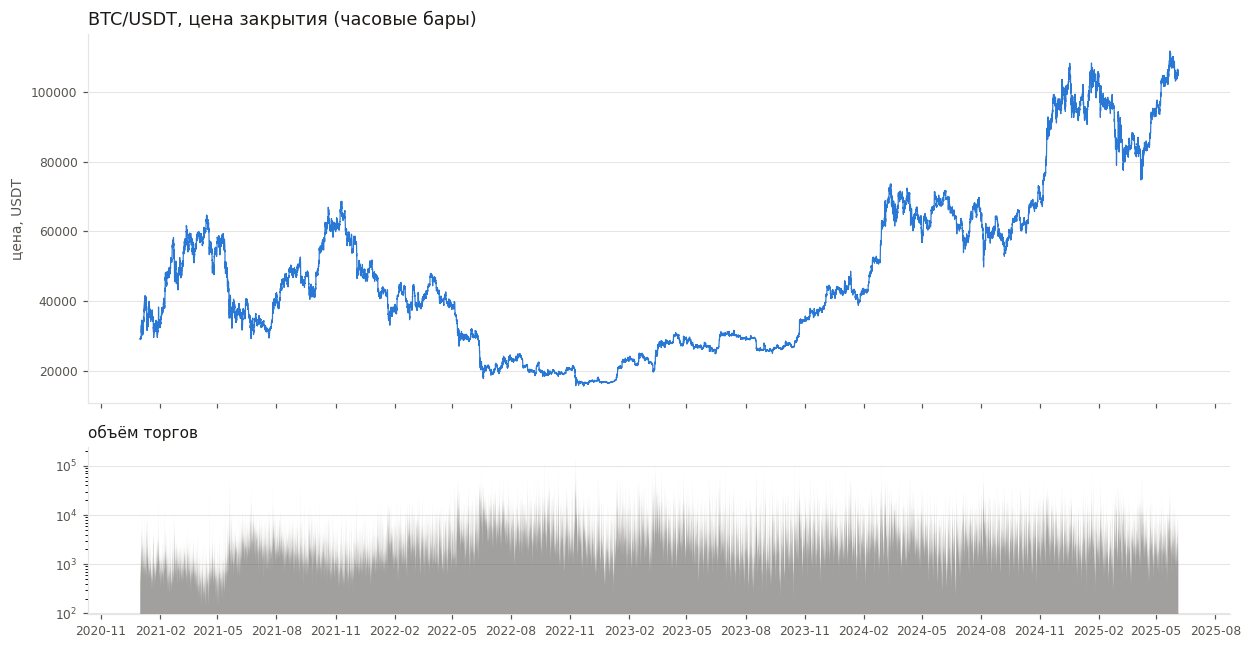

Баров с ценовым разрывом (open != предыдущий close): 66 из 38774 (0.17%), максимальный разрыв 40.0 USDT
Часовая доходность: std=0.6626%, эксцесс=17.0 (у нормального распределения 0), диапазон [-9.28%, 12.50%]


In [3]:
gap = raw["open"] - raw["close"].shift(1)
n_gap = int((gap.abs() > 1e-9).sum())
ret_all = raw["close"].pct_change()

fig, axes = plt.subplots(2, 1, figsize=(11.5, 6), sharex=True,
                         gridspec_kw={"height_ratios": [2.2, 1]})
axes[0].plot(raw["date"], raw["close"], color=COLORS["LogisticRegression"], linewidth=0.8)
axes[0].set_title("BTC/USDT, цена закрытия (часовые бары)", color=INK, loc="left", fontsize=11.5)
axes[0].set_ylabel("цена, USDT", color=INK_MUTED, fontsize=9)
axes[1].fill_between(raw["date"], raw["volume"], color=INK_MUTED, linewidth=0, alpha=0.55)
axes[1].set_title("объём торгов", color=INK, loc="left", fontsize=10)
axes[1].set_yscale("log")
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
for ax in axes:
    style_ax(ax)
fig.tight_layout()
plt.show()

print(f"Баров с ценовым разрывом (open != предыдущий close): {n_gap} из {len(raw) - 1} "
      f"({n_gap / (len(raw) - 1):.2%}), максимальный разрыв {gap.abs().max():.1f} USDT")
print(f"Часовая доходность: std={ret_all.std():.4%}, эксцесс={ret_all.kurtosis():.1f} "
      f"(у нормального распределения 0), диапазон [{ret_all.min():.2%}, {ret_all.max():.2%}]")

### 1.2 Новостной поток

Источник — `data/btc_news.csv`: 210 832 заголовка крипто-повестки с точными метками времени и
названием издания, от 2011 года до июня 2025-го. **Больше половины файла — точные дубли строк**:
из 210 829 пригодных к обработке записей 107 905 (51.2%) буквально повторяют более раннюю
строку и удаляются до любых агрегатов, PCA и обучения тональности; после дедупликации остаётся
102 924 заголовка на весь файл. Внутрь рабочего окна (ценовой период плюс 40 дней перед первым
баром, чтобы PCA и статистики тональности не считались по обрезанному началу) попадает
**69 421 заголовок** из 290 изданий — из них 68 415 строго внутри периода цен; на восемь
крупнейших изданий (CoinDesk, FX Empire, GlobeNewswire, InvestorPlace, Reuters, Benzinga,
Business Insider, Zacks) приходится заметная часть потока (см. таблицу топ-изданий ниже).

Поток собран вокруг биткоина, но это лента финансовых СМИ, а не монотематический источник —
часть заголовков наверняка относится к макроэкономике и другим активам тех же изданий. Точная
доля заголовков с прямым упоминанием bitcoin/BTC в рабочем наборе после дедупликации отдельно не
пересчитывалась; называть весь поток «новостями о биткоине» было бы неточно.

**Ряд цен пришлось обрезать.** Новости кончаются 04.06.2025. Если оставить весь ряд цен, вся
отложенная выборка окажется в зоне, где новостных признаков нет: модель училась бы с новостями,
а проверялась без них. Это не эксперимент, а его имитация. Поэтому цены обрезаются по
последнему часу с новостями — ценой 23% данных (38 775 баров из 50 305 в файле цен) и, что важнее, ценой
смены валидационного периода на растущий.

**Плотность потока неравномерна, и это само по себе признак.** Медиана — 1 заголовок в час, но
часов с новостями — 62.5% (после дедупликации доля часов без новостей выросла по сравнению с
недедуплицированным потоком). Всплеск новостной активности часто информативнее тональности:
рынок реагирует на то, что о нём вообще заговорили.

**Причинность.** Заголовок, опубликованный в момент τ, приписывается к бару
`ceil(τ, 1 час)`, то есть округляется вверх. Если метка времени бара — это его закрытие, то
это первый бар, к закрытию которого новость уже вышла; если метка — открытие (обычное
соглашение для биржевых часовых данных), округление добавляет ещё час запаса. Признак заведомо
не опережает новость ни при одном из двух соглашений, поэтому проверять, какое из них верно для
этого файла, не требуется.
Дальше все агрегаты считаются скользящими окнами по барам `≤ t`, и проверка на утечку из
раздела 7.4 покрывает их наравне с остальными признаками (кроме обучаемых преобразований — PCA,
отбора, порогов слоя, периодов TimesNet, у которых причинность разобрана отдельно в
соответствующих разделах).

,значение
заголовков в файле,69421
в рабочем периоде,68415
изданий,290
часов с новостями,62.5%
медиана на час,1
среднее на час,1.76
максимум на час,29
среднее в сутки,42


Топ изданий:


,заголовков
source,
CoinDesk,13402
FX Empire,5764
GlobeNewswire,4052
InvestorPlace,3935
Reuters,3806
Benzinga,2530
Business Insider,2529
Zacks,1939


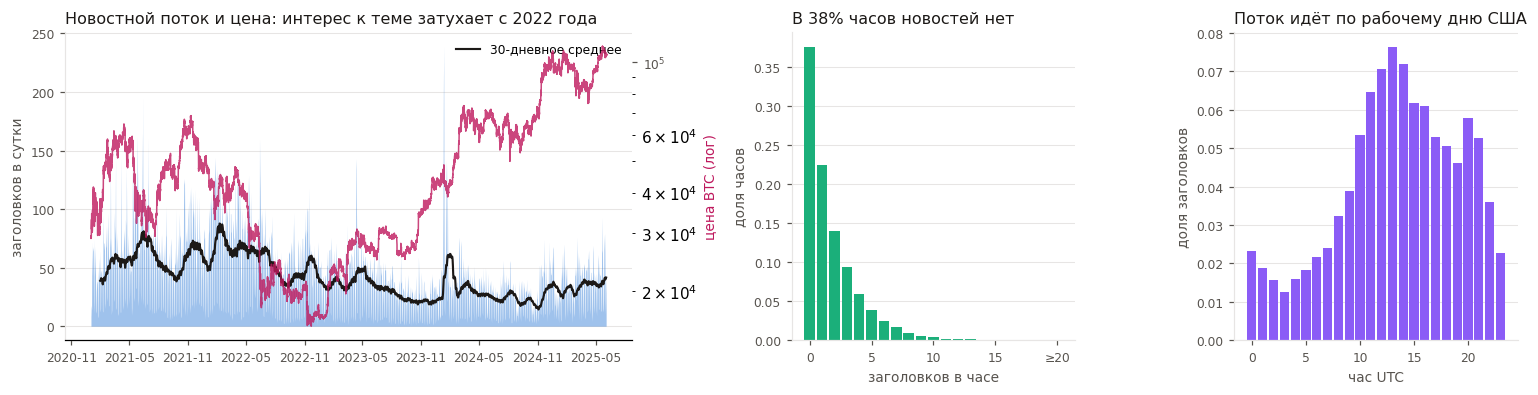

Правая панель объясняет, почему час выхода новости важен: поток подчинён рабочему дню
американских редакций, а торги идут круглосуточно. Ночью новостей почти нет, и признаки
вроде «часов с последней новости» несут в том числе календарную информацию.


In [4]:
# Новостной поток: плотность, источники, покрытие.
news_period = news[(news["dt"] >= raw["date"].min()) & (news["dt"] <= raw["date"].max())]
per_day = news_period.set_index("dt").resample("D").size()
per_bar_cnt = news_period.set_index("dt").resample("h").size().reindex(
    pd.date_range(raw["date"].min(), raw["date"].max(), freq="h"), fill_value=0)

news_stats = pd.DataFrame({
    "значение": [len(news), len(news_period), news_period["source"].nunique(),
                 f"{(per_bar_cnt > 0).mean():.1%}", f"{per_bar_cnt.median():.0f}",
                 f"{per_bar_cnt.mean():.2f}", f"{per_bar_cnt.max():.0f}",
                 f"{per_day.mean():.0f}"],
}, index=["заголовков в файле", "в рабочем периоде", "изданий",
          "часов с новостями", "медиана на час", "среднее на час",
          "максимум на час", "среднее в сутки"])
display(news_stats)
print("Топ изданий:")
display(news_period["source"].value_counts().head(8).rename("заголовков").to_frame())

fig, axes = plt.subplots(1, 3, figsize=(14, 3.7), gridspec_kw={"width_ratios": [2, 1, 1]})

ax = axes[0]
ax.fill_between(per_day.index, per_day.to_numpy(), color=COLORS["LogisticRegression"],
                alpha=0.45, linewidth=0)
ax.plot(per_day.index, per_day.rolling(30).mean(), color=INK, linewidth=1.4,
        label="30-дневное среднее")
ax2 = ax.twinx()
ax2.plot(raw["date"], raw["close"], color=COLORS["TimesFM"], linewidth=1.0, alpha=0.8)
ax2.set_yscale("log")
ax2.set_ylabel("цена BTC (лог)", color=COLORS["TimesFM"], fontsize=9)
ax2.tick_params(colors=INK_MUTED, labelsize=8)
for s in ("top", "right", "left"):
    ax2.spines[s].set_visible(False)
ax.set_ylabel("заголовков в сутки", color=INK_MUTED, fontsize=9)
ax.set_title("Новостной поток и цена: интерес к теме затухает с 2022 года",
             color=INK, fontsize=10.5, loc="left")
ax.legend(frameon=False, fontsize=8, loc="upper right")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
style_ax(ax)

ax = axes[1]
vals, bins = np.histogram(per_bar_cnt, bins=np.arange(0, 21) - 0.5)
# Деноминатор — ВСЕ часы (len(per_bar_cnt)), а не сумма показанных бинов: иначе часы с
# больше чем 19 новостями просто выпадали из нормировки и доли не суммировались бы в
# единицу при подписи оси "доля часов" (codex_report.md, пункт 29). Хвост >= 20 — отдельным
# столбиком, а не потерян молча.
_tail_20 = int((per_bar_cnt >= 20).sum())
_total_hours = len(per_bar_cnt)
ax.bar(np.arange(0, 21), np.concatenate([vals, [_tail_20]]) / _total_hours,
       color=COLORS["CatBoost"], width=0.85)
ax.set_xticks([0, 5, 10, 15, 20])
ax.set_xticklabels(["0", "5", "10", "15", "≥20"])
ax.set_xlabel("заголовков в часе", color=INK_MUTED, fontsize=9)
ax.set_ylabel("доля часов", color=INK_MUTED, fontsize=9)
ax.set_title(f"В {(per_bar_cnt == 0).mean():.0%} часов новостей нет",
             color=INK, fontsize=10.5, loc="left")
style_ax(ax)

ax = axes[2]
by_hour = news_period.groupby(news_period["dt"].dt.hour).size()
ax.bar(by_hour.index, by_hour / by_hour.sum(), color=COLORS["Ensemble"], width=0.85)
ax.set_xlabel("час UTC", color=INK_MUTED, fontsize=9)
ax.set_ylabel("доля заголовков", color=INK_MUTED, fontsize=9)
ax.set_title("Поток идёт по рабочему дню США", color=INK, fontsize=10.5, loc="left")
style_ax(ax)

fig.tight_layout()
plt.show()
print("Правая панель объясняет, почему час выхода новости важен: поток подчинён рабочему дню")
print("американских редакций, а торги идут круглосуточно. Ночью новостей почти нет, и признаки")
print("вроде «часов с последней новости» несут в том числе календарную информацию.")

## 2. Поиск аномалий (выбросов) и их обработка

Проверка на **рыночные выбросы**:
бары с экстремальным движением цены или объёма.

| шаг | что делается | зачем |
|---|---|---|
| обнаружение | робастный z-score (медиана + MAD) по доходности, объёму и истинному диапазону | MAD, в отличие от std, не «раздувается» самими выбросами |
| обнаружение | многомерный `IsolationForest` по причинным признакам бара — **только диагностика**, в конвейер не идёт (раздел 2.2) | ловит аномальные *сочетания* (например, большой объём при нулевом движении) |
| признаки | сами z-оценки и флаги аномальности идут в модель как признаки | кластеризация волатильности — это предсказательная информация |
| ограничение | винзоризация всех признаков по квантилям **обучающей** выборки | убирает влияние хвостов, не удаляя строки из ряда |
| ограничение | понижающий вес баров с выбросом доходности или объёма (`anom_any`) в функции потерь | модель их видит, но они не доминируют |

Строки **не удаляются**. Временной ряд обязан остаться непрерывным,
иначе лаговые признаки будут ссылаться на несуществующие соседние бары, а бэктест — «телепортировать»
капитал через выброшенные часы, завышая результат (именно на пропущенных барах и случаются
самые большие убытки).

In [5]:
# Общие вспомогательные функции: нужны и для поиска аномалий, и для индикаторов ТА.

def wilder(s, n):
    """Сглаживание Уайлдера (RSI/ATR/ADX): экспоненциальное среднее с alpha = 1/n."""
    return s.ewm(alpha=1.0 / n, adjust=False).mean()


def true_range(high, low, close):
    """Истинный диапазон бара с учётом разрыва от предыдущего закрытия."""
    pc = close.shift(1)
    return pd.concat([high - low, (high - pc).abs(), (low - pc).abs()], axis=1).max(axis=1)


def zscore(s, n):
    return (s - s.rolling(n).mean()) / s.rolling(n).std(ddof=0).replace(0, np.nan)


def robust_z(s, n):
    """Робастная z-оценка: (x - медиана) / (1.4826 * MAD) по скользящему окну.

    1.4826 — коэффициент, при котором MAD нормального распределения равен его std,
    поэтому пороги можно трактовать в «сигмах». В отличие от обычного z-score,
    оценка не портится самими выбросами: одна свеча в ±10% не сдвигает медиану.

    MAD считается внутри каждого окна относительно ЕДИНОЙ медианы этого же окна
    (median(|x - median(x)|)). Вариант (s - rolling_median).rolling(n).median()
    сравнивал бы каждую точку с её собственной, более длинной историей медиан —
    другая статистика с другим масштабом.
    """
    x = s.to_numpy(dtype=np.float64)
    if len(x) < n:
        return pd.Series(np.full(len(x), np.nan), index=s.index)
    windows = np.lib.stride_tricks.sliding_window_view(x, n)
    win_med = np.median(windows, axis=-1)
    win_mad = np.median(np.abs(windows - win_med[:, None]), axis=-1)
    med = pd.Series(np.concatenate([np.full(n - 1, np.nan), win_med]), index=s.index)
    mad = pd.Series(np.concatenate([np.full(n - 1, np.nan), win_mad]), index=s.index)
    return (s - med) / (1.4826 * mad).replace(0, np.nan)

### 2.1 Одномерные выбросы: робастные z-оценки

In [6]:
ANOM_WIN = 168        # окно оценки «нормы» — одна неделя часовых баров

ret1 = raw["close"].pct_change()
tr = true_range(raw["high"], raw["low"], raw["close"])
logv = np.log1p(raw["volume"])

anom_z = pd.DataFrame({
    "доходность": robust_z(ret1, ANOM_WIN),
    "объём": robust_z(logv, ANOM_WIN),
    "истинный диапазон": robust_z(tr, ANOM_WIN),
})
anom_flags = anom_z.abs() > OUTLIER_Z

summary = pd.DataFrame({
    "выбросов": anom_flags.sum(),
    "доля": (anom_flags.mean() * 100).round(2).astype(str) + "%",
    "макс |z|": anom_z.abs().max().round(1),
    "выбросов по обычному z": [int((np.abs(zscore(x, ANOM_WIN)) > OUTLIER_Z).sum())
                               for x in (ret1, logv, tr)],
})
summary.index.name = "показатель"
print(f"Порог: |робастный z| > {OUTLIER_Z} при окне {ANOM_WIN} ч")
display(summary)

is_outlier_any = anom_flags.any(axis=1)
print(f"Баров, аномальных хотя бы по одному показателю: {is_outlier_any.sum()} "
      f"({is_outlier_any.mean():.2%})")
ratio = (summary["выбросов"] / summary["выбросов по обычному z"].replace(0, np.nan))
print(f"Последняя колонка — сколько выбросов нашёл бы обычный z-score при том же пороге: "
      f"в {ratio.min():.1f}–{ratio.max():.1f} раза меньше.")
print("Причина в том, что сигма, посчитанная по среднему и std, сама раздувается выбросами")
print("и прячет их; медиана и MAD от одиночных выбросов почти не двигаются.\n")

extreme = raw.loc[anom_z["доходность"].abs().nlargest(8).index, ["date", "close", "volume"]].copy()
extreme["доходность"] = (ret1.loc[extreme.index] * 100).round(2).astype(str) + "%"
extreme["робастный z"] = anom_z.loc[extreme.index, "доходность"].round(1)
extreme["z объёма"] = anom_z.loc[extreme.index, "объём"].round(1)
print("Самые экстремальные бары по доходности:")
display(extreme.set_index("date"))

Порог: |робастный z| > 4.0 при окне 168 ч


,выбросов,доля,макс |z|,выбросов по обычному z
показатель,,,,
доходность,1104,2.85%,45.4,284
объём,42,0.11%,7.5,19
истинный диапазон,1607,4.14%,87.1,374


Баров, аномальных хотя бы по одному показателю: 1872 (4.83%)
Последняя колонка — сколько выбросов нашёл бы обычный z-score при том же пороге: в 2.2–4.3 раза меньше.
Причина в том, что сигма, посчитанная по среднему и std, сама раздувается выбросами
и прячет их; медиана и MAD от одиночных выбросов почти не двигаются.

Самые экстремальные бары по доходности:


,close,volume,доходность,робастный z,z объёма
date,,,,,
2023-08-17 21:00:00,26230.8,85042.204,-5.2%,-45.4,4.4
2023-08-29 14:00:00,27481.7,130484.605,5.53%,37.2,5.0
2023-01-14 00:00:00,20894.0,98605.159,4.95%,31.1,3.0
2023-01-12 17:00:00,18833.5,46472.443,3.9%,30.4,3.2
2022-12-13 13:00:00,17878.5,64708.829,2.7%,21.3,4.5
2022-11-08 17:00:00,19324.5,57086.582,-5.06%,-21.0,3.3
2023-10-01 22:00:00,27980.4,42770.353,3.0%,19.8,2.9
2023-04-26 19:00:00,27871.8,79142.216,-6.24%,-19.8,3.3


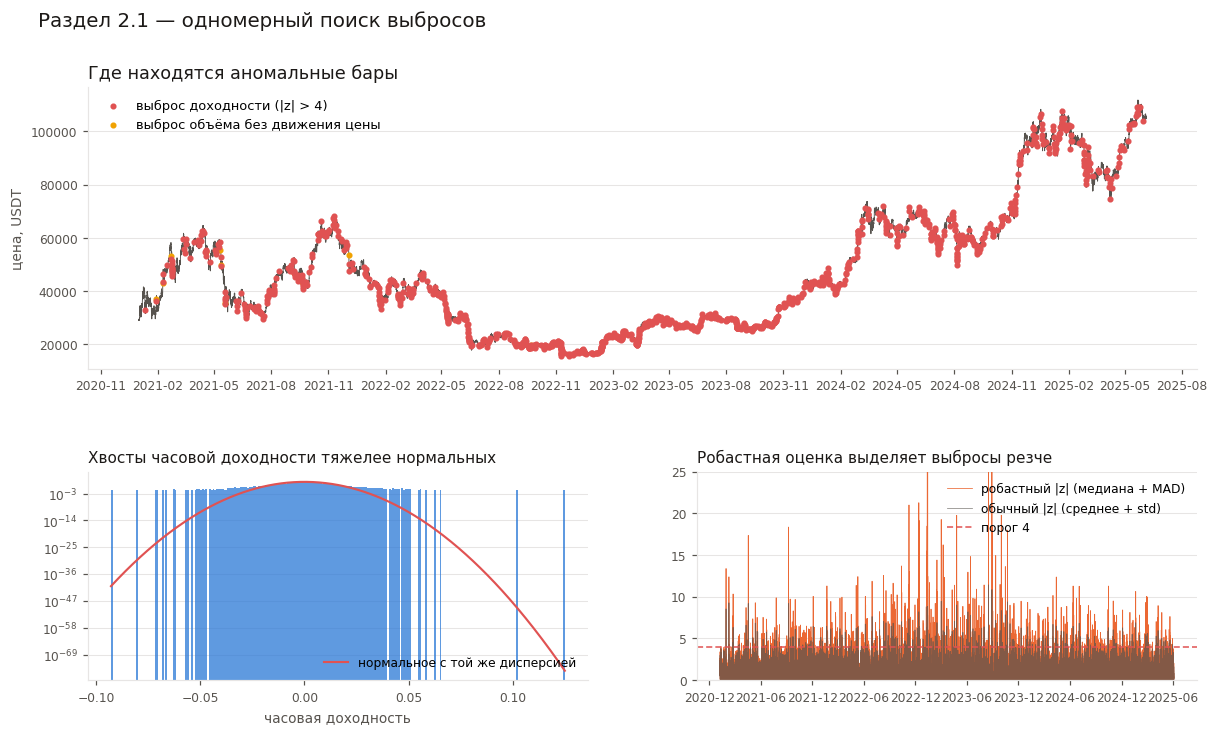

In [7]:
fig = plt.figure(figsize=(13, 7))
gs = fig.add_gridspec(2, 2, height_ratios=[1.35, 1], hspace=0.42, wspace=0.22)

# ── цена с отмеченными выбросами ────────────────────────────────────────────
ax = fig.add_subplot(gs[0, :])
ax.plot(raw["date"], raw["close"], color=INK_MUTED, linewidth=0.6, zorder=1)
out_idx = anom_flags["доходность"]
ax.scatter(raw.loc[out_idx, "date"], raw.loc[out_idx, "close"], s=9,
           color=DOWN, zorder=3, label=f"выброс доходности (|z| > {OUTLIER_Z:.0f})")
vol_only = anom_flags["объём"] & ~anom_flags["доходность"]
ax.scatter(raw.loc[vol_only, "date"], raw.loc[vol_only, "close"], s=9,
           color="#f0a202", zorder=2, label="выброс объёма без движения цены")
ax.set_title("Где находятся аномальные бары", color=INK, loc="left", fontsize=11.5)
ax.set_ylabel("цена, USDT", color=INK_MUTED, fontsize=9)
ax.legend(frameon=False, fontsize=8.5, loc="upper left")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
style_ax(ax)

# ── распределение доходности против нормального ─────────────────────────────
ax = fig.add_subplot(gs[1, 0])
r = ret1.dropna()
ax.hist(r, bins=250, color=COLORS["LogisticRegression"], alpha=0.75, density=True, linewidth=0)
xs = np.linspace(r.min(), r.max(), 500)
ax.plot(xs, stats.norm.pdf(xs, r.mean(), r.std()), color=DOWN, linewidth=1.4,
        label="нормальное с той же дисперсией")
ax.set_yscale("log")
ax.set_title("Хвосты часовой доходности тяжелее нормальных", color=INK, loc="left", fontsize=10)
ax.set_xlabel("часовая доходность", color=INK_MUTED, fontsize=9)
ax.legend(frameon=False, fontsize=8)
style_ax(ax)

# ── robust z против обычного z ──────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
ax.plot(raw["date"], anom_z["доходность"].abs(), color=COLORS["DecisionTree"], linewidth=0.5,
        label="робастный |z| (медиана + MAD)")
ax.plot(raw["date"], zscore(ret1, ANOM_WIN).abs(), color=INK_MUTED, linewidth=0.5, alpha=0.7,
        label="обычный |z| (среднее + std)")
ax.axhline(OUTLIER_Z, color=DOWN, linewidth=1.0, linestyle=(0, (4, 2)),
           label=f"порог {OUTLIER_Z:.0f}")
ax.set_title("Робастная оценка выделяет выбросы резче", color=INK, loc="left", fontsize=10)
ax.set_ylim(0, 25)
ax.legend(frameon=False, fontsize=8)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
style_ax(ax)

fig.suptitle("Раздел 2.1 — одномерный поиск выбросов", fontsize=13, color=INK, x=0.09, ha="left",
             y=0.98)
plt.show()

### 2.2 Многомерные аномалии: IsolationForest

Одномерные оценки не видят аномальных *сочетаний*: бар с обычной по величине доходностью, но
аномальным для неё объёмом и формой свечи, по каждому показателю в отдельности выглядит
нормальным. `IsolationForest` строит случайные деревья и измеряет, за сколько расщеплений
наблюдение удаётся отделить от остальных: выброс отделяется быстро.

Детектор обучается **только на обучающей части ряда** (первые 70%) и применяется ко всему ряду —
так же, как это происходило бы в реальной эксплуатации, когда будущего мы не знаем.

Порог аномальности (99-й перцентиль по train): 0.659
Помечено IsolationForest: 344 баров (0.89%)



IsolationForest,False,True
одномерный выброс,,
False,36875,28
True,1556,316


28 баров (0.07%) аномальны только как сочетание признаков — одномерные оценки их не видят.


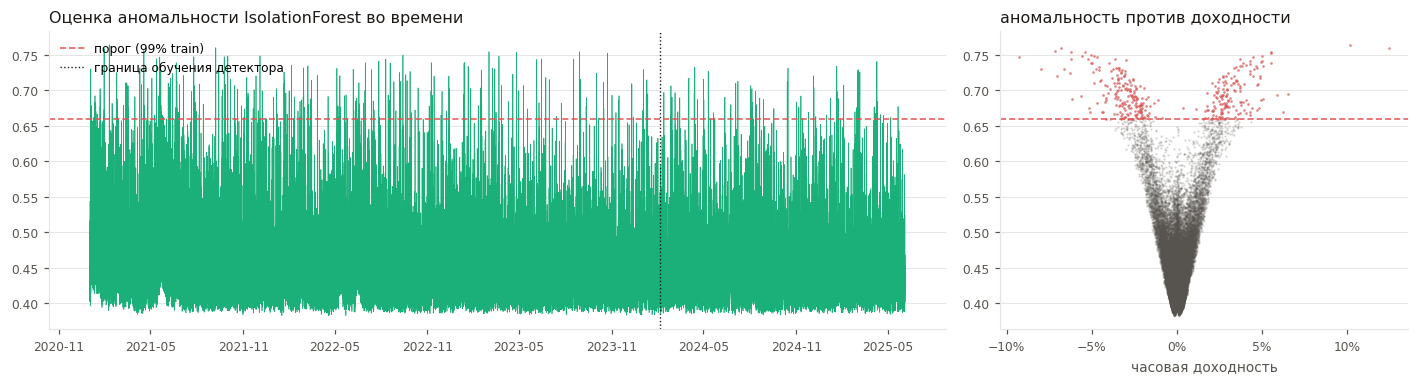

In [8]:
n_raw = len(raw)
train_bound = int(n_raw * TRAIN_END)

# компактный набор причинных характеристик бара
atr14_raw = wilder(true_range(raw["high"], raw["low"], raw["close"]), 14)
rng_raw = (raw["high"] - raw["low"]).replace(0, np.nan)
iso_input = pd.DataFrame({
    "ret": ret1,
    "abs_ret": ret1.abs(),
    "tr_atr": tr / atr14_raw.replace(0, np.nan),
    "vol_z": zscore(logv, ANOM_WIN),
    "body_frac": (raw["close"] - raw["open"]).abs() / rng_raw,
    "clv": ((raw["close"] - raw["low"]) - (raw["high"] - raw["close"])) / rng_raw,
}).replace([np.inf, -np.inf], np.nan)
iso_input = iso_input.ffill().bfill()

iso = IsolationForest(n_estimators=300, contamination=0.01, random_state=RANDOM_STATE, n_jobs=-1)
iso.fit(iso_input.iloc[:train_bound])
iso_score = pd.Series(-iso.score_samples(iso_input), index=raw.index)   # больше = аномальнее
iso_thr = float(np.quantile(iso_score.iloc[:train_bound], 0.99))
iso_flag = iso_score > iso_thr

overlap = pd.crosstab(is_outlier_any.rename("одномерный выброс"),
                      iso_flag.rename("IsolationForest"))
print(f"Порог аномальности (99-й перцентиль по train): {iso_thr:.3f}")
print(f"Помечено IsolationForest: {iso_flag.sum()} баров ({iso_flag.mean():.2%})\n")
display(overlap)
found_only_by_iso = int(((~is_outlier_any) & iso_flag).sum())
print(f"{found_only_by_iso} баров ({found_only_by_iso / len(raw):.2%}) аномальны только как "
      f"сочетание признаков — одномерные оценки их не видят.")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), gridspec_kw={"width_ratios": [2.2, 1]})
axes[0].plot(raw["date"], iso_score, color=COLORS["CatBoost"], linewidth=0.45)
axes[0].axhline(iso_thr, color=DOWN, linewidth=1.0, linestyle=(0, (4, 2)), label="порог (99% train)")
axes[0].axvline(raw["date"].iloc[train_bound], color=INK, linewidth=0.9, linestyle=":",
                label="граница обучения детектора")
axes[0].set_title("Оценка аномальности IsolationForest во времени", color=INK, loc="left", fontsize=10.5)
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
style_ax(axes[0])

axes[1].scatter(ret1, iso_score, s=2, alpha=0.25, color=INK_MUTED, linewidth=0)
axes[1].scatter(ret1[iso_flag], iso_score[iso_flag], s=3, alpha=0.6, color=DOWN, linewidth=0)
axes[1].axhline(iso_thr, color=DOWN, linewidth=1.0, linestyle=(0, (4, 2)))
axes[1].set_xlabel("часовая доходность", color=INK_MUTED, fontsize=9)
axes[1].set_title("аномальность против доходности", color=INK, loc="left", fontsize=10.5)
axes[1].xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
style_ax(axes[1])
fig.tight_layout()
plt.show()

Вертикальная «стенка» точек в правой панели показывает главное: высокая оценка аномальности
встречается и при доходности, близкой к нулю. Это как раз бары с аномальным объёмом или формой
свечи при спокойной цене — их одномерный фильтр по доходности пропускает.

Одна оговорка, без которой раздел вводил бы в заблуждение: **`IsolationForest` здесь —
диагностика, а не часть конвейера.** Его флаг не идёт в модель признаком и не влияет на веса
наблюдений. Причина в том же, из-за чего винзоризация считается внутри фолда: детектор обучен
на первых 70% ряда целиком, и внутри кросс-валидации его оценка для раннего фолда уже знала бы
о более поздних барах. Чтобы использовать её как признак честно, детектор пришлось бы
переобучать в каждом фолде. В модель идут только робастные z-оценки — они считаются скользящим
окном и причинны по построению.


## 3. Библиотека индикаторов технического анализа

In [9]:
def rsi(close, n=14):
    """Индекс относительной силы: отношение среднего роста к среднему падению за n баров."""
    d = close.diff()
    gain = wilder(d.clip(lower=0), n)
    loss = wilder((-d).clip(lower=0), n)
    out = 100 - 100 / (1 + gain / loss.where(loss > 0))
    # loss == 0: рост без падений -> 100; полный штиль -> нейтральные 50
    return out.where(loss > 0, np.where(gain > 0, 100.0, 50.0))


def atr(high, low, close, n=14):
    """Средний истинный диапазон — базовая мера волатильности в единицах цены."""
    return wilder(true_range(high, low, close), n)


def stochastic(high, low, close, n=14, d=3):
    """Стохастик: положение закрытия внутри диапазона последних n баров."""
    ll, hh = low.rolling(n).min(), high.rolling(n).max()
    k = 100 * (close - ll) / (hh - ll).replace(0, np.nan)
    return k, k.rolling(d).mean()


def macd(close, fast=12, slow=26, signal=9):
    """Схождение/расхождение скользящих средних: линия, сигнал и гистограмма."""
    line = close.ewm(span=fast, adjust=False).mean() - close.ewm(span=slow, adjust=False).mean()
    sig = line.ewm(span=signal, adjust=False).mean()
    return line, sig, line - sig


def adx(high, low, close, n=14):
    """Индекс направленного движения: сила тренда (ADX) и его направление (+DI / -DI)."""
    up, dn = high.diff(), -low.diff()
    plus_dm = pd.Series(np.where((up > dn) & (up > 0), up, 0.0), index=high.index)
    minus_dm = pd.Series(np.where((dn > up) & (dn > 0), dn, 0.0), index=high.index)
    tr_n = wilder(true_range(high, low, close), n).replace(0, np.nan)
    plus_di = 100 * wilder(plus_dm, n) / tr_n
    minus_di = 100 * wilder(minus_dm, n) / tr_n
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di).replace(0, np.nan)
    return wilder(dx, n), plus_di, minus_di


def cci(high, low, close, n=20):
    """Индекс товарного канала: отклонение типичной цены от среднего в единицах среднего отклонения.

    Среднее отклонение считается внутри каждого окна от ЕДИНОГО среднего этого окна
    (mean(|x - mean(x)|)), а не от скользящего среднего каждой точки — иначе разные
    элементы окна сравнивались бы с разными базами.
    """
    tp = (high + low + close) / 3
    sma = tp.rolling(n).mean()
    x = tp.to_numpy(dtype=np.float64)
    if len(x) < n:
        mad = pd.Series(np.full(len(x), np.nan), index=tp.index)
    else:
        windows = np.lib.stride_tricks.sliding_window_view(x, n)
        win_mean = np.mean(windows, axis=-1)
        win_mad = np.mean(np.abs(windows - win_mean[:, None]), axis=-1)
        mad = pd.Series(np.concatenate([np.full(n - 1, np.nan), win_mad]), index=tp.index)
    return (tp - sma) / (0.015 * mad.replace(0, np.nan))


def mfi(high, low, close, volume, n=14):
    """Индекс денежного потока — RSI, взвешенный объёмом."""
    tp = (high + low + close) / 3
    raw_flow = tp * volume
    up = raw_flow.where(tp > tp.shift(1), 0.0).rolling(n).sum()
    dn = raw_flow.where(tp < tp.shift(1), 0.0).rolling(n).sum()
    out = 100 - 100 / (1 + up / dn.replace(0, np.nan))
    # dn == 0: чисто положительный поток -> 100 (как в rsi()); полный штиль (up==dn==0) -> 50
    return out.where(dn > 0, np.where(up > 0, 100.0, 50.0))


def clv(high, low, close):
    """Close Location Value: положение закрытия внутри диапазона бара, от -1 до +1."""
    return ((close - low) - (high - close)) / (high - low).replace(0, np.nan)


def cmf(high, low, close, volume, n=20):
    """Денежный поток Чайкина: объём, взвешенный положением закрытия в баре."""
    return ((clv(high, low, close).fillna(0) * volume).rolling(n).sum()
            / volume.rolling(n).sum().replace(0, np.nan))


def obv(close, volume):
    """Балансовый объём: накопленный объём со знаком движения цены."""
    return (np.sign(close.diff().fillna(0)) * volume).cumsum()


def aroon(high, low, n=25):
    """Aroon: как давно был максимум и минимум окна (100 = прямо сейчас)."""
    hi = high.rolling(n + 1).apply(lambda x: float(np.argmax(x)), raw=True)
    lo = low.rolling(n + 1).apply(lambda x: float(np.argmin(x)), raw=True)
    return 100 * hi / n, 100 * lo / n


def efficiency_ratio(close, n=20):
    """Коэффициент эффективности Кауфмана: 1 — чистый тренд, 0 — «пила» без смещения."""
    direction = (close - close.shift(n)).abs()
    path = close.diff().abs().rolling(n).sum()
    return direction / path.replace(0, np.nan)


# демонстрация на последних сутках
demo = raw.tail(500).reset_index(drop=True)
_adx, _pdi, _mdi = adx(demo["high"], demo["low"], demo["close"])
demo_ind = pd.DataFrame({
    "RSI(14)": rsi(demo["close"]), "ATR(14)": atr(demo["high"], demo["low"], demo["close"]),
    "ADX(14)": _adx, "CCI(20)": cci(demo["high"], demo["low"], demo["close"]),
    "MFI(14)": mfi(demo["high"], demo["low"], demo["close"], demo["volume"]),
    "ER(20)": efficiency_ratio(demo["close"]),
}).tail(3).round(3)
print("Проверка индикаторов на последних барах ряда:")
display(demo_ind)

Проверка индикаторов на последних барах ряда:


,RSI(14),ATR(14),ADX(14),CCI(20),MFI(14),ER(20)
497,42.689,436.358,9.292,-184.247,26.001,0.198
498,38.841,445.883,9.505,-188.449,24.374,0.284
499,43.937,475.791,10.812,-212.796,20.272,0.225


## 4. Свечные паттерны

Реализовано 31 определение: однобарные (доджи, молот, перевёрнутый молот, падающая звезда,
повешенный, марубозу, волчок, «пояс», надгробие и стрекоза), двухбарные (бычье и медвежье
поглощение, харами, пронзающая линия, завеса из тёмных облаков, пинцеты, внутренний и внешний бар)
и трёхбарные (утренняя и вечерняя звезда, три белых солдата, три чёрные вороны, три внутри вверх/вниз).

In [10]:
def candle_anatomy(o_, h_, l_, c_):
    """Геометрия свечи: тело, тени и их доли в диапазоне бара."""
    rng = (h_ - l_).replace(0, np.nan)
    body = c_ - o_
    return pd.DataFrame({
        "rng": rng, "body": body, "abs_body": body.abs(),
        "upper": h_ - np.maximum(o_, c_), "lower": np.minimum(o_, c_) - l_,
        "body_frac": body.abs() / rng,
        "upper_frac": (h_ - np.maximum(o_, c_)) / rng,
        "lower_frac": (np.minimum(o_, c_) - l_) / rng,
        "clv": clv(h_, l_, c_),
    }, index=o_.index)


CANDLE_BULL = ["cdl_hammer", "cdl_inv_hammer", "cdl_dragonfly_doji", "cdl_marubozu_bull",
               "cdl_engulfing_bull", "cdl_harami_bull", "cdl_piercing", "cdl_tweezer_bottom",
               "cdl_morning_star", "cdl_three_white_soldiers", "cdl_three_inside_up",
               "cdl_belt_hold_bull", "cdl_outside_bar_bull"]
CANDLE_BEAR = ["cdl_hanging_man", "cdl_shooting_star", "cdl_gravestone_doji", "cdl_marubozu_bear",
               "cdl_engulfing_bear", "cdl_harami_bear", "cdl_dark_cloud", "cdl_tweezer_top",
               "cdl_evening_star", "cdl_three_black_crows", "cdl_three_inside_down",
               "cdl_belt_hold_bear", "cdl_outside_bar_bear"]
CANDLE_NEUTRAL = ["cdl_doji", "cdl_long_legged_doji", "cdl_spinning_top", "cdl_high_wave",
                  "cdl_inside_bar"]
CANDLE_ALL = CANDLE_BULL + CANDLE_BEAR + CANDLE_NEUTRAL

CANDLE_RU = {
    "cdl_hammer": "молот", "cdl_inv_hammer": "перевёрнутый молот",
    "cdl_dragonfly_doji": "доджи-стрекоза", "cdl_marubozu_bull": "марубозу бычий",
    "cdl_engulfing_bull": "бычье поглощение", "cdl_harami_bull": "харами бычий",
    "cdl_piercing": "пронзающая линия", "cdl_tweezer_bottom": "пинцет снизу",
    "cdl_morning_star": "утренняя звезда", "cdl_three_white_soldiers": "три белых солдата",
    "cdl_three_inside_up": "три внутри вверх", "cdl_belt_hold_bull": "бычий пояс",
    "cdl_outside_bar_bull": "внешний бар бычий", "cdl_hanging_man": "повешенный",
    "cdl_shooting_star": "падающая звезда", "cdl_gravestone_doji": "доджи-надгробие",
    "cdl_marubozu_bear": "марубозу медвежий", "cdl_engulfing_bear": "медвежье поглощение",
    "cdl_harami_bear": "харами медвежий", "cdl_dark_cloud": "завеса из тёмных облаков",
    "cdl_tweezer_top": "пинцет сверху", "cdl_evening_star": "вечерняя звезда",
    "cdl_three_black_crows": "три чёрные вороны", "cdl_three_inside_down": "три внутри вниз",
    "cdl_belt_hold_bear": "медвежий пояс", "cdl_outside_bar_bear": "внешний бар медвежий",
    "cdl_doji": "доджи", "cdl_long_legged_doji": "длинноногий доджи",
    "cdl_spinning_top": "волчок", "cdl_high_wave": "высокая волна",
    "cdl_inside_bar": "внутренний бар",
}


def candlestick_patterns(o_, h_, l_, c_, atr_s, trend_win=10):
    """31 свечной паттерн в виде бинарных признаков (0/1)."""
    a = candle_anatomy(o_, h_, l_, c_)
    rng, body, upper, lower = a["rng"], a["abs_body"], a["upper"], a["lower"]
    bull, bear = c_ > o_, c_ < o_
    body_atr = body / atr_s.replace(0, np.nan)

    o1, h1, l1, c1 = o_.shift(1), h_.shift(1), l_.shift(1), c_.shift(1)
    o2, c2 = o_.shift(2), c_.shift(2)
    bull1, bear1 = c1 > o1, c1 < o1
    bull2, bear2 = c2 > o2, c2 < o2
    body1, body2 = (c1 - o1).abs(), (c2 - o2).abs()
    rng1 = (h1 - l1).replace(0, np.nan)

    prior = c_.shift(1) / c_.shift(1 + trend_win) - 1        # тренд ДО текущего бара
    downtrend, uptrend = prior < 0, prior > 0

    long_body = body_atr > 0.8
    small_body = a["body_frac"] < 0.30
    doji_body = a["body_frac"] < 0.10

    p = {}
    # ── однобарные ───────────────────────────────────────────────────────────
    p["cdl_doji"] = doji_body
    p["cdl_long_legged_doji"] = doji_body & (upper > 0.3 * rng) & (lower > 0.3 * rng)
    p["cdl_dragonfly_doji"] = doji_body & (lower > 0.6 * rng) & (upper < 0.1 * rng)
    p["cdl_gravestone_doji"] = doji_body & (upper > 0.6 * rng) & (lower < 0.1 * rng)
    p["cdl_spinning_top"] = small_body & (upper > body) & (lower > body) & ~doji_body
    p["cdl_high_wave"] = small_body & ((upper + lower) / rng > 0.8) & (rng / atr_s > 1.5)

    hammer_shape = (lower >= 2 * body) & (upper <= 0.25 * body.where(body > 0, rng)) & (a["body_frac"] < 0.4)
    star_shape = (upper >= 2 * body) & (lower <= 0.25 * body.where(body > 0, rng)) & (a["body_frac"] < 0.4)
    p["cdl_hammer"] = hammer_shape & downtrend            # та же форма, что и повешенный,
    p["cdl_hanging_man"] = hammer_shape & uptrend         # различает только тренд до неё
    p["cdl_inv_hammer"] = star_shape & downtrend
    p["cdl_shooting_star"] = star_shape & uptrend
    p["cdl_marubozu_bull"] = bull & (a["body_frac"] > 0.90) & long_body
    p["cdl_marubozu_bear"] = bear & (a["body_frac"] > 0.90) & long_body
    p["cdl_belt_hold_bull"] = bull & (a["lower_frac"] < 0.05) & (a["body_frac"] > 0.7) & downtrend
    p["cdl_belt_hold_bear"] = bear & (a["upper_frac"] < 0.05) & (a["body_frac"] > 0.7) & uptrend

    # ── двухбарные ───────────────────────────────────────────────────────────
    p["cdl_engulfing_bull"] = bear1 & bull & (c_ >= o1) & (o_ <= c1) & (body > body1)
    p["cdl_engulfing_bear"] = bull1 & bear & (o_ >= c1) & (c_ <= o1) & (body > body1)
    p["cdl_harami_bull"] = bear1 & bull & (c_ <= o1) & (o_ >= c1) & (body < 0.6 * body1) & (body1 / atr_s > 0.8)
    p["cdl_harami_bear"] = bull1 & bear & (o_ <= c1) & (c_ >= o1) & (body < 0.6 * body1) & (body1 / atr_s > 0.8)
    # условие гэпа ослаблено до нестрогого: на крипторынке разрывов практически не бывает
    p["cdl_piercing"] = bear1 & bull & (o_ <= c1) & (c_ > (o1 + c1) / 2) & (c_ < o1) & (body1 / atr_s > 0.6)
    p["cdl_dark_cloud"] = bull1 & bear & (o_ >= c1) & (c_ < (o1 + c1) / 2) & (c_ > o1) & (body1 / atr_s > 0.6)
    tw_tol = 0.05 * atr_s
    p["cdl_tweezer_bottom"] = bear1 & bull & ((l_ - l1).abs() < tw_tol) & downtrend
    p["cdl_tweezer_top"] = bull1 & bear & ((h_ - h1).abs() < tw_tol) & uptrend
    p["cdl_inside_bar"] = (h_ < h1) & (l_ > l1)
    p["cdl_outside_bar_bull"] = (h_ > h1) & (l_ < l1) & bull
    p["cdl_outside_bar_bear"] = (h_ > h1) & (l_ < l1) & bear

    # ── трёхбарные ───────────────────────────────────────────────────────────
    small1 = body1 < 0.5 * body2
    p["cdl_morning_star"] = (bear2 & (body2 / atr_s > 0.8) & small1 & bull &
                             (c_ > (o2 + c2) / 2) & (c1 < c2))
    p["cdl_evening_star"] = (bull2 & (body2 / atr_s > 0.8) & small1 & bear &
                             (c_ < (o2 + c2) / 2) & (c1 > c2))
    p["cdl_three_white_soldiers"] = (bull2 & bull1 & bull & (c_ > c1) & (c1 > c2) &
                                     ((c1 - o1).abs() / rng1 > 0.6) & (a["body_frac"] > 0.6))
    p["cdl_three_black_crows"] = (bear2 & bear1 & bear & (c_ < c1) & (c1 < c2) &
                                  ((c1 - o1).abs() / rng1 > 0.6) & (a["body_frac"] > 0.6))
    p["cdl_three_inside_up"] = bear2 & bull1 & bull & (c1 <= o2) & (o1 >= c2) & (c_ > o2)
    p["cdl_three_inside_down"] = bull2 & bear1 & bear & (o1 <= c2) & (c1 >= o2) & (c_ < o2)

    return pd.DataFrame(p, index=o_.index).fillna(False).astype(np.int8)[CANDLE_ALL], a


atr14 = atr(raw["high"], raw["low"], raw["close"], 14)
cdl = candlestick_patterns(raw["open"], raw["high"], raw["low"], raw["close"], atr14)[0]

cdl_freq = pd.DataFrame({
    "паттерн": [CANDLE_RU[c] for c in cdl.columns],
    "тип": ["бычий" if c in CANDLE_BULL else "медвежий" if c in CANDLE_BEAR else "нейтральный"
            for c in cdl.columns],
    "срабатываний": cdl.sum().to_numpy(),
    "частота, %": (cdl.mean() * 100).round(2).to_numpy(),
}, index=cdl.columns).sort_values("срабатываний", ascending=False)
print(f"Распознано {len(cdl.columns)} свечных паттернов, "
      f"{int(cdl.sum().sum())} срабатываний на {len(cdl)} барах")
display(cdl_freq)

Распознано 31 свечных паттернов, 45780 срабатываний на 38775 барах


,паттерн,тип,срабатываний,"частота, %"
cdl_inside_bar,внутренний бар,нейтральный,7273,18.76
cdl_spinning_top,волчок,нейтральный,5056,13.04
cdl_engulfing_bull,бычье поглощение,бычий,4916,12.68
cdl_engulfing_bear,медвежье поглощение,медвежий,4772,12.31
cdl_doji,доджи,нейтральный,4174,10.76
cdl_long_legged_doji,длинноногий доджи,нейтральный,2004,5.17
cdl_outside_bar_bull,внешний бар бычий,бычий,1934,4.99
cdl_outside_bar_bear,внешний бар медвежий,медвежий,1843,4.75
cdl_three_inside_down,три внутри вниз,медвежий,1469,3.79
cdl_three_inside_up,три внутри вверх,бычий,1413,3.64


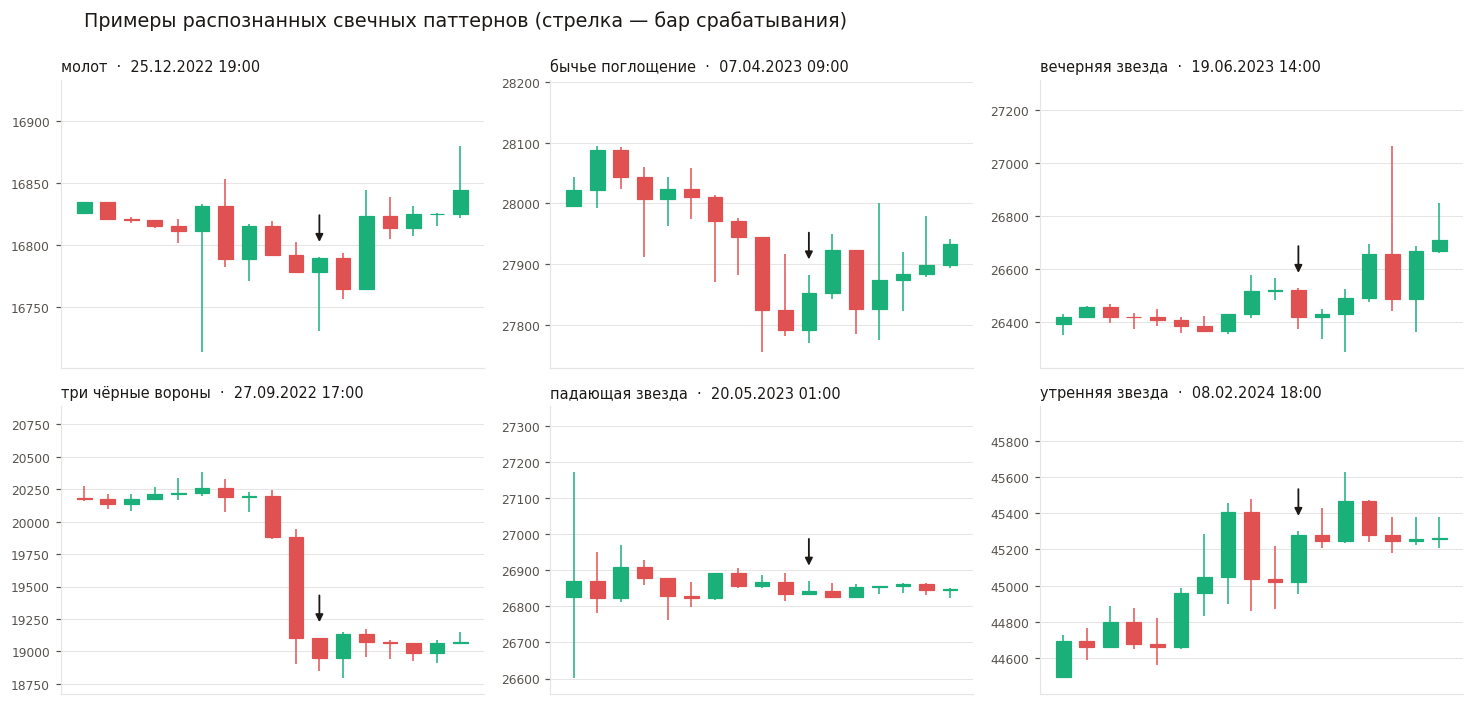

In [11]:
def plot_candles(ax, df, width=0.62):
    """Рисует японские свечи по срезу OHLC."""
    x = np.arange(len(df))
    up = df["close"].to_numpy() >= df["open"].to_numpy()
    colors = np.where(up, UP, DOWN)
    ax.vlines(x, df["low"], df["high"], color=colors, linewidth=1.0)
    for xi, (op, cl, col) in enumerate(zip(df["open"], df["close"], colors)):
        lo, height = min(op, cl), abs(cl - op)
        ax.add_patch(Rectangle((xi - width / 2, lo), width, max(height, 1e-9),
                               facecolor=col, edgecolor=col, linewidth=0.8))
    ax.set_xlim(-1, len(df))
    return x


SHOWCASE = ["cdl_hammer", "cdl_engulfing_bull", "cdl_evening_star", "cdl_three_black_crows",
            "cdl_shooting_star", "cdl_morning_star"]
fig, axes = plt.subplots(2, 3, figsize=(13.5, 6.4))
for ax, name in zip(axes.ravel(), SHOWCASE):
    hits = np.flatnonzero(cdl[name].to_numpy())
    hits = hits[(hits > 12) & (hits < len(raw) - 8)]
    if len(hits) == 0:                                 # на другом срезе паттерн может не найтись
        ax.axis("off")
        ax.set_title(f"{CANDLE_RU[name]}: не найдено на этом ряде", color=INK_MUTED, fontsize=9)
        continue
    i = int(hits[len(hits) // 2])                     # типичный, а не самый яркий пример
    window = raw.iloc[i - 10:i + 7].reset_index(drop=True)
    plot_candles(ax, window)
    span = window["high"].max() - window["low"].min()
    ax.annotate("", xy=(10, window["high"].iloc[10] + span * 0.06),
                xytext=(10, window["high"].iloc[10] + span * 0.22),
                arrowprops=dict(arrowstyle="-|>", color=INK, linewidth=1.2))
    ax.set_ylim(window["low"].min() - span * 0.08, window["high"].max() + span * 0.32)
    ax.set_title(f"{CANDLE_RU[name]}  ·  {raw['date'].iloc[i]:%d.%m.%Y %H:%M}",
                 color=INK, fontsize=9.5, loc="left")
    ax.set_xticks([])
    style_ax(ax)
fig.suptitle("Примеры распознанных свечных паттернов (стрелка — бар срабатывания)",
             fontsize=12.5, color=INK, x=0.06, ha="left", y=0.995)
fig.tight_layout()
plt.show()

## 5. Паттерны разворота на свинг-точках

Графические паттерны строятся не по отдельным свечам, а по **свинг-экстремумам** (фракталам):
бар считается свинг-максимумом, если его `high` — наибольший в окне ±`PIVOT_W` баров.

Здесь скрыта главная ловушка технического анализа в машинном обучении. Центрированное окно
заглядывает вперёд: чтобы узнать, что бар был вершиной, нужно дождаться `PIVOT_W` последующих
баров. Если поставить флаг «вершина» прямо на бар экстремума, модель получит знание из
будущего, ROC-AUC подскочит, а в реальной торговле стратегия развалится. Поэтому каждый
экстремум сдвигается вперёд на `PIVOT_W` баров: признак появляется **в момент подтверждения**,
то есть тогда же, когда его увидел бы трейдер.

На подтверждённых экстремумах распознаются: двойная и тройная вершина/дно, голова и плечи
(и перевёрнутая), последовательности higher high / lower low, дивергенции RSI, а также
рассчитываются расстояния до ближайших уровней поддержки и сопротивления в единицах ATR.

In [12]:
def swing_points(high, low, w=PIVOT_W):
    """Свинг-экстремумы, сдвинутые на w баров вперёд — к моменту их подтверждения."""
    is_ph = (high == high.rolling(2 * w + 1, center=True).max()) & high.notna()
    is_pl = (low == low.rolling(2 * w + 1, center=True).min()) & low.notna()
    return high.where(is_ph).shift(w), low.where(is_pl).shift(w)


def chart_patterns(high, low, close, rsi_s, atr_s, w=PIVOT_W, tol=0.02, depth=0.02):
    """Паттерны разворота по подтверждённым свинг-точкам + уровни поддержки/сопротивления."""
    ph_price, pl_price = swing_points(high, low, w)
    names = ["pat_double_top", "pat_double_bottom", "pat_triple_top", "pat_triple_bottom",
             "pat_head_shoulders", "pat_inv_head_shoulders",
             "pat_bear_divergence", "pat_bull_divergence",
             "pat_higher_high", "pat_lower_high", "pat_higher_low", "pat_lower_low"]
    out = {k: np.zeros(len(close), dtype=np.int8) for k in names}

    hi_idx, hi_val = ph_price.dropna().index.to_numpy(), ph_price.dropna().to_numpy()
    lo_idx, lo_val = pl_price.dropna().index.to_numpy(), pl_price.dropna().to_numpy()
    rsi_arr = rsi_s.to_numpy()
    hi_rsi = rsi_arr[np.maximum(hi_idx - w, 0)]        # RSI в самой точке экстремума
    lo_rsi = rsi_arr[np.maximum(lo_idx - w, 0)]

    for k in range(1, len(hi_idx)):
        i, p1, p2 = hi_idx[k], hi_val[k - 1], hi_val[k]
        out["pat_higher_high"][i] = int(p2 > p1)
        out["pat_lower_high"][i] = int(p2 < p1)
        if abs(p2 - p1) / p1 <= tol:                                  # две сопоставимые вершины
            trough = lo_val[(lo_idx > hi_idx[k - 1]) & (lo_idx < i)]  # и впадина между ними
            if len(trough) and (min(p1, p2) - trough.min()) / min(p1, p2) >= depth:
                out["pat_double_top"][i] = 1
                if k >= 2 and abs(hi_val[k - 2] - p1) / p1 <= tol:
                    out["pat_triple_top"][i] = 1
        if p2 > p1 and hi_rsi[k] < hi_rsi[k - 1] - 1:                 # цена выше, RSI ниже
            out["pat_bear_divergence"][i] = 1
        if k >= 2:
            s1, head, s2 = hi_val[k - 2], hi_val[k - 1], p2
            if head > s1 and head > s2 and abs(s1 - s2) / s1 <= 1.5 * tol:
                out["pat_head_shoulders"][i] = 1

    for k in range(1, len(lo_idx)):
        i, p1, p2 = lo_idx[k], lo_val[k - 1], lo_val[k]
        out["pat_higher_low"][i] = int(p2 > p1)
        out["pat_lower_low"][i] = int(p2 < p1)
        if abs(p2 - p1) / p1 <= tol:
            peak = hi_val[(hi_idx > lo_idx[k - 1]) & (hi_idx < i)]
            if len(peak) and (peak.max() - max(p1, p2)) / max(p1, p2) >= depth:
                out["pat_double_bottom"][i] = 1
                if k >= 2 and abs(lo_val[k - 2] - p1) / p1 <= tol:
                    out["pat_triple_bottom"][i] = 1
        if p2 < p1 and lo_rsi[k] > lo_rsi[k - 1] + 1:
            out["pat_bull_divergence"][i] = 1
        if k >= 2:
            s1, head, s2 = lo_val[k - 2], lo_val[k - 1], p2
            if head < s1 and head < s2 and abs(s1 - s2) / s1 <= 1.5 * tol:
                out["pat_inv_head_shoulders"][i] = 1

    last_ph, last_pl = ph_price.ffill(), pl_price.ffill()
    levels = pd.DataFrame({
        "dist_resistance_atr": (last_ph - close) / atr_s,
        "dist_support_atr": (close - last_pl) / atr_s,
        "pivot_range_atr": (last_ph - last_pl) / atr_s,
        "pos_in_pivot_range": (close - last_pl) / (last_ph - last_pl).replace(0, np.nan),
    }, index=close.index)
    return pd.DataFrame(out, index=close.index), levels


PATTERN_RU = {
    "key_reversal_up": "ключевой разворот вверх", "key_reversal_dn": "ключевой разворот вниз",
    "breakout_up_20": "пробой канала вверх", "breakout_dn_20": "пробой канала вниз",
    "cdl_net_score": "перевес бычьих свечей", "cdl_net_score_6": "перевес бычьих свечей за 6 ч",
    "cdl_bull_score": "число бычьих свечных сигналов", "cdl_bear_score": "число медвежьих свечных сигналов",
    "pat_double_top": "двойная вершина", "pat_double_bottom": "двойное дно",
    "pat_triple_top": "тройная вершина", "pat_triple_bottom": "тройное дно",
    "pat_head_shoulders": "голова и плечи", "pat_inv_head_shoulders": "перевёрнутые голова и плечи",
    "pat_bear_divergence": "медвежья дивергенция RSI", "pat_bull_divergence": "бычья дивергенция RSI",
    "pat_higher_high": "higher high", "pat_lower_high": "lower high",
    "pat_higher_low": "higher low", "pat_lower_low": "lower low",
    "pat_bull_flag": "бычий флаг", "pat_bear_flag": "медвежий флаг", "pat_pennant": "вымпел",
}

rsi14_raw = rsi(raw["close"], 14)
chart_pat, sr_levels = chart_patterns(raw["high"], raw["low"], raw["close"], rsi14_raw, atr14)
display(pd.DataFrame({
    "паттерн": [PATTERN_RU[c] for c in chart_pat.columns],
    "срабатываний": chart_pat.sum().to_numpy(),
    "частота, %": (chart_pat.mean() * 100).round(2).to_numpy(),
}, index=chart_pat.columns).sort_values("срабатываний", ascending=False))

,паттерн,срабатываний,"частота, %"
pat_higher_low,higher low,1380,3.56
pat_lower_high,lower high,1314,3.39
pat_higher_high,higher high,1246,3.21
pat_lower_low,lower low,1180,3.04
pat_double_top,двойная вершина,623,1.61
pat_double_bottom,двойное дно,576,1.49
pat_head_shoulders,голова и плечи,563,1.45
pat_inv_head_shoulders,перевёрнутые голова и плечи,549,1.42
pat_triple_top,тройная вершина,410,1.06
pat_triple_bottom,тройное дно,381,0.98


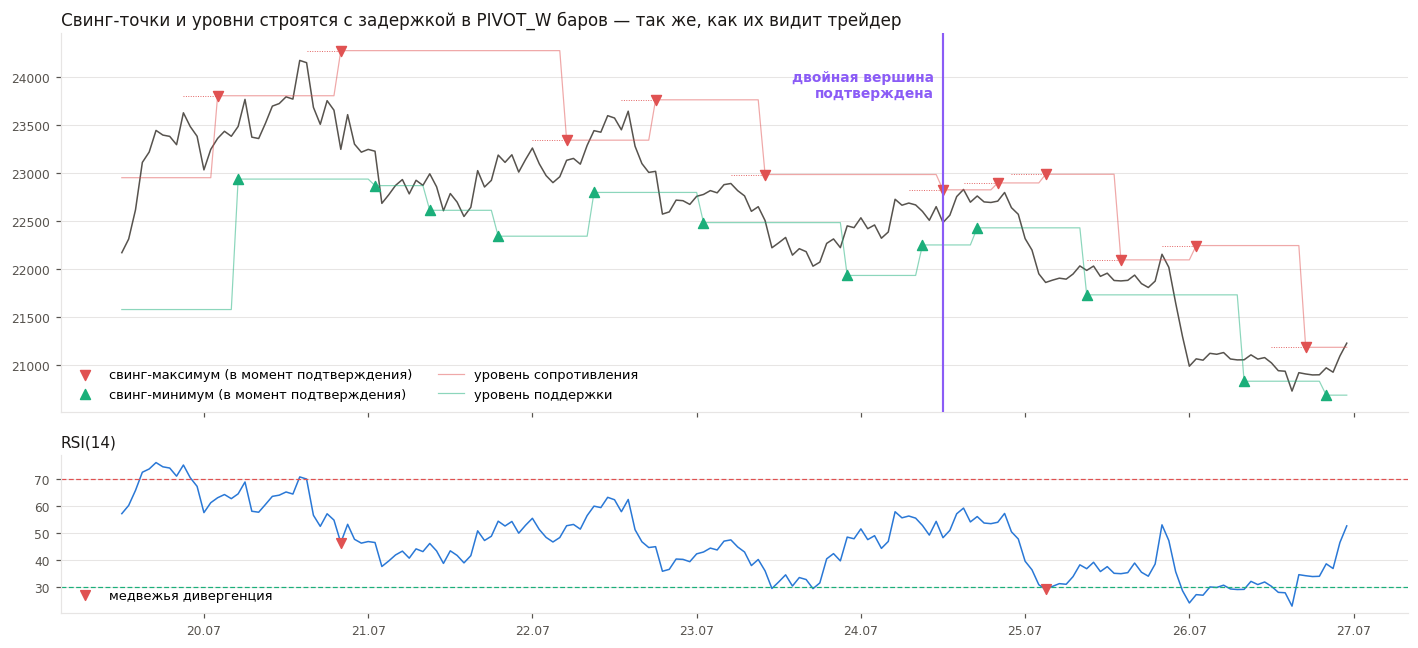

In [13]:
# Иллюстрация: свинг-точки, уровни и подтверждённая двойная вершина.
ph_p, pl_p = swing_points(raw["high"], raw["low"])
dt_hits = np.flatnonzero(chart_pat["pat_double_top"].to_numpy())
if len(dt_hits) == 0:          # на другом срезе двойных вершин может не найтись
    print("Двойных вершин на этом ряде не найдено — иллюстрация берёт произвольный участок.")
    dt_hits = np.array([len(raw) // 2])
i = int(dt_hits[len(dt_hits) // 2])
seg = raw.iloc[i - 120:i + 60]
x = seg["date"]

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True,
                              gridspec_kw={"height_ratios": [2.4, 1]})
ax.plot(x, seg["close"], color=INK_MUTED, linewidth=1.0, zorder=1)
conf_h = seg.index[ph_p.loc[seg.index].notna()]
conf_l = seg.index[pl_p.loc[seg.index].notna()]
ax.scatter(raw.loc[conf_h, "date"], ph_p.loc[conf_h], marker="v", s=42, color=DOWN,
           zorder=3, label="свинг-максимум (в момент подтверждения)")
ax.scatter(raw.loc[conf_l, "date"], pl_p.loc[conf_l], marker="^", s=42, color=UP,
           zorder=3, label="свинг-минимум (в момент подтверждения)")
for j in conf_h:                                        # поводок от подтверждения к самому экстремуму
    ax.plot([raw["date"].iloc[j - PIVOT_W], raw["date"].iloc[j]],
            [raw["high"].iloc[j - PIVOT_W], ph_p.loc[j]], color=DOWN, linewidth=0.6,
            linestyle=":", zorder=2)
ax.axvline(raw["date"].iloc[i], color=COLORS["Ensemble"], linewidth=1.4, zorder=4)
ax.annotate("двойная вершина\nподтверждена", xy=(raw["date"].iloc[i], seg["close"].max()),
            xytext=(-6, -6), textcoords="offset points", ha="right", va="top",
            fontsize=9, color=COLORS["Ensemble"], fontweight="bold")
ax.plot(x, sr_levels.loc[seg.index, "dist_resistance_atr"] * atr14.loc[seg.index] + seg["close"],
        color=DOWN, linewidth=0.8, alpha=0.5, label="уровень сопротивления")
ax.plot(x, seg["close"] - sr_levels.loc[seg.index, "dist_support_atr"] * atr14.loc[seg.index],
        color=UP, linewidth=0.8, alpha=0.5, label="уровень поддержки")
ax.set_title("Свинг-точки и уровни строятся с задержкой в PIVOT_W баров — так же, как их видит трейдер",
             color=INK, loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=8.5, loc="lower left", ncol=2)
style_ax(ax)

ax2.plot(x, rsi14_raw.loc[seg.index], color=COLORS["LogisticRegression"], linewidth=1.0)
ax2.axhline(70, color=DOWN, linewidth=0.8, linestyle=(0, (4, 2)))
ax2.axhline(30, color=UP, linewidth=0.8, linestyle=(0, (4, 2)))
div = seg.index[chart_pat.loc[seg.index, "pat_bear_divergence"] > 0]
ax2.scatter(raw.loc[div, "date"], rsi14_raw.loc[div], s=40, color=DOWN, marker="v", zorder=3,
            label="медвежья дивергенция")
ax2.set_title("RSI(14)", color=INK, loc="left", fontsize=10)
ax2.legend(frameon=False, fontsize=8.5, loc="lower left")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax2)
fig.tight_layout()
plt.show()

## 6. Паттерны продолжения

Разворотные паттерны отвечают на вопрос «не закончился ли тренд». Паттерны продолжения —
на обратный: «тренд взял паузу или всё-таки развернулся». Реализованы:

- **пробой канала Дончиана** (`breakout_up/dn`) — закрытие выше максимума / ниже минимума
  предыдущих N баров; классический сигнал продолжения тренда;
- **флаг и вымпел** — сильный импульс (движение больше 2 ATR за 12 баров), после которого
  диапазон сжимается, а объём падает; это консолидация внутри тренда, а не разворот;
- **сжатие волатильности** (`bb_squeeze`, `ttm_squeeze`) — ширина полос Боллинджера в нижнем
  квинтиле недельного распределения либо полосы внутри канала Кельтнера; за сжатием обычно
  следует направленное движение;
- **коэффициент эффективности Кауфмана** — доля направленного движения в общем пути цены;
- **серии** — сколько баров подряд цена держится выше EMA20, длина серии внутренних баров,
  длина серии однонаправленных баров.

## 7. Сборка признаков

Все признаки собираются в один датафрейм и группируются по смыслу. К десяти группам
технического анализа здесь добавляются четыре новые: «Фурье», «вейвлет», «CWT» и «новости».

### 7.1 Признаки преобразования Фурье и вейвлет-разложения

Все 246 признаков предыдущего раздела описывают ряд **во временной области**: уровень, наклон,
размах, положение относительно уровней. Ни один из них не отвечает на вопрос, **как энергия
движения распределена по масштабам** — сколько в последней неделе от быстрых колебаний с
периодом в пару часов, а сколько от медленного дрейфа. Это и добавляют два преобразования.

**Преобразование Фурье** раскладывает окно на синусоиды и даёт распределение энергии по
частотам. Из спектра берутся не сами гармоники (их амплитуды на финансовом ряде — шум), а
**форма спектра**: доли энергии в частотных полосах, спектральная энтропия и плоскостность,
наклон спектра в логарифмических координатах, доминирующий период и скорость изменения спектра
от бара к бару.

**Вейвлет-разложение** решает ту же задачу, но не теряет привязку ко времени: коэффициент уровня
`Dj` говорит, что происходило на масштабе `2^j` баров **в конкретный момент**. Отсюда —
распределение энергии по уровням, вейвлет-энтропия, последние коэффициенты каждого уровня
(многомасштабный аналог импульса) и отклонение цены от вейвлет-сглаженного тренда.

**Главная опасность здесь — заглядывание в будущее, и она не теоретическая.** Классическая
ошибка выглядит так: применить `fft` или `wavedec` ко **всему ряду** и разложить коэффициенты
обратно по времени. Каждый коэффициент такого разложения зависит от всего ряда, включая будущее,
поэтому признак на баре `t` знает, что случится после `t`. ROC-AUC от этого подскакивает до
0.9, а стратегия рассыпается в реальной торговле.

Поэтому здесь всё считается **на скользящем окне, заканчивающемся на баре `t`**: окно
`[t-W+1 ... t]`, преобразование внутри окна, признак — характеристика этого окна. Краевые
эффекты (симметричное продолжение вейвлета, окно Ханна у Фурье) тоже задействуют только бары
внутри окна. Проверка на утечку из раздела 7.4 пересчитывает все признаки на обрезанном ряде и
сравнивает с полным — если бы хоть один из новых признаков подглядывал, тест бы это поймал.

**Что подаётся на вход.** Спектральные признаки считаются по **логарифмическим доходностям**,
а не по ценам: спектр нестационарного ряда цен — это почти целиком гигантский пик на нулевой
частоте, и всё остальное тонет в нём. Признаки тренда — по логарифму цены, потому что именно там
тренд и живёт.

| семейство | окно | вход | что извлекается |
|---|---|---|---|
| Фурье | 168 ч (неделя) и 512 ч (три недели) | лог-доходности | доли энергии в 5 полосах периодов, энтропия, плоскостность, наклон спектра, доминирующий период и его доля, спектральный поток |
| вейвлет | 256 ч | лог-доходности | доли энергии по уровням D1–D5 и A5, вейвлет-энтропия, отношение высоких частот к низким, последние коэффициенты уровней, доля шума по универсальному порогу |
| вейвлет | 256 ч | логарифм цены | отклонение от сглаженного тренда и наклон тренда |

In [14]:
import pywt

FFT_WINDOWS = (168, 512)       # неделя и три недели часовых баров
FFT_BANDS = ((2, 4), (4, 8), (8, 24), (24, 72), (72, None))   # полосы по периоду, в часах
WAVELET_WINDOW = 256           # степень двойки: чистое разложение на 5 уровней
WAVELET_NAME = "db4"           # Добеши-4: компромисс между гладкостью и длиной фильтра
WAVELET_LEVEL = 5              # D1..D5 покрывают периоды примерно от 2 до 64 баров
WAVELET_MODE = "symmetric"     # краевое продолжение — только барами внутри окна


def rolling_matrix(series, w):
    """Матрица окон: строка i — бары [i ... i+w-1] исходного ряда.

    Результат короче ряда на w-1: у первых баров окна ещё нет. Выравнивание к бару t
    делает `align_to_bars` — здесь возвращается «сырое» представление без копий.
    """
    a = np.nan_to_num(np.asarray(series, dtype=np.float64), nan=0.0, posinf=0.0, neginf=0.0)
    return np.lib.stride_tricks.sliding_window_view(a, w)


def align_to_bars(values, w, index):
    """Признак окна, заканчивающегося на баре t, кладётся в позицию t. Первые w-1 баров — NaN."""
    return pd.Series(np.concatenate([np.full(w - 1, np.nan), np.asarray(values, float)]),
                     index=index)


def fourier_features(logret, index):
    """Форма спектра скользящего окна лог-доходностей.

    Берутся характеристики распределения энергии по частотам, а не сами гармоники: амплитуда
    отдельной гармоники на финансовом ряде неустойчива и от окна к окну скачет, а форма
    спектра — устойчивая характеристика режима.
    """
    cols = {}
    for w in FFT_WINDOWS:
        win = rolling_matrix(logret, w)
        win = win - win.mean(axis=1, keepdims=True)          # снимаем среднее окна
        # окно Ханна: без него резкий обрыв на краях «размазывает» энергию по всему спектру
        spec = np.abs(np.fft.rfft(win * np.hanning(w), axis=1)) ** 2
        spec, freqs = spec[:, 1:], np.fft.rfftfreq(w)[1:]    # нулевая частота — это среднее
        periods = 1.0 / freqs
        total = spec.sum(axis=1) + 1e-300
        p = spec / total[:, None]

        for lo, hi in FFT_BANDS:
            mask = (periods >= lo) & (periods < (hi if hi is not None else np.inf))
            name = f"fft{w}_e_{lo}_{hi}" if hi is not None else f"fft{w}_e_{lo}p"
            cols[name] = align_to_bars(p[:, mask].sum(axis=1), w, index)

        # энтропия спектра: 1 — энергия размазана ровно (белый шум), 0 — вся в одной частоте
        cols[f"fft{w}_entropy"] = align_to_bars(
            -(p * np.log(p + 1e-300)).sum(axis=1) / np.log(p.shape[1]), w, index)
        # плоскостность (мера Винера): отношение среднего геометрического к арифметическому
        cols[f"fft{w}_flatness"] = align_to_bars(
            np.exp(np.log(spec + 1e-300).mean(axis=1)) / (spec.mean(axis=1) + 1e-300), w, index)
        # наклон спектра в логарифмических координатах: показатель степени в законе 1/f^a
        xc = np.log(freqs) - np.log(freqs).mean()
        yc = np.log(spec + 1e-300)
        yc = yc - yc.mean(axis=1, keepdims=True)
        cols[f"fft{w}_slope"] = align_to_bars((yc @ xc) / (xc @ xc), w, index)
        # доминирующий период и его доля в энергии
        cols[f"fft{w}_dom_period"] = align_to_bars(np.log(periods[p.argmax(axis=1)]), w, index)
        cols[f"fft{w}_dom_share"] = align_to_bars(p.max(axis=1), w, index)
        # спектральный поток: насколько форма спектра изменилась за бар
        flux = np.concatenate([[np.nan], np.sqrt(((p[1:] - p[:-1]) ** 2).sum(axis=1))])
        cols[f"fft{w}_flux"] = align_to_bars(flux, w, index)
    return cols


def wavelet_features(logret, logprice, index):
    """Многомасштабное разложение скользящего окна: энергия по уровням и вейвлет-тренд."""
    w = WAVELET_WINDOW
    win_r = rolling_matrix(logret, w)
    coeffs = pywt.wavedec(win_r, WAVELET_NAME, level=WAVELET_LEVEL, axis=1, mode=WAVELET_MODE)
    names = ["a5", "d5", "d4", "d3", "d2", "d1"]             # порядок, в котором отдаёт wavedec
    energy = np.stack([(c ** 2).sum(axis=1) for c in coeffs], axis=1)
    rel = energy / (energy.sum(axis=1, keepdims=True) + 1e-300)

    cols = {}
    for j, nm in enumerate(names):
        cols[f"wl_e_{nm}"] = align_to_bars(rel[:, j], w, index)
    cols["wl_entropy"] = align_to_bars(
        -(rel * np.log(rel + 1e-300)).sum(axis=1) / np.log(len(names)), w, index)
    # быстрые масштабы против медленных: растёт, когда рынок «дрожит», а не движется
    cols["wl_hf_lf"] = align_to_bars(
        np.log((rel[:, 5] + rel[:, 4] + 1e-9) / (rel[:, 0] + rel[:, 1] + 1e-9)), w, index)

    # последний коэффициент каждого уровня — многомасштабный аналог импульса, со знаком
    sd = win_r.std(axis=1) + 1e-12
    for j, nm in enumerate(names[1:], start=1):
        cols[f"wl_last_{nm}"] = align_to_bars(coeffs[j][:, -1] / sd, w, index)

    # доля энергии деталей ниже универсального порога — «сколько в движении шума»
    sigma = np.median(np.abs(coeffs[-1]), axis=1) / 0.6745    # робастная оценка шума по D1
    thr = (sigma * np.sqrt(2 * np.log(w)))[:, None]
    det_energy = sum((c ** 2).sum(axis=1) for c in coeffs[1:]) + 1e-300
    kept = sum((np.where(np.abs(c) > thr, c, 0.0) ** 2).sum(axis=1) for c in coeffs[1:])
    cols["wl_noise_share"] = align_to_bars(1.0 - kept / det_energy, w, index)

    # вейвлет-сглаживание цены: тренд — реконструкция по одной аппроксимации
    win_p = rolling_matrix(logprice, w)
    cp = pywt.wavedec(win_p, WAVELET_NAME, level=WAVELET_LEVEL, axis=1, mode=WAVELET_MODE)
    trend = pywt.waverec([cp[0]] + [np.zeros_like(c) for c in cp[1:]],
                         WAVELET_NAME, axis=1, mode=WAVELET_MODE)[:, :w]
    cols["wl_trend_dev"] = align_to_bars((win_p[:, -1] - trend[:, -1]) / sd, w, index)
    cols["wl_trend_slope_24"] = align_to_bars((trend[:, -1] - trend[:, -25]) / (24 * sd), w, index)
    cols["wl_trend_curv"] = align_to_bars(
        (trend[:, -1] - 2 * trend[:, -25] + trend[:, -49]) / (24 * sd), w, index)
    return cols


print(f"Фурье: окна {FFT_WINDOWS}, полосы по периоду {FFT_BANDS}")
print(f"Вейвлет: {WAVELET_NAME}, окно {WAVELET_WINDOW} баров, {WAVELET_LEVEL} уровней, "
      f"краевой режим «{WAVELET_MODE}»")
print("Уровни детализации покрывают периоды: " +
      ", ".join(f"D{j} ≈ {2 ** j}–{2 ** (j + 1)} ч" for j in range(1, WAVELET_LEVEL + 1)) +
      f", A{WAVELET_LEVEL} — всё медленнее {2 ** (WAVELET_LEVEL + 1)} ч")

Фурье: окна (168, 512), полосы по периоду ((2, 4), (4, 8), (8, 24), (24, 72), (72, None))
Вейвлет: db4, окно 256 баров, 5 уровней, краевой режим «symmetric»
Уровни детализации покрывают периоды: D1 ≈ 2–4 ч, D2 ≈ 4–8 ч, D3 ≈ 8–16 ч, D4 ≈ 16–32 ч, D5 ≈ 32–64 ч, A5 — всё медленнее 64 ч


### 7.2 Вейвлет и Фурье преобразования

**1. Масштабограмма CWT** — из `Вейвлет_преобразование_CWT` и
`Вейвлет_преобразование_для_временных_рядов`.

Главный аргумент этих примеров стоит того, чтобы его повторить: **DWT «сваливает» все близкие
частоты в одну корзину**. В примере с голосом это показано наглядно — 120 Гц и 210 Гц попадают
в один уровень разложения, и DWT их не различает, а CWT различает. У нас та же беда в другом
масштабе: пять уровней `db4` покрывают периоды 2–4, 4–8, 8–16, 16–32 и 32–64 часа, то есть всё
разрешение по частоте — пять корзин. Непрерывное преобразование с 16 масштабами даёт втрое
более подробную картину.

Из примера взят и способ превращать масштабограмму в признаки: `np.mean(np.abs(coefficients),
axis=1)` — усреднение модуля коэффициентов по времени, вектор размера «число масштабов».
Здесь к этому добавлен **профиль последней точки окна**: усреднение по времени описывает режим
окна в целом, а последний столбец масштабограммы — состояние ряда прямо сейчас, и для прогноза
следующего бара это разные вещи.

**2. Денойзинг мягким порогом с реконструкцией** — из `Фильтрация_ВР_вейвлетами`.

В разделе 7.1 доля шума считалась по энергии коэффициентов ниже порога, но сам очищенный ряд не
восстанавливался. Пример делает именно это: `pywt.threshold(c, thr, mode="soft")` по всем
уровням деталей, затем `pywt.waverec`. Отсюда появляются признаки, которых иначе не получить:
отношение сигнал/шум в окне (в примере — `np.std(signal)/np.std(noise)`), очищенное от шума
значение последнего бара и то, что из него вычли.

Порог здесь не фиксированный, как в примере (`threshold = 0.2` для синтетического сигнала), а
универсальный `σ√(2 ln N)` с робастной оценкой `σ` по коэффициентам первого уровня: на реальном
ряде с меняющейся волатильностью фиксированное число превратилось бы в «всё срезать» на
спокойном участке и «ничего не срезать» на бурном.

**3. Топ-N пиков спектра** — из `Преобразование_Фурье`.

Пример извлекает признаки как `np.argsort(amplitudes)[-top_n:]` — периоды и амплитуды
нескольких самых сильных гармоник. В разделе 7.1 брался только первый пик; здесь добавлены
второй и третий.

**Чего из примеров брать не стал и почему:**

- `Извлечение_признаков_tsfresh` и `tsfel_OTUS` — автоматическая генерация сотен признаков.
  На скользящем окне по 38 тысячам баров это на порядки дороже всего остального ноутбука, а
  спектральная часть их наборов (`fft_coefficient`, `fft_aggregated`, `cwt_coefficients`) — это
  ровно то, что уже посчитано вручную в 7.1. Разумное применение этих библиотек — разведка на
  подвыборке, а не рабочий конвейер.
- `Time_Series_Bag_of_Features` (`pyts`) — представление **целого ряда** мешком локальных
  паттернов для классификации рядов между собой. У нас задача другая: один ряд, метка на каждом
  баре. Прямого переноса нет.
- `Вейвлет_преобразование` — тот же материал, что и в двух взятых примерах, на аудиоданных.

**Причинность остаётся главным ограничением.** Все примеры применяют преобразование ко всему
ряду сразу — для иллюстрации это правильно, для признаков прогнозной модели недопустимо. Как и
в 7.1, здесь всё считается на скользящем окне, заканчивающемся на текущем баре, и проверяется
тестом из 7.4.

In [15]:
# Вейвлет и Фурье преобразования: масштабограмма CWT, денойзинг мягким порогом, топ-N пиков спектра.
CWT_WAVELET = "morl"                          # вейвлет Морле — как в примере с CWT
CWT_SCALES = np.geomspace(2, 64, 16)          # 16 масштабов вместо 5 уровней DWT
CWT_CHUNK = 4000                              # окна считаются частями: вся матрица не влезет
CWT_PERIODS = 1.0 / pywt.scale2frequency(CWT_WAVELET, CWT_SCALES)   # масштаб -> период, часов
FFT_TOP_PEAKS = 3                             # сколько пиков спектра брать (в примере top_n = 8)


def cwt_features(logret, index):
    """Масштабограмма скользящего окна: усреднение по времени и профиль последней точки.

    Усреднение `np.abs(coefficients).mean(axis=время)` — приём из примера: оно описывает режим
    окна целиком. Профиль последнего столбца добавлен здесь: для прогноза следующего бара важно
    не только то, каким было окно, но и то, на каком масштабе движение идёт прямо сейчас.
    """
    w = WAVELET_WINDOW
    win = rolling_matrix(logret, w)
    n_win, n_sc = len(win), len(CWT_SCALES)
    mean_e = np.empty((n_win, n_sc))
    last_e = np.empty((n_win, n_sc))
    for s in range(0, n_win, CWT_CHUNK):
        block = win[s:s + CWT_CHUNK]
        coef, _ = pywt.cwt(block, CWT_SCALES, CWT_WAVELET, axis=1)   # (масштабы, окна, время)
        energy = np.abs(coef) ** 2          # энергия — квадрат модуля, а не сам модуль: так
                                             # cwt_e_* соответствует своему названию (энергия),
                                             # как и аналогичные fft*_e_* (codex_report.md, п.27)
        mean_e[s:s + len(block)] = energy.mean(axis=2).T
        last_e[s:s + len(block)] = energy[:, :, -1].T

    share = mean_e / (mean_e.sum(axis=1, keepdims=True) + 1e-300)
    cols = {}
    for lo, hi in FFT_BANDS:
        mask = (CWT_PERIODS >= lo) & (CWT_PERIODS < (hi if hi is not None else np.inf))
        name = f"cwt_e_{lo}_{hi}" if hi is not None else f"cwt_e_{lo}p"
        cols[name] = align_to_bars(share[:, mask].sum(axis=1) if mask.any()
                                   else np.zeros(n_win), w, index)
    cols["cwt_entropy"] = align_to_bars(
        -(share * np.log(share + 1e-300)).sum(axis=1) / np.log(n_sc), w, index)
    cols["cwt_dom_period"] = align_to_bars(np.log(CWT_PERIODS[share.argmax(axis=1)]), w, index)
    # состояние «прямо сейчас»: на каком масштабе идёт движение в последней точке окна
    cols["cwt_now_dom_period"] = align_to_bars(
        np.log(CWT_PERIODS[last_e.argmax(axis=1)]), w, index)
    cols["cwt_now_power"] = align_to_bars(
        last_e.sum(axis=1) / (mean_e.sum(axis=1) + 1e-300), w, index)
    half = n_sc // 2
    cols["cwt_now_hf_lf"] = align_to_bars(
        np.log((last_e[:, :half].sum(axis=1) + 1e-12)
               / (last_e[:, half:].sum(axis=1) + 1e-12)), w, index)
    return cols


def wavelet_denoise_features(logret, index):
    """Денойзинг мягким порогом с реконструкцией — приём из «Фильтрация_ВР_вейвлетами».

    В отличие от примера порог не фиксированный, а универсальный `σ√(2 ln N)` с робастной
    оценкой σ по коэффициентам первого уровня: на ряде с меняющейся волатильностью постоянное
    число срезало бы всё на спокойном участке и ничего на бурном.
    """
    w = WAVELET_WINDOW
    win = rolling_matrix(logret, w)
    coeffs = pywt.wavedec(win, WAVELET_NAME, level=WAVELET_LEVEL, axis=1, mode=WAVELET_MODE)
    sigma = np.median(np.abs(coeffs[-1]), axis=1) / 0.6745
    thr = (sigma * np.sqrt(2 * np.log(w)))[:, None]
    denoised = [coeffs[0]] + [pywt.threshold(c, thr, mode="soft") for c in coeffs[1:]]
    rec = pywt.waverec(denoised, WAVELET_NAME, axis=1, mode=WAVELET_MODE)[:, :w]
    noise = win - rec
    sd = win.std(axis=1) + 1e-12

    zeroed = sum((np.abs(c) <= thr).sum(axis=1) for c in coeffs[1:])
    n_det = sum(c.shape[1] for c in coeffs[1:])
    return {
        # отношение сигнал/шум в окне — та же величина, что печатает пример
        "wl_snr": align_to_bars(np.log((win.std(axis=1) + 1e-12) / (noise.std(axis=1) + 1e-12)),
                                w, index),
        "wl_den_last": align_to_bars(rec[:, -1] / sd, w, index),
        "wl_noise_last": align_to_bars(noise[:, -1] / sd, w, index),
        "wl_zeroed_frac": align_to_bars(zeroed / n_det, w, index),
    }


def fourier_peak_features(logret, index):
    """Периоды и доли энергии второго и третьего пиков спектра — из «Преобразование_Фурье»."""
    cols = {}
    for w in FFT_WINDOWS:
        win = rolling_matrix(logret, w)
        win = win - win.mean(axis=1, keepdims=True)
        spec = np.abs(np.fft.rfft(win * np.hanning(w), axis=1)) ** 2
        spec, freqs = spec[:, 1:], np.fft.rfftfreq(w)[1:]
        periods = 1.0 / freqs
        p = spec / (spec.sum(axis=1, keepdims=True) + 1e-300)
        top = np.argsort(p, axis=1)[:, ::-1][:, :FFT_TOP_PEAKS]      # индексы top-N пиков
        rows = np.arange(len(p))[:, None]
        for k in range(1, FFT_TOP_PEAKS):                            # первый пик уже есть в 7.1
            cols[f"fft{w}_top{k + 1}_period"] = align_to_bars(
                np.log(periods[top[:, k]]), w, index)
            cols[f"fft{w}_top{k + 1}_share"] = align_to_bars(p[rows, top][:, k], w, index)
    return cols


print(f"CWT: вейвлет {CWT_WAVELET}, {len(CWT_SCALES)} масштабов, периоды "
      f"{CWT_PERIODS[0]:.1f}–{CWT_PERIODS[-1]:.1f} ч "
      f"(у DWT на том же окне — {WAVELET_LEVEL} уровней)")
print(f"Денойзинг: мягкий порог, универсальное правило sigma*sqrt(2*ln({WAVELET_WINDOW}))")
print(f"Пики спектра: берутся первые {FFT_TOP_PEAKS} (в разделе 7.1 был только первый)")

CWT: вейвлет morl, 16 масштабов, периоды 2.5–78.8 ч (у DWT на том же окне — 5 уровней)
Денойзинг: мягкий порог, универсальное правило sigma*sqrt(2*ln(256))
Пики спектра: берутся первые 3 (в разделе 7.1 был только первый)


### 7.3 Признаки из новостей: тональность, темы, интенсивность

Заголовок — это текст, а модели нужен вектор чисел. Превращение идёт в три шага, и каждый
отвечает за свою сторону новости.

**1. Тональность — FinBERT.** `ProsusAI/finbert` — BERT, дообученный на финансовых текстах;
это отраслевой стандарт для тональности в финансах, и он куда точнее универсальных моделей,
потому что «shares plunge» для него негатив, а не нейтральное описание. Модель выдаёт три
вероятности (positive / negative / neutral), из которых берётся **скалярная тональность
`p(pos) − p(neg)`** в диапазоне от −1 до +1.

Прежде чем применять модель к 139 тысячам заголовков, её стоит проверить — и проверить
правильно. **Financial PhraseBank независимой проверкой FinBERT быть не может:**
`ProsusAI/finbert` дообучен ровно на этом корпусе, поэтому прогон по его 4 846 предложениям
измеряет качество на обучающих данных. Такая цифра подтверждает, что веса загрузились и метки
классов не перепутаны; о работе модели на крипто-заголовках она не говорит ничего. Мы её
считаем, но как **воспроизведение опубликованной метрики**, а не как доказательство качества.
Независимая проверка обязана работать на целевом домене и на метках, которых FinBERT не
видел, — этим занят раздел 7.3.1.

**2. Тема — эмбеддинги MiniLM + PCA.** Тональность не различает «SEC подала иск» и «биржу
взломали»: обе новости негативные, но реакция рынка на них разная. Тему несёт эмбеддинг —
`all-MiniLM-L6-v2` даёт 384 числа на заголовок. Из этих 384 колонок оставляем 6 главных
компонент (**PCA**), причём **PCA обучается только на новостях обучающего периода**.

**3. Ключевые слова.** Пять тематических групп по регулярным выражениям — регулирование, ETF и
институции, взломы и мошенничество, майнинг и сеть, макроэкономика. Грубо, зато интерпретируемо
и устойчиво: доля таких заголовков за сутки — понятный признак, в отличие от компоненты PCA.

**Агрегация к барам.** Заголовок в момент τ идёт в бар `ceil(τ, 1 час)`. По бару считаются
мгновенные агрегаты: число заголовков, средняя и суммарная тональность, число позитивных и
негативных, число заголовков от крупных изданий, число попаданий в каждую тематическую группу и
покомпонентные суммы эмбеддинга. Дальше из них считаются скользящие признаки, и деление на
число заголовков окна превращает суммы в средние «на заголовок»: интенсивность в текущем баре
и за 6, 24 и 168 часов, всплеск потока относительно месячной медианы, взвешенная числом
новостей тональность за сутки и за неделю, её импульс, разброс во времени (`news_disagree_24` —
std средней по бару тональности за сутки; спор изданий внутри одного часа здесь не измеряется),
доля негативных и позитивных заголовков, доля заголовков от крупных изданий, доли тематических
групп, компоненты эмбеддинга за неделю и время с последней новости — всего 24 признака.

Отдельно стоит сказать про **всплеск потока** (`news_burst`): отношение числа новостей за сутки
к медиане за месяц. В литературе по новостному трейдингу это часто сильнее тональности — важно
не что написали, а что вообще заговорили.

In [16]:
# Тональность заголовков: FinBERT. Скорер сначала воспроизводит опубликованную метрику,
# потом проверяется на целевом домене (раздел 7.3.1) и только потом идёт в признаки.
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
from sklearn.decomposition import PCA

FINBERT = "ProsusAI/finbert"
EMBEDDER = "sentence-transformers/all-MiniLM-L6-v2"
NEWS_BATCH = 256
NEWS_MAXLEN = 64            # заголовки короткие; 64 токена покрывают их с запасом
NEWS_PCA_K = 6
NEWS_TIER1 = ("Reuters", "Bloomberg", "CNBC", "Financial Times", "The Wall Street Journal",
              "Business Insider", "Forbes", "Fortune")
NEWS_KEYWORDS = {
    "regul": r"\bsec\b|regulat|\bban\b|lawsuit|court|\btax|sanction|lawmaker",
    "etf": r"\betf\b|blackrock|institution|custody|grayscale|spot bitcoin",
    "risk": r"hack|exploit|breach|stolen|scam|fraud|bankrupt|collapse",
    "mining": r"mining|miner|hashrate|halving|difficulty",
    "macro": r"\bfed\b|inflation|rate hike|\bcpi\b|dollar|recession|treasury",
}


@torch.no_grad()
def score_texts(texts, model, tokenizer, mode, batch=NEWS_BATCH):
    """Прогон текстов через модель: mode='cls' — вероятности классов, 'emb' — эмбеддинги."""
    out = []
    for s in range(0, len(texts), batch):
        enc = tokenizer(list(texts[s:s + batch]), return_tensors="pt", padding=True,
                        truncation=True, max_length=NEWS_MAXLEN).to(DEVICE)
        if mode == "cls":
            out.append(torch.softmax(model(**enc).logits, dim=-1).float().cpu().numpy())
        else:                                    # усреднение по токенам с учётом маски
            h = model(**enc).last_hidden_state
            m = enc["attention_mask"].unsqueeze(-1).float()
            out.append(((h * m).sum(1) / m.sum(1)).float().cpu().numpy())
    return np.vstack(out)


fin_tok = AutoTokenizer.from_pretrained(FINBERT)
fin_model = AutoModelForSequenceClassification.from_pretrained(FINBERT).to(DEVICE).eval()
label_pos = {v: k for k, v in fin_model.config.id2label.items()}
print(f"{FINBERT}: revision {getattr(fin_model.config, '_commit_hash', 'неизвестна')}")


def sent_scalar(texts):
    """Скалярная тональность p(pos) − p(neg) для списка текстов."""
    p = score_texts(np.asarray(texts, dtype=object), fin_model, fin_tok, "cls")
    return p[:, label_pos["positive"]] - p[:, label_pos["negative"]]


# ── шаг 0: PhraseBank — воспроизведение опубликованной метрики, НЕ независимая проверка ────
# ProsusAI/finbert дообучен на Financial PhraseBank, поэтому эти 4 846 предложений для него —
# обучающая выборка. Цифра ниже подтверждает только то, что модель загружена правильно и
# метки классов не перепутаны местами. Независимая проверка — в разделе 7.3.1.
bank = pd.read_csv(PHRASEBANK_PATH, encoding="latin-1")
bank_p = score_texts(bank["headline"].to_numpy(), fin_model, fin_tok, "cls")
bank_pred = np.array([fin_model.config.id2label[i] for i in bank_p.argmax(1)])
bank_acc = float((bank_pred == bank["sentiment"].to_numpy()).mean())
print(f"FinBERT на Financial PhraseBank ({len(bank)} предложений): accuracy = {bank_acc:.3f}")
display(pd.crosstab(bank["sentiment"], bank_pred, rownames=["разметка"], colnames=["FinBERT"]))
print("ВАЖНО: это НЕ независимая проверка. Financial PhraseBank — корпус, на котором FinBERT")
print("дообучали, так что здесь измеряется качество на обучающих данных: цифра подтверждает")
print("корректность загрузки весов и порядок классов, но не переносимость на крипто-заголовки.")
print("Независимая проверка на целевом домене — раздел 7.3.1.\n")

# ── шаг 1: тональность всех заголовков рабочего периода ────────────────────
t_start = time.perf_counter()
probs = score_texts(news["title"].to_numpy(), fin_model, fin_tok, "cls")
news["p_pos"] = probs[:, label_pos["positive"]]
news["p_neg"] = probs[:, label_pos["negative"]]
news["sent"] = news["p_pos"] - news["p_neg"]
print(f"FinBERT: {len(news)} заголовков за {(time.perf_counter() - t_start) / 60:.1f} мин; "
      f"средняя тональность {news['sent'].mean():+.3f}, "
      f"позитивных {float((news['sent'] > 0.2).mean()):.1%}, "
      f"негативных {float((news['sent'] < -0.2).mean()):.1%}")

ProsusAI/finbert: revision 4556d13015211d73dccd3fdd39d39232506f3e43


FinBERT на Financial PhraseBank (4846 предложений): accuracy = 0.889


FinBERT,negative,neutral,positive
разметка,,,
negative,586,11,7
neutral,124,2467,288
positive,22,86,1255


ВАЖНО: это НЕ независимая проверка. Financial PhraseBank — корпус, на котором FinBERT
дообучали, так что здесь измеряется качество на обучающих данных: цифра подтверждает
корректность загрузки весов и порядок классов, но не переносимость на крипто-заголовки.
Независимая проверка на целевом домене — раздел 7.3.1.



FinBERT: 69421 заголовков за 2.5 мин; средняя тональность +0.020, позитивных 29.3%, негативных 24.9%


#### 7.3.1 Независимая проверка скорера на крипто-заголовках

Три проверки ниже отличаются от прогона по PhraseBank тем, что метки в них FinBERT не видел:
слово-якорь в самом заголовке, антоним внутри минимальной пары и доходность бара.

Оговорка про домен: поток собран вокруг биткоина, но это лента финансовых СМИ, и часть
заголовков — про акции и макроэкономику (см. раздел 1.2). Поэтому первые две проверки измеряют
полярность **финансового заголовка вообще**, а доля заголовков с прямым упоминанием BTC
печатается рядом, чтобы не выдавать одно за другое.

Что именно должна показать каждая:

- **Якоря** — необходимое условие. Тональность заголовков с `surges/soars/rallies` должна
  отличаться от тональности заголовков с `plunges/crashes/tumbles`. Тест слабый (модель видит
  само слово), но если он не проходит, весь блок тональности можно выбрасывать.
- **Минимальные пары** — чувствительность к полярности при фиксированной теме. Заголовок
  «Bitcoin surges past $70,000» и «Bitcoin plunges past $70,000» отличаются одним словом, и
  разность тональностей внутри пары не может объясняться темой, издательством или длиной.
- **Кросс-корреляция с ценой** — единственная проверка с внешней разметкой. Если тональность
  бара связана с доходностью того же и предшествующих часов, то скорер улавливает реальную
  полярность крипто-повестки. Если при этом связи с доходностью следующего часа нет — значит
  новость выходит вслед за движением, и предсказывать по ней нечего. Именно это разделение
  отвечает на вопрос «скорер плохой или сигнала нет».

1. Якоря: 9841 заголовков потока с однозначным словом направления (6165 «рост», 3676 «падение»); 46% из них прямо упоминают bitcoin или BTC.
   ROC-AUC тональности против якоря = 0.895, доля совпадений знака = 0.796


FinBERT (порог ±0.2),negative,neutral,positive
якорь,,,
падение,0.823,0.119,0.058
рост,0.198,0.179,0.623



2. Минимальные пары: 1497 заголовков, в каждом слово направления заменено антонимом.
   Знак разности верный в 91.5% пар, средняя разность тональности +0.736 (медиана +0.574)


,исходный заголовок,тональность,с заменённым словом,тональность
0,"Bitcoin, Ether down with top 10 cryptos, most ...",-0.956,"Bitcoin, Ether down with top 10 cryptos, most ...",-0.880
1,3 Cryptos to Buy Now for Extraordinary Gains,0.123,3 Cryptos to Buy Now for Extraordinary slumps,-0.016
2,"USD/INR: Rupee Snaps Two-Day Losing Streak, Ga...",-0.065,"USD/INR: Rupee Snaps Two-Day Losing Streak, sl...",-0.900
3,"GLOBAL MARKETS-Stocks rally, dollar gains as O...",0.710,"GLOBAL MARKETS-Stocks tumble, dollar gains as ...",-0.888



3. Кросс-корреляция часовой тональности с доходностью бара t + k (разметка — цена, не разметчик):


,Spearman ρ,p-value,баров
"сдвиг k, ч",,,
-6,0.0368,0.0000,24251
-5,0.0248,0.0001,24251
-4,0.0277,0.0000,24252
-3,0.0335,0.0000,24253
-2,0.0239,0.0002,24253
-1,0.0103,0.1097,24253
0,0.0016,0.8071,24253
1,0.0119,0.0645,24254
2,0.0000,0.9978,24254


   тот же час: ρ = +0.0016 (p = 0.81), предыдущий: ρ = +0.0103, следующий: ρ = +0.0119 (p = 0.065)


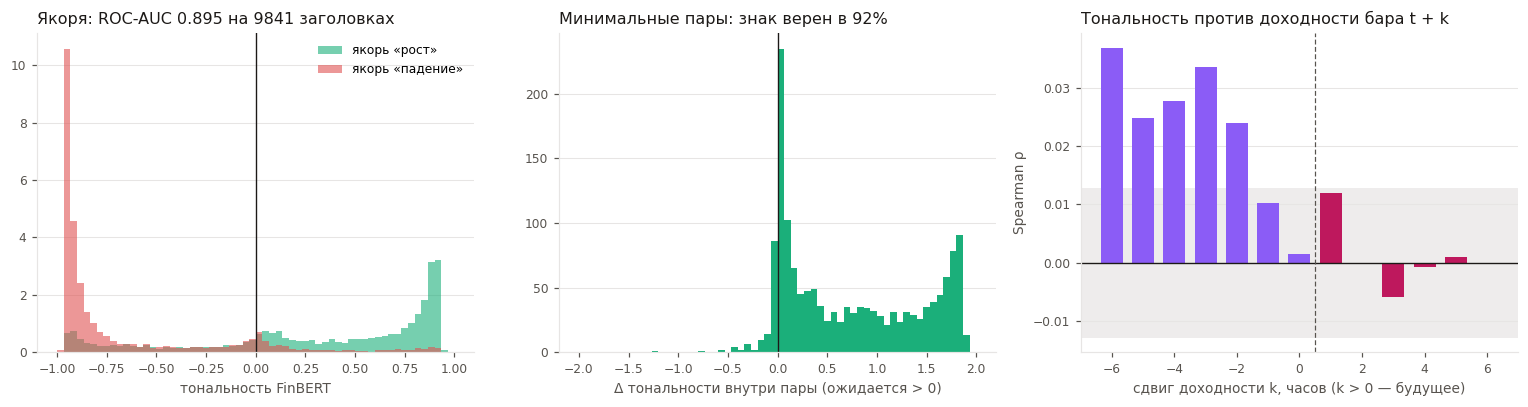

Серая полоса на правой панели — ±2/√n = ±0.0128, грубая граница значимости.
Вне полосы слева от пунктира (k <= 0, прошлое и текущий час): [-6, -5, -4, -3, -2].
Вне полосы справа (k > 0, будущее): ни одного сдвига.
Разметка в этой проверке — цена, а не разметчик, поэтому она и говорит, работает ли
скорер на крипто-заголовках: связь с уже случившимся движением означает, что
тональность улавливает реальную полярность, а её отсутствие в будущих барах — что
предсказывать по ней нечего.


In [17]:
# Независимая проверка скорера: якоря по направлению, минимальные пары, кросс-корреляция с ценой.
ANCHOR_PAIRS = [("surges", "plunges"), ("surge", "plunge"), ("soars", "sinks"),
                ("soar", "sink"), ("rallies", "tumbles"), ("rally", "tumble"),
                ("jumps", "drops"), ("jump", "drop"), ("climbs", "falls"), ("climb", "fall"),
                ("rises", "slides"), ("rise", "slide"), ("gains", "slumps"),
                ("gain", "slump"), ("spikes", "crashes"), ("spike", "crash")]
UP_WORDS = [u for u, _ in ANCHOR_PAIRS]
DN_WORDS = [d for _, d in ANCHOR_PAIRS]
ANTONYM = {**dict(ANCHOR_PAIRS), **{d: u for u, d in ANCHOR_PAIRS}}
N_PAIRS = 1500                      # сколько минимальных пар прогонять (по 2 прогона на пару)

low_titles = news["title"].str.lower()
up_hits = low_titles.str.count(r"\b(?:" + "|".join(UP_WORDS) + r")\b")
dn_hits = low_titles.str.count(r"\b(?:" + "|".join(DN_WORDS) + r")\b")

# ── проверка 1: направленные якоря ─────────────────────────────────────────
anchor_mask = ((up_hits > 0) & (dn_hits == 0)) | ((dn_hits > 0) & (up_hits == 0))
anchor = pd.DataFrame({
    "title": news.loc[anchor_mask, "title"].to_numpy(),
    "sent": news.loc[anchor_mask, "sent"].to_numpy(),
    "якорь": np.where(up_hits[anchor_mask] > 0, "рост", "падение"),
    # поток собран вокруг биткоина, но те же издания пишут и про акции с макро,
    # поэтому долю «про BTC» лучше показать честно, а не подразумевать
    "про btc": low_titles[anchor_mask].str.contains(r"bitcoin|\bbtc\b", regex=True).to_numpy(),
})
y_anchor = (anchor["якорь"] == "рост").astype(int).to_numpy()
anchor_auc = roc_auc_score(y_anchor, anchor["sent"].to_numpy())
anchor_acc = float(((anchor["sent"].to_numpy() > 0).astype(int) == y_anchor).mean())
fin_label = np.where(anchor["sent"] > 0.2, "positive",
                     np.where(anchor["sent"] < -0.2, "negative", "neutral"))
print(f"1. Якоря: {len(anchor)} заголовков потока с однозначным словом направления "
      f"({int(y_anchor.sum())} «рост», {int((1 - y_anchor).sum())} «падение»); "
      f"{anchor['про btc'].mean():.0%} из них прямо упоминают bitcoin или BTC.")
print(f"   ROC-AUC тональности против якоря = {anchor_auc:.3f}, "
      f"доля совпадений знака = {anchor_acc:.3f}")
display(pd.crosstab(anchor["якорь"], fin_label, rownames=["якорь"],
                    colnames=["FinBERT (порог ±0.2)"], normalize="index").round(3))

# ── проверка 2: минимальные пары ───────────────────────────────────────────
rng_pairs = np.random.default_rng(RANDOM_STATE)
pair_idx = rng_pairs.choice(len(anchor), size=min(N_PAIRS, len(anchor)), replace=False)
orig, flipped, direction = [], [], []
for t in anchor["title"].to_numpy()[pair_idx]:
    words = re.findall(r"[A-Za-z']+", t)
    hit = next((w for w in words if w.lower() in ANTONYM), None)
    if hit is None:
        continue
    orig.append(t)
    flipped.append(re.sub(rf"\b{re.escape(hit)}\b", ANTONYM[hit.lower()], t, count=1))
    direction.append("рост" if hit.lower() in ANTONYM and hit.lower() in UP_WORDS else "падение")

s_orig, s_flip = sent_scalar(orig), sent_scalar(flipped)
sign = np.where(np.array(direction) == "рост", 1.0, -1.0)
delta = sign * (s_orig - s_flip)          # ожидаем > 0: «растущий» вариант позитивнее
print(f"\n2. Минимальные пары: {len(orig)} заголовков, в каждом слово направления заменено "
      f"антонимом.")
print(f"   Знак разности верный в {float((delta > 0).mean()):.1%} пар, средняя разность "
      f"тональности {delta.mean():+.3f} (медиана {np.median(delta):+.3f})")
pairs_demo = pd.DataFrame({
    "исходный заголовок": orig[:4], "тональность": s_orig[:4].round(3),
    "с заменённым словом": flipped[:4], "тональность ": s_flip[:4].round(3),
})
display(pairs_demo)

# ── проверка 3: внешняя метка — доходность бара ────────────────────────────
# Тональность бара t — среднее по заголовкам, вышедшим в (t-1, t]; сравнивается с доходностью
# бара t + k. k < 0 — прошлое, k = 0 — тот же час, k > 0 — будущее. Разметка целиком рыночная.
LAGS = range(-6, 7)
sent_bar = (pd.DataFrame({"bar": news["dt"].dt.ceil("h"), "sent": news["sent"]})
            .groupby("bar")["sent"].mean().reindex(raw["date"].to_numpy()))
ret_bar = raw["close"].pct_change().to_numpy()
sent_v = sent_bar.to_numpy()
xcorr = []
for k in LAGS:
    r_shift = pd.Series(ret_bar).shift(-k).to_numpy()
    ok = np.isfinite(sent_v) & np.isfinite(r_shift)
    rho, pval = stats.spearmanr(sent_v[ok], r_shift[ok])
    xcorr.append({"сдвиг k, ч": k, "Spearman ρ": rho, "p-value": pval, "баров": int(ok.sum())})
xcorr = pd.DataFrame(xcorr).set_index("сдвиг k, ч")
print(f"\n3. Кросс-корреляция часовой тональности с доходностью бара t + k "
      f"(разметка — цена, не разметчик):")
display(xcorr.round(4))
rho_past, rho_now = xcorr.loc[-1, "Spearman ρ"], xcorr.loc[0, "Spearman ρ"]
rho_fut = xcorr.loc[1, "Spearman ρ"]
print(f"   тот же час: ρ = {rho_now:+.4f} (p = {xcorr.loc[0, 'p-value']:.2g}), "
      f"предыдущий: ρ = {rho_past:+.4f}, следующий: ρ = {rho_fut:+.4f} "
      f"(p = {xcorr.loc[1, 'p-value']:.2g})")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

ax = axes[0]
bins = np.linspace(-1, 1, 61)
ax.hist(anchor.loc[anchor["якорь"] == "рост", "sent"], bins=bins, color=UP, alpha=0.6,
        linewidth=0, label="якорь «рост»", density=True)
ax.hist(anchor.loc[anchor["якорь"] == "падение", "sent"], bins=bins, color=DOWN, alpha=0.6,
        linewidth=0, label="якорь «падение»", density=True)
ax.axvline(0, color=INK, linewidth=0.9)
ax.set_xlabel("тональность FinBERT", color=INK_MUTED, fontsize=9)
ax.set_title(f"Якоря: ROC-AUC {anchor_auc:.3f} на {len(anchor)} заголовках",
             color=INK, fontsize=10.5, loc="left")
ax.legend(frameon=False, fontsize=8)
style_ax(ax)

ax = axes[1]
ax.hist(delta, bins=np.linspace(-2, 2, 61), color=COLORS["CatBoost"], linewidth=0)
ax.axvline(0, color=INK, linewidth=0.9)
ax.set_xlabel("Δ тональности внутри пары (ожидается > 0)", color=INK_MUTED, fontsize=9)
ax.set_title(f"Минимальные пары: знак верен в {float((delta > 0).mean()):.0%}",
             color=INK, fontsize=10.5, loc="left")
style_ax(ax)

ax = axes[2]
ks = np.array(list(LAGS))
band = 2.0 / np.sqrt(float(xcorr["баров"].iloc[0]))
ax.axhspan(-band, band, color=GRID, alpha=0.7, linewidth=0)
ax.bar(ks, xcorr["Spearman ρ"].to_numpy(), width=0.7,
       color=[COLORS["Ensemble"] if k <= 0 else COLORS["TimesFM"] for k in ks])
ax.axhline(0, color=INK, linewidth=0.9)
ax.axvline(0.5, color=INK_MUTED, linewidth=0.8, linestyle=(0, (4, 2)))
ax.set_xlabel("сдвиг доходности k, часов (k > 0 — будущее)", color=INK_MUTED, fontsize=9)
ax.set_ylabel("Spearman ρ", color=INK_MUTED, fontsize=9)
ax.set_title("Тональность против доходности бара t + k", color=INK, fontsize=10.5,
             loc="left")
style_ax(ax)

fig.tight_layout()
plt.show()
rho_all = xcorr["Spearman ρ"]
past_out = [k for k in LAGS if k <= 0 and abs(rho_all.loc[k]) > band]
fut_out = [k for k in LAGS if k > 0 and abs(rho_all.loc[k]) > band]
print(f"Серая полоса на правой панели — ±2/√n = ±{band:.4f}, грубая граница значимости.")
print(f"Вне полосы слева от пунктира (k <= 0, прошлое и текущий час): "
      f"{past_out if past_out else 'ни одного сдвига'}.")
print(f"Вне полосы справа (k > 0, будущее): {fut_out if fut_out else 'ни одного сдвига'}.")
print("Разметка в этой проверке — цена, а не разметчик, поэтому она и говорит, работает ли")
print("скорер на крипто-заголовках: связь с уже случившимся движением означает, что")
print("тональность улавливает реальную полярность, а её отсутствие в будущих барах — что")
print("предсказывать по ней нечего.")

del fin_model
torch.cuda.empty_cache() if DEVICE.type == "cuda" else None

In [18]:
# Темы (эмбеддинги MiniLM + PCA) и агрегация всех новостных величин к часовым барам.

# ── шаг 2: эмбеддинги и PCA (обучается только на новостях обучающего периода) ──
t_start = time.perf_counter()
emb_tok = AutoTokenizer.from_pretrained(EMBEDDER)
emb_model = AutoModel.from_pretrained(EMBEDDER).to(DEVICE).eval()
print(f"{EMBEDDER}: revision {getattr(emb_model.config, '_commit_hash', 'неизвестна')}")
emb = score_texts(news["title"].to_numpy(), emb_model, emb_tok, "emb")
# Граница фита PCA — не train_df (TRAIN_END=0.70), а начало ПЕРВОГО фолда TimeSeriesSplit на
# dev: dev занимает первые TEST_END долей ряда, а TimeSeriesSplit(n_splits=N_CV_SPLITS) делит
# его на N_CV_SPLITS+1 частей примерно равного размера, и обучающая часть первого фолда — это
# первая такая часть. TRAIN_END почти совпадает с концом train_df, поэтому PCA, обученная до
# него, утекала бы в 4 из 5 CV-фолдов (их test-часть целиком внутри train_df), а не только в
# validation (codex_report.md, пункт 16). tscv/dev_df на этом шаге ноутбука ещё не существуют
# (PCA нужна раньше, для сборки признаков), поэтому граница берётся из тех же констант, из
# которых их размер потом получится: TEST_END / (N_CV_SPLITS + 1).
NEWS_FIT_END = raw["date"].iloc[int(len(raw) * TEST_END / (N_CV_SPLITS + 1))]
fit_mask = (news["dt"] < NEWS_FIT_END).to_numpy()
news_pca = PCA(n_components=NEWS_PCA_K, random_state=RANDOM_STATE).fit(emb[fit_mask])
emb_pca = news_pca.transform(emb)
print(f"MiniLM: эмбеддинги {emb.shape} за {(time.perf_counter() - t_start) / 60:.1f} мин; "
      f"PCA обучена на {int(fit_mask.sum())} заголовках до {NEWS_FIT_END:%Y-%m-%d} "
      f"(до начала обучающей части первого CV-фолда, а не до конца train_df — иначе PCA "
      f"утекала бы в test-часть большинства фолдов) и объясняет "
      f"{news_pca.explained_variance_ratio_.sum():.1%} дисперсии в {NEWS_PCA_K} компонентах")
del emb_model
torch.cuda.empty_cache() if DEVICE.type == "cuda" else None

# ── шаг 3: агрегация к барам ────────────────────────────────────────────────
low = news["title"].str.lower()
agg = pd.DataFrame({"bar": news["dt"].dt.ceil("h"), "sent": news["sent"],
                    "neg": (news["sent"] < -0.2).astype(float),
                    "pos": (news["sent"] > 0.2).astype(float),
                    "tier1": news["source"].isin(NEWS_TIER1).astype(float)})
for k, pat in NEWS_KEYWORDS.items():
    agg[f"kw_{k}"] = low.str.contains(pat, regex=True).astype(float)
for j in range(NEWS_PCA_K):
    agg[f"emb{j + 1}"] = emb_pca[:, j]

g = agg.groupby("bar")
NEWS_BAR = pd.DataFrame({"n_count": g.size(), "n_sent_mean": g["sent"].mean(),
                         "n_sent_sum": g["sent"].sum(), "n_neg": g["neg"].sum(),
                         "n_pos": g["pos"].sum(), "n_tier1": g["tier1"].sum()})
for k in NEWS_KEYWORDS:
    NEWS_BAR[f"n_kw_{k}"] = g[f"kw_{k}"].sum()
for j in range(NEWS_PCA_K):
    NEWS_BAR[f"n_emb{j + 1}"] = g[f"emb{j + 1}"].sum()
print(f"Агрегировано к {len(NEWS_BAR)} часовым барам "
      f"({len(NEWS_BAR) / len(raw):.0%} баров ряда содержат хотя бы одну новость)")

sentence-transformers/all-MiniLM-L6-v2: revision 1110a243fdf4706b3f48f1d95db1a4f5529b4d41


MiniLM: эмбеддинги (69421, 384) за 0.4 мин; PCA обучена на 14014 заголовках до 2021-08-17 (до начала обучающей части первого CV-фолда, а не до конца train_df — иначе PCA утекала бы в test-часть большинства фолдов) и объясняет 17.8% дисперсии в 6 компонентах


Агрегировано к 24766 часовым барам (64% баров ряда содержат хотя бы одну новость)


In [19]:
# Признаки из новостей: скользящие агрегаты по барам <= t.
NEWS_WINDOWS = (6, 24, 168)
NEWS_BURST_WINDOW = 720            # месяц: база для сравнения текущей активности


def news_features(df, index=None):
    """Новостные признаки для баров df. Все окна смотрят только назад.

    NEWS_BAR может начинаться раньше df["date"].min() — в news заранее включена 40-дневная
    предыстория (раздел 1.2), — но старый код сразу делал reindex по df["date"], обрезая
    предысторию до всех rolling-агрегатов: на первых барах df она просто не попадала в окна,
    хотя ради неё и была добавлена. Здесь агрегаты считаются на полном непрерывном часовом
    диапазоне NEWS_BAR (включая предысторию), и только в конце режутся на df (codex_report.md,
    пункт 29). При нынешнем прогреве индикаторов (680 баров) это по большей части уже
    покрывалось, но для самого раннего окна теперь действительно так, а не отдельным
    совпадением.
    """
    index = df.index if index is None else index
    full_start = min(NEWS_BAR.index.min(), df["date"].min())
    full_grid = pd.date_range(full_start, df["date"].max(), freq="h")
    fr = NEWS_BAR.reindex(full_grid)
    cnt_full = fr["n_count"].fillna(0.0)
    ssum_full = fr["n_sent_sum"].fillna(0.0)

    def wmean_full(numer, w):
        """Среднее по окну на полном диапазоне, взвешенное числом новостей."""
        return (numer.rolling(w, min_periods=1).sum()
                / (cnt_full.rolling(w, min_periods=1).sum() + 1e-9))

    def to_df(s):
        """Срез полного диапазона на бары df, с индексом df."""
        return pd.Series(s.reindex(df["date"].to_numpy()).to_numpy(), index=index)

    cols = {"news_count": to_df(np.log1p(cnt_full))}
    for w in NEWS_WINDOWS:
        cols[f"news_count_{w}"] = to_df(np.log1p(cnt_full.rolling(w, min_periods=1).sum()))
    # всплеск потока: сутки против месячной медианы — «о рынке вдруг заговорили»
    c24_full = cnt_full.rolling(24, min_periods=1).sum()
    cols["news_burst"] = to_df(
        c24_full / (c24_full.rolling(NEWS_BURST_WINDOW, min_periods=24).median() + 1.0))
    cols["news_bars_since"] = to_df(bars_since(cnt_full > 0))

    for w in (24, 168):
        cols[f"news_sent_{w}"] = to_df(wmean_full(ssum_full, w))
    cols["news_sent_mom"] = cols["news_sent_24"] - cols["news_sent_168"]
    cols["news_neg_24"] = to_df(wmean_full(fr["n_neg"].fillna(0.0), 24))
    cols["news_pos_24"] = to_df(wmean_full(fr["n_pos"].fillna(0.0), 24))
    # Разброс тональности ВО ВРЕМЕНИ: std средней по бару тональности за сутки. Это не спор
    # изданий внутри одного часа (для него нужна дисперсия внутри бара, её здесь нет), а
    # неустойчивость фона: когда тональность мечется, движение чаще резче.
    cols["news_disagree_24"] = to_df(fr["n_sent_mean"].rolling(24, min_periods=2).std())
    cols["news_tier1_24"] = to_df(wmean_full(fr["n_tier1"].fillna(0.0), 24))

    for k in NEWS_KEYWORDS:
        cols[f"news_kw_{k}"] = to_df(wmean_full(fr[f"n_kw_{k}"].fillna(0.0), 24))
    for j in range(NEWS_PCA_K):
        cols[f"news_emb{j + 1}"] = to_df(wmean_full(fr[f"n_emb{j + 1}"].fillna(0.0), 168))
    return cols

In [20]:
MA_WINDOWS = [5, 10, 20, 50, 100, 200]
RET_HORIZONS = [1, 2, 3, 6, 12, 24, 48, 72, 168]


def running_streak(sign_series):
    """Длина текущей серии одинаковых знаков: +n — n баров подряд вверх, -n — вниз."""
    s = pd.Series(sign_series).fillna(0).to_numpy()
    out = np.zeros(len(s))
    for i in range(1, len(s)):
        out[i] = out[i - 1] + s[i] if s[i] == s[i - 1] and s[i] != 0 else s[i]
    return pd.Series(out, index=pd.Series(sign_series).index)


def bars_since(flag, cap=500):
    """Сколько баров прошло с последнего срабатывания флага."""
    f = pd.Series(flag).fillna(False).to_numpy().astype(bool)
    out, last = np.empty(len(f)), -1
    for i in range(len(f)):
        if f[i]:
            last = i
        out[i] = (i - last) if last >= 0 else np.nan
    return pd.Series(np.minimum(out, cap), index=pd.Series(flag).index)


def build_ta_features(df, n_lags=N_LAGS):
    """Полная матрица признаков технического анализа. Возвращает (признаки, группы)."""
    o_, h_, l_, c_, v_ = (df[x] for x in OHLCV)
    X, groups = {}, {}

    def add(group, cols):
        groups.setdefault(group, []).extend(cols)
        X.update(cols)

    atr_s = atr(h_, l_, c_, 14)
    natr = atr_s / c_
    ret_1 = c_.pct_change()
    logret = np.log(c_).diff()

    # ── доходности и лаги ───────────────────────────────────────────────────
    cols = {}
    for k in RET_HORIZONS:
        cols[f"ret_{k}"] = c_.pct_change(k)
        cols[f"ret_{k}_atr"] = (c_ / c_.shift(k) - 1) / natr.replace(0, np.nan)   # ход в ATR
    for k in range(n_lags):
        cols[f"ret_lag_{k}"] = ret_1.shift(k)
    cols["logret_skew_24"] = logret.rolling(24).skew()
    cols["logret_kurt_24"] = logret.rolling(24).kurt()
    cols["up_bars_frac_24"] = (ret_1 > 0).rolling(24).mean()
    cols["ret_streak"] = running_streak(np.sign(ret_1.fillna(0)))
    add("доходности", cols)

    # ── скользящие средние ──────────────────────────────────────────────────
    cols, sma, ema = {}, {}, {}
    for w in MA_WINDOWS:
        sma[w] = c_.rolling(w).mean()
        ema[w] = c_.ewm(span=w, adjust=False).mean()
        cols[f"close_sma{w}_ratio"] = c_ / sma[w] - 1
        cols[f"close_ema{w}_ratio"] = c_ / ema[w] - 1
        cols[f"sma{w}_slope"] = sma[w].pct_change(max(3, w // 4))
        cols[f"close_sma{w}_atr"] = (c_ - sma[w]) / atr_s          # удалённость от MA в ATR
    for fast, slow in [(5, 20), (10, 50), (20, 50), (50, 200)]:
        spread = sma[fast] / sma[slow] - 1
        above = (spread > 0).astype(np.int8)
        up_cross = ((above == 1) & (above.shift(1) == 0)).astype(np.int8)
        dn_cross = ((above == 0) & (above.shift(1) == 1)).astype(np.int8)
        cols[f"ma_spread_{fast}_{slow}"] = spread
        cols[f"ma_above_{fast}_{slow}"] = above
        cols[f"ma_cross_up_{fast}_{slow}"] = up_cross               # «золотой крест»
        cols[f"ma_cross_dn_{fast}_{slow}"] = dn_cross               # «мёртвый крест»
        cols[f"bars_since_cross_{fast}_{slow}"] = bars_since((up_cross + dn_cross) > 0)
    ribbon = sum((sma[a] > sma[b]).astype(int) for a, b in zip(MA_WINDOWS[:-1], MA_WINDOWS[1:]))
    cols["ma_ribbon_score"] = ribbon / (len(MA_WINDOWS) - 1)        # упорядоченность «ленты» MA
    cols["price_above_all_ma"] = np.minimum.reduce([(c_ > sma[w]).to_numpy() for w in MA_WINDOWS]).astype(np.int8)
    cols["price_below_all_ma"] = np.minimum.reduce([(c_ < sma[w]).to_numpy() for w in MA_WINDOWS]).astype(np.int8)
    add("скользящие средние", cols)

    # ── осцилляторы импульса ────────────────────────────────────────────────
    cols = {}
    for n in (7, 14, 28):
        r = rsi(c_, n)
        cols[f"rsi_{n}"], cols[f"rsi_{n}_slope"] = r, r.diff(3)
    r14 = cols["rsi_14"]
    cols["rsi_overbought"] = (r14 > 70).astype(np.int8)
    cols["rsi_oversold"] = (r14 < 30).astype(np.int8)
    cols["rsi_cross_50_up"] = ((r14 > 50) & (r14.shift(1) <= 50)).astype(np.int8)
    cols["rsi_cross_50_dn"] = ((r14 < 50) & (r14.shift(1) >= 50)).astype(np.int8)
    k_, d_ = stochastic(h_, l_, c_, 14, 3)
    cols["stoch_k"], cols["stoch_d"], cols["stoch_diff"] = k_, d_, k_ - d_
    cols["williams_r"] = k_ - 100
    line, sig, hist = macd(c_)
    cols["macd"], cols["macd_signal"], cols["macd_hist"] = line / c_, sig / c_, hist / c_
    cols["macd_hist_slope"] = (hist / c_).diff(3)
    cols["macd_cross_up"] = ((hist > 0) & (hist.shift(1) <= 0)).astype(np.int8)
    cols["macd_cross_dn"] = ((hist < 0) & (hist.shift(1) >= 0)).astype(np.int8)
    adx_s, pdi, mdi = adx(h_, l_, c_, 14)
    cols["adx"], cols["di_plus"], cols["di_minus"] = adx_s, pdi, mdi
    cols["di_diff"], cols["adx_slope"] = pdi - mdi, adx_s.diff(3)
    cols["adx_strong_trend"] = (adx_s > 25).astype(np.int8)
    cols["cci_20"] = cci(h_, l_, c_, 20)
    au, ad = aroon(h_, l_, 25)
    cols["aroon_up"], cols["aroon_down"], cols["aroon_osc"] = au, ad, au - ad
    cols["mom_roc_12"] = c_.pct_change(12)
    cols["ultimate_bias"] = (c_ - (h_.rolling(24).max() + l_.rolling(24).min()) / 2) / atr_s
    add("осцилляторы", cols)

    # ── волатильность ───────────────────────────────────────────────────────
    cols = {}
    cols["atr_14"] = natr
    cols["atr_ratio_short_long"] = atr(h_, l_, c_, 7) / atr_s.replace(0, np.nan)
    cols["tr_atr"] = true_range(h_, l_, c_) / atr_s.replace(0, np.nan)
    for n in (24, 72, 168):
        cols[f"vol_{n}"] = logret.rolling(n).std(ddof=0)
    cols["vol_regime"] = cols["vol_24"] / cols["vol_168"].replace(0, np.nan)
    cols["vol_of_vol"] = cols["vol_24"].rolling(72).std(ddof=0) / cols["vol_24"].replace(0, np.nan)
    cols["parkinson_24"] = np.sqrt((np.log(h_ / l_) ** 2).rolling(24).mean() / (4 * np.log(2)))
    cols["garman_klass_24"] = np.sqrt((0.5 * np.log(h_ / l_) ** 2
                                       - (2 * np.log(2) - 1) * np.log(c_ / o_) ** 2)
                                      .rolling(24).mean().clip(lower=0))
    bb_mid, bb_std = c_.rolling(20).mean(), c_.rolling(20).std(ddof=0)
    cols["bb_pctb"] = (c_ - (bb_mid - 2 * bb_std)) / (4 * bb_std).replace(0, np.nan)
    cols["bb_width"] = (4 * bb_std) / bb_mid
    cols["bb_squeeze"] = (cols["bb_width"] < cols["bb_width"].rolling(168).quantile(0.20)).astype(np.int8)
    kc_mid = c_.ewm(span=20, adjust=False).mean()
    cols["kc_pos"] = (c_ - kc_mid) / (2 * atr_s).replace(0, np.nan)
    cols["ttm_squeeze"] = ((bb_mid + 2 * bb_std < kc_mid + 2 * atr_s) &
                           (bb_mid - 2 * bb_std > kc_mid - 2 * atr_s)).astype(np.int8)
    add("волатильность", cols)

    # ── объём ───────────────────────────────────────────────────────────────
    cols = {}
    logv_ = np.log1p(v_)
    cols["vol_z_24"], cols["vol_z_168"] = zscore(logv_, 24), zscore(logv_, 168)
    cols["vol_ratio_sma"] = v_ / v_.rolling(24).mean().replace(0, np.nan)
    cols["vol_change"] = logv_.diff()
    obv_s = obv(c_, v_)
    cols["obv_z"] = zscore(obv_s, 168)
    cols["obv_slope"] = obv_s.diff(24) / v_.rolling(24).sum().replace(0, np.nan)
    cols["mfi_14"] = mfi(h_, l_, c_, v_, 14)
    cols["cmf_20"] = cmf(h_, l_, c_, v_, 20)
    vwap = (((h_ + l_ + c_) / 3) * v_).rolling(24).sum() / v_.rolling(24).sum().replace(0, np.nan)
    cols["vwap_dev"] = c_ / vwap - 1
    cols["force_index"] = wilder(c_.diff() * v_, 13) / (atr_s * v_.rolling(24).mean()).replace(0, np.nan)
    cols["vol_price_corr_24"] = logret.rolling(24).corr(logv_.diff())
    add("объём", cols)

    # ── свечи: геометрия и паттерны ─────────────────────────────────────────
    cdl_df, anat = candlestick_patterns(o_, h_, l_, c_, atr_s)
    cols = {
        "body_frac": anat["body_frac"], "upper_frac": anat["upper_frac"],
        "lower_frac": anat["lower_frac"], "clv": anat["clv"],
        "range_atr": anat["rng"] / atr_s.replace(0, np.nan),
        "body_atr": anat["body"] / atr_s.replace(0, np.nan),
        "gap_open": o_ / c_.shift(1) - 1,
        "shadow_imbalance": (anat["upper"] - anat["lower"]) / anat["rng"],
    }
    cols.update({name: cdl_df[name] for name in cdl_df.columns})
    bull_cnt, bear_cnt = cdl_df[CANDLE_BULL].sum(axis=1), cdl_df[CANDLE_BEAR].sum(axis=1)
    cols["cdl_bull_score"], cols["cdl_bear_score"] = bull_cnt, bear_cnt
    cols["cdl_net_score"] = bull_cnt - bear_cnt
    cols["cdl_net_score_6"] = (bull_cnt - bear_cnt).rolling(6).sum()
    add("свечные паттерны", cols)

    # ── паттерны разворота ──────────────────────────────────────────────────
    pat_df, lvl = chart_patterns(h_, l_, c_, X["rsi_14"], atr_s)
    cols = {}
    for name in pat_df.columns:
        cols[name] = pat_df[name]
        cols[f"{name}_24"] = pat_df[name].rolling(24).max()      # паттерн «действует» ещё сутки
    cols.update({name: lvl[name] for name in lvl.columns})
    cols["dist_high_168_atr"] = (h_.rolling(168).max() - c_) / atr_s
    cols["dist_low_168_atr"] = (c_ - l_.rolling(168).min()) / atr_s
    cols["new_high_168"] = (c_ >= c_.rolling(168).max()).astype(np.int8)
    cols["new_low_168"] = (c_ <= c_.rolling(168).min()).astype(np.int8)
    cols["key_reversal_up"] = ((l_ < l_.shift(1).rolling(24).min()) & (c_ > c_.shift(1))).astype(np.int8)
    cols["key_reversal_dn"] = ((h_ > h_.shift(1).rolling(24).max()) & (c_ < c_.shift(1))).astype(np.int8)
    add("паттерны разворота", cols)

    # ── паттерны продолжения ────────────────────────────────────────────────
    cols = {}
    for n in (20, 55):
        dh, dl = h_.rolling(n).max(), l_.rolling(n).min()
        cols[f"donchian_pos_{n}"] = (c_ - dl) / (dh - dl).replace(0, np.nan)
        cols[f"donchian_width_{n}"] = (dh - dl) / atr_s
        cols[f"breakout_up_{n}"] = (c_ > dh.shift(1)).astype(np.int8)
        cols[f"breakout_dn_{n}"] = (c_ < dl.shift(1)).astype(np.int8)
    cols["er_20"], cols["er_72"] = efficiency_ratio(c_, 20), efficiency_ratio(c_, 72)
    impulse_up = (c_.shift(6) / c_.shift(18) - 1) > 2 * natr.shift(6)
    impulse_dn = (c_.shift(6) / c_.shift(18) - 1) < -2 * natr.shift(6)
    consolidation = (((h_.rolling(6).max() - l_.rolling(6).min()) / atr_s < 2.0) &
                     (v_.rolling(6).mean() < v_.rolling(24).mean()))
    cols["pat_bull_flag"] = (impulse_up & consolidation).astype(np.int8)
    cols["pat_bear_flag"] = (impulse_dn & consolidation).astype(np.int8)
    cols["pat_pennant"] = (consolidation & (X["bb_squeeze"] == 1)).astype(np.int8)
    cols["range_contraction"] = ((h_.rolling(6).max() - l_.rolling(6).min()) /
                                 (h_.rolling(24).max() - l_.rolling(24).min()).replace(0, np.nan))
    cols["inside_bar_streak"] = running_streak(cdl_df["cdl_inside_bar"].astype(int))
    cols["above_ema20_streak"] = running_streak((c_ > ema[20]).astype(int))
    cols["trend_continuation"] = (((X["adx"] > 25) & (X["adx_slope"] > 0) &
                                   (X["di_diff"].abs() > 5)).astype(np.int8) * np.sign(X["di_diff"]))
    add("паттерны продолжения", cols)

    # ── аномальность бара (раздел 2) ────────────────────────────────────────
    cols = {
        "anom_ret_z": robust_z(ret_1, ANOM_WIN),
        "anom_vol_z": robust_z(np.log1p(v_), ANOM_WIN),
        "anom_tr_z": robust_z(true_range(h_, l_, c_), ANOM_WIN),
    }
    cols["anom_ret_outlier"] = (cols["anom_ret_z"].abs() > OUTLIER_Z).astype(np.int8)
    cols["anom_vol_outlier"] = (cols["anom_vol_z"].abs() > OUTLIER_Z).astype(np.int8)
    # anom_any объединяет выбросы ТОЛЬКО доходности и объёма, без истинного диапазона —
    # он строго уже, чем объединение всех трёх показателей из раздела 2.1 (см. anom_flags.any()
    # там). Именно anom_any задаёт понижающий вес в sample_weights, поэтому бары, аномальные
    # только по диапазону, обучаются с полным весом.
    cols["anom_any"] = ((cols["anom_ret_outlier"] + cols["anom_vol_outlier"]) > 0).astype(np.int8)
    cols["anom_count_24"] = cols["anom_any"].rolling(24).sum()
    cols["anom_bars_since"] = bars_since(cols["anom_any"] > 0)
    add("аномалии", cols)

    # ── спектр и вейвлет-разложение (раздел 7.1) ────────────────────────────
    add("Фурье", {**fourier_features(logret, df.index),
                  **fourier_peak_features(logret, df.index)})
    add("вейвлет", {**wavelet_features(logret, np.log(c_), df.index),
                    **wavelet_denoise_features(logret, df.index)})
    add("CWT", cwt_features(logret, df.index))

    # ── новости (раздел 7.3) ────────────────────────────────────────────────
    add("новости", news_features(df))

    # ── календарь ───────────────────────────────────────────────────────────
    hour, dow = df["date"].dt.hour, df["date"].dt.dayofweek
    add("календарь", {
        "hour_sin": np.sin(2 * np.pi * hour / 24), "hour_cos": np.cos(2 * np.pi * hour / 24),
        "dow_sin": np.sin(2 * np.pi * dow / 7), "dow_cos": np.cos(2 * np.pi * dow / 7),
        "is_weekend": (dow >= 5).astype(np.int8),
    })

    return pd.concat([df, pd.DataFrame(X, index=df.index)], axis=1), groups


feat, FEATURE_GROUPS = build_ta_features(raw)
feature_cols = [c for g in FEATURE_GROUPS.values() for c in g]
assert len(feature_cols) == len(set(feature_cols)), "дублирующиеся имена признаков"

group_table = pd.DataFrame({
    "признаков": {g: len(cols) for g, cols in FEATURE_GROUPS.items()},
    "примеры": {g: ", ".join(cols[:3]) + (" …" if len(cols) > 3 else "")
                for g, cols in FEATURE_GROUPS.items()},
}).rename_axis("группа")
print(f"Всего признаков: {len(feature_cols)} (в ДЗ №2 было 24 лага доходности; здесь "
      f"N_LAGS={N_LAGS} — несоответствие с оригиналом ДЗ №2, а не подтверждённое точное "
      f"воспроизведение его baseline, см. codex_report.md, пункт 30)")
display(group_table)

Всего признаков: 331 (в ДЗ №2 было 24 лага доходности; здесь N_LAGS=12 — несоответствие с оригиналом ДЗ №2, а не подтверждённое точное воспроизведение его baseline, см. codex_report.md, пункт 30)


,признаков,примеры
группа,,
доходности,34,"ret_1, ret_1_atr, ret_2 …"
скользящие средние,47,"close_sma5_ratio, close_ema5_ratio, sma5_slope …"
осцилляторы,32,"rsi_7, rsi_7_slope, rsi_14 …"
волатильность,15,"atr_14, atr_ratio_short_long, tr_atr …"
объём,11,"vol_z_24, vol_z_168, vol_ratio_sma …"
свечные паттерны,43,"body_frac, upper_frac, lower_frac …"
паттерны разворота,34,"pat_double_top, pat_double_top_24, pat_double_..."
паттерны продолжения,17,"donchian_pos_20, donchian_width_20, breakout_u..."
аномалии,8,"anom_ret_z, anom_vol_z, anom_tr_z …"


In [21]:
# Целевая переменная и подготовка датафрейма.
close = feat["close"]
# Маскируем target ЯВНО по доступности close.shift(-HORIZON), а не полагаемся на то, что
# сравнение с NaN даёт False: при HORIZON=1 это совпадает (fwd_ret тоже NaN на последнем баре
# и dropna ниже уберёт его), но при другом HORIZON сравнение с NaN тихо превратило бы
# недоступные хвостовые метки в "падение" (codex_report.md, пункт 28).
_close_fwd_h = close.shift(-HORIZON)
feat["target"] = np.where(_close_fwd_h.notna(), (_close_fwd_h > close).astype(float), np.nan)
feat["fwd_ret"] = close.shift(-1) / close - 1                      # доходность бара t -> t+1

# бесконечности возникают при делении на нулевую волатильность — трактуем как пропуск
feat[feature_cols] = feat[feature_cols].replace([np.inf, -np.inf], np.nan)

# «Прогрев»: первые бары обрезаются, потому что окно SMA(200) ещё не заполнено.
# Строки в середине ряда НЕ удаляются — непрерывность ряда важнее пары пропусков,
# редкие внутренние NaN (например, MFI при нулевом знаменателе) переносятся с предыдущего бара.
warmup = max(feat[c].first_valid_index() for c in feature_cols)
interior_nan = int(feat[feature_cols].iloc[warmup:].isna().sum().sum())
feat = feat.iloc[warmup:].reset_index(drop=True)
feat[feature_cols] = feat[feature_cols].ffill().fillna(0)
feat = feat.dropna(subset=["target", "fwd_ret"]).reset_index(drop=True)
feat["target"] = feat["target"].astype(int)

print(f"Прогрев: отброшено первых {warmup} баров; заполнено {interior_nan} внутренних пропусков")
print(f"Итоговая матрица: {len(feat)} наблюдений × {len(feature_cols)} признаков")
print(f"Период: {feat['date'].min()} — {feat['date'].max()}")
print(f"Баланс классов: {feat['target'].value_counts(normalize=True).round(3).to_dict()}")

Прогрев: отброшено первых 512 баров; заполнено 236 внутренних пропусков
Итоговая матрица: 38262 наблюдений × 331 признаков
Период: 2021-01-22 08:00:00 — 2025-06-04 13:00:00
Баланс классов: {1: 0.505, 0: 0.495}


Новостных признаков: 24
Определены с бара 0 (прогрев ТА отбрасывает больше)


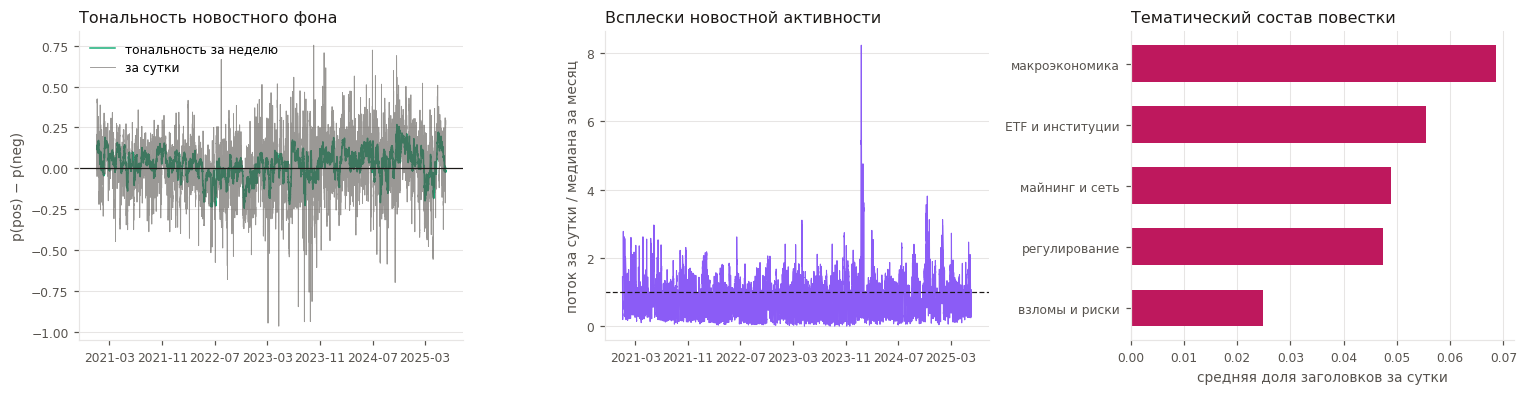

Левая панель показывает главное свойство тональности новостей о крипте: она колеблется
в узкой полосе около небольшого положительного среднего (+0.019 на заголовок: 30.2%
позитивных против 25.7% негативных). Информативен поэтому не уровень тональности, а её
отклонение от собственного среднего — это и делает news_sent_mom.


In [22]:
# Как выглядят новостные признаки.
demo_cols = news_features(raw)
demo_df = pd.DataFrame(demo_cols, index=raw.index)
print(f"Новостных признаков: {len(demo_cols)}")
print(f"Определены с бара {int(max(demo_df[c].first_valid_index() for c in demo_df))} "
      f"(прогрев ТА отбрасывает больше)")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.7))
ax = axes[0]
ax.plot(raw["date"], demo_df["news_sent_168"], color=COLORS["CatBoost"], linewidth=1.0,
        label="тональность за неделю")
ax.plot(raw["date"], demo_df["news_sent_24"], color=INK_MUTED, linewidth=0.6, alpha=0.6,
        label="за сутки")
ax.axhline(0, color=INK, linewidth=0.8)
ax.set_ylabel("p(pos) − p(neg)", color=INK_MUTED, fontsize=9)
ax.set_title("Тональность новостного фона", color=INK, fontsize=10.5, loc="left")
ax.legend(frameon=False, fontsize=8)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=8))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
style_ax(ax)

ax = axes[1]
ax.plot(raw["date"], demo_df["news_burst"], color=COLORS["Ensemble"], linewidth=0.7)
ax.axhline(1.0, color=INK, linewidth=0.8, linestyle=(0, (4, 2)))
ax.set_ylabel("поток за сутки / медиана за месяц", color=INK_MUTED, fontsize=9)
ax.set_title("Всплески новостной активности", color=INK, fontsize=10.5, loc="left")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=8))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
style_ax(ax)

ax = axes[2]
kw_share = pd.Series({k: float(demo_df[f"news_kw_{k}"].mean()) for k in NEWS_KEYWORDS})
names_ru = {"regul": "регулирование", "etf": "ETF и институции", "risk": "взломы и риски",
            "mining": "майнинг и сеть", "macro": "макроэкономика"}
kw_share = kw_share.sort_values()
ax.barh(np.arange(len(kw_share)), kw_share.to_numpy(), color=COLORS["TimesFM"], height=0.6)
ax.set_yticks(np.arange(len(kw_share)))
ax.set_yticklabels([names_ru[k] for k in kw_share.index], fontsize=9)
ax.set_xlabel("средняя доля заголовков за сутки", color=INK_MUTED, fontsize=9)
ax.set_title("Тематический состав повестки", color=INK, fontsize=10.5, loc="left")
style_ax(ax, ygrid=False, xgrid=True)

fig.tight_layout()
plt.show()
print("Левая панель показывает главное свойство тональности новостей о крипте: она колеблется")
print("в узкой полосе около небольшого положительного среднего (+0.019 на заголовок: 30.2%")
print("позитивных против 25.7% негативных). Информативен поэтому не уровень тональности, а её")
print("отклонение от собственного среднего — это и делает news_sent_mom.")

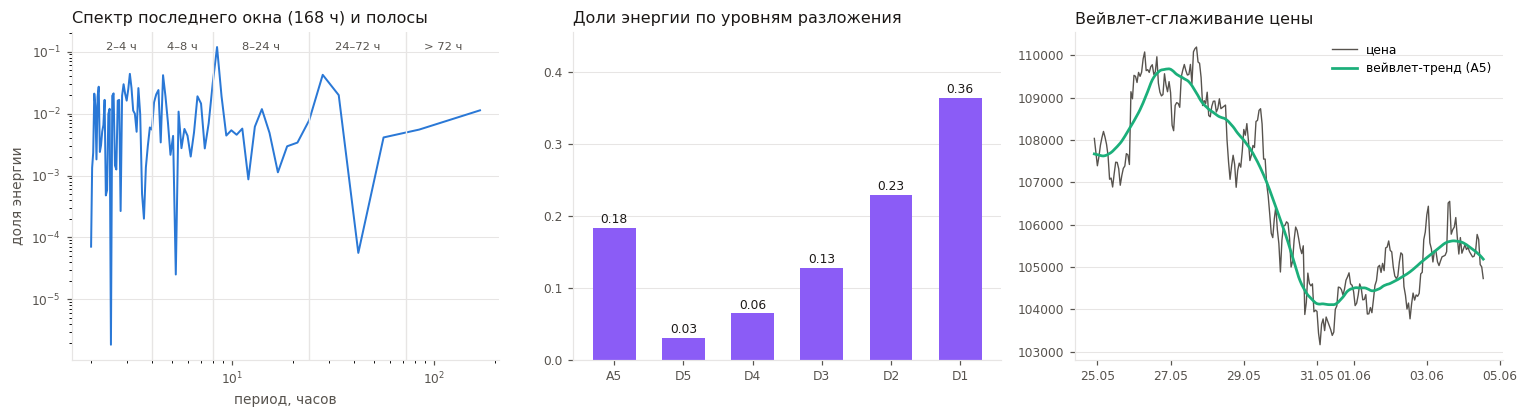

Слева направо: во что превращается последнее окно у Фурье, у вейвлета по энергии
и у вейвлета по тренду. Признаками становятся числа, описывающие форму этих картинок,
а не сами картинки: форма устойчива от окна к окну, отдельные коэффициенты — нет.


In [23]:
# Как выглядят новые признаки: спектр окна, вейвлет-разложение и вейвлет-тренд.
demo_end = len(feat) - 1
demo_lo = demo_end - WAVELET_WINDOW + 1
demo_logret = np.log(feat["close"].to_numpy()[demo_lo:demo_end + 1] /
                     feat["close"].to_numpy()[demo_lo - 1:demo_end])
demo_logprice = np.log(feat["close"].to_numpy()[demo_lo:demo_end + 1])

fig, axes = plt.subplots(1, 3, figsize=(14, 3.9))

ax = axes[0]
w = FFT_WINDOWS[0]
seg = demo_logret[-w:] - demo_logret[-w:].mean()
spec = np.abs(np.fft.rfft(seg * np.hanning(w))) ** 2
freqs = np.fft.rfftfreq(w)[1:]
periods = 1.0 / freqs
p = spec[1:] / spec[1:].sum()
ax.loglog(periods, p, color=COLORS["LogisticRegression"], linewidth=1.3)
for lo, hi in FFT_BANDS[:-1]:
    ax.axvline(hi, color=GRID, linewidth=0.9)
for (lo, hi), lbl in zip(FFT_BANDS, ["2–4 ч", "4–8 ч", "8–24 ч", "24–72 ч", "> 72 ч"]):
    mid = np.sqrt(lo * (hi if hi else w))
    ax.annotate(lbl, xy=(mid, 1.0), xycoords=("data", "axes fraction"), xytext=(0, -12),
                textcoords="offset points", ha="center", fontsize=7.5, color=INK_MUTED)
ax.set_xlabel("период, часов", color=INK_MUTED, fontsize=9)
ax.set_ylabel("доля энергии", color=INK_MUTED, fontsize=9)
ax.set_title(f"Спектр последнего окна ({w} ч) и полосы", color=INK, fontsize=10.5, loc="left")
style_ax(ax)

ax = axes[1]
cf = pywt.wavedec(demo_logret, WAVELET_NAME, level=WAVELET_LEVEL, mode=WAVELET_MODE)
lvl_names = [f"A{WAVELET_LEVEL}"] + [f"D{j}" for j in range(WAVELET_LEVEL, 0, -1)]
en = np.array([float((c ** 2).sum()) for c in cf])
en = en / en.sum()
ax.bar(np.arange(len(en)), en, color=COLORS["Ensemble"], width=0.62)
for xi, v in enumerate(en):
    ax.annotate(f"{v:.2f}", xy=(xi, v), xytext=(0, 3), textcoords="offset points",
                ha="center", fontsize=8, color=INK)
ax.set_xticks(np.arange(len(en)))
ax.set_xticklabels(lvl_names, fontsize=9)
ax.set_ylim(0, en.max() * 1.25)
ax.set_title("Доли энергии по уровням разложения", color=INK, fontsize=10.5, loc="left")
style_ax(ax)

ax = axes[2]
cp_demo = pywt.wavedec(demo_logprice, WAVELET_NAME, level=WAVELET_LEVEL, mode=WAVELET_MODE)
trend_demo = pywt.waverec([cp_demo[0]] + [np.zeros_like(c) for c in cp_demo[1:]],
                          WAVELET_NAME, mode=WAVELET_MODE)[:len(demo_logprice)]
dates_demo = feat["date"].to_numpy()[demo_lo:demo_end + 1]
ax.plot(dates_demo, np.exp(demo_logprice), color=INK_MUTED, linewidth=0.9, label="цена")
ax.plot(dates_demo, np.exp(trend_demo), color=COLORS["CatBoost"], linewidth=1.8,
        label=f"вейвлет-тренд (A{WAVELET_LEVEL})")
ax.set_title("Вейвлет-сглаживание цены", color=INK, fontsize=10.5, loc="left")
ax.legend(frameon=False, fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax)

fig.tight_layout()
plt.show()
print("Слева направо: во что превращается последнее окно у Фурье, у вейвлета по энергии")
print("и у вейвлета по тренду. Признаками становятся числа, описывающие форму этих картинок,")
print("а не сами картинки: форма устойчива от окна к окну, отдельные коэффициенты — нет.")

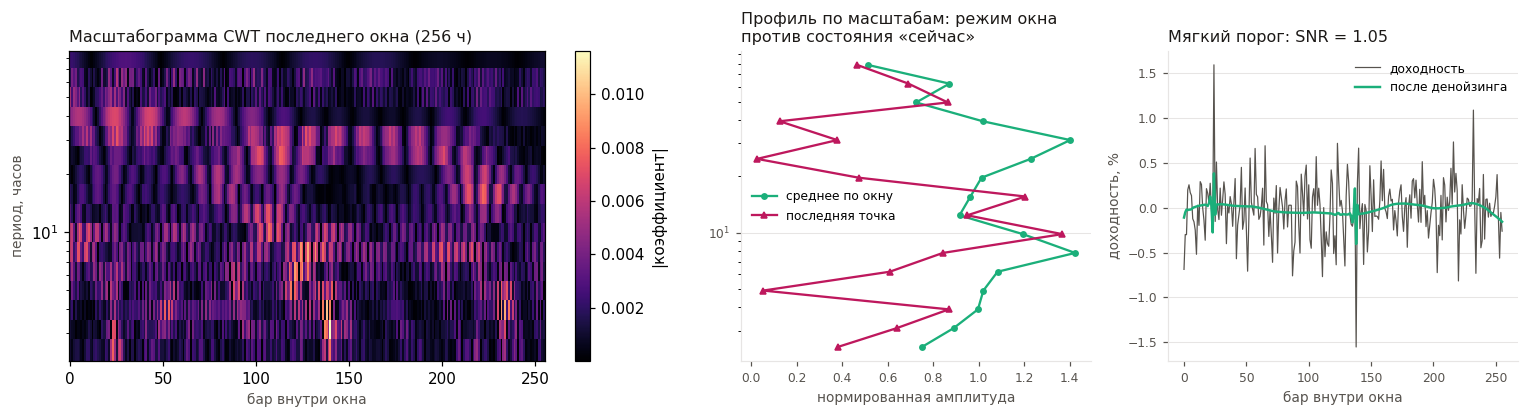

Слева — то, чего DWT дать не может: энергия по 16 масштабам и по времени одновременно.
В середине — два вектора признаков из этой картинки: усреднение по окну (режим) и
последний столбец (состояние сейчас). Справа — денойзинг мягким порогом: при SNR около
единицы «очищенный» ряд по амплитуде сопоставим с тем, что из него вычли.


In [24]:
# Масштабограмма последнего окна: та самая картинка из примера, но на нашем ряде.
demo_ret = demo_logret                      # то же окно, что в предыдущей ячейке
coef_demo, _ = pywt.cwt(demo_ret, CWT_SCALES, CWT_WAVELET)
amp_demo = np.abs(coef_demo)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.9),
                         gridspec_kw={"width_ratios": [1.7, 1, 1]})

ax = axes[0]
im = ax.pcolormesh(np.arange(len(demo_ret)), CWT_PERIODS, amp_demo, cmap="magma", shading="auto")
ax.set_yscale("log")
ax.set_ylabel("период, часов", color=INK_MUTED, fontsize=9)
ax.set_xlabel("бар внутри окна", color=INK_MUTED, fontsize=9)
ax.set_title(f"Масштабограмма CWT последнего окна ({WAVELET_WINDOW} ч)",
             color=INK, fontsize=10.5, loc="left")
fig.colorbar(im, ax=ax, label="|коэффициент|")

ax = axes[1]
ax.plot(amp_demo.mean(axis=1) / amp_demo.mean(), CWT_PERIODS, marker="o", markersize=3.5,
        linewidth=1.5, color=COLORS["CatBoost"], label="среднее по окну")
ax.plot(amp_demo[:, -1] / amp_demo.mean(), CWT_PERIODS, marker="^", markersize=4,
        linewidth=1.5, color=COLORS["TimesFM"], label="последняя точка")
ax.set_yscale("log")
ax.set_xlabel("нормированная амплитуда", color=INK_MUTED, fontsize=9)
ax.set_title("Профиль по масштабам: режим окна\nпротив состояния «сейчас»",
             color=INK, fontsize=10.5, loc="left")
ax.legend(frameon=False, fontsize=8)
style_ax(ax)

ax = axes[2]
cf_demo = pywt.wavedec(demo_ret, WAVELET_NAME, level=WAVELET_LEVEL, mode=WAVELET_MODE)
sig_demo = np.median(np.abs(cf_demo[-1])) / 0.6745
thr_demo = sig_demo * np.sqrt(2 * np.log(len(demo_ret)))
den_demo = [cf_demo[0]] + [pywt.threshold(c, thr_demo, mode="soft") for c in cf_demo[1:]]
rec_demo = pywt.waverec(den_demo, WAVELET_NAME, mode=WAVELET_MODE)[:len(demo_ret)]
ax.plot(demo_ret * 100, color=INK_MUTED, linewidth=0.8, label="доходность")
ax.plot(rec_demo * 100, color=COLORS["CatBoost"], linewidth=1.6, label="после денойзинга")
ax.set_xlabel("бар внутри окна", color=INK_MUTED, fontsize=9)
ax.set_ylabel("доходность, %", color=INK_MUTED, fontsize=9)
ax.set_title(f"Мягкий порог: SNR = "
             f"{demo_ret.std() / (demo_ret - rec_demo).std():.2f}",
             color=INK, fontsize=10.5, loc="left")
ax.legend(frameon=False, fontsize=8)
style_ax(ax)

fig.tight_layout()
plt.show()
print("Слева — то, чего DWT дать не может: энергия по 16 масштабам и по времени одновременно.")
print("В середине — два вектора признаков из этой картинки: усреднение по окну (режим) и")
print("последний столбец (состояние сейчас). Справа — денойзинг мягким порогом: при SNR около")
print("единицы «очищенный» ряд по амплитуде сопоставим с тем, что из него вычли.")

### 7.4 Проверка на утечку данных

Обрезаем ряд на произвольном баре, пересчитываем все признаки на обрезанных
данных и сравниваем с признаками, посчитанными на полном ряде. Если ни одна функция не
использует будущее, значения обязаны совпасть.

**Что эта проверка покрывает, а что нет.** Тест ловит утечку в детерминированных оконных
функциях — индикаторах, спектральных и вейвлет-признаках, агрегатах новостей. Он НЕ проверяет
обучаемые преобразования: PCA эмбеддингов новостей, отбор признаков, пороги торгового слоя и
периоды TimesNet — у них утечка (если она есть) не в формуле окна, а в том, какие данные видел
сам фит. Эти четыре места разобраны и исправлены отдельно (разделы 12.2, 14, 16, 17.1).

In [25]:
CUT = int(len(raw) * 0.6)
truncated, _ = build_ta_features(raw.iloc[:CUT].reset_index(drop=True))
full_slice = build_ta_features(raw)[0].iloc[:CUT].reset_index(drop=True)

check_from = 500                                    # пропускаем прогрев индикаторов
SENTINEL = -9.876543e12                             # чтобы NaN не «замаскировал» расхождение
a = truncated[feature_cols].iloc[check_from:CUT - 1].fillna(SENTINEL)
b = full_slice[feature_cols].iloc[check_from:CUT - 1].fillna(SENTINEL)
diff = (a - b).abs().max()
bad = diff[diff > 1e-9].sort_values(ascending=False)

print(f"Ряд обрезан на баре {CUT} ({raw['date'].iloc[CUT]}), признаки пересчитаны заново.")
print(f"Сравнивается {len(a)} строк × {len(feature_cols)} признаков.")
if len(bad) == 0:
    print("OK: все признаки совпали — ни одна оконная функция признаков не использует данные "
          "из будущего. Обучаемые преобразования (PCA, отбор, пороги слоя, периоды TimesNet) "
          "эта проверка не покрывает — см. пояснение выше.")
else:
    display(bad.head(20))
    raise AssertionError(f"{len(bad)} признаков зависят от будущего")

# сдвиг признаков относительно последнего бара: у свинг-паттернов он не меньше PIVOT_W
last_pivot = swing_points(raw["high"], raw["low"])[0].last_valid_index()
print(f"\nПоследний подтверждённый свинг-максимум относится к бару {last_pivot} из {len(raw) - 1} "
      f"(сам экстремум — на PIVOT_W = {PIVOT_W} баров раньше, {last_pivot - PIVOT_W}): признак "
      f"появляется только в момент подтверждения. Свежих подтверждений в последних "
      f"{len(raw) - 1 - last_pivot} барах нет — это нормально, вершины случаются не каждый час.")

Ряд обрезан на баре 23265 (2023-08-28 09:00:00), признаки пересчитаны заново.
Сравнивается 22764 строк × 331 признаков.
OK: все признаки совпали — ни одна оконная функция признаков не использует данные из будущего. Обучаемые преобразования (PCA, отбор, пороги слоя, периоды TimesNet) эта проверка не покрывает — см. пояснение выше.

Последний подтверждённый свинг-максимум относится к бару 38756 из 38774 (сам экстремум — на PIVOT_W = 5 баров раньше, 38751): признак появляется только в момент подтверждения. Свежих подтверждений в последних 18 барах нет — это нормально, вершины случаются не каждый час.


## 8. Разбиение на train / test / validation

Разбиваем строго по времени, без перемешивания:

- **train** (70%) — обучение;
- **test** (15%) — вместе с train участвует в подборе гиперпараметров;
- **validation** (15%) — отложенная выборка, используется ровно один раз в конце;
- **dev** = train + test — внутри него идёт кросс-валидация временных рядов.

Между выборками выдерживается разрыв, чтобы последние бары обучающей части не знали о начале следующей.

In [26]:
n = len(feat)
train_end = int(n * TRAIN_END)
test_end = int(n * TEST_END)

train_df = feat.iloc[:train_end - EMBARGO].reset_index(drop=True)
test_df = feat.iloc[train_end:test_end - EMBARGO].reset_index(drop=True)
val_df = feat.iloc[test_end:].reset_index(drop=True)
dev_df = feat.iloc[:test_end - EMBARGO].reset_index(drop=True)

for name, part in (("train", train_df), ("test", test_df), ("validation", val_df)):
    print(f"{name:11s}: {len(part):5d} строк | {part['date'].min()} — {part['date'].max()}")

gap_tr_te = (test_df["date"].min() - train_df["date"].max()) / pd.Timedelta(hours=1)
gap_te_val = (val_df["date"].min() - test_df["date"].max()) / pd.Timedelta(hours=1)
print(f"\nразрыв train->test: {gap_tr_te:.0f} ч, test->validation: {gap_te_val:.0f} ч "
      f"(нужно > {HORIZON} ч — на длину метки)")
assert gap_tr_te > HORIZON and gap_te_val > HORIZON, "выборки перекрываются по периоду метки"

bh_val_return = float((1 + val_df["fwd_ret"]).prod() - 1)
print(f"Buy & hold на валидации: {bh_val_return:+.1%} — период {'падающий' if bh_val_return < 0 else 'растущий'}")

train      : 26782 строк | 2021-01-22 08:00:00 — 2024-02-12 05:00:00
test       :  5738 строк | 2024-02-12 07:00:00 — 2024-10-08 08:00:00
validation :  5740 строк | 2024-10-08 10:00:00 — 2025-06-04 13:00:00

разрыв train->test: 2 ч, test->validation: 2 ч (нужно > 1 ч — на длину метки)
Buy & hold на валидации: +68.0% — период растущий


## 9. Бэктест и стоимостно-осознанный торговый слой

**Стоп-лосс и тейк-профит.** В исходном ноутбуке сделка закрывалась только сигналом модели:
стратегия каждый час пересчитывала целевую позицию и держала её, как бы ни шла цена. Здесь
к торговому слою добавлены правила выхода:

- **сделка** — отрезок, на котором знак целевой позиции не меняется; **цена входа** — close
  бара, на котором знак появился;
- **стоп-лосс `sl`** и **тейк-профит `tp`** — уровни на расстоянии `sl` и `tp` от цены входа
  (0 — правило выключено). Проверка идёт по open/high/low следующего часа: если цена дошла
  до уровня, сделка закрывается по уровню внутри бара, а при гэпе на открытии — по open;
- если за один час задеты оба уровня, считается, что первым сработал стоп (часовые бары
  не говорят, что было раньше, и оптимистичное допущение завысило бы результат);
- **после выхода** стратегия вне рынка до нового сигнала — пока знак целевой позиции не
  сменится; при `cooldown = 24` она возвращается в рынок не позже чем через сутки,
  если модель всё ещё хочет ту же сторону;
- комиссия платится и на входе, и на каждом выходе по стопу/тейку.

Позиции стратегии по-прежнему решает торговый слой (`positions_from_proba`); правила выхода
исполняет `backtest(..., sltp=params)`, и при `sltp=None` он даёт ровно те же числа, что
бэктест исходного ноутбука (проверка — в разделе 9.1).


In [27]:
# ── Стоп-лосс и тейк-профит ─────────────────────────────────────────────────
# Торговый слой (positions_from_proba) говорит, какую позицию он ХОЧЕТ держать на каждом баре.
# Правила выхода решают, держит ли её стратегия на самом деле: сделка закрывается не только
# по сигналу модели, но и внутри часа, как только цена дошла до стопа или до тейка от цены входа.
#
# Для этого нужны open/high/low следующего бара, а не только close. Ряд цен берётся полный,
# без обрезки по концу новостей: walk-forward (раздел 24) проверяет окна после 04.06.2025,
# и стопы там должны исполняться по тем же правилам.
import numba

_px = pd.read_csv(DATA_PATH)
_px = _px.rename(columns={c: COLUMN_MAP[c.lower()] for c in _px.columns if c.lower() in COLUMN_MAP})
_px["date"] = pd.to_datetime(_px["date"], utc=True).dt.tz_convert(None)
_px = _px.sort_values("date").drop_duplicates(subset="date").reset_index(drop=True)
PX_DATES = _px["date"].to_numpy("datetime64[ns]")
PX_OPEN, PX_HIGH, PX_LOW, PX_CLOSE = (_px[c].to_numpy(float) for c in ("open", "high", "low", "close"))
del _px


def price_path(dates):
    """Цена входа-кандидата (close бара t) и open/high/low бара t+1 — пути, на котором ждёт стоп."""
    d = pd.to_datetime(pd.Series(dates)).to_numpy("datetime64[ns]")
    idx = np.minimum(np.searchsorted(PX_DATES, d), len(PX_DATES) - 2)
    if (PX_DATES[idx] != d).any() or (PX_DATES[idx + 1] - d != np.timedelta64(1, "h")).any():
        raise ValueError("для части баров нет цены закрытия или следующего часа в полном ряде")
    return PX_CLOSE[idx], PX_OPEN[idx + 1], PX_HIGH[idx + 1], PX_LOW[idx + 1]


@numba.njit
def _exit_kernel(target, fwd_ret, c, o1, h1, l1, sl, tp, cooldown):
    """Целевая позиция -> фактическая позиция с учётом стоп-лосса и тейк-профита.

    Сделка — отрезок, на котором знак целевой позиции не меняется; цена входа — close бара,
    на котором знак появился. Уровни: стоп на sl, тейк на tp от цены входа (0 — правило выключено).
    Исполнение внутри бара t -> t+1 консервативное:
      - гэп на открытии за уровень исполняется по open (хуже уровня для стопа);
      - если за час задеты и стоп, и тейк, считается, что первым был стоп;
      - на выходе платится комиссия, как на любой сделке.
    После выхода стратегия стоит вне рынка, пока знак цели не сменится (новый сигнал модели),
    а при cooldown >= 0 — ещё и не дольше cooldown баров: потом входит заново по текущей цели.
    Возвращает фактическую позицию, gross-доходность бара, оборот и тип выхода (1 — стоп, 2 — тейк).
    """
    n = len(target)
    pos = np.zeros(n)
    gross = np.zeros(n)
    turn = np.zeros(n)
    kind = np.zeros(n, np.int8)
    prev, side, entry = 0.0, 0, 0.0
    blocked, exit_t = 0, -1
    use_exits = sl > 0.0 or tp > 0.0
    for t in range(n):
        tg = target[t]
        s = 1 if tg > 0.0 else (-1 if tg < 0.0 else 0)
        if blocked != 0 and (s != blocked or (cooldown >= 0 and t - exit_t >= cooldown)):
            blocked = 0
        p = 0.0 if blocked != 0 else tg
        ps = 1 if p > 0.0 else (-1 if p < 0.0 else 0)
        if ps == 0:
            side = 0
        elif ps != side:
            side, entry = ps, c[t]
        pos[t] = p
        turn[t] = abs(p - prev)
        gross[t] = p * fwd_ret[t]
        prev = p
        if use_exits and side != 0:
            x, k = 0.0, 0
            if side > 0:
                stop, take = entry * (1.0 - sl), entry * (1.0 + tp)
                if sl > 0.0 and o1[t] <= stop:
                    x, k = o1[t], 1
                elif tp > 0.0 and o1[t] >= take:
                    x, k = o1[t], 2
                elif sl > 0.0 and l1[t] <= stop:
                    x, k = stop, 1
                elif tp > 0.0 and h1[t] >= take:
                    x, k = take, 2
            else:
                stop, take = entry * (1.0 + sl), entry * (1.0 - tp)
                if sl > 0.0 and o1[t] >= stop:
                    x, k = o1[t], 1
                elif tp > 0.0 and o1[t] <= take:
                    x, k = o1[t], 2
                elif sl > 0.0 and h1[t] >= stop:
                    x, k = stop, 1
                elif tp > 0.0 and l1[t] <= take:
                    x, k = take, 2
            if k != 0:
                gross[t] = p * (x / c[t] - 1.0)
                turn[t] += abs(p)
                kind[t] = k
                prev, blocked, exit_t, side = 0.0, side, t, 0
    return pos, gross, turn, kind


SLTP_OFF = {"sl": 0.0, "tp": 0.0, "cooldown": -1}


def exit_rules(params):
    """(sl, tp, cooldown) из параметров торгового слоя; None или нет ключей — правила выключены."""
    params = params or {}
    sl, tp = float(params.get("sl", 0.0) or 0.0), float(params.get("tp", 0.0) or 0.0)
    return sl, tp, int(params.get("cooldown", -1))


def run_exits(dates, fwd_ret, position, sltp=None):
    """Фактическая позиция, gross-доходность, оборот и тип выхода для целевой позиции."""
    sl, tp, cd = exit_rules(sltp)
    position = np.ascontiguousarray(position, dtype=float)
    fwd_ret = np.ascontiguousarray(fwd_ret, dtype=float)
    if sl > 0 or tp > 0:
        path = price_path(dates)
    else:
        path = (np.ones(len(position)),) * 4          # без стопов путь внутри бара не нужен
    return _exit_kernel(position, fwd_ret, *path, sl, tp, cd)


def backtest(dates, fwd_ret, position, fee_rate=FEE_RATE, sltp=None):
    """Бэктест непрерывной позиции.

    position — доля капитала в позиции от -1 (полный short) до +1 (полный long), принятая
    в момент t по информации, известной к t, и применённая к доходности бара (t -> t+1).
    Комиссия начисляется с оборота |Δposition|: переворот long <-> short стоит 2 * fee_rate.

    Доходность считается и gross (без издержек), и net (с издержками): без этого разделения
    нельзя отличить «у модели нет предсказательной силы» от «edge есть, но его съедают издержки».

    sltp — правила выхода {"sl", "tp", "cooldown"} (обычно это параметры торгового слоя целиком,
    лишние ключи игнорируются). position тогда — ЦЕЛЕВАЯ позиция, а в кривой и метриках —
    фактическая: сделка закрывается внутри часа по стоп-лоссу или тейк-профиту (_exit_kernel).
    sltp=None — правил выхода нет, результат совпадает с бэктестом исходного ноутбука.
    """
    dates = pd.Series(dates).reset_index(drop=True)
    fwd_ret = np.asarray(fwd_ret, dtype=float)
    position = np.asarray(position, dtype=float)
    if len(position) == 0:
        raise ValueError("backtest получил пустую выборку")

    target = position
    # до первой сделки капитал вне рынка; с sltp позиция закрывается ещё и по стопу или тейку
    position, gross_ret, turnover, exit_kind = run_exits(dates, fwd_ret, target, sltp)
    fees = fee_rate * turnover
    strat_ret = gross_ret - fees

    equity = (1 + strat_ret).cumprod()
    equity_gross = (1 + gross_ret).cumprod()
    # включаем стартовый капитал (1.0) в running maximum: иначе первый убыток бара 0
    # не считается просадкой от начала, хотя реально капитал уже ниже старта
    drawdown = equity / np.maximum.accumulate(np.r_[1.0, equity])[1:] - 1

    n_periods = len(strat_ret)
    total_return = float(equity[-1] - 1)
    vol = strat_ret.std(ddof=0)
    gross_vol = gross_ret.std(ddof=0)

    curve = pd.DataFrame({"date": dates, "position": position, "target_position": target,
                          "strategy_return": strat_ret, "equity": equity,
                          "equity_gross": equity_gross, "drawdown": drawdown, "exit": exit_kind})
    metrics = {
        "total_return": total_return,                                   # net, с издержками
        "gross_return": float(equity_gross[-1] - 1),                    # edge модели
        "fee_drag": float(fees.sum()),                                  # сумма ставок издержек (не п.п. доходности)
        "gross_minus_net": float(equity_gross[-1] - equity[-1]),        # реальная потеря доходности, в долях капитала
        "annualized_return": float((1 + total_return) ** (PERIODS_PER_YEAR / n_periods) - 1),
        "sharpe": float(strat_ret.mean() / vol * np.sqrt(PERIODS_PER_YEAR)) if vol > 0 else 0.0,
        "gross_sharpe": float(gross_ret.mean() / gross_vol * np.sqrt(PERIODS_PER_YEAR)) if gross_vol > 0 else 0.0,
        "max_drawdown": float(drawdown.min()),
        "n_trades": int((turnover > TRADE_EPS).sum()),
        "turnover_units": float(turnover.sum()),
        "time_in_market": float((np.abs(position) > TRADE_EPS).mean()),
        "avg_abs_position": float(np.abs(position).mean()),              # фактическая экспозиция
        "avg_position": float(position.mean()),                          # смещение в long/short
        "profitable_bars": float((strat_ret > 0).mean()),
        "n_stop_loss": int((exit_kind == 1).sum()),                    # выходов по стоп-лоссу
        "n_take_profit": int((exit_kind == 2).sum()),                  # выходов по тейк-профиту
    }
    return curve, metrics


def _ref_quantile(src, qv, fold_ids=None):
    """Квантиль qv эталонного распределения src: одно число или своё значение на каждый фолд.

    fold_ids — номер CV-фолда, в test-часть которого попал бар (-1 — бар не входит в test ни
    одного фолда). Порог для баров фолда k считается только по барам фолдов 0..k-1, то есть по
    OOF-прогнозам, которые на момент фолда k уже в прошлом и лежат внутри его обучающей части.
    Распределение самого фолда k в его пороги не попадает. У фолда 0 прошлого нет: порог NaN,
    сигнала нет, и такие бары в оценку торгового слоя не идут (см. oof_signal_backtest).
    """
    if fold_ids is None:
        return np.quantile(src, qv)
    fold_ids = np.asarray(fold_ids)
    out = np.full(len(src), np.nan)
    for k in np.unique(fold_ids[fold_ids >= 1]):
        past = src[(fold_ids >= 0) & (fold_ids < k)]
        past = past[np.isfinite(past)]
        if len(past):
            out[fold_ids == k] = np.quantile(past, qv)
    return out


def positions_from_proba(proba, mode="hold", q=0.1, scale=10.0, span=1, rebalance=1, ref=None,
                         fold_ids=None, sl=0.0, tp=0.0, cooldown=-1):
    """Перевод вероятности роста в позицию.

    mode:
      always    — всегда в рынке ±1 (правило из ДЗ №2);
      flat      — вне рынка в зоне неопределённости;
      hold      — в зоне неопределённости удерживается предыдущая позиция (гистерезис);
      ramp      — размер позиции растёт линейно от порога до экстремума вероятности;
      long_flat — только long или вне рынка (шорт запрещён);
      scaled    — непрерывный размер позиции, пропорциональный уверенности.

    span      — окно экспоненциального сглаживания вероятности (гасит однобаровый шум);
    rebalance — позиция пересматривается раз в k баров;
    sl, tp, cooldown — правила выхода; здесь не используются (функция отдаёт ЦЕЛЕВУЮ позицию),
                их исполняет backtest(..., sltp=params) по ценам внутри бара;
    q         — доля баров с каждой стороны, попадающая в «уверенную» зону; пороги берутся как
                квантили распределения вероятностей, что устойчиво к калибровке модели.

    Откуда берутся квантильные пороги — ровно один из двух вариантов:
    ref       — эталонное распределение (прогнозы модели на её обучающей выборке); сглаживается
                тем же span, что и proba, чтобы порог и сигнал были в одной шкале;
    fold_ids  — для OOF-вероятностей на dev: порог каждого фолда — по OOF предыдущих фолдов
                (_ref_quantile). Пороги по распределению самого оцениваемого участка (прежний
                вариант ref=None без fold_ids) больше не используются нигде в ноутбуке.
    """
    p = np.asarray(proba, dtype=float)
    if span > 1:
        p = pd.Series(p).ewm(span=span, adjust=False).mean().to_numpy()
    uses_thresholds = mode in ("hold", "flat", "long_flat", "ramp")
    if uses_thresholds and (ref is None) == (fold_ids is None):
        raise ValueError("квантильным режимам нужен ровно один источник порогов: ref или fold_ids")
    if ref is None:
        src = p
    else:
        src = np.asarray(ref, dtype=float)
        src = src[np.isfinite(src)]
        if span > 1:
            src = pd.Series(src).ewm(span=span, adjust=False).mean().to_numpy()

    def thr(qv):
        return _ref_quantile(src, qv, fold_ids)

    if mode == "always":
        pos = np.where(p >= 0.5, 1.0, -1.0)
    elif mode in ("hold", "flat"):
        hi, lo = thr(1 - q), thr(q)
        sig = np.where(p >= hi, 1.0, np.where(p <= lo, -1.0, np.nan))
        pos = pd.Series(sig).ffill().fillna(0.0).to_numpy() if mode == "hold" else np.nan_to_num(sig)
    elif mode == "long_flat":
        pos = (p >= thr(1 - q)).astype(float)
    elif mode == "ramp":
        hi, lo = thr(1 - q), thr(q)
        up = np.clip((p - hi) / np.maximum(thr(0.999) - hi, 1e-6), 0, 1)
        dn = np.clip((lo - p) / np.maximum(lo - thr(0.001), 1e-6), 0, 1)
        pos = np.nan_to_num(up - dn)
    elif mode == "scaled":
        pos = np.clip((p - 0.5) * scale, -1.0, 1.0)
    else:
        raise ValueError(f"неизвестный режим сигнала: {mode}")

    if rebalance > 1:
        keep = (np.arange(len(pos)) % rebalance) == 0
        pos = pd.Series(np.where(keep, pos, np.nan)).ffill().fillna(0.0).to_numpy()
    return pos


def oof_signal_backtest(proba, dates, fwd_ret, fold_ids, params, fee_rate=FEE_RATE):
    """Торговый слой на OOF-вероятностях dev + бэктест.

    Пороги фолда k — квантили OOF фолдов 0..k-1 (то есть данных из его обучающей части), а
    оценка идёт только по барам фолдов 1..K-1: у фолда 0 прошлого нет. Так ни подбор слоя, ни
    Optuna не видят распределение вероятностей того участка, на котором слой оценивается, —
    ровно как на валидации, где пороги зафиксированы по dev (apply_signal, раздел 18).
    """
    fold_ids = np.asarray(fold_ids)
    pos = positions_from_proba(proba, fold_ids=fold_ids, **params)
    ev = fold_ids >= 1
    return backtest(np.asarray(dates)[ev], np.asarray(fwd_ret)[ev], pos[ev], fee_rate,
                    sltp=params)


# сетка торгового слоя: перебирается при подборе гиперпараметров
SIGNAL_GRID = ([{"mode": "always"}] +
               [{"mode": m, "q": q} for m in ("hold", "flat", "ramp", "long_flat")
                for q in (0.02, 0.05, 0.10, 0.20, 0.35)] +
               [{"mode": "scaled", "scale": s} for s in (4, 10, 25)])
SPAN_GRID = (1, 4, 12, 24)
REBALANCE_GRID = (1, 6, 24)

# сетка правил выхода: стоп-лосс и тейк-профит от цены входа, пауза после выхода.
# 0 — правило выключено; первая строка сетки — слой без стопов, ровно как в исходном ноутбуке.
SL_GRID = (0.0, 0.015, 0.03, 0.05, 0.08)
TP_GRID = (0.0, 0.03, 0.06, 0.10, 0.15)
COOLDOWN_GRID = (-1, 24)          # -1 — вне рынка до нового сигнала; 24 — не дольше суток
EXIT_GRID = [dict(SLTP_OFF)] + [{"sl": s, "tp": t, "cooldown": c}
                                for s in SL_GRID for t in TP_GRID for c in COOLDOWN_GRID
                                if s > 0 or t > 0]


def _block_sharpes(r, starts, lengths):
    """Sharpe по подпериодам через суммы: без нарезки массива на каждом из 14 тысяч вариантов."""
    s1 = np.add.reduceat(r, starts)
    s2 = np.add.reduceat(r * r, starts)
    mean = s1 / lengths
    sd = np.sqrt(np.maximum(s2 / lengths - mean ** 2, 0.0))
    return np.where(sd > 0, mean / np.where(sd > 0, sd, 1.0) * np.sqrt(PERIODS_PER_YEAR), 0.0)


def tune_signal_layer(proba, dates, fwd_ret, fold_ids, fee_rate=FEE_RATE, exit_grid=None):
    """Перебор параметров торгового слоя и правил выхода по чистому (net) коэффициенту Шарпа.

    Максимизировать один только Sharpe нельзя — у этой задачи есть вырожденный оптимум.
    Стратегия, которая держит крошечную почти постоянную позицию, не платит комиссий и
    показывает прекрасный Sharpe при нулевой полезности: это замаскированный buy & hold с
    плечом 0.07, а не торговая система. Ровно в этот угол и уходит оптимизатор, если его не
    ограничить. Поэтому конфигурация обязана:

    1. давать оборот не меньше MIN_TURNOVER_PER_YEAR единиц капитала в год — то есть
       действительно менять решение, а не «пересиживать»;
    2. держать средний размер позиции не меньше MIN_AVG_EXPOSURE капитала — то есть
       действительно рисковать деньгами;
    3. быть прибыльной хотя бы в MIN_POSITIVE_BLOCKS из N_BLOCKS подпериодов — защита от
       результата, который держится на одной удачной сделке.

    Слой и правила выхода подбираются СОВМЕСТНО: каждая конфигурация сигнала проверяется со
    всеми вариантами стоп-лосса и тейк-профита из exit_grid (по умолчанию EXIT_GRID), включая
    вариант без стопов. Стопы меняют и оборот, и экспозицию, поэтому ограничения 1–3
    проверяются уже на фактической позиции после выходов.

    Квантильные пороги каждой конфигурации считаются по прошлым фолдам (fold_ids, см.
    oof_signal_backtest), а не по оцениваемому участку, и все конфигурации оцениваются на одних
    и тех же барах фолдов 1..K-1. Метрики считаются тем же ядром _exit_kernel, что и в
    backtest(), только без сборки DataFrame кривой на каждый вариант.

    Возвращает (параметры, таблица, признак того, что допустимая конфигурация найдена).
    """
    exit_grid = EXIT_GRID if exit_grid is None else exit_grid
    fold_ids = np.asarray(fold_ids)
    ev = fold_ids >= 1
    n_ev = int(ev.sum())
    d_ev = np.asarray(dates)[ev]
    f_ev = np.ascontiguousarray(np.asarray(fwd_ret, dtype=float)[ev])
    if any(e["sl"] > 0 or e["tp"] > 0 for e in exit_grid):
        path = price_path(d_ev)
    else:
        path = (np.ones(n_ev),) * 4
    bounds = np.array_split(np.arange(n_ev), N_BLOCKS)
    starts = np.array([b[0] for b in bounds])
    lengths = np.array([len(b) for b in bounds], dtype=float)
    ann = np.sqrt(PERIODS_PER_YEAR)

    rows = []
    for span in SPAN_GRID:
        for reb in REBALANCE_GRID:
            for prm in SIGNAL_GRID:
                target = positions_from_proba(proba, fold_ids=fold_ids, span=span,
                                              rebalance=reb, **prm)
                target = np.ascontiguousarray(target[ev], dtype=float)
                for ex in exit_grid:
                    pos, g, turn, kind = _exit_kernel(target, f_ev, *path,
                                                      ex["sl"], ex["tp"], ex["cooldown"])
                    r = g - fee_rate * turn
                    vol = r.std()
                    block_sharpe = _block_sharpes(r, starts, lengths)
                    rows.append({**prm, "span": span, "rebalance": reb, **ex,
                                 "sharpe": float(r.mean() / vol * ann) if vol > 0 else 0.0,
                                 "net": float(np.prod(1 + r) - 1),
                                 "gross": float(np.prod(1 + g) - 1),
                                 "turnover": float(turn.sum()),
                                 "n_trades": int((turn > TRADE_EPS).sum()),
                                 "time_in_market": float((np.abs(pos) > TRADE_EPS).mean()),
                                 "экспозиция": float(np.abs(pos).mean()),
                                 "стопов": int((kind == 1).sum()),
                                 "тейков": int((kind == 2).sum()),
                                 "sharpe_min_блок": float(block_sharpe.min()),
                                 "прибыльных блоков": int((block_sharpe > 0).sum())})
    tab = pd.DataFrame(rows)
    years = n_ev / PERIODS_PER_YEAR                    # длина оцениваемого участка
    tab["допустима"] = ((tab["turnover"] >= MIN_TURNOVER_PER_YEAR * years) &
                        (tab["экспозиция"] >= MIN_AVG_EXPOSURE))
    tab["устойчива"] = tab["допустима"] & (tab["прибыльных блоков"] >= MIN_POSITIVE_BLOCKS)
    feasible = tab[tab["допустима"]]
    ok_feasible = len(feasible) > 0
    stable = tab[tab["устойчива"]]
    ok_stable = len(stable) > 0
    # Возвращаемый ok — это ok_stable (все три требования докстринга, а не только оборот и
    # экспозиция): раньше ok=True мог означать лишь то, что нашлась хоть одна активная, но
    # неустойчивая по подпериодам конфигурация — фильтр по MIN_POSITIVE_BLOCKS был
    # необязательным в проверках вызывающего кода (codex_report.md, пункт 14). pool всё равно
    # откатывается через feasible/tab, чтобы функция всегда возвращала какую-то конфигурацию.
    pool = stable if ok_stable else (feasible if ok_feasible else tab)
    best = pool.loc[pool["sharpe"].idxmax()]
    params = {"mode": str(best["mode"]), "span": int(best["span"]),
              "rebalance": int(best["rebalance"])}
    for k in ("q", "scale"):                     # присутствуют не у всех режимов
        if k in tab.columns and pd.notna(best[k]):
            params[k] = float(best[k])
    params.update({"sl": float(best["sl"]), "tp": float(best["tp"]),
                   "cooldown": int(best["cooldown"])})
    return params, tab, ok_stable


### 9.1 Стоп-лосс и тейк-профит: проверка механики

Три проверки до того, как правила выхода попадут в подбор:

1. без правил выхода новый бэктест совпадает с формулой исходного ноутбука бит в бит;
2. цены внутри бара берутся из того же ряда, что и `fwd_ret`: close следующего часа из полного
   ряда даёт ту же доходность бара;
3. ядро исполнения на ручных сценариях: обычный стоп, гэп за стоп, тейк, оба уровня в одном
   баре, шорт, пауза после выхода.

In [28]:
# 1. Без правил выхода — тот же бэктест, что в исходном ноутбуке.
_rng = np.random.default_rng(RANDOM_STATE)
_d, _f = dev_df["date"].to_numpy(), dev_df["fwd_ret"].to_numpy()
for _pos in (np.where(_rng.random(len(_d)) > 0.5, 1.0, -1.0),
             np.clip(_rng.normal(0, 0.7, len(_d)), -1, 1), np.ones(len(_d))):
    _prev = np.r_[0.0, _pos[:-1]]
    _ref = _pos * _f - FEE_RATE * np.abs(_pos - _prev)
    _c, _m = backtest(_d, _f, _pos)
    assert np.allclose(_c["strategy_return"].to_numpy(), _ref, rtol=0, atol=1e-15)
    assert _m["n_stop_loss"] == _m["n_take_profit"] == 0
print("1. sltp=None: доходности бара совпадают с формулой исходного ноутбука на трёх наборах позиций")

# 2. Путь внутри бара согласован с fwd_ret.
for _name, _part in (("dev", dev_df), ("validation", val_df)):
    _cc, _o1, _h1, _l1 = price_path(_part["date"])
    _nxt = PX_CLOSE[np.searchsorted(PX_DATES, _part["date"].to_numpy("datetime64[ns]")) + 1]
    _err = np.abs(_nxt / _cc - 1 - _part["fwd_ret"].to_numpy()).max()
    assert _err < 1e-12 and (_l1 <= np.minimum(_o1, _nxt)).all() and (_h1 >= np.maximum(_o1, _nxt)).all()
    print(f"2. {_name}: close[t+1]/close[t]-1 из полного ряда = fwd_ret (макс. расхождение {_err:.1e})")

# 3. Ядро исполнения на ручных сценариях: цены входа 100, sl = 3%, tp = 6%.
def _case(target, c, o1, h1, l1, sl=0.03, tp=0.06, cooldown=-1):
    a = lambda v: np.asarray(v, dtype=float)
    c = a(c)
    fwd = np.r_[c[1:], c[-1]] / c - 1                  # доходность бара close -> close
    return _exit_kernel(a(target), fwd, c, a(o1), a(h1), a(l1), sl, tp, cooldown)

_cases = {
    "лонг, стоп внутри часа":       ([1, 1], [100, 96], [100, 99], [101, 99.5], [96.5, 95], -0.03, 1),
    "лонг, гэп ниже стопа":         ([1, 1], [100, 94], [95, 94], [95.5, 95], [94, 93], -0.05, 1),
    "лонг, тейк внутри часа":       ([1, 1], [100, 104], [100, 104], [106.5, 105], [99.5, 103], 0.06, 2),
    "лонг, стоп и тейк в одном часе": ([1, 1], [100, 100], [100, 100], [107, 101], [96, 99], -0.03, 1),
    "шорт, стоп внутри часа":       ([-1, -1], [100, 103], [100, 103], [103.5, 104], [99.5, 102], -0.03, 1),
    "шорт, тейк внутри часа":       ([-1, -1], [100, 95], [100, 95], [100.5, 96], [93.5, 94], 0.06, 2),
}
_rows = []
for _label, (_tg, _c3, _o3, _h3, _l3, _want_r, _want_k) in _cases.items():
    _p, _g, _t, _k = _case(_tg, _c3, _o3, _h3, _l3)
    assert _k[0] == _want_k and abs(_g[0] - _want_r) < 1e-12 and _p[1] == 0.0 and _t[0] == 2.0
    _rows.append({"сценарий": _label, "доходность сделки": _g[0],
                  "выход": {1: "стоп", 2: "тейк"}[_k[0]], "оборот бара": _t[0],
                  "позиция на следующем баре": _p[1]})
display(pd.DataFrame(_rows).set_index("сценарий"))

# пауза: после стопа — вне рынка до смены знака цели; с cooldown=2 — возврат через 2 бара
_tg = [1, 1, 1, 1, 1, -1]
_c6, _o6 = [100, 96, 96, 96, 96, 96], [100, 96, 96, 96, 96, 96]
_h6, _l6 = [101, 97, 97, 97, 97, 97], [95, 95.5, 95.5, 95.5, 95.5, 95.5]
_p_inf = _case(_tg, _c6, _o6, _h6, _l6, sl=0.03, tp=0.0)[0]
_p_cd2 = _case(_tg, _c6, _o6, _h6, _l6, sl=0.10, tp=0.0, cooldown=2)[0]
_p_cd2b = _case(_tg, _c6, _o6, _h6, _l6, sl=0.03, tp=0.0, cooldown=2)[0]
assert list(_p_inf) == [1, 0, 0, 0, 0, -1] and list(_p_cd2) == [1, 1, 1, 1, 1, -1]
assert list(_p_cd2b) == [1, 0, 1, 1, 1, -1]
print("3. пауза после стопа: до нового сигнала —", list(_p_inf.astype(int)),
      "| cooldown=2 —", list(_p_cd2b.astype(int)), "(цель", _tg, ")")

1. sltp=None: доходности бара совпадают с формулой исходного ноутбука на трёх наборах позиций
2. dev: close[t+1]/close[t]-1 из полного ряда = fwd_ret (макс. расхождение 0.0e+00)
2. validation: close[t+1]/close[t]-1 из полного ряда = fwd_ret (макс. расхождение 0.0e+00)


,доходность сделки,выход,оборот бара,позиция на следующем баре
сценарий,,,,
"лонг, стоп внутри часа",-0.03,стоп,2.0,0.0
"лонг, гэп ниже стопа",-0.05,стоп,2.0,0.0
"лонг, тейк внутри часа",0.06,тейк,2.0,0.0
"лонг, стоп и тейк в одном часе",-0.03,стоп,2.0,0.0
"шорт, стоп внутри часа",-0.03,стоп,2.0,0.0
"шорт, тейк внутри часа",0.06,тейк,2.0,0.0


3. пауза после стопа: до нового сигнала — [1, 0, 0, 0, 0, -1] | cooldown=2 — [1, 0, 1, 1, 1, -1] (цель [1, 1, 1, 1, 1, -1] )


## 10. Метрики качества классификации

In [29]:
def predict_proba1(model, X):
    """Вероятность класса 1 (рост) — нужна для порогонезависимых ROC-AUC и average precision (AP)."""
    return np.asarray(model.predict_proba(X))[:, 1]


def classification_metrics(y_true, y_pred, y_proba):
    """Шесть стандартных метрик: четыре пороговые и две порогонезависимые."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "average_precision": average_precision_score(y_true, y_proba),
    }

## 11. Обработка выбросов внутри конвейера

Найденные в разделе 2 аномалии обрабатываются тремя способами:

1. **Винзоризация.** Границы усечения — квантили 0.1% и 99.9%, посчитанные **только по
   обучающей части фолда**. Значения за границами прижимаются к границам. Строки не удаляются:
   экстремальный бар остаётся в ряду и в бэктесте, ограничивается лишь его влияние на обучение.
2. **Веса наблюдений.** Бар с флагом `anom_any` — выброс робастной z-оценки по доходности
   или объёму — получает вес `OUTLIER_WEIGHT = 0.25` в функции потерь. Истинный диапазон в этот
   флаг не входит, поэтому 729 баров, аномальных только по диапазону, обучаются с полным весом;
   включение их в флаг — отдельное решение, меняющее все последующие числа.
3. **Признаки аномальности.** Сами z-оценки и флаги остаются признаками: всплеск волатильности
   предсказывает всплеск волатильности следующего бара, и это полезная информация.

Отдельно проверяется четвёртая идея — **взвешивание баров по модулю будущей доходности**.
Обычная логистическая функция потерь считает все бары одинаково важными, хотя заработок
определяется крупными движениями. Вес `|fwd_ret|` смещает обучение в сторону экономически
значимых баров. В разделе 12 видно, что этот приём ухудшает ROC-AUC, но улучшает
gross-доходность, — поэтому он вынесен в подбираемые Optuna параметры, а не включён по умолчанию.

In [30]:
def winsor_bounds(X_train, q=WINSOR_Q):
    """Границы усечения по обучающей выборке."""
    return X_train.quantile(q), X_train.quantile(1 - q)


def apply_winsor(X, bounds):
    lo, hi = bounds
    return X.clip(lower=lo, upper=hi, axis=1)


def sample_weights(data, idx, w_outlier=True, w_ret=False):
    """Веса наблюдений: понижение веса выбросов и/или акцент на крупных движениях."""
    w = np.ones(len(idx), dtype=float)
    if w_outlier:
        w *= np.where(data["anom_any"].to_numpy()[idx] > 0, OUTLIER_WEIGHT, 1.0)
    if w_ret:
        a = data["fwd_ret"].abs().to_numpy()[idx]
        w *= a / a.mean()
    return w


# наглядно: что делает винзоризация с распределением признака
bounds_demo = winsor_bounds(train_df[feature_cols])
demo_cols = ["ret_1", "anom_ret_z", "pos_in_pivot_range", "force_index"]
before = train_df[demo_cols]
after = apply_winsor(train_df[demo_cols], (bounds_demo[0][demo_cols], bounds_demo[1][demo_cols]))
comparison = pd.DataFrame({
    "min до": before.min(), "min после": after.min(),
    "max до": before.max(), "max после": after.max(),
    "std до": before.std(), "std после": after.std(),
}).round(3)
n_clipped = int(((train_df[feature_cols] < bounds_demo[0]) |
                 (train_df[feature_cols] > bounds_demo[1])).sum().sum())
print(f"Границы усечения посчитаны по {len(train_df)} обучающим барам (квантили "
      f"{WINSOR_Q:.1%} / {1 - WINSOR_Q:.1%}).")
print(f"Усечено {n_clipped} значений из {len(train_df) * len(feature_cols)} "
      f"({n_clipped / (len(train_df) * len(feature_cols)):.3%}).")
display(comparison)

w_demo = sample_weights(train_df, np.arange(len(train_df)))
print(f"Понижен вес у {(w_demo < 1).sum()} баров ({(w_demo < 1).mean():.2%}); "
      f"суммарный вес выборки {w_demo.sum():.0f} вместо {len(w_demo)}")

Границы усечения посчитаны по 26782 обучающим барам (квантили 0.1% / 99.9%).
Усечено 10848 значений из 8864842 (0.122%).


,min до,min после,max до,max после,std до,std после
ret_1,-0.093,-0.041,0.125,0.043,0.007,0.007
anom_ret_z,-45.355,-10.243,37.169,10.948,1.690,1.576
pos_in_pivot_range,-35.635,-5.411,36.857,8.718,1.272,0.946
force_index,-5.122,-2.503,10.054,2.582,0.426,0.407


Понижен вес у 807 баров (3.01%); суммарный вес выборки 26177 вместо 26782


## 12. Абляция: что именно улучшает модель

Улучшений сразу несколько, и без раздельного измерения непонятно, какое из них работает.
Строки A–F повторяют абляцию из ДЗ №3 на исходных 246 признаках ТА. Строки G–J добавляют к
конфигурации E по одному спектральному семейству и все три сразу. Строки K–M отвечают на
вопрос этого ноутбука: **K** — новостной блок поверх признаков ТА (сравнивать с E), **L** —
новостной блок в паре с одними лагами доходности, без технического анализа (сравнивать с A;
обработка выбросов в L отключена ровно как в A, чтобы разница означала только новости),
**M** — всё вместе, 331 признак.
Все варианты сравниваются в одинаковых условиях: CatBoost с фиксированными параметрами,
одна и та же кросс-валидация временных рядов на dev-наборе, одни и те же фолды.

Метрики две, и они отвечают на разные вопросы:

- **ROC-AUC** — качество ранжирования, чисто статистическая характеристика;
- **gross Sharpe** — коэффициент Шарпа стратегии «всегда в рынке» **без издержек**, то есть
  экономическая ценность сигнала до вычета комиссий. Издержки здесь намеренно исключены,
  чтобы отделить качество модели от настройки торгового слоя (это раздел 14).

In [31]:
tscv = TimeSeriesSplit(n_splits=N_CV_SPLITS, gap=EMBARGO)


def oof_fold_ids(n, splitter=None):
    """Номер фолда, в test-часть которого попал каждый бар dev (-1 — ни в какой)."""
    splitter = tscv if splitter is None else splitter
    ids = np.full(n, -1, dtype=int)
    for k, (_, te_idx) in enumerate(splitter.split(np.arange(n))):
        ids[te_idx] = k
    return ids


# Нужен торговому слою: пороги фолда k считаются по OOF фолдов 0..k-1 (раздел 9).
DEV_FOLDS = oof_fold_ids(len(dev_df))

X_dev_all = dev_df[feature_cols].reset_index(drop=True)
y_dev = dev_df["target"].reset_index(drop=True)
dates_dev = dev_df["date"].reset_index(drop=True)
fwd_dev = dev_df["fwd_ret"].reset_index(drop=True)


def cv_oof(build_model, cols, winsor=True, w_outlier=True, w_ret=False,
           data=None, splitter=None):
    """Out-of-fold вероятности на dev-наборе.

    Винзоризация и веса считаются внутри каждого фолда по его обучающей части —
    иначе статистики подсматривались бы из тестовой части фолда.
    """
    data = dev_df if data is None else data
    splitter = tscv if splitter is None else splitter
    X, y = data[cols], data["target"]
    oof = np.full(len(data), np.nan)
    for tr_idx, te_idx in splitter.split(X):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        if winsor:
            b = winsor_bounds(X_tr)
            X_tr, X_te = apply_winsor(X_tr, b), apply_winsor(X_te, b)
        w = sample_weights(data, tr_idx, w_outlier, w_ret)
        model = build_model()
        if hasattr(model, "steps"):
            model.fit(X_tr, y.iloc[tr_idx], **{f"{model.steps[-1][0]}__sample_weight": w})
        else:
            model.fit(X_tr, y.iloc[tr_idx], sample_weight=w)
        oof[te_idx] = predict_proba1(model, X_te)
    return oof, ~np.isnan(oof)


def oof_report(oof, mask, data=None):
    """Метрики по OOF-вероятностям: классификация + экономика без издержек."""
    data = dev_df if data is None else data
    y_true = data["target"].to_numpy()[mask]
    proba = oof[mask]
    pred = (proba >= 0.5).astype(int)
    pos = np.where(proba >= 0.5, 1.0, -1.0)
    _, tr_m = backtest(data["date"].to_numpy()[mask], data["fwd_ret"].to_numpy()[mask], pos, 0.0)
    return {**classification_metrics(y_true, pred, proba),
            "gross_sharpe": tr_m["gross_sharpe"], "gross_return": tr_m["gross_return"]}


def make_catboost(**params):
    return CatBoostClassifier(verbose=False, random_state=RANDOM_STATE, allow_writing_files=False,
                              thread_count=-1, **params)


CB_FIXED = dict(iterations=300, depth=5, learning_rate=0.05)
# базовый набор — ровно те 246 признаков, без спектральных
spectral_cols = (FEATURE_GROUPS["Фурье"] + FEATURE_GROUPS["вейвлет"]
                 + FEATURE_GROUPS["CWT"])
news_cols = FEATURE_GROUPS["новости"]
base_cols = [c for c in feature_cols if c not in spectral_cols + news_cols]
lag_cols = [c for c in base_cols if c.startswith("ret_lag_")]
ta_only_cols = [c for c in base_cols if c not in FEATURE_GROUPS["аномалии"]]

ablation_configs = [
    ("A. только лаги доходности (ДЗ №2)", lag_cols, dict(winsor=False, w_outlier=False)),
    ("B. + технический анализ", ta_only_cols, dict(winsor=False, w_outlier=False)),
    ("C. + признаки аномальности", base_cols, dict(winsor=False, w_outlier=False)),
    ("D. + винзоризация", base_cols, dict(winsor=True, w_outlier=False)),
    ("E. + понижение веса выбросов", base_cols, dict(winsor=True, w_outlier=True)),
    ("F. + вес по |доходности|", base_cols, dict(winsor=True, w_outlier=True, w_ret=True)),
    ("G. E + признаки Фурье", base_cols + FEATURE_GROUPS["Фурье"],
     dict(winsor=True, w_outlier=True)),
    ("H. E + вейвлет-признаки", base_cols + FEATURE_GROUPS["вейвлет"],
     dict(winsor=True, w_outlier=True)),
    ("I. E + масштабограмма CWT", base_cols + FEATURE_GROUPS["CWT"],
     dict(winsor=True, w_outlier=True)),
    ("J. E + все три спектральных семейства", base_cols + spectral_cols,
     dict(winsor=True, w_outlier=True)),
    ("K. E + новостные признаки", base_cols + news_cols, dict(winsor=True, w_outlier=True)),
    # обработка та же, что в A (без винзоризации и весов): иначе разница A -> L смешивала бы
    # вклад новостей с вкладом винзоризации и весов выбросов
    ("L. только лаги доходности + новости", lag_cols + news_cols,
     dict(winsor=False, w_outlier=False)),
    ("M. всё вместе", feature_cols, dict(winsor=True, w_outlier=True)),
]

ablation_rows = []
for label, cols_used, kw in ablation_configs:
    oof, mask = cv_oof(lambda: make_catboost(**CB_FIXED), cols_used, **kw)
    ablation_rows.append({"конфигурация": label, "признаков": len(cols_used),
                          **oof_report(oof, mask)})
    print(f"  {label:38s} готово")

ablation = pd.DataFrame(ablation_rows).set_index("конфигурация")
display(ablation[["признаков", "accuracy", "f1", "roc_auc", "average_precision",
                  "gross_sharpe", "gross_return"]].round(4))

  A. только лаги доходности (ДЗ №2)      готово


  B. + технический анализ                готово


  C. + признаки аномальности             готово


  D. + винзоризация                      готово


  E. + понижение веса выбросов           готово


...

  J. E + все три спектральных семейства  готово


  K. E + новостные признаки              готово


  L. только лаги доходности + новости    готово


  M. всё вместе                          готово


,признаков,accuracy,f1,roc_auc,average_precision,gross_sharpe,gross_return
конфигурация,,,,,,,
A. только лаги доходности (ДЗ №2),12,0.5368,0.5229,0.5481,0.5377,0.0693,-0.2972
B. + технический анализ,238,0.5431,0.5420,0.5608,0.5500,0.9749,2.2884
C. + признаки аномальности,246,0.5429,0.5432,0.5587,0.5477,1.1306,3.2883
D. + винзоризация,246,0.5431,0.5438,0.5615,0.5508,1.2061,3.8782
E. + понижение веса выбросов,246,0.5442,0.5454,0.5620,0.5510,1.2233,4.0219
F. + вес по |доходности|,246,0.5107,0.4979,0.5125,0.5116,1.3841,5.6091
G. E + признаки Фурье,276,0.5421,0.5454,0.5595,0.5491,0.4377,0.3166
H. E + вейвлет-признаки,267,0.5410,0.5454,0.5579,0.5466,1.0715,2.8786
I. E + масштабограмма CWT,256,0.5449,0.5456,0.5610,0.5512,1.0940,3.0279


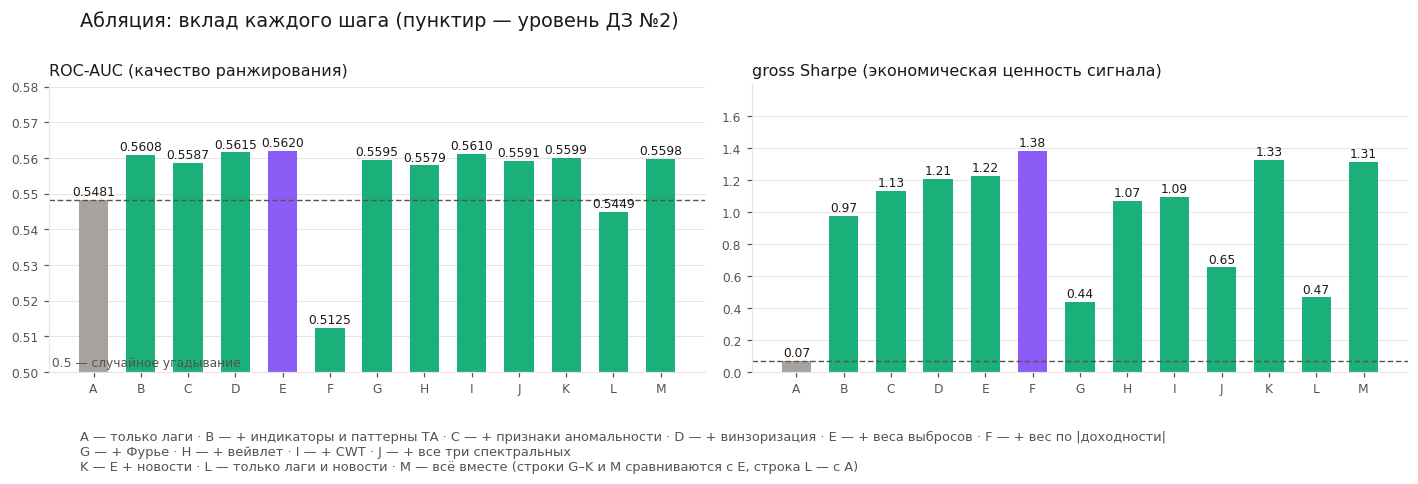

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
labels = [i.split(".")[0] for i in ablation.index]
x = np.arange(len(ablation))
for ax, col, title, fmt in (
        (axes[0], "roc_auc", "ROC-AUC (качество ранжирования)", lambda v: f"{v:.4f}"),
        (axes[1], "gross_sharpe", "gross Sharpe (экономическая ценность сигнала)", lambda v: f"{v:.2f}")):
    vals = ablation[col].to_numpy()
    colors = [COLORS["HW2_Baseline"]] + [COLORS["CatBoost"]] * (len(vals) - 1)
    ax.bar(x, vals, color=colors, width=0.62)
    best = int(np.argmax(vals))
    ax.bar(best, vals[best], color=COLORS["Ensemble"], width=0.62)
    for xi, v in enumerate(vals):
        ax.annotate(fmt(v), xy=(xi, v), xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=8, color=INK)
    ax.axhline(vals[0], color=INK_MUTED, linewidth=0.9, linestyle=(0, (4, 2)))
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(title, color=INK, loc="left", fontsize=10.5)
    # у ROC-AUC содержательный ноль — это 0.5 (случайное угадывание), от него и строим шкалу,
    # иначе разница 0.5455 против 0.5615 визуально неразличима
    floor = 0.5 if col == "roc_auc" else 0.0
    ax.set_ylim(floor, max(vals) + (max(vals) - floor) * 0.30)
    if floor:
        ax.annotate("0.5 — случайное угадывание", xy=(0.005, 0.02), xycoords="axes fraction",
                    fontsize=8, color=INK_MUTED)
    style_ax(ax)
fig.suptitle("Абляция: вклад каждого шага (пунктир — уровень ДЗ №2)",
             fontsize=12.5, color=INK, x=0.06, ha="left", y=1.0)
fig.tight_layout(rect=(0, 0.13, 1, 1))          # место под расшифровку букв под осью
fig.text(0.06, 0.005, "A — только лаги · B — + индикаторы и паттерны ТА · C — + признаки аномальности · "
                      "D — + винзоризация · E — + веса выбросов · F — + вес по |доходности|\n"
                      "G — + Фурье · H — + вейвлет · I — + CWT · J — + все три спектральных\n"
                      "K — E + новости · L — только лаги и новости · M — всё вместе "
                      "(строки G–K и M сравниваются с E, строка L — с A)",
         fontsize=8.5, color=INK_MUTED)
plt.show()

### 12.1 Вклад отдельных групп признаков

Обратная абляция: из полного набора по очереди удаляется одна группа. Чем сильнее падает
метрика, тем важнее группа. Важная оговорка: признаки сильно скоррелированы между группами
(RSI, стохастик и Williams %R измеряют почти одно и то же), поэтому удаление одной группы
редко что-то ломает — оставшиеся её «подменяют». Поэтому здесь надо смотреть не на абсолютную
величину, а на знак и на то, какая группа единственная даёт заметное падение.

  без «доходности»: готово


  без «скользящие средние»: готово


  без «осцилляторы»: готово


  без «волатильность»: готово


  без «объём»: готово


...

  без «CWT»: готово


  без «новости»: готово


  без «календарь»: готово



Полный набор: ROC-AUC = 0.5598, gross Sharpe = 1.311


,признаков осталось,roc_auc,Δ ROC-AUC,gross_sharpe,Δ gross Sharpe
убрана группа,,,,,
новости,307,0.5601,0.0003,0.5064,-0.8043
аномалии,323,0.5570,-0.0028,0.5304,-0.7803
свечные паттерны,288,0.5557,-0.0041,0.6006,-0.7101
паттерны разворота,297,0.5588,-0.0010,0.6671,-0.6436
календарь,326,0.5586,-0.0012,0.7896,-0.5211
паттерны продолжения,314,0.5589,-0.0009,0.8808,-0.4299
CWT,321,0.5588,-0.0010,0.9193,-0.3914
доходности,297,0.5599,0.0001,0.9872,-0.3235
объём,320,0.5600,0.0002,1.0234,-0.2873


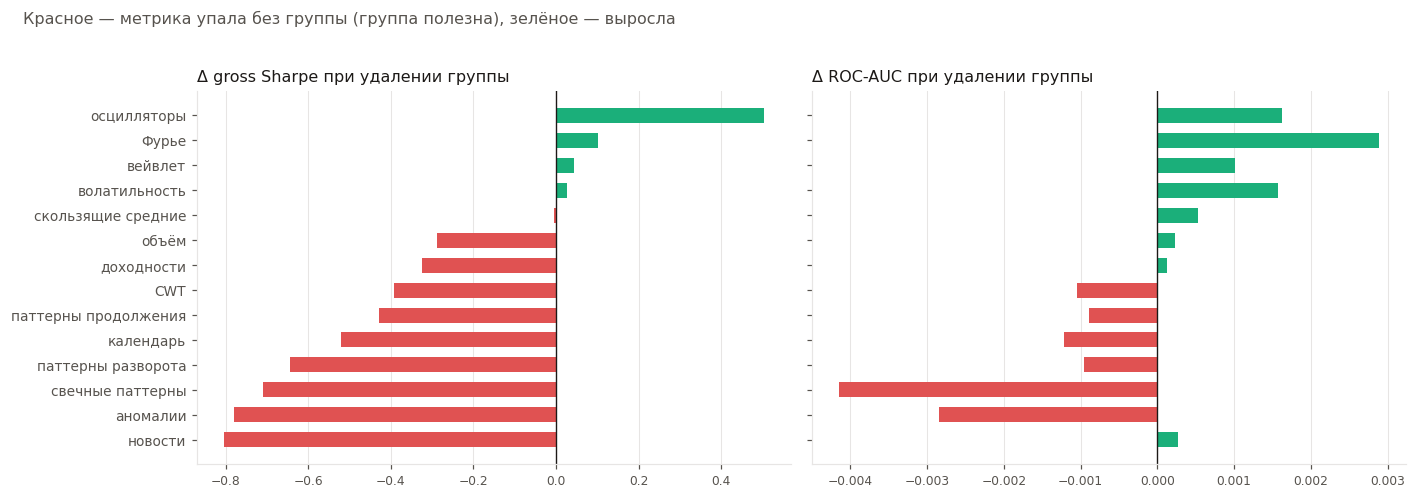

In [33]:
group_rows = []
for gname, gcols in FEATURE_GROUPS.items():
    keep = [c for c in feature_cols if c not in gcols]
    oof, mask = cv_oof(lambda: make_catboost(**CB_FIXED), keep, winsor=True, w_outlier=True)
    group_rows.append({"убрана группа": gname, "признаков осталось": len(keep),
                       **oof_report(oof, mask)})
    print(f"  без «{gname}»: готово")

oof_full, mask_full = cv_oof(lambda: make_catboost(**CB_FIXED), feature_cols,
                             winsor=True, w_outlier=True)
full_report = oof_report(oof_full, mask_full)
group_ablation = pd.DataFrame(group_rows).set_index("убрана группа")
group_ablation["Δ ROC-AUC"] = group_ablation["roc_auc"] - full_report["roc_auc"]
group_ablation["Δ gross Sharpe"] = group_ablation["gross_sharpe"] - full_report["gross_sharpe"]
group_ablation = group_ablation.sort_values("Δ gross Sharpe")
print(f"\nПолный набор: ROC-AUC = {full_report['roc_auc']:.4f}, "
      f"gross Sharpe = {full_report['gross_sharpe']:.3f}")
display(group_ablation[["признаков осталось", "roc_auc", "Δ ROC-AUC",
                        "gross_sharpe", "Δ gross Sharpe"]].round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
yv = np.arange(len(group_ablation))
for ax, col, title in ((axes[0], "Δ gross Sharpe", "Δ gross Sharpe при удалении группы"),
                       (axes[1], "Δ ROC-AUC", "Δ ROC-AUC при удалении группы")):
    ax.barh(yv, group_ablation[col], height=0.6,
            color=[DOWN if v < 0 else UP for v in group_ablation[col]])
    ax.axvline(0, color=INK, linewidth=0.9)
    ax.set_title(title, color=INK, loc="left", fontsize=10.5)
    style_ax(ax, ygrid=False, xgrid=True)
axes[0].set_yticks(yv)
axes[0].set_yticklabels(group_ablation.index, fontsize=9)
fig.suptitle("Красное — метрика упала без группы (группа полезна), зелёное — выросла",
             fontsize=10.5, color=INK_MUTED, x=0.02, ha="left", y=1.02)
fig.tight_layout()
plt.show()

### 12.2 Отбор признаков

После добавления трёх спектральных семейств и новостного блока признаков стало 331, и вопрос «а не мусор ли
половина из них» перестал быть риторическим. Отбор идёт в два шага, оба — **только по
train-части** (не по всему dev): иначе метки test-части dev участвовали бы в выборе набора,
а затем тот же test использовался бы для оценки качества этого набора на кросс-валидации ниже —
отбор утёк бы в собственную проверку. Полный per-fold вложенный отбор (свой набор признаков
для каждого фолда CV) стоил бы кратно дороже при том же объёме кода дальше по ноутбуку
(абляция горизонта, 75 попыток Optuna), поэтому набор фиксируется один раз по train и переносится
на все последующие шаги; валидация в отборе не участвует ни на одном из этапов.

**Шаг 1. Чистка по корреляции.** Признаки сортируются по одномерной силе связи с меткой
(|ROC-AUC − 0.5| каждого признака в отдельности), после чего сверху вниз выбрасывается всё, что
коррелирует с уже оставленным сильнее 0.95. Это убирает буквальные дубли — RSI(7) против RSI(14),
доли энергии соседних полос — не решая, полезен признак или нет.

**Шаг 2. Признаки-тени (shadow features).** Ключевой вопрос — не «какая важность у признака»,
а «больше ли она, чем у заведомо бесполезного признака с тем же распределением». Поэтому к
каждому признаку добавляется его **перемешанная копия**: те же значения, случайно переставленные
во времени, то есть связь с меткой уничтожена, а распределение сохранено. CatBoost обучается на
удвоенном наборе, и порогом становится **максимальная важность среди теней**. Признак проходит,
если его важность выше этого порога.

Порог берётся в двух вариантах. **Строгий** — максимум важности среди всех теней: правило
Boruta, но при нескольких сотнях теней сам максимум — экстремальное значение, и отбор
получается очень жёстким. **Мягкий** — 95-й перцентиль теней: эвристический порог, а не
формальная гарантия false discovery rate — из выбора 95-го перцентиля НЕ следует, что «каждый
двадцатый прошедший признак случаен» (для такой гарантии нужен настоящий контроль FDR с
соответствующими предпосылками, которого здесь нет). Кроме того, перестановка значений признака
разрушает его временную автокорреляцию, поэтому тень отличается от исходного финансового
признака не только отсутствием связи с target — сравнение с тенями остаётся полезной, но
эвристической процедурой. Какой из двух порогов использовать дальше, решает кросс-валидация.
Процедура повторяется `SEL_SHADOW_ROUNDS` раз с разными перестановками, признак проходит, если
прошёл в большинстве попыток. Это упрощённая Boruta — инструмент, который нужен, чтобы ответить,
зарабатывают ли спектральные и новостные признаки своё место или просто добавляют шума. Для
новостей отдельно считается контрольный набор «мягкий отбор без новостей»: те же признаки минус
новостные, на той же кросс-валидации.

Дальше по ноутбуку — подбор гиперпараметров, финальные модели, валидация — используется
**отобранный** набор `MODEL_COLS`.

In [34]:
# Отбор признаков: чистка по корреляции + сравнение с признаками-тенями.
SEL_CORR_THRESHOLD = 0.95
SEL_SHADOW_ROUNDS = 3
SEL_MIN_VOTES = 2
# Порог теней берётся в двух вариантах. Строгий (максимум по всем теням) — правило Boruta,
# но максимум по сотням теней сам по себе экстремальное значение, и отбор получается
# очень жёстким. Мягкий (95-й перцентиль) допускает, что каждый двадцатый прошедший признак —
# случайность. Какой из двух брать, решает кросс-валидация ниже.
SEL_SOFT_QUANTILE = 0.95

# Отбор фитится ТОЛЬКО на train_df (не на dev_df = train+test): иначе метки test-части dev
# участвовали бы в выборе MODEL_COLS, а тот же test затем участвует в CV-оценке качества
# этого набора ниже — колонки утекали бы в собственную проверку (codex_report.md, п.2).
# Итоговый MODEL_COLS переносится на всю дальнейшую цепочку (горизонт, Optuna, финальные
# модели); переселекция на всём dev для финальной модели была бы допустима, но не обязательна.
X_sel = train_df[feature_cols]
y_sel = train_df["target"].to_numpy()
w_sel = sample_weights(train_df, np.arange(len(train_df)), w_outlier=True)

# ── шаг 1: одномерная сила и чистка по корреляции ───────────────────────────
t_start = time.perf_counter()
uni = pd.Series({c: abs(roc_auc_score(y_sel, X_sel[c].to_numpy()) - 0.5) for c in feature_cols})
corr = X_sel.corr().abs().to_numpy()
name_pos = {c: i for i, c in enumerate(feature_cols)}
kept_cols = []
for c in uni.sort_values(ascending=False).index:
    i = name_pos[c]
    if all(corr[i, name_pos[k]] < SEL_CORR_THRESHOLD for k in kept_cols):
        kept_cols.append(c)
assert len(kept_cols) > 0, "чистка по корреляции не оставила ни одного признака"
print(f"Чистка по корреляции (порог {SEL_CORR_THRESHOLD}): "
      f"{len(feature_cols)} -> {len(kept_cols)} признаков, "
      f"{time.perf_counter() - t_start:.0f} с")

# ── шаг 2: признаки-тени ────────────────────────────────────────────────────
t_start = time.perf_counter()
votes = pd.Series(0, index=kept_cols, dtype=int)
votes_soft = pd.Series(0, index=kept_cols, dtype=int)
shadow_thresholds = []
X_kept = X_sel[kept_cols].reset_index(drop=True)
for r in range(SEL_SHADOW_ROUNDS):
    rng = np.random.default_rng(RANDOM_STATE + r)
    shadow = pd.DataFrame({f"shadow__{c}": rng.permutation(X_kept[c].to_numpy())
                           for c in kept_cols})
    both = pd.concat([X_kept, shadow], axis=1)
    model = make_catboost(**CB_FIXED)
    model.fit(both, y_sel, sample_weight=w_sel)
    imp_r = pd.Series(model.get_feature_importance(), index=both.columns)
    sh = imp_r[[f"shadow__{c}" for c in kept_cols]]
    thr, thr_soft = sh.max(), sh.quantile(SEL_SOFT_QUANTILE)
    shadow_thresholds.append((float(thr), float(thr_soft)))
    votes += (imp_r[kept_cols] > thr).astype(int)
    votes_soft += (imp_r[kept_cols] > thr_soft).astype(int)
    print(f"  попытка {r + 1}: порог строгий {thr:.4f} (прошли "
          f"{int((imp_r[kept_cols] > thr).sum())}), мягкий {thr_soft:.4f} (прошли "
          f"{int((imp_r[kept_cols] > thr_soft).sum())}) из {len(kept_cols)}", flush=True)

strict_cols = [c for c in feature_cols if votes.get(c, 0) >= SEL_MIN_VOTES]
soft_cols = [c for c in feature_cols if votes_soft.get(c, 0) >= SEL_MIN_VOTES]
print(f"Строгий отбор: {len(strict_cols)} признаков, мягкий: {len(soft_cols)} "
      f"(из {len(feature_cols)}), {(time.perf_counter() - t_start) / 60:.1f} мин")

# ── что осталось от каждой группы ───────────────────────────────────────────
sel_by_group = pd.DataFrame({
    "было": {g: len(cols) for g, cols in FEATURE_GROUPS.items()},
    "после чистки корреляций": {g: sum(c in kept_cols for c in cols)
                                for g, cols in FEATURE_GROUPS.items()},
    "мягкий отбор": {g: sum(c in soft_cols for c in cols) for g, cols in FEATURE_GROUPS.items()},
    "строгий отбор": {g: sum(c in strict_cols for c in cols)
                      for g, cols in FEATURE_GROUPS.items()},
}).rename_axis("группа")
sel_by_group["доля при мягком"] = (sel_by_group["мягкий отбор"] / sel_by_group["было"]).round(3)
display(sel_by_group.sort_values("доля при мягком", ascending=False))

# ── сравнение наборов на кросс-валидации ────────────────────────────────────
sel_variants = {
    "полный набор": feature_cols,
    "после чистки корреляций": kept_cols,
    "мягкий отбор": soft_cols,
    "строгий отбор": strict_cols,
    "мягкий отбор без спектральных": [c for c in soft_cols if c not in spectral_cols],
    "мягкий отбор без новостей": [c for c in soft_cols if c not in news_cols],
}
sel_rows = []
for label, cols_used in sel_variants.items():
    oof_s, mask_s = cv_oof(lambda: make_catboost(**CB_FIXED), cols_used,
                           winsor=True, w_outlier=True)
    sel_rows.append({"набор": label, "признаков": len(cols_used), **oof_report(oof_s, mask_s)})
    print(f"  {label:36s} готово")
selection_table = pd.DataFrame(sel_rows).set_index("набор")
display(selection_table[["признаков", "accuracy", "f1", "roc_auc", "average_precision",
                         "gross_sharpe", "gross_return"]].round(4))

# Дальше по ноутбуку идёт тот из двух отборов, что лучше по ROC-AUC на кросс-валидации.
best_sel = selection_table.loc[["мягкий отбор", "строгий отбор"], "roc_auc"].idxmax()
MODEL_COLS = sel_variants[best_sel]
survived = [c for c in MODEL_COLS if c in spectral_cols]
survived_news = [c for c in MODEL_COLS if c in news_cols]
print(f"\nВ дальнейшем используется «{best_sel}»: {len(MODEL_COLS)} признаков из "
      f"{len(feature_cols)}, из них спектральных {len(survived)}"
      + (f": {', '.join(survived)}." if survived else "."))
print(f"Из {len(spectral_cols)} спектральных признаков отбор пережили {len(survived)}, "
      f"из {len(news_cols)} новостных — {len(survived_news)}"
      + (f": {', '.join(survived_news)}." if survived_news else "."))

Чистка по корреляции (порог 0.95): 331 -> 307 признаков, 13 с


  попытка 1: порог строгий 0.8935 (прошли 8), мягкий 0.4586 (прошли 23) из 307


  попытка 2: порог строгий 0.7955 (прошли 7), мягкий 0.5021 (прошли 17) из 307


  попытка 3: порог строгий 0.8527 (прошли 8), мягкий 0.5558 (прошли 16) из 307


Строгий отбор: 7 признаков, мягкий: 18 (из 331), 0.9 мин


...

  строгий отбор                        готово


  мягкий отбор без спектральных        готово


  мягкий отбор без новостей            готово


,признаков,accuracy,f1,roc_auc,average_precision,gross_sharpe,gross_return
набор,,,,,,,
полный набор,331,0.5427,0.5554,0.5598,0.5517,1.3107,4.8289
после чистки корреляций,307,0.5451,0.5600,0.5611,0.5498,1.2269,4.0541
мягкий отбор,18,0.5497,0.5716,0.5649,0.5536,2.0607,19.9111
строгий отбор,7,0.5485,0.5621,0.5633,0.5498,1.5116,7.2063
мягкий отбор без спектральных,16,0.5481,0.5670,0.5644,0.5524,1.9119,15.2309
мягкий отбор без новостей,17,0.5489,0.5609,0.5650,0.5525,1.6286,9.0185



В дальнейшем используется «мягкий отбор»: 18 признаков из 331, из них спектральных 2: wl_e_d4, cwt_e_72p.
Из 61 спектральных признаков отбор пережили 2, из 24 новостных — 1: news_count_168.


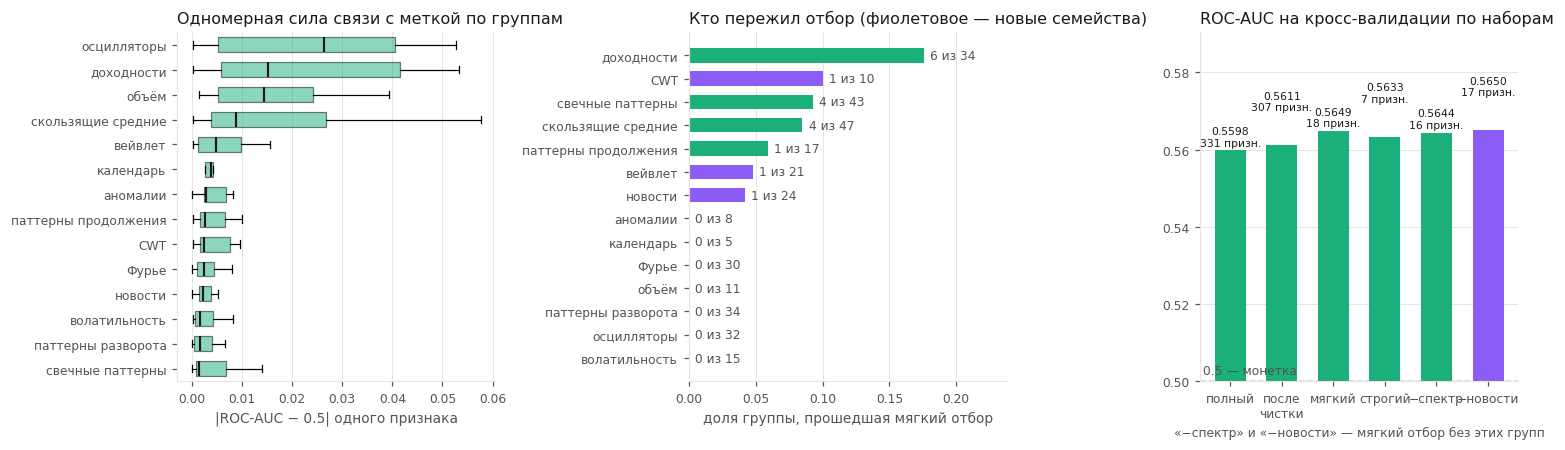

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# ── 1. одномерная сила признаков по группам ─────────────────────────────────
ax = axes[0]
group_of_sel = {c: g for g, cols in FEATURE_GROUPS.items() for c in cols}
uni_df = pd.DataFrame({"группа": [group_of_sel[c] for c in uni.index], "сила": uni.to_numpy()})
grp_order = uni_df.groupby("группа")["сила"].median().sort_values().index
ax.boxplot([uni_df[uni_df["группа"] == g]["сила"].to_numpy() for g in grp_order],
           vert=False, widths=0.6, patch_artist=True, showfliers=False,
           boxprops=dict(facecolor=COLORS["CatBoost"], alpha=0.5, linewidth=0.8),
           medianprops=dict(color=INK, linewidth=1.4), whiskerprops=dict(linewidth=0.8),
           capprops=dict(linewidth=0.8))
ax.set_yticklabels(grp_order, fontsize=8)
ax.set_xlabel("|ROC-AUC − 0.5| одного признака", color=INK_MUTED, fontsize=9)
ax.set_title("Одномерная сила связи с меткой по группам", color=INK, fontsize=10.5, loc="left")
style_ax(ax, ygrid=False, xgrid=True)

# ── 2. доля признаков группы, прошедших отбор ───────────────────────────────
ax = axes[1]
share = sel_by_group.sort_values("доля при мягком")
ys = np.arange(len(share))
NEW_GROUPS = ("Фурье", "вейвлет", "CWT", "новости")
ax.barh(ys, share["доля при мягком"], height=0.62,
        color=[COLORS["Ensemble"] if g in NEW_GROUPS else COLORS["CatBoost"]
               for g in share.index])
for yi, (g, row) in enumerate(share.iterrows()):
    ax.annotate(f"{int(row['мягкий отбор'])} из {int(row['было'])}",
                xy=(row["доля при мягком"], yi), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=8, color=INK_MUTED)
ax.set_yticks(ys)
ax.set_yticklabels(share.index, fontsize=8)
ax.set_xlim(0, max(share["доля при мягком"]) * 1.35)
ax.set_xlabel("доля группы, прошедшая мягкий отбор", color=INK_MUTED, fontsize=9)
ax.set_title("Кто пережил отбор (фиолетовое — новые семейства)",
             color=INK, fontsize=10.5, loc="left")
style_ax(ax, ygrid=False, xgrid=True)

# ── 3. сравнение наборов ────────────────────────────────────────────────────
ax = axes[2]
xs = np.arange(len(selection_table))
vals = selection_table["roc_auc"].to_numpy()
ax.bar(xs, vals, width=0.6, color=[COLORS["CatBoost"]] * len(xs))
best = int(np.argmax(vals))
ax.bar(best, vals[best], width=0.6, color=COLORS["Ensemble"])
for xi, (v, k) in enumerate(zip(vals, selection_table["признаков"])):
    # подписи соседних столбиков разводятся по высоте: иначе «0.5585 331 призн.» и
    # «0.5588 308 призн.» слипаются в нечитаемую строку
    ax.annotate(f"{v:.4f}\n{int(k)} призн.", xy=(xi, v), xytext=(0, 3 + 20 * (xi % 2)),
                textcoords="offset points", ha="center", fontsize=7, color=INK)
ax.axhline(0.5, color=INK_MUTED, linewidth=0.9, linestyle=(0, (4, 2)))
ax.set_ylim(0.5, max(vals) * 1.045)
ax.set_xticks(xs)
SEL_SHORT = {"полный набор": "полный", "после чистки корреляций": "после\nчистки",
             "мягкий отбор": "мягкий", "строгий отбор": "строгий",
             "мягкий отбор без спектральных": "−спектр",
             "мягкий отбор без новостей": "−новости"}
ax.set_xticklabels([SEL_SHORT.get(t, t) for t in selection_table.index],
                   rotation=0, ha="center", fontsize=7.5)
ax.set_xlabel("«−спектр» и «−новости» — мягкий отбор без этих групп",
              color=INK_MUTED, fontsize=8)
ax.set_title("ROC-AUC на кросс-валидации по наборам", color=INK, fontsize=10.5, loc="left")
ax.annotate("0.5 — монетка", xy=(0.01, 0.02), xycoords="axes fraction",
            fontsize=8, color=INK_MUTED)
style_ax(ax)

fig.tight_layout()
plt.show()

## 13. Выбор горизонта прогноза

Направление следующего часа — самая шумная из возможных целей. Логично проверить, не станет ли
задача легче, если предсказывать направление через 6, 12 или 24 часа: сигнал будет более
инерционным, а значит и позиция будет реже меняться. Сравнение идёт на той же
кросс-валидации, с тем же CatBoost и с разрывом фолдов, равным горизонту.

In [36]:
horizon_rows = []
for H in (1, 6, 12, 24):
    d = feat.copy()
    # Маскируем явно по доступности close.shift(-H), не сравнением с NaN (та же правка, что в
    # разделе 8) — здесь это не косметика: при H > 1 fwd_ret (шаг 1) не покрывает весь хвост
    # недоступных меток, и сравнение с NaN тихо превратило бы их в "падение".
    _close_fwd_h = d["close"].shift(-H)
    d["target"] = np.where(_close_fwd_h.notna(), (_close_fwd_h > d["close"]).astype(float), np.nan)
    d = d.dropna(subset=["target", "fwd_ret"]).reset_index(drop=True)
    d["target"] = d["target"].astype(int)
    dev_h = d.iloc[:int(len(d) * TEST_END) - H].reset_index(drop=True)
    oof_h, mask_h = cv_oof(lambda: make_catboost(**CB_FIXED), MODEL_COLS,
                           winsor=True, w_outlier=True, data=dev_h,
                           splitter=TimeSeriesSplit(n_splits=N_CV_SPLITS, gap=H))
    rep = oof_report(oof_h, mask_h, data=dev_h)
    # инерционность прогноза: как часто знак сигнала меняется от бара к бару
    sign_flips = float((np.diff((oof_h[mask_h] >= 0.5).astype(int)) != 0).mean())
    horizon_rows.append({"горизонт, ч": H, "roc_auc": rep["roc_auc"], "average_precision": rep["average_precision"],
                         "accuracy": rep["accuracy"], "gross_sharpe": rep["gross_sharpe"],
                         "смена знака прогноза, доля баров": sign_flips})
    print(f"  горизонт {H:2d} ч: готово")

horizon_tab = pd.DataFrame(horizon_rows).set_index("горизонт, ч")
display(horizon_tab.round(4))
best_h = int(horizon_tab["roc_auc"].idxmax())
print(f"Лучший горизонт по ROC-AUC: {best_h} ч. "
      f"Дальше используется HORIZON = {HORIZON} ч.")
print("Торговля во всех строках остаётся часовой (fwd_ret с шагом 1): это ежечасная торговля по "
      "прогнозу более длинного горизонта, а не оценка сделки с удержанием H часов.")
print("Признаки предварительно отобраны под H=1 (раздел 12.2), поэтому сравнение не является "
      "честным подбором оптимальной постановки для каждого горизонта.")
if bool((horizon_tab["roc_auc"].diff().dropna() < 0).all()):
    print("В этом прогоне ранжирование монотонно ухудшается с ростом горизонта — удлинение "
          "горизонта не помогает.")
else:
    print("В этом прогоне ROC-AUC по горизонтам не монотонен — таблица выше не поддерживает "
          "безусловное утверждение «удлинение горизонта не помогает», читайте по строкам.")

  горизонт  1 ч: готово


  горизонт  6 ч: готово


  горизонт 12 ч: готово


  горизонт 24 ч: готово


,roc_auc,average_precision,accuracy,gross_sharpe,"смена знака прогноза, доля баров"
"горизонт, ч",,,,,
1,0.5664,0.5552,0.5518,2.4916,0.3470
6,0.5383,0.5341,0.5289,0.8501,0.2567
12,0.5286,0.5245,0.5221,0.5263,0.1804
24,0.5226,0.5245,0.5200,-0.0167,0.1308


Лучший горизонт по ROC-AUC: 1 ч. Дальше используется HORIZON = 1 ч.
Торговля во всех строках остаётся часовой (fwd_ret с шагом 1): это ежечасная торговля по прогнозу более длинного горизонта, а не оценка сделки с удержанием H часов.
Признаки предварительно отобраны под H=1 (раздел 12.2), поэтому сравнение не является честным подбором оптимальной постановки для каждого горизонта.
В этом прогоне ранжирование монотонно ухудшается с ростом горизонта — удлинение горизонта не помогает.


## 14. Настройка торгового слоя

Берём OOF-вероятности лучшей конфигурации из абляции и перебираем параметры торгового слоя:
режим, ширину зоны неопределённости `q`, окно сглаживания `span` и период ребалансировки.
Все варианты оцениваются по чистому (net) Sharpe на dev-наборе; валидация не участвует.

**Пороги — только по прошлому.** Квантильные пороги зоны уверенности нельзя считать по
распределению тех же OOF-вероятностей, на которых слой затем оценивается: это означало бы заранее
знать распределение прогнозов тестового участка. Поэтому порог для test-части фолда k считается
по OOF-прогнозам фолдов 0…k−1, которые лежат внутри обучающей части фолда k. У фолда 0 прошлого
нет, поэтому в оценку слоя он не входит: все конфигурации сравниваются на test-частях фолдов 1–4.
Та же процедура (`oof_signal_backtest`) используется везде, где торговый слой оценивается на
OOF: в Optuna (раздел 15), в устойчивости по подпериодам (раздел 16), у моделей
последовательностей (раздел 17) и в парном эксперименте (раздел 18.1). На валидации пороги
зафиксированы по прогнозам финальной модели на dev, то есть на её обучающей выборке (раздел 18).

**Правила выхода подбираются вместе со слоем.** Каждая из 288 конфигураций сигнала
(режим × `q` × `span` × ребалансировка) проверяется с 49 вариантами выхода: стоп-лосс
{нет, 1.5%, 3%, 5%, 8%} × тейк-профит {нет, 3%, 6%, 10%, 15%} × пауза после выхода
{до нового сигнала, не дольше суток}, включая вариант «без стопов» — то есть исходный
торговый слой. Всего 14 112 вариантов на одну модель. Критерий и ограничения прежние:
net Sharpe на фолдах 1–4, оборот, экспозиция и прибыльность подпериодов, но теперь
на фактической позиции после выходов. Если стопы на dev не помогают, подбор оставит слой
без них.


Правило ДЗ №2 «всегда в рынке»: net Sharpe =  -9.37, оборот =    13811 ед., net = -100.0%
Выбранный торговый слой:       net Sharpe =   0.98, оборот =      201 ед., net = +133.0%
  параметры: {'mode': 'hold', 'span': 24, 'rebalance': 6, 'q': 0.02, 'sl': 0.05, 'tp': 0.1, 'cooldown': 24}
  оборот снижен в 69 раз

Топ-10 конфигураций по net Sharpe (колонка «прибыльных блоков» — сколько из 5 подпериодов прибыльны; фильтр требует не меньше 3):


,mode,span,rebalance,sl,tp,cooldown,sharpe,net,gross,turnover,...,time_in_market,экспозиция,стопов,тейков,sharpe_min_блок,прибыльных блоков,q,scale,допустима,устойчива
11848,hold,24,6,0.08,0.00,-1,1.542,1.764,1.798,12.0,...,0.370,0.370,3,0,0.000,4,0.02,NaN,False,False
10672,hold,24,1,0.08,0.00,-1,1.539,1.648,1.680,12.0,...,0.366,0.366,3,0,0.000,4,0.02,NaN,False,False
11838,hold,24,6,0.05,0.00,-1,1.480,1.276,1.304,12.0,...,0.269,0.269,4,0,-1.194,3,0.02,NaN,False,False
10662,hold,24,1,0.05,0.00,-1,1.461,1.196,1.223,12.0,...,0.269,0.269,4,0,-2.588,3,0.02,NaN,False,False
13024,hold,24,24,0.08,0.00,-1,1.431,1.492,1.523,12.0,...,0.365,0.365,3,0,0.000,4,0.02,NaN,False,False
13014,hold,24,24,0.05,0.00,-1,1.320,0.969,0.993,12.0,...,0.248,0.248,5,0,-2.248,2,0.02,NaN,False,False
11845,hold,24,6,0.05,0.10,24,0.977,1.330,1.849,201.0,...,0.876,0.876,56,39,-1.554,3,0.02,NaN,True,True
11835,hold,24,6,0.03,0.10,24,0.918,1.117,1.806,281.0,...,0.834,0.834,96,40,-0.780,3,0.02,NaN,True,True
11810,hold,24,6,0.00,0.03,-1,0.881,0.172,0.186,12.0,...,0.027,0.027,0,6,0.000,4,0.02,NaN,False,False
11850,hold,24,6,0.08,0.03,-1,0.881,0.172,0.186,12.0,...,0.027,0.027,0,6,0.000,4,0.02,NaN,False,False


Из 14112 конфигураций 7871 удовлетворяют требованиям к активности (оборот от 6 единиц капитала в год и средняя экспозиция от 10%), из них 478 прибыльны хотя бы в 3 подпериодах.
Без ограничений победила бы вырожденная конфигурация (hold, Sharpe 1.54) с оборотом 12.0 ед. и средней экспозицией 37.0% — она «зарабатывает» тем, что не торгует.


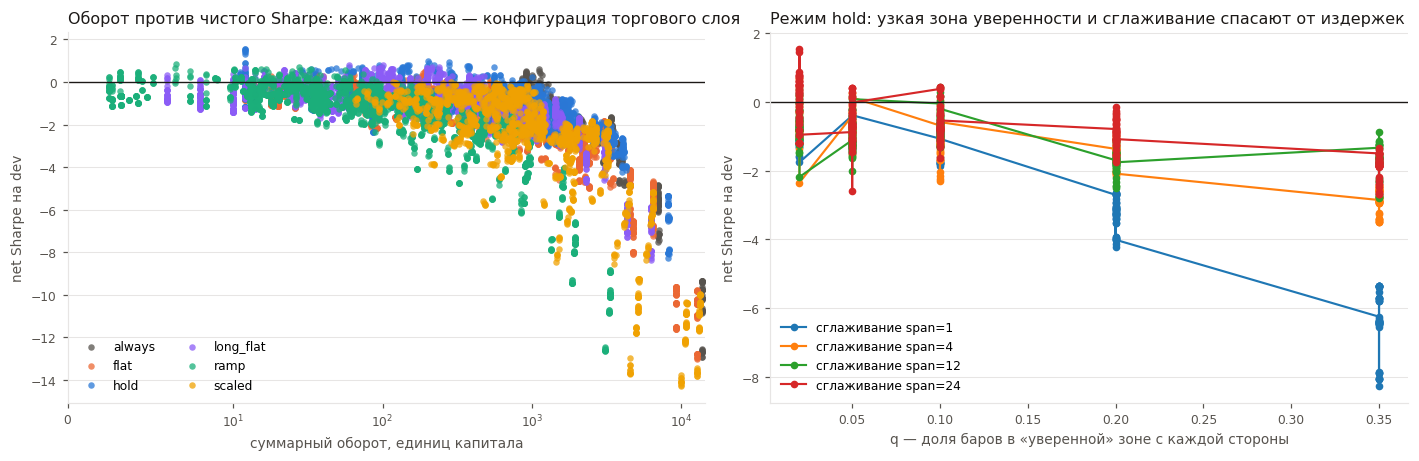

In [37]:
signal_params, signal_tab, signal_ok = tune_signal_layer(
    oof_full[mask_full], dates_dev.to_numpy()[mask_full], fwd_dev.to_numpy()[mask_full],
    DEV_FOLDS[mask_full])

hw2_rule = signal_tab.query("mode == 'always' and span == 1 and rebalance == 1 "
                            "and sl == 0 and tp == 0").iloc[0]
# строка ВЫБРАННОЙ конфигурации — той, что вернул tune_signal_layer с учётом фильтра
# активности. Брать глобальный максимум Sharpe нельзя: без фильтра побеждает конфигурация,
# которая почти не торгует, и напечатанное разошлось бы с реально выбранными параметрами.
sel = np.logical_and.reduce([(signal_tab[k] == v).to_numpy() for k, v in signal_params.items()])
best_row = signal_tab[sel].iloc[0]
print(f"Правило ДЗ №2 «всегда в рынке»: net Sharpe = {hw2_rule['sharpe']:6.2f}, "
      f"оборот = {hw2_rule['turnover']:8.0f} ед., net = {hw2_rule['net']:+.1%}")
print(f"Выбранный торговый слой:       net Sharpe = {best_row['sharpe']:6.2f}, "
      f"оборот = {best_row['turnover']:8.0f} ед., net = {best_row['net']:+.1%}")
print(f"  параметры: {signal_params}")
print(f"  оборот снижен в {hw2_rule['turnover'] / max(best_row['turnover'], 1e-9):.0f} раз")
print(f"\nТоп-10 конфигураций по net Sharpe (колонка «прибыльных блоков» — сколько из "
      f"{N_BLOCKS} подпериодов прибыльны; фильтр требует не меньше {MIN_POSITIVE_BLOCKS}):")
display(signal_tab.sort_values("sharpe", ascending=False).head(10).round(3))
n_feasible = int(signal_tab["допустима"].sum())
n_stable = int((signal_tab["допустима"] &
                (signal_tab["прибыльных блоков"] >= MIN_POSITIVE_BLOCKS)).sum())
print(f"Из {len(signal_tab)} конфигураций {n_feasible} удовлетворяют требованиям к активности "
      f"(оборот от {MIN_TURNOVER_PER_YEAR} единиц капитала в год и средняя экспозиция от "
      f"{MIN_AVG_EXPOSURE:.0%}), из них {n_stable} прибыльны хотя бы в "
      f"{MIN_POSITIVE_BLOCKS} подпериодах.")
best_unconstrained = signal_tab.loc[signal_tab["sharpe"].idxmax()]
if not best_unconstrained["допустима"]:
    print(f"Без ограничений победила бы вырожденная конфигурация "
          f"({best_unconstrained['mode']}, Sharpe {best_unconstrained['sharpe']:.2f}) "
          f"с оборотом {best_unconstrained['turnover']:.1f} ед. и средней экспозицией "
          f"{best_unconstrained['экспозиция']:.1%} — она «зарабатывает» тем, что не торгует.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
mode_colors = {"always": INK_MUTED, "hold": COLORS["LogisticRegression"],
               "flat": COLORS["DecisionTree"], "ramp": COLORS["CatBoost"],
               "long_flat": COLORS["Ensemble"], "scaled": "#f0a202"}
for mode, grp in signal_tab.groupby("mode"):
    axes[0].scatter(grp["turnover"], grp["sharpe"], s=18, alpha=0.75,
                    color=mode_colors[mode], label=mode, linewidth=0)
axes[0].axhline(0, color=INK, linewidth=0.9)
axes[0].set_xscale("symlog", linthresh=10)
axes[0].set_xlim(left=0)
axes[0].set_xlabel("суммарный оборот, единиц капитала", color=INK_MUTED, fontsize=9)
axes[0].set_ylabel("net Sharpe на dev", color=INK_MUTED, fontsize=9)
axes[0].set_title("Оборот против чистого Sharpe: каждая точка — конфигурация торгового слоя",
                  color=INK, loc="left", fontsize=10.5)
axes[0].legend(frameon=False, fontsize=8, ncol=2)
style_ax(axes[0])

sub = signal_tab[(signal_tab["mode"] == "hold") & (signal_tab["rebalance"] == 1)]
for span, grp in sub.groupby("span"):
    g = grp.sort_values("q")
    axes[1].plot(g["q"], g["sharpe"], marker="o", markersize=4, linewidth=1.4,
                 label=f"сглаживание span={span}")
axes[1].axhline(0, color=INK, linewidth=0.9)
axes[1].set_xlabel("q — доля баров в «уверенной» зоне с каждой стороны", color=INK_MUTED, fontsize=9)
axes[1].set_ylabel("net Sharpe на dev", color=INK_MUTED, fontsize=9)
axes[1].set_title("Режим hold: узкая зона уверенности и сглаживание спасают от издержек",
                  color=INK, loc="left", fontsize=10.5)
axes[1].legend(frameon=False, fontsize=8)
style_ax(axes[1])
fig.tight_layout()
plt.show()

### 14.1 Что правила выхода делают с торговым слоем на dev

Срез той же таблицы подбора: выбранная конфигурация сигнала и все 49 вариантов выхода.
Ниже — сравнение со слоем без стопов и доля конфигураций сигнала, которым стопы вообще
помогают. Числа здесь — метрика подбора на dev, а не независимая оценка.

,sharpe,net,gross,turnover,n_trades,экспозиция,стопов,тейков,прибыльных блоков
лучший слой без стопов (как в исходном ноутбуке),0.346853,0.146554,0.400591,200.0,200,0.145018,0,0,3
"выбранный сигнал, стопы выключены",0.463459,0.299842,0.314198,11.0,6,0.977122,0,0,3
выбранный сигнал + SL 5.0% / TP 10%,0.976803,1.329891,1.849133,201.0,196,0.876338,56,39,3


Стопы улучшают net Sharpe у 97% из 288 конфигураций сигнала; медианный прирост лучшего варианта выхода +0.39; по режимам: always +0.23, flat +0.23, hold +0.95, long_flat +0.29, ramp +0.41, scaled +0.23


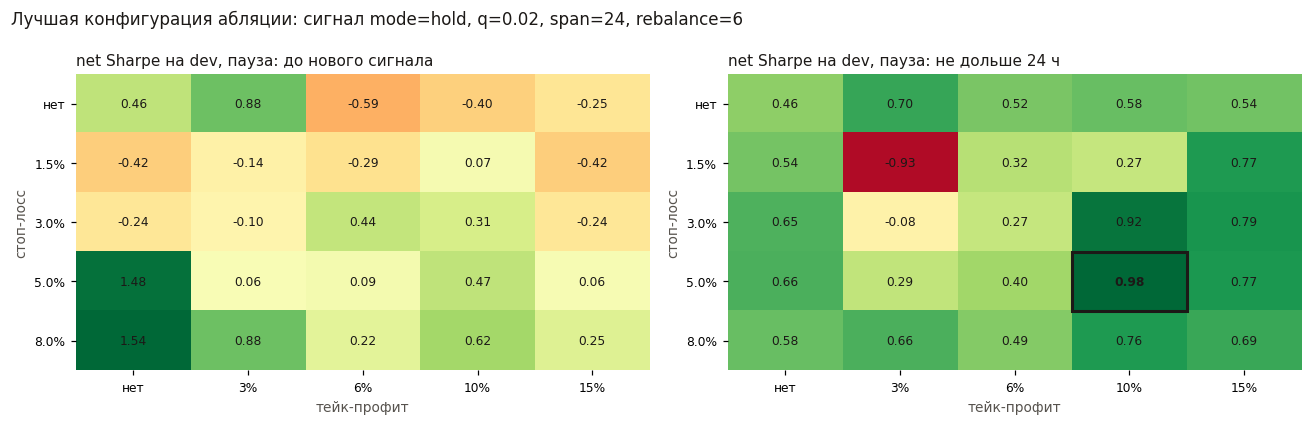

In [38]:
SIG_KEYS = ["mode", "q", "scale", "span", "rebalance"]


def exit_surface(tab, params):
    """Срез таблицы tune_signal_layer: та же конфигурация сигнала, все правила выхода."""
    m = np.ones(len(tab), dtype=bool)
    for k in SIG_KEYS:
        if k not in tab.columns:
            continue
        m &= (tab[k] == params[k]).to_numpy() if k in params else tab[k].isna().to_numpy()
    return tab[m]


def exit_row(surf, sl, tp, cooldown):
    sel = (surf["sl"] == sl) & (surf["tp"] == tp)
    if sl > 0 or tp > 0:
        sel &= surf["cooldown"] == cooldown
    return surf[sel].iloc[0]


def plot_exit_heatmap(ax, surf, cooldown, value="sharpe", chosen=None, title=""):
    """Тепловая карта value по сетке SL × TP при заданной паузе; (0, 0) — без стопов."""
    grid = np.full((len(SL_GRID), len(TP_GRID)), np.nan)
    for i, sl in enumerate(SL_GRID):
        for j, tp in enumerate(TP_GRID):
            grid[i, j] = exit_row(surf, sl, tp, cooldown)[value]
    lim = np.nanmax(np.abs(grid)) or 1.0
    ax.imshow(grid, cmap="RdYlGn", vmin=-lim, vmax=lim, aspect="auto")
    for i in range(len(SL_GRID)):
        for j in range(len(TP_GRID)):
            is_chosen = (chosen is not None and SL_GRID[i] == chosen["sl"]
                         and TP_GRID[j] == chosen["tp"]
                         and (chosen["cooldown"] == cooldown or chosen["sl"] == chosen["tp"] == 0))
            ax.text(j, i, f"{grid[i, j]:.2f}", ha="center", va="center", fontsize=8,
                    color=INK, fontweight="bold" if is_chosen else "normal")
            if is_chosen:
                ax.add_patch(Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor=INK,
                                       linewidth=2))
    ax.set_xticks(range(len(TP_GRID)))
    ax.set_xticklabels(["нет" if v == 0 else f"{v:.0%}" for v in TP_GRID], fontsize=8)
    ax.set_yticks(range(len(SL_GRID)))
    ax.set_yticklabels(["нет" if v == 0 else f"{v:.1%}" for v in SL_GRID], fontsize=8)
    ax.set_xlabel("тейк-профит", color=INK_MUTED, fontsize=9)
    ax.set_ylabel("стоп-лосс", color=INK_MUTED, fontsize=9)
    ax.set_title(title, color=INK, fontsize=10, loc="left")
    for s in ax.spines.values():
        s.set_visible(False)


def cooldown_label(cd):
    return "до нового сигнала" if cd < 0 else f"не дольше {cd} ч"


def exit_gain_by_signal(tab):
    """Для каждой конфигурации сигнала: лучший Sharpe с выходами минус Sharpe без них."""
    keys = [k for k in SIG_KEYS if k in tab.columns]
    key = tab[keys].fillna(-1).astype(str).agg("|".join, axis=1)
    has_exit = (tab["sl"] > 0) | (tab["tp"] > 0)
    off = tab["sharpe"][~has_exit].groupby(key[~has_exit]).first()
    on = tab["sharpe"][has_exit].groupby(key[has_exit]).max()
    mode = tab["mode"][~has_exit].groupby(key[~has_exit]).first()
    return pd.DataFrame({"gain": on - off, "mode": mode}).dropna()


surf_dev = exit_surface(signal_tab, signal_params)
row_on = exit_row(surf_dev, signal_params["sl"], signal_params["tp"], signal_params["cooldown"])
row_off = exit_row(surf_dev, 0.0, 0.0, -1)
no_exit_pool = signal_tab[(signal_tab["sl"] == 0) & (signal_tab["tp"] == 0) & signal_tab["устойчива"]]
row_best_off = no_exit_pool.loc[no_exit_pool["sharpe"].idxmax()] if len(no_exit_pool) else row_off
cols = ["sharpe", "net", "gross", "turnover", "n_trades", "экспозиция", "стопов", "тейков",
        "прибыльных блоков"]
display(pd.DataFrame({
    "лучший слой без стопов (как в исходном ноутбуке)": row_best_off[cols],
    "выбранный сигнал, стопы выключены": row_off[cols],
    f"выбранный сигнал + SL {signal_params['sl']:.1%} / TP {signal_params['tp']:.0%}": row_on[cols],
}).T.round(3))
gain = exit_gain_by_signal(signal_tab)
print(f"Стопы улучшают net Sharpe у {(gain['gain'] > 0).mean():.0%} из {len(gain)} конфигураций "
      f"сигнала; медианный прирост лучшего варианта выхода {gain['gain'].median():+.2f}; "
      f"по режимам: " + ", ".join(f"{m} {v:+.2f}" for m, v in
                                  gain.groupby("mode")["gain"].median().items()))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.9))
for ax, cd in zip(axes, COOLDOWN_GRID):
    plot_exit_heatmap(ax, surf_dev, cd, chosen=signal_params,
                      title=f"net Sharpe на dev, пауза: {cooldown_label(cd)}")
fig.suptitle(f"Лучшая конфигурация абляции: сигнал {', '.join(f'{k}={signal_params[k]}' for k in SIG_KEYS if k in signal_params)}",
             x=0.01, ha="left", fontsize=11, color=INK)
fig.tight_layout()
plt.show()

**Что видно на dev.** Для конфигурации из абляции лучший слой без стопов даёт net Sharpe 0.35
(+14.7%, как в исходном ноутбуке). Подбор со стопами выбрал другой сигнал (`hold`, q=0.02,
span=24, ребалансировка раз в 6 ч) со стопом 5%, тейком 10% и возвратом через сутки:
Sharpe 0.98, net +133%. Тот же сигнал без стопов почти не торгует (6 сделок, оборот 11)
и не проходит фильтр активности. Выходы по стопу и тейку превращают его в торговую систему
с 196 сделками.

Стопы улучшают лучший достижимый Sharpe у **97% из 288 конфигураций сигнала** (медиана +0.39,
у режима `hold` — +0.95). Оговорка: у каждого сигнала теперь 49 вариантов выхода, и максимум
по 49 шумным оценкам почти всегда выше одной. Часть этого прироста — эффект множественного
перебора, а не польза стопов. Проверить её может только валидация (раздел 18.3).

## 15. Подбор гиперпараметров: Optuna + кросс-валидация временных рядов

> Кросс-валидация временных рядов: данные разбиваются на k частей (fold), обучение идёт на
> частях, предшествующих тестированию, и процедура повторяется k раз.

Используется `TimeSeriesSplit` (расширяющееся окно) на dev-наборе (train + test) с разрывом
`gap = EMBARGO`. Валидационная выборка в подборе не участвует.

Optuna максимизирует **чистый (net) коэффициент Шарпа** — метрику, которая уже включает издержки.
Внутри каждой попытки:

1. считаются OOF-вероятности на 5 фолдах;
2. на них подбирается торговый слой (раздел 14): пороги каждого фолда — по OOF предыдущих
   фолдов, оценка — на фолдах 1–4;
3. значением попытки становится net Sharpe при лучшем торговом слое.

Дополнительно перебирается способ взвешивания наблюдений (`w_ret`) — тот самый приём из
раздела 12, который улучшает экономику ценой ROC-AUC. Все остальные метрики сохраняются
в `user_attrs`, чтобы затем сопоставить статистическое качество с экономикой.

**Защита от вырождения.** У задачи «максимизировать Sharpe» есть тривиальное решение:
не торговать. Стратегия с нулевым оборотом не платит комиссий, а если её крошечная
постоянная позиция случайно совпала с направлением рынка на dev-периоде, формальный Sharpe
получается прекрасным. При первом запуске Optuna нашла ровно такой угол: логистическая
регрессия с `C = 3e-4` и штрафом L1 почти обнуляла коэффициенты, выдавала почти постоянную
вероятность, а торговый слой превращал её в неподвижную позицию размером 7% капитала —
CV Sharpe 1.42 при обороте 0.15 единицы в год. Формально это лучший Sharpe из всех, фактически
это buy & hold с плечом 0.07, замаскированный под модель. Поэтому попытка штрафуется значением
`DEGENERATE_PENALTY`, если разброс OOF-вероятностей меньше 0.001 (модель ничего не ранжирует)
или если ни одна конфигурация торгового слоя не проходит требования к активности из раздела 14.

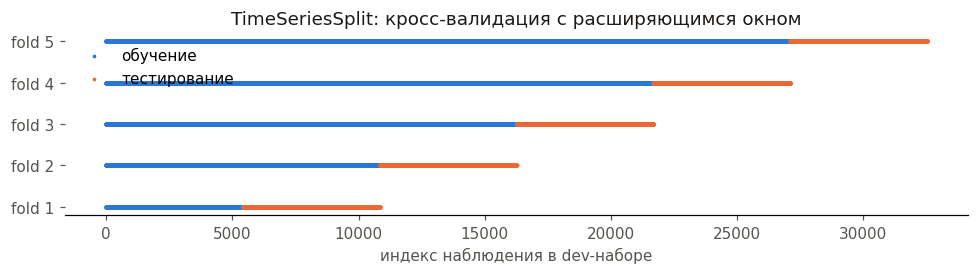

In [39]:
fig, ax = plt.subplots(figsize=(9, 2.6))
for i, (tr_idx, te_idx) in enumerate(tscv.split(X_dev_all)):
    ax.scatter(tr_idx, [i] * len(tr_idx), c=COLORS["LogisticRegression"], s=2,
               label="обучение" if i == 0 else None)
    ax.scatter(te_idx, [i] * len(te_idx), c=COLORS["DecisionTree"], s=2,
               label="тестирование" if i == 0 else None)
ax.set_yticks(range(N_CV_SPLITS))
ax.set_yticklabels([f"fold {i + 1}" for i in range(N_CV_SPLITS)])
ax.set_xlabel("индекс наблюдения в dev-наборе", color=INK_MUTED)
ax.set_title("TimeSeriesSplit: кросс-валидация с расширяющимся окном", color=INK)
ax.legend(loc="upper left", frameon=False)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.tick_params(colors=INK_MUTED)
fig.tight_layout()
plt.show()


DEGENERATE_PENALTY = -10.0        # значение попытки, если модель или слой вырождены


def objective_factory(build_from_params, param_space):
    """Единая целевая функция: OOF -> торговый слой -> net Sharpe."""
    def objective(trial):
        params = param_space(trial)
        w_ret = trial.suggest_categorical("w_ret", [False, True])
        oof, mask = cv_oof(lambda: build_from_params(params), MODEL_COLS,
                           winsor=True, w_outlier=True, w_ret=w_ret)
        d, f = dates_dev.to_numpy()[mask], fwd_dev.to_numpy()[mask]
        # вырожденная модель (почти постоянная вероятность) не ранжирует ничего:
        # любая «прибыль» от неё — это отказ от торговли, а не прогноз
        if float(np.std(oof[mask])) < 1e-3:
            trial.set_user_attr("degenerate", True)
            return DEGENERATE_PENALTY
        sig_prm, _, ok = tune_signal_layer(oof[mask], d, f, DEV_FOLDS[mask])
        if not ok:
            trial.set_user_attr("degenerate", True)
            return DEGENERATE_PENALTY
        _, trade = oof_signal_backtest(oof[mask], d, f, DEV_FOLDS[mask], sig_prm)
        rep = oof_report(oof, mask)
        for k, v in {**rep, **{f"trade_{k}": v for k, v in trade.items()}}.items():
            trial.set_user_attr(k, float(v))
        trial.set_user_attr("signal_params", sig_prm)
        return trade["sharpe"]
    return objective


def run_study(objective, name):
    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    a = study.best_trial.user_attrs
    n_deg = sum(1 for t in study.trials if t.user_attrs.get("degenerate"))
    # Значения ниже — метрика ПОДБОРА на dev (торговый слой и его пороги настроены на том же
    # OOF-периоде, который оценивается), а не независимая out-of-sample оценка: независимая
    # оценка — раздел 18, где пороги зафиксированы по dev-распределению финальной модели и
    # перенесены на validation без пересчёта (codex_report.md, пункт 15).
    print(f"{name}: лучший net Sharpe (подбор на dev) = {study.best_value:.3f} "
          f"({N_TRIALS} попыток, отклонено как вырожденные: {n_deg})")
    if a.get("degenerate") or "signal_params" not in a:
        # Все попытки вырожденные — у best_trial нет signal_params/roc_auc и т.п.; раньше
        # обращение к ним падало с KeyError (codex_report.md, пункт 29).
        print(f"  ВСЕ {N_TRIALS} попыток отклонены как вырожденные — нет ни одной содержательной "
              f"конфигурации модели/слоя в этом пространстве поиска.")
        return study
    print(f"  гиперпараметры:  {study.best_params}")
    print(f"  торговый слой:   {a['signal_params']}")
    print(f"  на тех же фолдах: ROC-AUC={a['roc_auc']:.4f}, accuracy={a['accuracy']:.4f}, "
          f"F1={a['f1']:.4f} | net={a['trade_total_return']:+.2%}, "
          f"gross={a['trade_gross_return']:+.2%}, оборот={a['trade_turnover_units']:.0f}")
    return study


def make_logreg(**params):
    # RobustScaler вместо StandardScaler: медиана и межквартильный размах не «съезжают»
    # от экстремальных баров, что важно на тяжёлых хвостах криптодоходностей.
    return Pipeline([
        ("scaler", RobustScaler(quantile_range=(5, 95))),
        ("clf", LogisticRegression(max_iter=500, tol=1e-3, random_state=RANDOM_STATE, **params)),
    ])


def make_tree(**params):
    return DecisionTreeClassifier(random_state=RANDOM_STATE, **params)

In [40]:
def space_logreg(trial):
    params = {
        "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
        "penalty": trial.suggest_categorical("penalty", ["l1", "l2"]),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
    }
    params["solver"] = "saga" if params["penalty"] == "l1" else "lbfgs"
    return params


study_logreg = run_study(objective_factory(lambda p: make_logreg(**p), space_logreg),
                         "LogisticRegression")

LogisticRegression: лучший net Sharpe (подбор на dev) = 2.268 (25 попыток, отклонено как вырожденные: 0)
  гиперпараметры:  {'C': 1.6924580548130095, 'penalty': 'l2', 'class_weight': None, 'w_ret': True}
  торговый слой:   {'mode': 'hold', 'span': 4, 'rebalance': 1, 'q': 0.02, 'sl': 0.0, 'tp': 0.06, 'cooldown': -1}
  на тех же фолдах: ROC-AUC=0.4976, accuracy=0.4985, F1=0.5628 | net=+121.29%, gross=+135.39%, оборот=62


In [41]:
def space_tree(trial):
    return {
        "max_depth": trial.suggest_int("max_depth", 2, 14),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 200),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 300),
        "max_features": trial.suggest_float("max_features", 0.2, 1.0),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
    }


study_tree = run_study(objective_factory(lambda p: make_tree(**p), space_tree), "DecisionTree")

DecisionTree: лучший net Sharpe (подбор на dev) = 2.494 (25 попыток, отклонено как вырожденные: 0)
  гиперпараметры:  {'max_depth': 3, 'min_samples_split': 83, 'min_samples_leaf': 49, 'max_features': 0.22153126556521793, 'criterion': 'entropy', 'w_ret': True}
  торговый слой:   {'mode': 'scaled', 'span': 24, 'rebalance': 24, 'scale': 25.0, 'sl': 0.08, 'tp': 0.1, 'cooldown': -1}
  на тех же фолдах: ROC-AUC=0.5098, accuracy=0.5098, F1=0.6206 | net=+137.70%, gross=+170.95%, оборот=131


In [42]:
def space_catboost(trial):
    return {
        "depth": trial.suggest_int("depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 20.0, log=True),
        "iterations": trial.suggest_int("iterations", 100, 500),
        "rsm": trial.suggest_float("rsm", 0.3, 1.0),
    }


study_catboost = run_study(objective_factory(lambda p: make_catboost(**p), space_catboost),
                           "CatBoost")

CatBoost: лучший net Sharpe (подбор на dev) = 3.223 (25 попыток, отклонено как вырожденные: 0)
  гиперпараметры:  {'depth': 7, 'learning_rate': 0.013589328909885286, 'l2_leaf_reg': 3.879333946524696, 'iterations': 178, 'rsm': 0.36060441187623177, 'w_ret': True}
  торговый слой:   {'mode': 'hold', 'span': 4, 'rebalance': 24, 'q': 0.02, 'sl': 0.03, 'tp': 0.15, 'cooldown': -1}
  на тех же фолдах: ROC-AUC=0.5214, accuracy=0.5126, F1=0.5357 | net=+461.40%, gross=+496.11%, оборот=60


In [43]:
studies = {"LogisticRegression": study_logreg, "DecisionTree": study_tree, "CatBoost": study_catboost}
tuning_summary = pd.DataFrame([
    {
        "model": name,
        "net Sharpe (подбор на dev)": st.best_value,
        "CV roc_auc": st.best_trial.user_attrs["roc_auc"],
        "CV average_precision": st.best_trial.user_attrs["average_precision"],
        "CV gross Sharpe": st.best_trial.user_attrs["gross_sharpe"],
        "CV net": st.best_trial.user_attrs["trade_total_return"],
        "CV оборот": st.best_trial.user_attrs["trade_turnover_units"],
        "вес по |ret|": st.best_params.get("w_ret"),
        "торговый слой": st.best_trial.user_attrs["signal_params"],
    }
    for name, st in studies.items()
]).set_index("model")
display(tuning_summary.drop(columns="торговый слой").round(4))
for name, st in studies.items():
    print(f"{name}:\n  модель: {st.best_params}\n  слой:   {st.best_trial.user_attrs['signal_params']}")

,net Sharpe (подбор на dev),CV roc_auc,CV average_precision,CV gross Sharpe,CV net,CV оборот,вес по |ret|
model,,,,,,,
LogisticRegression,2.2681,0.4976,0.4974,2.7342,1.2129,62.0000,True
DecisionTree,2.4935,0.5098,0.5087,2.5210,1.3770,131.0479,True
CatBoost,3.2228,0.5214,0.5193,2.5098,4.6140,60.0000,True


LogisticRegression:
  модель: {'C': 1.6924580548130095, 'penalty': 'l2', 'class_weight': None, 'w_ret': True}
  слой:   {'mode': 'hold', 'span': 4, 'rebalance': 1, 'q': 0.02, 'sl': 0.0, 'tp': 0.06, 'cooldown': -1}
DecisionTree:
  модель: {'max_depth': 3, 'min_samples_split': 83, 'min_samples_leaf': 49, 'max_features': 0.22153126556521793, 'criterion': 'entropy', 'w_ret': True}
  слой:   {'mode': 'scaled', 'span': 24, 'rebalance': 24, 'scale': 25.0, 'sl': 0.08, 'tp': 0.1, 'cooldown': -1}
CatBoost:
  модель: {'depth': 7, 'learning_rate': 0.013589328909885286, 'l2_leaf_reg': 3.879333946524696, 'iterations': 178, 'rsm': 0.36060441187623177, 'w_ret': True}
  слой:   {'mode': 'hold', 'span': 4, 'rebalance': 24, 'q': 0.02, 'sl': 0.03, 'tp': 0.15, 'cooldown': -1}


## 16. Финальные модели

Модели с лучшими гиперпараметрами переобучаются на всём dev-наборе (train + test) — тех же
данных, на которых шёл подбор, и на отобранном наборе признаков `MODEL_COLS` из раздела 12.2.
Границы винзоризации и веса наблюдений считаются по dev.
Режим торгового слоя и ширина зоны `q` берутся из подбора на OOF (раздел 15), а сами числовые
пороги считаются как квантили **dev-прогнозов уже обученной финальной модели** — именно она
уходит в эксплуатацию, и её распределение вероятностей отличается от OOF (подробнее — в
`apply_signal`, раздел 18). На валидации применяются эти зафиксированные пороги, а не
пересчитанные по будущим данным квантили.

Дополнительно строится **ансамбль** — среднее вероятностей трёх моделей. Усреднение снижает
дисперсию прогноза, а значит и число ложных переворотов позиции.

In [44]:
final_specs = {
    "LogisticRegression": (make_logreg, {**{k: v for k, v in study_logreg.best_params.items()
                                            if k != "w_ret"}}),
    "DecisionTree": (make_tree, {k: v for k, v in study_tree.best_params.items() if k != "w_ret"}),
    "CatBoost": (make_catboost, {k: v for k, v in study_catboost.best_params.items() if k != "w_ret"}),
}
final_specs["LogisticRegression"][1]["solver"] = (
    "saga" if final_specs["LogisticRegression"][1]["penalty"] == "l1" else "lbfgs")

dev_bounds = winsor_bounds(dev_df[MODEL_COLS])
X_dev_w = apply_winsor(dev_df[MODEL_COLS], dev_bounds)
X_val_w = apply_winsor(val_df[MODEL_COLS], dev_bounds)
y_dev_full, y_val = dev_df["target"], val_df["target"]

final_models, dev_oof, val_proba, signal_by_model, dev_proba_final = {}, {}, {}, {}, {}
for name, (builder, params) in final_specs.items():
    w_ret = studies[name].best_params.get("w_ret", False)
    # OOF на dev — источник и порогов торгового слоя, и эталонного распределения вероятностей
    oof, mask = cv_oof(lambda: builder(**params), MODEL_COLS,
                       winsor=True, w_outlier=True, w_ret=w_ret)
    dev_oof[name] = (oof, mask)
    signal_by_model[name] = studies[name].best_trial.user_attrs["signal_params"]

    model = builder(**params)
    w = sample_weights(dev_df, np.arange(len(dev_df)), w_outlier=True, w_ret=w_ret)
    if hasattr(model, "steps"):
        model.fit(X_dev_w, y_dev_full, **{f"{model.steps[-1][0]}__sample_weight": w})
    else:
        model.fit(X_dev_w, y_dev_full, sample_weight=w)
    final_models[name] = model
    dev_proba_final[name] = predict_proba1(model, X_dev_w)
    val_proba[name] = predict_proba1(model, X_val_w)
    print(f"{name}: обучена на {len(X_dev_w)} наблюдениях, "
          f"средняя вероятность роста на валидации {val_proba[name].mean():.3f}")

# ансамбль: усреднение вероятностей, торговый слой подбирается на усреднённом OOF
common_mask = np.all([dev_oof[n][1] for n in final_models], axis=0)
ens_oof = np.nanmean(np.vstack([dev_oof[n][0] for n in final_models]), axis=0)
signal_by_model["Ensemble"], _, _ = tune_signal_layer(
    ens_oof[common_mask], dates_dev.to_numpy()[common_mask], fwd_dev.to_numpy()[common_mask],
    DEV_FOLDS[common_mask])
dev_oof["Ensemble"] = (ens_oof, common_mask)
dev_proba_final["Ensemble"] = np.mean([dev_proba_final[n] for n in final_models], axis=0)
val_proba["Ensemble"] = np.mean([val_proba[n] for n in final_models], axis=0)
print(f"Ensemble: торговый слой {signal_by_model['Ensemble']}")

LogisticRegression: обучена на 32521 наблюдениях, средняя вероятность роста на валидации 0.516


DecisionTree: обучена на 32521 наблюдениях, средняя вероятность роста на валидации 0.518


CatBoost: обучена на 32521 наблюдениях, средняя вероятность роста на валидации 0.513


/tmp/ipykernel_1241030/1918440200.py:38: RuntimeWarning: Mean of empty slice
  ens_oof = np.nanmean(np.vstack([dev_oof[n][0] for n in final_models]), axis=0)


Ensemble: торговый слой {'mode': 'always', 'span': 12, 'rebalance': 24, 'sl': 0.0, 'tp': 0.15, 'cooldown': 24}


In [45]:
# Устойчивость выбранных стратегий на dev: Sharpe по подпериодам OOF-периода.
stability_rows = []
for name in list(final_models) + ["Ensemble"]:
    oof, mask = dev_oof[name]
    curve, m = oof_signal_backtest(oof[mask], dates_dev.to_numpy()[mask], fwd_dev.to_numpy()[mask],
                                   DEV_FOLDS[mask], signal_by_model[name])
    blocks = np.array_split(curve["strategy_return"].to_numpy(), N_BLOCKS)
    row = {"стратегия": name, "net Sharpe (весь dev)": m["sharpe"]}
    for bi, b in enumerate(blocks, 1):
        row[f"блок {bi}"] = float(b.mean() / b.std(ddof=0) * np.sqrt(PERIODS_PER_YEAR)) if b.std(ddof=0) > 0 else 0.0
    row["прибыльных блоков"] = int(sum(row[f"блок {bi}"] > 0 for bi in range(1, N_BLOCKS + 1)))
    stability_rows.append(row)
print("Sharpe по подпериодам dev-выборки (фолды 1-4; проверка, что результат не держится на одной сделке):")
display(pd.DataFrame(stability_rows).set_index("стратегия").round(3))

Sharpe по подпериодам dev-выборки (фолды 1-4; проверка, что результат не держится на одной сделке):


,net Sharpe (весь dev),блок 1,блок 2,блок 3,блок 4,блок 5,прибыльных блоков
стратегия,,,,,,,
LogisticRegression,2.268,3.509,3.682,1.639,2.138,0.000,4
DecisionTree,2.494,3.077,3.335,1.146,4.765,-2.165,4
CatBoost,3.223,4.457,5.091,0.108,3.151,2.976,5
Ensemble,2.299,2.307,2.905,1.848,4.833,-0.142,4


### 16.1 Воспроизведение стратегии ДЗ №2 как точки отсчёта

Чтобы улучшение измерялось честно, рядом строится стратегия из ДЗ №2 на тех же выборках:
CatBoost по одним лагам доходности, без обработки выбросов, правило «всегда в рынке».

In [46]:
hw2_model = make_catboost(iterations=200, depth=4, learning_rate=0.05)
hw2_model.fit(dev_df[lag_cols], y_dev_full)
hw2_val_proba = predict_proba1(hw2_model, val_df[lag_cols])
print(f"ДЗ №2: {len(lag_cols)} признаков-лагов, правило «всегда в рынке», без торгового слоя.")

# «ТА без слоя»: те же признаки и обработка выбросов, что в ДЗ №3, но правило торговли из ДЗ №2.
# Эта промежуточная точка отделяет вклад признаков от вклада торгового слоя на валидации.
ta_model = make_catboost(**CB_FIXED)
ta_model.fit(X_dev_w, y_dev_full,
             sample_weight=sample_weights(dev_df, np.arange(len(dev_df)), w_outlier=True))
ta_val_proba = predict_proba1(ta_model, X_val_w)
print(f"ТА без слоя: {len(MODEL_COLS)} отобранных признаков + обработка выбросов, "
      f"правило торговли то же — «всегда в рынке».")

ДЗ №2: 12 признаков-лагов, правило «всегда в рынке», без торгового слоя.


ТА без слоя: 18 отобранных признаков + обработка выбросов, правило торговли то же — «всегда в рынке».


## 17. Модели последовательностей: TimesNet, TSMixer и TimesFM 2.0

Все модели разделов 12–16 видят бар как строку таблицы: 331 число, посчитанное по прошлому
(после отбора раздела 12.2 остаётся 18), — и ничего не знают о том, в каком порядке шли сами
бары. Порядок зашит внутрь признаков (лаги, скользящие средние, длины серий), но как
последовательность модель его не воспринимает. Здесь
добавляются три модели принципиально другого устройства — TimesNet и TSMixer получают на вход
окно из 168 последних баров (неделю часовых данных) как многомерный ряд из 14 непрерывных
признаков ТА; у TimesFM 2.0 представление другое — 512 одномерных лог-доходностей без
дополнительных каналов (подробности и причина — раздел 17.3), поэтому 168×14 ниже относится
только к TimesNet/TSMixer.

**TimesNet** (Wu et al., «TimesNet: Temporal 2D-Variation Modeling for General Time Series
Analysis», ICLR 2023) сам ищет в окне периодичность: одномерный ряд разворачивается в двумерную
«картинку» (столбец — фаза внутри периода, строка — номер цикла), после чего зависимости внутри
периода и между периодами обрабатываются обычными 2D-свёртками. Периоды не задаются руками, а
берутся как top-k пиков амплитудного спектра (FFT), то есть модель сама решает, есть ли в
часовом биткоине суточный или недельный ритм.

**TSMixer** (Chen et al., «TSMixer: An All-MLP Architecture for Time Series Forecasting», TMLR
2023) — противоположный по духу ответ на ту же задачу: никаких свёрток и внимания, только
чередование двух линейных слоёв. Один смешивает информацию **по времени** (для каждого канала
отдельно), второй — **по каналам** (для каждого момента отдельно). Статья показывает, что на
многих бенчмарках этого достаточно, чтобы догнать трансформеры при кратно меньшей стоимости.
Для нас это ещё и полезная контрольная точка: если сложный TimesNet не обыгрывает стопку MLP,
значит, дело не в архитектуре.

**TimesFM 2.0** (Das et al., «A decoder-only foundation model for time-series forecasting»,
ICML 2024; веса `google/timesfm-2.0-500m-pytorch`) — foundation-модель: 500 млн параметров,
предобученных на сотнях миллиардов точек чужих временных рядов. Она отвечает на отдельный
вопрос: сколько из этого предобучения переносится на часовой BTC — при применении как есть,
при использовании её представления и после дообучения верхних слоёв под нашу задачу. Все три
режима проверяются в разделе 17.3.

TimesNet и TSMixer выписаны здесь по статьям, а не взяты из библиотеки: обе архитектуры
компактны, а видеть, что именно считается, важнее экономии двадцати строк — к тому же обе модели
тогда проходят через один и тот же обучающий цикл, и их сравнение не смешивается с различиями в
оптимизаторе, расписании и весах наблюдений. TimesFM переиспользуется как есть — предобученные
веса воспроизвести нельзя.

Все три модели проходят через тот же конвейер, что и остальные: вероятность роста → торговый
слой из раздела 9 → бэктест с теми же издержками → те же метрики. Только при таком условии
сравнение имеет смысл.

In [47]:
# Представление ряда для моделей последовательностей.
#
# Каналы — 14 непрерывных признаков ТА, покрывающих цену, тренд, импульс, волатильность,
# объём и геометрию свечи. Все они уже проверены на причинность в разделе 7.4, поэтому
# окно [t-167 ... t] не содержит ничего, что не было бы известно к моменту t.
SEQ_LEN = 168                       # окно модели: 168 часов = ровно неделя
SEQ_CHANNELS = [
    "ret_1",              # доходность бара
    "tr_atr",             # истинный диапазон в ATR
    "atr_14",             # нормированный ATR — уровень волатильности
    "close_ema20_ratio",  # отклонение цены от EMA(20)
    "close_sma50_atr",    # удалённость от SMA(50) в ATR
    "rsi_14",             # импульс
    "macd_hist",          # гистограмма MACD
    "bb_pctb",            # положение в полосе Боллинджера
    "adx",                # сила тренда
    "di_diff",            # направление тренда
    "vol_z_24",           # z-оценка объёма
    "vwap_dev",           # отклонение от VWAP
    "clv",                # положение закрытия внутри бара
    "cdl_net_score",      # свечные паттерны: бычьи минус медвежьи
]
assert all(c in feature_cols for c in SEQ_CHANNELS), "канал отсутствует в матрице признаков"

SEQ_RAW = feat[SEQ_CHANNELS].to_numpy(np.float32)
SEQ_TARGET = feat["target"].to_numpy(np.float32)
SEQ_ANOM = feat["anom_any"].to_numpy(np.float32)
SEQ_MIN_IDX = SEQ_LEN - 1           # первые бары окном не покрываются


def sequence_windows(fit_idx):
    """Стандартизованные окна ряда. Медиана и IQR берутся ТОЛЬКО по обучающим барам.

    Возвращает представление формы [n - SEQ_LEN + 1, каналы, SEQ_LEN]: окно, заканчивающееся
    на баре t, лежит по индексу t - SEQ_LEN + 1. Это numpy-view, копий полного массива нет.
    """
    med = np.median(SEQ_RAW[fit_idx], axis=0)
    iqr = np.subtract(*np.percentile(SEQ_RAW[fit_idx], [75, 25], axis=0))
    iqr[iqr < 1e-9] = 1.0
    z = np.clip((SEQ_RAW - med) / iqr, -8.0, 8.0).astype(np.float32)   # клип вместо винзоризации
    return np.lib.stride_tricks.sliding_window_view(z, SEQ_LEN, axis=0)


def window_batch(win, idx):
    """Батч [B, SEQ_LEN, каналы] для баров idx (idx — абсолютные позиции в feat)."""
    return torch.from_numpy(win[idx - (SEQ_LEN - 1)].transpose(0, 2, 1).copy())


print(f"Окно {SEQ_LEN} баров × {len(SEQ_CHANNELS)} каналов; "
      f"полных окон: {len(feat) - SEQ_MIN_IDX} из {len(feat)} баров")
print(f"Устройство: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})"
                                 if DEVICE.type == "cuda" else ""))

Окно 168 баров × 14 каналов; полных окон: 38095 из 38262 баров
Устройство: cuda (NVIDIA GeForce RTX 3090)


In [48]:
# Общий обучающий цикл для TimesNet и TSMixer.
#
# Соглашения ровно те же, что у табличных моделей конвейера: веса наблюдений понижены на
# аномальных барах (раздел 11), статистики стандартизации считаются только по train-части
# фолда, оптимизатор и расписание одинаковы для обеих архитектур. Разница между моделями —
# только в самой модели, и это единственное, что должно объяснять разницу в результате.
SEQ_BATCH = 256
# 1, а не 512: fft_periods усредняет амплитуды по батчу (dim=0), поэтому инференс батчами
# из нескольких окон делает выбор периодов для бара t зависимым от более поздних окон
# того же батча — крупица будущего просачивается в прогноз. При SEQ_INFER_BATCH = 1 это
# усреднение по батчу вырождается в тождество (батч из одного окна), и выбор периодов для
# бара t использует только сам этот бар. На обучении (seq_fit) батч из train-индексов не
# создаёт такой утечки: все окна батча уже принадлежат обучающей выборке.
SEQ_INFER_BATCH = 1


def seq_fit(build, win, tr_idx, epochs, lr, seed=RANDOM_STATE):
    """Обучение на барах tr_idx. Возвращает (модель, история значений функции потерь)."""
    torch.manual_seed(seed)
    model = build().to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    n_steps = epochs * int(np.ceil(len(tr_idx) / SEQ_BATCH))
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, total_steps=n_steps,
                                                pct_start=0.25)
    gen = torch.Generator().manual_seed(seed)
    w_all = np.where(SEQ_ANOM > 0, OUTLIER_WEIGHT, 1.0).astype(np.float32)
    history = []
    for _ in range(epochs):
        model.train()
        order = torch.randperm(len(tr_idx), generator=gen).numpy()
        running = 0.0
        for s in range(0, len(tr_idx), SEQ_BATCH):
            b = tr_idx[order[s:s + SEQ_BATCH]]
            xb = window_batch(win, b).to(DEVICE)
            yb = torch.from_numpy(SEQ_TARGET[b]).to(DEVICE)
            wb = torch.from_numpy(w_all[b]).to(DEVICE)
            loss = (F.binary_cross_entropy_with_logits(model(xb), yb, reduction="none")
                    * wb).sum() / wb.sum()
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            sched.step()
            running += float(loss) * len(b)
        history.append(running / len(tr_idx))
    return model, history


def seq_predict(model, win, idx):
    """Вероятность роста для баров idx."""
    model.eval()
    out = []
    with torch.no_grad():
        for s in range(0, len(idx), SEQ_INFER_BATCH):
            xb = window_batch(win, idx[s:s + SEQ_INFER_BATCH]).to(DEVICE)
            out.append(torch.sigmoid(model(xb)).float().cpu().numpy())
    return np.concatenate(out)


def seq_cv_oof(build, epochs, lr):
    """OOF-вероятности на dev по тем же фолдам TimeSeriesSplit, что у табличных моделей."""
    oof = np.full(len(dev_df), np.nan)
    fold_history = []
    for tr_idx, te_idx in tscv.split(X_dev_all):
        tr_idx = tr_idx[tr_idx >= SEQ_MIN_IDX]         # первым барам не хватает окна
        win = sequence_windows(tr_idx)                 # статистики — по train-части фолда
        model, hist = seq_fit(build, win, tr_idx, epochs, lr)
        oof[te_idx] = seq_predict(model, win, te_idx)
        fold_history.append(hist)
        del model
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
    return oof, ~np.isnan(oof), fold_history


def seq_evaluate(oof, mask):
    """OOF -> торговый слой -> экономика. Тот же критерий, что у Optuna в разделе 15."""
    d_, f_ = dates_dev.to_numpy()[mask], fwd_dev.to_numpy()[mask]
    sig_prm, _, ok = tune_signal_layer(oof[mask], d_, f_, DEV_FOLDS[mask])
    _, trade = oof_signal_backtest(oof[mask], d_, f_, DEV_FOLDS[mask], sig_prm)
    return oof_report(oof, mask), trade, sig_prm, ok

### 17.1 TimesNet

Один блок TimesNet работает так:

1. **FFT** по окну даёт амплитудный спектр; берутся `top_k` частот с наибольшей амплитудой,
   каждая переводится в период `p = SEQ_LEN / f`.
2. **Разворот в 2D**: ряд длины `T` перекладывается в матрицу `(T/p) × p` — строки это
   последовательные циклы, столбцы — фаза внутри цикла. Соседи по столбцу теперь означают
   «тот же час вчера», соседи по строке — «следующий час».
3. **2D-свёртки** блоком Inception (параллельные ядра разного размера) обрабатывают эту
   матрицу: одна и та же свёртка ловит и внутрисуточную форму, и связь между сутками.
4. **Агрегация**: результаты по разным периодам складываются с весами softmax от амплитуд —
   период с более выраженным пиком получает больший вес. Плюс остаточная связь.

**Причинность.** Периоды выбираются по среднему спектру **батча** (усреднение по `dim=0` в
`fft_periods`) — так сделано в оригинальной реализации. При инференсе батчами из нескольких
окон подряд это означало бы, что выбор периодов для бара `t` зависит и от более поздних окон
того же батча: в прогноз просачивается крупица информации из будущего. Чтобы этого избежать,
инференс (`seq_predict`, все OOF/dev/val-прогнозы) идёт батчами по **одному** окну
(`SEQ_INFER_BATCH = 1`): усреднение по батчу вырождается в тождество, и периоды для бара `t`
выбираются только по данным, известным к `t`. На обучении (`seq_fit`) батчи собраны из
train-индексов текущего фолда, поэтому смешивание внутри батча не создаёт утечки относительно
test/val — все окна батча уже принадлежат обучающей выборке. Строгая причинность на инференсе
проверялась: замена соседних окон в батче не меняет прогноз для неизменного окна.

Поверх нескольких таких блоков ставится голова классификации: GELU → dropout → линейный слой
на одну логит-величину, из которой сигмоидой получается вероятность роста. Это ровно та же
величина, что выдают LogReg, дерево и CatBoost, — значит, и торговый слой, и метрики
применимы без изменений.

In [49]:
def fft_periods(x, k):
    """top-k доминирующих периодов окна и их амплитуды (шаг 1 блока TimesNet)."""
    xf = torch.fft.rfft(x, dim=1)                      # [B, T//2+1, C]
    amp = xf.abs().mean(dim=0).mean(dim=-1)            # усреднение по батчу и каналам
    amp[0] = 0.0                                       # нулевая частота — это среднее, не период
    _, idx = torch.topk(amp, k)
    periods = (x.shape[1] // idx).clamp(min=1)
    return periods.tolist(), xf.abs().mean(dim=-1)[:, idx]      # веса периодов, [B, k]


class InceptionBlock(nn.Module):
    """Параллельные 2D-свёртки разных масштабов (Inception V1 из оригинальной реализации)."""

    def __init__(self, c_in, c_out, num_kernels):
        super().__init__()
        self.convs = nn.ModuleList([nn.Conv2d(c_in, c_out, 2 * i + 1, padding=i)
                                    for i in range(num_kernels)])

    def forward(self, x):
        return torch.stack([conv(x) for conv in self.convs], dim=-1).mean(-1)


class TimesBlock(nn.Module):
    """1D-ряд → 2D (цикл × фаза) → свёртки → обратно, с суммированием по периодам."""

    def __init__(self, d_model, d_ff, top_k, num_kernels):
        super().__init__()
        self.k = top_k
        self.conv = nn.Sequential(InceptionBlock(d_model, d_ff, num_kernels), nn.GELU(),
                                  InceptionBlock(d_ff, d_model, num_kernels))
        self.last_periods = []                          # для диагностики: что выбрал FFT

    def forward(self, x):
        B, T, N = x.shape
        periods, weights = fft_periods(x, self.k)
        self.last_periods = periods
        res = []
        for p in periods:
            pad = (-T) % p                              # добиваем до целого числа циклов
            out = F.pad(x, (0, 0, 0, pad)) if pad else x
            L = T + pad
            out = out.reshape(B, L // p, p, N).permute(0, 3, 1, 2).contiguous()   # [B,N,цикл,фаза]
            out = self.conv(out)
            res.append(out.permute(0, 2, 3, 1).reshape(B, L, N)[:, :T])
        w = F.softmax(weights, dim=1).unsqueeze(1).unsqueeze(1)                   # [B,1,1,k]
        return (torch.stack(res, dim=-1) * w).sum(-1) + x                         # остаточная связь


class TimesNetClassifier(nn.Module):
    """TimesNet с головой бинарной классификации: P(следующий бар выше текущего)."""

    def __init__(self, c_in, seq_len, d_model=32, d_ff=32, e_layers=2, top_k=3,
                 num_kernels=4, dropout=0.2):
        super().__init__()
        self.embed = nn.Conv1d(c_in, d_model, 3, padding=1, padding_mode="circular", bias=False)
        self.pos = nn.Parameter(torch.zeros(1, seq_len, d_model))
        self.blocks = nn.ModuleList([TimesBlock(d_model, d_ff, top_k, num_kernels)
                                     for _ in range(e_layers)])
        self.norms = nn.ModuleList([nn.LayerNorm(d_model) for _ in range(e_layers)])
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(seq_len * d_model, 1)

    def forward(self, x):                               # x: [B, T, C]
        h = self.embed(x.transpose(1, 2)).transpose(1, 2) + self.pos
        for blk, nrm in zip(self.blocks, self.norms):
            h = nrm(blk(h))
        return self.head(self.drop(F.gelu(h)).flatten(1)).squeeze(-1)


demo = TimesNetClassifier(len(SEQ_CHANNELS), SEQ_LEN)
print(f"TimesNet: параметров {sum(p.numel() for p in demo.parameters()):,}".replace(",", " "))
print(f"  из них в голове классификации: "
      f"{sum(p.numel() for p in demo.head.parameters()):,}".replace(",", " "))
del demo

TimesNet: параметров 356 801
  из них в голове классификации: 5 377


### 17.2 TSMixer

TSMixer — это стопка одинаковых блоков, в каждом из которых ровно два действия:

1. **Смешивание по времени.** Матрица окна `T × C` транспонируется, и один линейный слой
   `T → T` применяется к каждому каналу независимо. Он учит, какие моменты окна складывать
   с какими весами, — то есть подбирает себе фильтр вроде скользящего среднего, но не
   заданный руками, а выученный.
2. **Смешивание по каналам.** Двухслойный MLP `C → d_ff → C` применяется к каждому моменту
   независимо: это учёт того, что RSI, ATR и объём в один и тот же час связаны между собой.

Оба действия обёрнуты в нормализацию и остаточные связи. Дополнительно перед первым блоком
стоит **RevIN** — обратимая нормализация окна: из каждого окна вычитается его собственное
среднее и делится на собственное стандартное отклонение. Для нестационарного ряда это
существенно: модель перестаёт видеть разницу между «биткоин по 20 тысяч» и «по 100 тысяч» и
смотрит только на форму движения.

Отличие от оригинала одно и оно намеренное: в статье внутри блока стоит `BatchNorm2d` по всей
карте `T × C`, здесь — `LayerNorm` по каналам. При обучении батчами из соседних часов
батч-статистики сильно плавают между окнами спокойного и бурного рынка; послойная нормализация
от этого не зависит и на нашем ряде сходится заметно стабильнее.

Голова здесь шире, чем у TimesNet: dropout → линейный слой на 64 нейрона → GELU → dropout →
линейный слой на одну логит-величину → сигмоида. И она же — самая тяжёлая часть модели:
развёрнутое окно составляет 168 × 14 = 2352 числа, поэтому первый слой головы `2352 → 64` весит
150 657 параметров — больше половины всех 271 957. У TimesNet вход головы блоками уже сжат до
168 × 32 и отображается в логит напрямую, отчего голова стоит всего 5 377 параметров из 356 801.
Это стоит держать в уме при сравнении: у TSMixer заметная доля ёмкости лежит не в блоках-смесителях,
а в голове, и уменьшение числа блоков (конфигурация B) сокращает модель слабее, чем кажется.

In [50]:
class RevIN(nn.Module):
    """Обратимая нормализация окна (Kim et al., ICLR 2022): снимает уровень и масштаб.

    Считается по самому окну, а не по обучающей выборке, поэтому подглядывания нет:
    в окне [t-167 ... t] нет ничего, что не было бы известно к моменту t.
    """

    def __init__(self, c_in, eps=1e-5):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(c_in))
        self.beta = nn.Parameter(torch.zeros(c_in))
        self.eps = eps

    def forward(self, x):                               # [B, T, C]
        m = x.mean(dim=1, keepdim=True)
        s = x.std(dim=1, keepdim=True) + self.eps
        return (x - m) / s * self.gamma + self.beta


class MixerBlock(nn.Module):
    """Блок TSMixer: смешивание по времени, затем по каналам."""

    def __init__(self, seq_len, c_in, d_ff, dropout):
        super().__init__()
        self.norm_time = nn.LayerNorm(c_in)
        self.time_mix = nn.Sequential(nn.Linear(seq_len, seq_len), nn.GELU(), nn.Dropout(dropout))
        self.norm_feat = nn.LayerNorm(c_in)
        self.feat_mix = nn.Sequential(nn.Linear(c_in, d_ff), nn.GELU(), nn.Dropout(dropout),
                                      nn.Linear(d_ff, c_in), nn.Dropout(dropout))

    def forward(self, x):                               # [B, T, C]
        h = self.norm_time(x).transpose(1, 2)           # [B, C, T] — время становится последним
        x = x + self.time_mix(h).transpose(1, 2)        # каналы смешиваются независимо друг от друга
        return x + self.feat_mix(self.norm_feat(x))     # моменты смешиваются независимо друг от друга


class TSMixerClassifier(nn.Module):
    """TSMixer с головой бинарной классификации: P(следующий бар выше текущего)."""

    def __init__(self, c_in, seq_len, n_blocks=4, d_ff=64, d_head=64, dropout=0.2):
        super().__init__()
        self.revin = RevIN(c_in)
        self.blocks = nn.ModuleList([MixerBlock(seq_len, c_in, d_ff, dropout)
                                     for _ in range(n_blocks)])
        self.drop = nn.Dropout(dropout)
        self.head = nn.Sequential(nn.Linear(seq_len * c_in, d_head), nn.GELU(),
                                  nn.Dropout(dropout), nn.Linear(d_head, 1))

    def forward(self, x):                               # x: [B, T, C]
        h = self.revin(x)
        for blk in self.blocks:
            h = blk(h)
        return self.head(self.drop(h).flatten(1)).squeeze(-1)


demo = TSMixerClassifier(len(SEQ_CHANNELS), SEQ_LEN)
print(f"TSMixer: параметров {sum(p.numel() for p in demo.parameters()):,}".replace(",", " "))
print(f"  из них в голове классификации: "
      f"{sum(p.numel() for p in demo.head.parameters()):,}".replace(",", " "))
del demo

TSMixer: параметров 271 957
  из них в голове классификации: 150 657


In [51]:
# Подбор конфигураций TimesNet и TSMixer.
#
# Критерий тот же, что у Optuna в разделе 15: OOF-вероятности -> торговый слой -> net Sharpe.
# Но перебор здесь короткий и ручной: одна конфигурация обучается на пяти фолдах минуты,
# а не миллисекунды, и 25 попыток TPE на каждую архитектуру стоили бы часы. Это ограничение
# бюджета, а не утверждение, что нейросетям не нужен более тонкий подбор.
SEQ_GRID = {
    "TimesNet": [
        ("A: d_model 32, 2 блока, top_k 3",
         dict(d_model=32, d_ff=32, e_layers=2, top_k=3, num_kernels=4, dropout=0.2), 8, 1e-3),
        ("B: уже (d_model 16), сильнее dropout",
         dict(d_model=16, d_ff=32, e_layers=2, top_k=3, num_kernels=4, dropout=0.3), 8, 1e-3),
        ("C: один блок, зато top_k 5",
         dict(d_model=32, d_ff=64, e_layers=1, top_k=5, num_kernels=4, dropout=0.2), 8, 1e-3),
        ("D: конфигурация A, но дольше и мягче",
         dict(d_model=32, d_ff=32, e_layers=2, top_k=3, num_kernels=4, dropout=0.2), 14, 5e-4),
    ],
    "TSMixer": [
        ("A: 4 блока, d_ff 64", dict(n_blocks=4, d_ff=64, d_head=64, dropout=0.2), 8, 1e-3),
        ("B: 2 блока — вдвое меньше ёмкости",
         dict(n_blocks=2, d_ff=64, d_head=64, dropout=0.2), 8, 1e-3),
        ("C: 6 блоков, сильнее dropout",
         dict(n_blocks=6, d_ff=128, d_head=64, dropout=0.35), 8, 1e-3),
        ("D: конфигурация A, но дольше и мягче",
         dict(n_blocks=4, d_ff=64, d_head=64, dropout=0.2), 14, 5e-4),
    ],
}
SEQ_BUILDERS = {
    "TimesNet": lambda cfg: (lambda: TimesNetClassifier(len(SEQ_CHANNELS), SEQ_LEN, **cfg)),
    "TSMixer": lambda cfg: (lambda: TSMixerClassifier(len(SEQ_CHANNELS), SEQ_LEN, **cfg)),
}

seq_rows, seq_runs, seq_best = [], {}, {}
for arch, grid in SEQ_GRID.items():
    for label, cfg, epochs, lr in grid:
        t_start = time.perf_counter()
        oof, mask, hist = seq_cv_oof(SEQ_BUILDERS[arch](cfg), epochs, lr)
        rep, trade, sig_prm, ok = seq_evaluate(oof, mask)
        minutes = (time.perf_counter() - t_start) / 60
        seq_runs[(arch, label)] = dict(cfg=cfg, epochs=epochs, lr=lr, oof=oof, mask=mask,
                                       history=hist, signal=sig_prm)
        seq_rows.append({"архитектура": arch, "конфигурация": label, "эпох": epochs,
                         "CV net Sharpe": trade["sharpe"], "CV net": trade["total_return"],
                         "CV roc_auc": rep["roc_auc"], "CV average_precision": rep["average_precision"],
                         "разброс OOF": float(oof[mask].std()),
                         "оборот": trade["turnover_units"], "слой допустим": ok,
                         "минут": minutes})
        print(f"  {arch:9s} {label:38s} {minutes:4.1f} мин | "
              f"net Sharpe {trade['sharpe']:+.3f}, ROC-AUC {rep['roc_auc']:.4f}", flush=True)

seq_table = pd.DataFrame(seq_rows).set_index(["архитектура", "конфигурация"])
display(seq_table.round(4))

for arch in SEQ_GRID:
    sub = seq_table.loc[arch]
    best_label = sub["CV net Sharpe"].idxmax()
    run = seq_runs[(arch, best_label)]
    seq_best[arch] = {**run, "label": best_label}
    dev_oof[arch] = (run["oof"], run["mask"])
    signal_by_model[arch] = run["signal"]
    print(f"\n{arch}: выбрана конфигурация «{best_label}» — {run['cfg']}, "
          f"эпох {run['epochs']}, lr {run['lr']:g}")
    print(f"  торговый слой: {run['signal']}")
print(f"\nДля сравнения, лучший CV net Sharpe у табличных моделей: "
      f"{max(st.best_value for st in studies.values()):.3f}")

  TimesNet  A: d_model 32, 2 блока, top_k 3        10.6 мин | net Sharpe +1.778, ROC-AUC 0.5254


  TimesNet  B: уже (d_model 16), сильнее dropout    9.7 мин | net Sharpe +1.469, ROC-AUC 0.5254


  TimesNet  C: один блок, зато top_k 5              9.5 мин | net Sharpe +1.752, ROC-AUC 0.5282


  TimesNet  D: конфигурация A, но дольше и мягче   16.6 мин | net Sharpe +1.122, ROC-AUC 0.5257


  TSMixer   A: 4 блока, d_ff 64                     4.4 мин | net Sharpe +0.852, ROC-AUC 0.5223


  TSMixer   B: 2 блока — вдвое меньше ёмкости       3.5 мин | net Sharpe +1.352, ROC-AUC 0.5250


  TSMixer   C: 6 блоков, сильнее dropout            5.4 мин | net Sharpe +1.428, ROC-AUC 0.5307


  TSMixer   D: конфигурация A, но дольше и мягче    5.9 мин | net Sharpe +0.908, ROC-AUC 0.5225


эпох  CV net Sharpe  CV net  \
архитектура конфигурация                                                        
TimesNet    A: d_model 32, 2 блока, top_k 3          8         1.7775  5.0318   
            B: уже (d_model 16), сильнее dropout     8         1.4685  1.9568   
            C: один блок, зато top_k 5               8         1.7524  1.1066   
            D: конфигурация A, но дольше и мягче    14         1.1217  0.7773   
TSMixer     A: 4 блока, d_ff 64                      8         0.8520  0.7030   
            B: 2 блока — вдвое меньше ёмкости        8         1.3518  0.7375   
            C: 6 блоков, сильнее dropout             8         1.4281  0.6174   
            D: конфигурация A, но дольше и мягче    14         0.9083  0.6257   

                                                  CV roc_auc  \
архитектура конфигурация                                       
TimesNet    A: d_model 32, 2 блока, top_k 3           0.5254   
            B: уже (d_model 16), сильнее dropout      0.5254   
            C: один блок, зато top_k 5                0.5282   
            D: конфигурация A, но дольше и мягче      0.5257   
TSMixer     A: 4 блока, d_ff 64                       0.5223   
            B: 2 блока — вдвое меньше ёмкости         0.5250   
            C: 6 блоков, сильнее dropout              0.5307   
            D: конфигурация A, но дольше и мягче      0.5225   

                                                  CV average_precision  \
архитектура конфигурация                                                 
TimesNet    A: d_model 32, 2 блока, top_k 3                     0.5213   
            B: уже (d_model 16), сильнее dropout                0.5237   
            C: один блок, зато top_k 5                          0.5252   
            D: конфигурация A, но дольше и мягче                0.5252   
TSMixer     A: 4 блока, d_ff 64                                 0.5218   
            B: 2 блока — вдвое меньше ёмкости                   0.5221   
            C: 6 блоков, сильнее dropout                        0.5281   
            D: конфигурация A, но дольше и мягче                0.5207   

                                                  разброс OOF  оборот  \
архитектура конфигурация                                                
TimesNet    A: d_model 32, 2 блока, top_k 3            0.1522   207.0   
            B: уже (d_model 16), сильнее dropout       0.1017    30.0   
            C: один блок, зато top_k 5                 0.1521    38.0   
            D: конфигурация A, но дольше и мягче       0.1583    74.0   
TSMixer     A: 4 блока, d_ff 64                        0.2194   254.0   
            B: 2 блока — вдвое меньше ёмкости          0.2076    66.0   
            C: 6 блоков, сильнее dropout               0.0922    48.0   
            D: конфигурация A, но дольше и мягче       0.2358   160.0   

                                                  слой допустим    минут  
архитектура конфигурация                                                  
TimesNet    A: d_model 32, 2 блока, top_k 3                True  10.6294  
            B: уже (d_model 16), сильнее dropout           True   9.7065  
            C: один блок, зато top_k 5                     True   9.5336  
            D: конфигурация A, но дольше и мягче           True  16.5966  
TSMixer     A: 4 блока, d_ff 64                            True   4.3719  
            B: 2 блока — вдвое меньше ёмкости              True   3.5269  
            C: 6 блоков, сильнее dropout                   True   5.3639  
            D: конфигурация A, но дольше и мягче           True   5.8594


TimesNet: выбрана конфигурация «A: d_model 32, 2 блока, top_k 3» — {'d_model': 32, 'd_ff': 32, 'e_layers': 2, 'top_k': 3, 'num_kernels': 4, 'dropout': 0.2}, эпох 8, lr 0.001
  торговый слой: {'mode': 'hold', 'span': 12, 'rebalance': 6, 'q': 0.02, 'sl': 0.08, 'tp': 0.1, 'cooldown': 24}

TSMixer: выбрана конфигурация «C: 6 блоков, сильнее dropout» — {'n_blocks': 6, 'd_ff': 128, 'd_head': 64, 'dropout': 0.35}, эпох 8, lr 0.001
  торговый слой: {'mode': 'hold', 'span': 24, 'rebalance': 1, 'q': 0.05, 'sl': 0.03, 'tp': 0.06, 'cooldown': -1}

Для сравнения, лучший CV net Sharpe у табличных моделей: 3.223


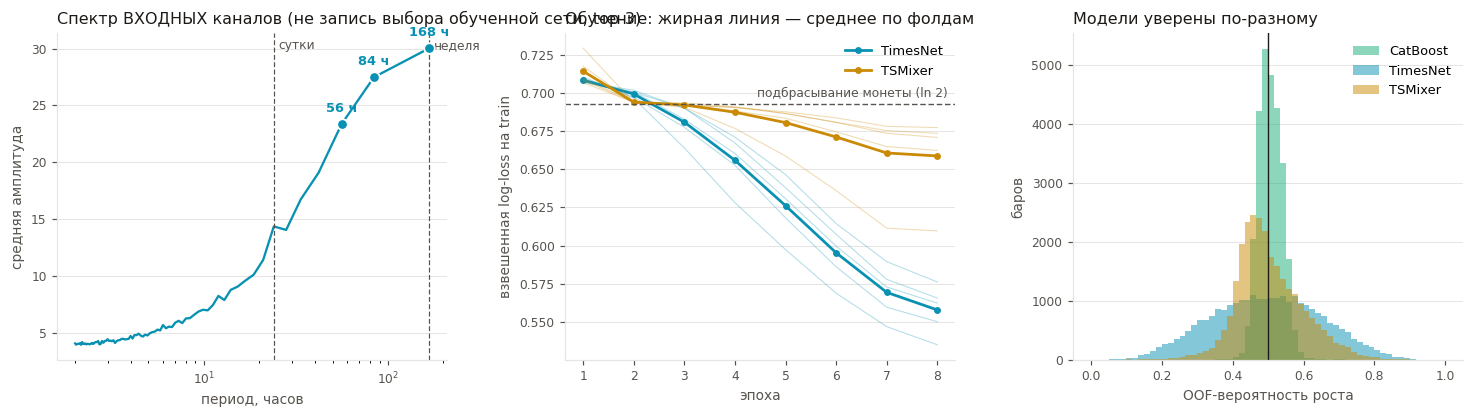

Корреляция OOF-вероятностей на dev-наборе:


,LogisticRegression,DecisionTree,CatBoost,TimesNet,TSMixer
LogisticRegression,1.000,0.509,0.702,-0.062,-0.071
DecisionTree,0.509,1.000,0.439,-0.010,-0.011
CatBoost,0.702,0.439,1.000,0.044,0.062
TimesNet,-0.062,-0.010,0.044,1.000,0.476
TSMixer,-0.071,-0.011,0.062,0.476,1.000


Чем ниже корреляция, тем больше смысла в ансамбле — но это корреляция ВЕРОЯТНОСТЕЙ, а не
ошибок: низкая корреляция вероятностей предполагает, но не доказывает низкую корреляцию
ошибок (codex_report.md, пункт 27). Рядом — корреляция самих ошибок (proba - target):


,LogisticRegression,DecisionTree,CatBoost,TimesNet,TSMixer
LogisticRegression,1.000,0.995,0.997,0.949,0.977
DecisionTree,0.995,1.000,0.996,0.951,0.978
CatBoost,0.997,0.996,1.000,0.954,0.982
TimesNet,0.949,0.951,0.954,1.000,0.965
TSMixer,0.977,0.978,0.982,0.965,1.000


In [52]:
# Что модели нашли в ряде и как они учились.
fit_idx_full = np.arange(SEQ_MIN_IDX, len(dev_df))
win_dev = sequence_windows(fit_idx_full)
sample = np.linspace(SEQ_MIN_IDX, len(dev_df) - 1, 4096).astype(int)
x_sample = window_batch(win_dev, sample)
amp = torch.fft.rfft(x_sample, dim=1).abs().mean(dim=0).mean(dim=-1).numpy()
amp[0] = 0.0
freqs = np.arange(len(amp))
periods_h = np.where(freqs > 0, SEQ_LEN / np.maximum(freqs, 1), np.nan)
top_k = seq_best["TimesNet"]["cfg"]["top_k"]
top_idx = np.argsort(amp)[::-1][:top_k]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))

ax = axes[0]
ax.plot(periods_h[1:], amp[1:], color=COLORS["TimesNet"], linewidth=1.5)
ax.scatter(periods_h[top_idx], amp[top_idx], s=48, color=COLORS["TimesNet"],
           edgecolor="white", linewidth=1.2, zorder=4)
for i in top_idx:
    ax.annotate(f"{periods_h[i]:.0f} ч", xy=(periods_h[i], amp[i]), xytext=(0, 8),
                textcoords="offset points", ha="center", fontsize=8.5,
                color=COLORS["TimesNet"], fontweight="bold")
for mark, lbl in ((24, "сутки"), (168, "неделя")):
    ax.axvline(mark, color=INK_MUTED, linewidth=0.8, linestyle=(0, (4, 2)))
    ax.annotate(lbl, xy=(mark, 1.0), xycoords=("data", "axes fraction"), xytext=(3, -4),
                textcoords="offset points", va="top", fontsize=8, color=INK_MUTED)
ax.set_xscale("log")
ax.set_xlabel("период, часов", color=INK_MUTED, fontsize=9)
ax.set_ylabel("средняя амплитуда", color=INK_MUTED, fontsize=9)
ax.set_title(f"Спектр ВХОДНЫХ каналов (не запись выбора обученной сети, top-{top_k})",
             color=INK, fontsize=10.5, loc="left")
style_ax(ax)

ax = axes[1]
for arch in SEQ_GRID:
    hist = seq_best[arch]["history"]
    mean_hist = np.mean(np.vstack(hist), axis=0)
    ax.plot(np.arange(1, len(mean_hist) + 1), mean_hist, linewidth=1.8, marker="o",
            markersize=3.5, color=COLORS[arch], label=arch)
    for h in hist:
        ax.plot(np.arange(1, len(h) + 1), h, linewidth=0.7, color=COLORS[arch], alpha=0.3)
ax.axhline(np.log(2), color=INK_MUTED, linewidth=0.9, linestyle=(0, (4, 2)))
ax.annotate("подбрасывание монеты (ln 2)", xy=(0.98, np.log(2)), xycoords=("axes fraction", "data"),
            xytext=(0, 4), textcoords="offset points", ha="right", fontsize=8, color=INK_MUTED)
ax.set_xlabel("эпоха", color=INK_MUTED, fontsize=9)
ax.set_ylabel("взвешенная log-loss на train", color=INK_MUTED, fontsize=9)
ax.set_title("Обучение: жирная линия — среднее по фолдам", color=INK, fontsize=10.5, loc="left")
ax.legend(frameon=False, fontsize=8.5)
style_ax(ax)

ax = axes[2]
bins = np.linspace(0, 1, 61)
cb_oof, cb_mask = dev_oof["CatBoost"]
ax.hist(cb_oof[cb_mask], bins=bins, color=COLORS["CatBoost"], alpha=0.5, label="CatBoost")
for arch in SEQ_GRID:
    o_, m_ = dev_oof[arch]
    ax.hist(o_[m_], bins=bins, color=COLORS[arch], alpha=0.5, label=arch)
ax.axvline(0.5, color=INK, linewidth=0.9)
ax.set_xlabel("OOF-вероятность роста", color=INK_MUTED, fontsize=9)
ax.set_ylabel("баров", color=INK_MUTED, fontsize=9)
ax.set_title("Модели уверены по-разному", color=INK, fontsize=10.5, loc="left")
ax.legend(frameon=False, fontsize=8.5)
style_ax(ax)

fig.tight_layout()
plt.show()

corr_names = list(final_models) + list(SEQ_GRID)
corr_mask = np.all([dev_oof[nm][1] for nm in corr_names], axis=0)
corr = pd.DataFrame({nm: dev_oof[nm][0][corr_mask] for nm in corr_names}).corr()
print("Корреляция OOF-вероятностей на dev-наборе:")
display(corr.round(3))
print("Чем ниже корреляция, тем больше смысла в ансамбле — но это корреляция ВЕРОЯТНОСТЕЙ, а не")
print("ошибок: низкая корреляция вероятностей предполагает, но не доказывает низкую корреляцию")
print("ошибок (codex_report.md, пункт 27). Рядом — корреляция самих ошибок (proba - target):")
_err = pd.DataFrame({nm: dev_oof[nm][0][corr_mask] - y_dev.to_numpy()[corr_mask]
                     for nm in corr_names}).corr()
display(_err.round(3))

Три панели выше говорят три разные вещи, и все три стоит проговорить.

**Выраженного суточного цикла в часовом BTC нет.** Амплитудный спектр монотонно спадает с
частотой, и top-3 периода — 168, 84 и 56 часов — это просто три самые низкие частоты окна;
24-часовой период (седьмая гармоника) в тройку не попадает. Значит, 2D-развёртка TimesNet
работает здесь не как выделение сезонности, ради которого она придумана, а как многомасштабное
сглаживание: свёртка по «столбцу» усредняет бары, отстоящие друг от друга на 56–168 часов.
Ради честности это стоит сказать прямо: главный механизм архитектуры на наших данных
простаивает.

**Обе сети запоминают обучающую выборку.** Взвешенная log-loss на train уходит с 0.70 до 0.56
у TimesNet и до 0.45 у TSMixer — заметно ниже ln 2 = 0.693, то есть сети уверенно
«предсказывают» бары, которые видели. При этом OOF ROC-AUC остаётся в диапазоне 0.522–0.531.
Попытки зажать модель сильнее не помогают. У TSMixer лучший ROC-AUC и лучшая экономика совпали
в одной конфигурации — C (6 блоков, dropout 0.35): ROC-AUC 0.5307, net Sharpe 0.73, у остальных
трёх net Sharpe отрицателен. У TimesNet они разошлись: лучший ROC-AUC у C (0.5282), но net
Sharpe 1.52 против 1.61 у выбранной A (ROC-AUC 0.5254). Ранжирование и экономика тут расходятся
так же, как в абляции раздела 12, — а выбор между близкими по экономике конфигурациями зависит
от того, как считаются пороги торгового слоя: при прежних порогах у TimesNet выигрывала C.

**Модели последовательностей и табличные модели видят разное.** TimesNet и TSMixer
скоррелированы между собой на 0.476 — они смотрят в одно и то же окно, — но с логистической
регрессией, деревом и CatBoost корреляция лежит между −0.031 и 0.058, тогда как между собой
табличные модели скоррелированы куда сильнее — 0.382–0.708. Это не оценка качества, но это
ровно то условие, при котором усреднение прогнозов имеет смысл, и на валидации расширенный
ансамбль раздела 17.4 действительно окажется лучшим по ранжированию среди стратегий с торговым
слоем (ROC-AUC 0.554).

Итог подраздела: **по ранжированию сети чуть впереди табличных моделей, по деньгам — заметно
позади.** CV ROC-AUC 0.522–0.531 против 0.506–0.522 у табличных; CV net Sharpe — 1.61 у TimesNet
и 0.73 у TSMixer против 2.23 у дерева, 2.18 у CatBoost и 1.76 у логистической регрессии. Стоимость при этом
несопоставима: минуты обучения на GPU против миллисекунд. Оговорка обязательна: сети получили
4 конфигурации, выбранные вручную, а табличные модели — 25 попыток TPE, так что сравнение
неравнобюджетное и говорит скорее «сети не дали заметного выигрыша за разумные деньги», чем
«сети хуже».

### 17.3 TimesFM 2.0: zero-shot, линейный зонд и дообучение

TimesNet и TSMixer учились на нашем ряде с нуля. Foundation-модель позволяет пройти этот путь
с другого конца: взять 500 млн параметров, предобученных на чужих временных рядах, и
посмотреть, сколько из них переносится на часовой BTC. Вопрос подраздела: **что даёт
предобученная модель прогнозирования — как есть, как источник представления и после
дообучения под нашу задачу?**

Берётся `google/timesfm-2.0-500m-pytorch` — декодер из 50 слоёв, работающий патчами по 32
точки. Для каждого бара `t` в модель подаются 512 последних значений ряда лог-доходностей
(сам бар `t` включительно, ничего из будущего). Ряд именно доходностей, а не цен: прогноз
уровня цены у любой модели почти совпадает с последним значением, и вся полезная информация
оказывается в четвёртом знаке.

Проверяются шесть постановок, от «вообще не трогаем модель» до «дообучаем верхушку»:

1. **Zero-shot.** Вероятность роста берётся прямо из прогнозного распределения:
   `P(рост) = P(r_{t+1} > 0) = 1 − F(0)`, где `F` восстанавливается линейной интерполяцией по
   девяти квантилям, которые выдаёт голова прогноза. Никакого обучения на BTC вообще.
2. **Линейный зонд (sklearn).** Бэкбон заморожен, из него берётся эмбеддинг последнего патча —
   вектор на 1280 чисел, — и поверх обучается логистическая регрессия. Стандартный способ
   проверить, есть ли нужная информация в представлении, даже если голова предобучения её не
   выдаёт.
3. **Голова на torch, бэкбон заморожен.** То же самое, но голова обучается тем же
   оптимизатором и той же взвешенной функцией потерь, что и дообучение ниже, и с щедрым
   бюджетом (8 эпох по всем окнам). Это «потолок замороженного бэкбона»: сколько можно выжать
   из представления, не трогая веса.
4. **Голова на torch в бюджете дообучения.** Та же голова и то же расписание, что у дообучения
   ниже: две эпохи, каждое второе окно, батч 64. Бэкбон заморожен и работает в режиме `eval`,
   поэтому его эмбеддинги детерминированы, и эта строка **численно эквивалентна дообучению
   при `unfreeze_last = 0`** с точностью до разницы fp16 (кэш эмбеддингов) / fp32 (обучение) —
   не буквально та же операция бит в бит, но та же голова и то же расписание над тем же
   замороженным бэкбоном. Она — контроль: от строк 5 и 6 её отличает ровно
   одно — верхние слои не двигаются. Без неё разницу между зондом и дообучением можно было бы
   списать на смену оптимизатора или на размер обучающего расписания, а не на разморозку.
5. **Дообучение: 2 верхних слоя декодера.** К голове добавляется градиентный шаг по последним
   двум из 50 слоёв — около 20 млн обучаемых параметров из 500 млн.
6. **Дообучение: 6 верхних слоёв декодера.** То же с большей ёмкостью — около 59 млн
   параметров.

Все шесть проходят по одним и тем же фолдам `TimeSeriesSplit`, с теми же весами наблюдений и
тем же критерием, что и остальные модели конвейера. Постановка, идущая дальше в сравнение
стратегий, выбирается по ROC-AUC на dev-наборе. Выбирать по `max |AUC − 0.5|` было бы
подглядыванием: так можно «выбрать» перевёрнутую модель под конкретную выборку.

In [53]:
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
from transformers import TimesFmModelForPrediction
from transformers.utils import logging as hf_logging

hf_logging.disable_progress_bar()
hf_logging.set_verbosity_error()

TIMESFM_CHECKPOINT = "google/timesfm-2.0-500m-pytorch"
TIMESFM_CTX = 512            # кратно патчу 32; модель держит и 2048, но это вчетверо дороже
TIMESFM_BATCH = 128
TIMESFM_HIDDEN = 1280

# Выравнивание feat -> raw делается по датам, а не арифметикой по длинам: ошибка на один бар
# здесь означала бы, что в контекст попадает будущее (и ROC-AUC внезапно становится 0.9).
tfm_offset = int(raw.index[raw["date"] == feat["date"].iloc[0]][0])
assert (raw["date"].to_numpy()[tfm_offset:tfm_offset + len(feat)]
        == feat["date"].to_numpy()).all(), "feat и raw разъехались по времени"
assert np.allclose(raw["close"].to_numpy()[tfm_offset:tfm_offset + len(feat)],
                   feat["close"].to_numpy())

logret_raw = np.concatenate(
    [[0.0], np.diff(np.log(raw["close"].to_numpy(np.float64)))]).astype(np.float32)
context_rows = np.arange(len(feat)) + tfm_offset - (TIMESFM_CTX - 1)
assert context_rows[0] >= 0, "не хватает истории на контекст"
# последняя точка контекста — это бар t и ничто иное
assert np.allclose(logret_raw[context_rows + TIMESFM_CTX - 1],
                   logret_raw[np.arange(len(feat)) + tfm_offset])


@torch.no_grad()
def timesfm_scan(model, series, batch_size=TIMESFM_BATCH):
    """Один проход по всем барам feat: квантили прогноза на бар вперёд и эмбеддинг бара.

    Контекст короче 2048 модель дописывает нулями СЛЕВА, поэтому последняя позиция
    `last_hidden_state` соответствует самому свежему патчу, то есть бару t.
    """
    windows = np.lib.stride_tricks.sliding_window_view(series, TIMESFM_CTX)
    n_lvl = len(model.config.quantiles)
    quant = np.empty((len(feat), n_lvl), np.float32)
    point = np.empty(len(feat), np.float32)
    emb = np.empty((len(feat), TIMESFM_HIDDEN), np.float16)
    t0 = time.perf_counter()
    for s in range(0, len(feat), batch_size):
        block = context_rows[s:s + batch_size]
        ctx = torch.from_numpy(windows[block].copy()).to(DEVICE)
        out = model(past_values=ctx, output_hidden_states=True)
        full = out.full_predictions[:, 0, :].float().cpu().numpy()   # [B, 1 + квантили]
        point[s:s + len(block)] = full[:, 0]
        quant[s:s + len(block)] = full[:, 1:]
        emb[s:s + len(block)] = out.last_hidden_state[:, -1, :].float().cpu().numpy()
        if (s // batch_size) % 100 == 0:
            print(f"    {min(s + batch_size, len(feat))}/{len(feat)} окон, "
                  f"{time.perf_counter() - t0:.0f} с", flush=True)
    return np.sort(quant, axis=1), point, emb          # квантили обязаны быть неубывающими


def prob_above(quantiles, levels, threshold=0.0):
    """P(значение > threshold) по квантилям, с линейным продолжением хвостов."""
    lo = quantiles[:, 0] - 2 * (quantiles[:, 1] - quantiles[:, 0])
    hi = quantiles[:, -1] + 2 * (quantiles[:, -1] - quantiles[:, -2])
    grid = np.column_stack([lo, quantiles, hi])
    lvl = np.concatenate([[0.02], levels, [0.98]])
    cdf = np.array([np.interp(threshold, grid[i], lvl) for i in range(len(quantiles))])
    return 1.0 - cdf


t_start = time.perf_counter()
# float32, а не bfloat16: часовые лог-доходности BTC — это величины порядка 1e-3, в bf16
# соседние квантили схлопываются в одно значение и вероятность становится бесполезной.
timesfm_backbone = TimesFmModelForPrediction.from_pretrained(
    TIMESFM_CHECKPOINT, dtype=torch.float32).to(DEVICE).eval()
TIMESFM_LEVELS = np.array(timesfm_backbone.config.quantiles, dtype=float)
print(f"{TIMESFM_CHECKPOINT}: revision "
      f"{getattr(timesfm_backbone.config, '_commit_hash', 'неизвестна')}, "
      f"torch {torch.__version__}, CUDA {torch.version.cuda}")
print(f"Загружено: {TIMESFM_CHECKPOINT}, "
      f"{sum(p.numel() for p in timesfm_backbone.parameters()) / 1e6:.0f} млн параметров, "
      f"{time.perf_counter() - t_start:.0f} с. Обучения на BTC нет — модель как есть.")

t_start = time.perf_counter()
tfm_quant, tfm_point, tfm_emb = timesfm_scan(timesfm_backbone, logret_raw)
print(f"Проход по {len(feat)} окнам за {(time.perf_counter() - t_start) / 60:.1f} мин: "
      f"квантили {tfm_quant.shape}, эмбеддинги {tfm_emb.shape} "
      f"({tfm_emb.nbytes / 2 ** 20:.0f} МиБ)")

p_tfm_zeroshot = prob_above(tfm_quant, TIMESFM_LEVELS, 0.0)
print(f"Точечный прогноз положителен на {float((tfm_point > 0).mean()):.1%} баров при "
      f"фактической доле роста {feat['target'].mean():.1%} — у прогноза есть систематический "
      f"сдвиг в сторону падения, и он один объясняет смещение P(рост) влево.")
# модель не удаляется: тот же бэкбон дообучается ниже

google/timesfm-2.0-500m-pytorch: revision dc2443792ce5516872b89b37cf1bc058c3bf0c10, torch 2.7.1+cu126, CUDA 12.6
Загружено: google/timesfm-2.0-500m-pytorch, 499 млн параметров, 4 с. Обучения на BTC нет — модель как есть.


    128/38262 окон, 2 с


    12928/38262 окон, 171 с


    25728/38262 окон, 335 с


Проход по 38262 окнам за 8.3 мин: квантили (38262, 9), эмбеддинги (38262, 1280) (93 МиБ)
Точечный прогноз положителен на 14.0% баров при фактической доле роста 50.5% — у прогноза есть систематический сдвиг в сторону падения, и он один объясняет смещение P(рост) влево.


**Как устроено дообучение и почему именно так.**

- **Размораживается верхушка, а не вся модель.** Полный градиентный шаг по 500 млн параметров
  на 40 тысячах наблюдений с меткой, близкой к подбрасыванию монеты, — это гарантированное
  переобучение и лишние часы счёта. Нижние слои держат общее представление ряда, верхние
  специализируются под задачу; размораживаются последние `k` слоёв декодера и голова.
- **Два темпа обучения.** Предобученным слоям `lr = 1e-5`, свежей голове `lr = 1e-3`: одинаковый
  темп либо разрушил бы предобученные веса, либо не сдвинул бы голову с места.
- **Замороженная часть остаётся в режиме `eval`.** Иначе dropout нижних слоёв зашумлял бы
  эмбеддинг, который они обязаны выдавать одинаково на обучении и на предсказании.
- **Каждый фолд начинается с чистых предобученных весов.** Разморозка меняет слои на месте,
  поэтому перед каждым фолдом верхние `k` слоёв восстанавливаются из снимка. Без этого второй
  фолд стартовал бы с весов, уже видевших его собственное прошлое, а пятый — почти весь
  dev-набор.
- **Обучение идёт по каждому второму окну.** Соседние окна совпадают в 511 точках из 512, так
  что информации это почти не теряет, а счёт сокращает вдвое. Предсказание считается по всем
  барам фолда без прореживания.

In [54]:
# Дообучение TimesFM: частичная разморозка декодера.
n_dev, n_val = len(dev_df), len(val_df)
y_dev_np, y_val_np = dev_df["target"].to_numpy(), val_df["target"].to_numpy()
val_rows_in_feat = np.arange(n_val) + (len(feat) - n_val)
assert feat["date"].to_numpy()[val_rows_in_feat][0] == val_df["date"].iloc[0], "валидация смещена"

TFM_UNFREEZE_GRID = (2, 6)   # сколько последних слоёв декодера из 50 размораживать
TFM_FT_EPOCHS = 2
TFM_FT_STRIDE = 2            # обучение по каждому второму окну: соседние совпадают на 511/512
TFM_FT_BATCH = 64
TFM_HEAD_EPOCHS = 8          # голова на кэшированных эмбеддингах дешёвая, ей эпох не жалко
TFM_LR_BACKBONE = 1e-5       # предобученным слоям — осторожный темп
TFM_LR_HEAD = 1e-3           # свежей голове — обычный
TFM_PROBE_C = 0.01           # сильная регуляризация: 1280 признаков против 40 тысяч наблюдений

TFM_WINDOWS = np.lib.stride_tricks.sliding_window_view(logret_raw, TIMESFM_CTX)
SEQ_W_ALL = np.where(SEQ_ANOM > 0, OUTLIER_WEIGHT, 1.0).astype(np.float32)


def tfm_context_batch(rows):
    """Контексты [B, 512] лог-доходностей, заканчивающиеся на барах rows."""
    return torch.from_numpy(TFM_WINDOWS[context_rows[np.asarray(rows)]].copy()).to(DEVICE)


def make_tfm_head(dropout=0.1):
    """Голова классификации над эмбеддингом бара — одна и та же во всех torch-постановках."""
    return nn.Sequential(nn.LayerNorm(TIMESFM_HIDDEN), nn.Dropout(dropout),
                         nn.Linear(TIMESFM_HIDDEN, 1))


def make_probe(C=TFM_PROBE_C):
    return Pipeline([("scaler", StandardScaler()),
                     ("clf", LogisticRegression(C=C, max_iter=1000, tol=1e-3,
                                                random_state=RANDOM_STATE))])


class TimesFmClassifier(nn.Module):
    """TimesFM с головой классификации и разморозкой последних unfreeze_last слоёв декодера."""

    def __init__(self, backbone, unfreeze_last, dropout=0.1):
        super().__init__()
        self.backbone = backbone
        for p in self.backbone.parameters():
            p.requires_grad = False
        layers = self.backbone.decoder.layers
        self.tuned = list(layers[len(layers) - unfreeze_last:]) if unfreeze_last else []
        for layer in self.tuned:
            for p in layer.parameters():
                p.requires_grad = True
        self.head = make_tfm_head(dropout)

    def train_mode(self):
        """Замороженная часть остаётся в eval: её dropout не должен зашумлять эмбеддинг."""
        self.backbone.eval()
        for layer in self.tuned:
            layer.train()
        self.head.train()

    def forward(self, ctx):
        emb = self.backbone(past_values=ctx).last_hidden_state[:, -1, :]
        return self.head(emb).squeeze(-1)


def weighted_bce(logit, rows):
    """Взвешенная логистическая потеря: те же веса выбросов, что у всех моделей конвейера."""
    y = torch.from_numpy(SEQ_TARGET[rows]).to(DEVICE)
    w = torch.from_numpy(SEQ_W_ALL[rows]).to(DEVICE)
    return (F.binary_cross_entropy_with_logits(logit, y, reduction="none") * w).sum() / w.sum()


def timesfm_ft_fit(rows, unfreeze_last, epochs=TFM_FT_EPOCHS, seed=RANDOM_STATE):
    """Дообучение верхушки на барах rows. Веса декодера восстанавливаются перед стартом."""
    torch.manual_seed(seed)
    timesfm_backbone.decoder.layers[-max(TFM_UNFREEZE_GRID):].load_state_dict(tfm_snapshot)
    model = TimesFmClassifier(timesfm_backbone, unfreeze_last).to(DEVICE)
    groups = [{"params": list(model.head.parameters()), "lr": TFM_LR_HEAD}]
    if model.tuned:
        groups.insert(0, {"params": [p for l in model.tuned for p in l.parameters()],
                          "lr": TFM_LR_BACKBONE})
    opt = torch.optim.AdamW(groups, weight_decay=1e-2)
    rows = np.asarray(rows)
    steps = epochs * int(np.ceil(len(rows) / TFM_FT_BATCH))
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=[g["lr"] for g in groups],
                                                total_steps=steps, pct_start=0.25)
    trainable = [p for p in model.parameters() if p.requires_grad]
    gen = torch.Generator().manual_seed(seed)
    history = []
    for _ in range(epochs):
        model.train_mode()
        order = torch.randperm(len(rows), generator=gen).numpy()
        running = 0.0
        for s in range(0, len(rows), TFM_FT_BATCH):
            b = rows[order[s:s + TFM_FT_BATCH]]
            loss = weighted_bce(model(tfm_context_batch(b)), b)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(trainable, 1.0)
            opt.step()
            sched.step()
            running += float(loss) * len(b)
        history.append(running / len(rows))
    return model, history


@torch.no_grad()
def timesfm_ft_predict(model, rows, batch=TIMESFM_BATCH):
    model.eval()
    rows = np.asarray(rows)
    out = [torch.sigmoid(model(tfm_context_batch(rows[s:s + batch]))).float().cpu().numpy()
           for s in range(0, len(rows), batch)]
    return np.concatenate(out)


def timesfm_head_fit(rows, epochs=TFM_HEAD_EPOCHS, batch=SEQ_BATCH, seed=RANDOM_STATE):
    """Контроль: та же голова и тот же оптимизатор, но на кэшированных эмбеддингах."""
    torch.manual_seed(seed)
    head = make_tfm_head().to(DEVICE)
    opt = torch.optim.AdamW(head.parameters(), lr=TFM_LR_HEAD, weight_decay=1e-2)
    rows = np.asarray(rows)
    steps = epochs * int(np.ceil(len(rows) / batch))
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=TFM_LR_HEAD, total_steps=steps,
                                                pct_start=0.25)
    gen = torch.Generator().manual_seed(seed)
    for _ in range(epochs):
        head.train()
        order = torch.randperm(len(rows), generator=gen).numpy()
        for s in range(0, len(rows), batch):
            b = rows[order[s:s + batch]]
            xb = torch.from_numpy(tfm_emb[b].astype(np.float32)).to(DEVICE)
            loss = weighted_bce(head(xb).squeeze(-1), b)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(head.parameters(), 1.0)
            opt.step()
            sched.step()
    return head


@torch.no_grad()
def timesfm_head_predict(head, rows, batch=2048):
    head.eval()
    rows = np.asarray(rows)
    out = []
    for s in range(0, len(rows), batch):
        xb = torch.from_numpy(tfm_emb[rows[s:s + batch]].astype(np.float32)).to(DEVICE)
        out.append(torch.sigmoid(head(xb).squeeze(-1)).float().cpu().numpy())
    return np.concatenate(out)


def probe_cv_oof():
    """OOF линейного зонда на тех же фолдах и с теми же весами, что у остальных моделей."""
    oof = np.full(n_dev, np.nan)
    for tr_idx, te_idx in tscv.split(X_dev_all):
        probe = make_probe()
        probe.fit(tfm_emb[tr_idx].astype(np.float32), y_dev_np[tr_idx],
                  clf__sample_weight=sample_weights(dev_df, tr_idx, w_outlier=True))
        oof[te_idx] = predict_proba1(probe, tfm_emb[te_idx].astype(np.float32))
    return oof, ~np.isnan(oof)


def head_cv_oof(epochs=TFM_HEAD_EPOCHS, stride=1, batch=SEQ_BATCH):
    """OOF головы на замороженных эмбеддингах. stride/epochs/batch задают бюджет обучения:
    при бюджете дообучения эта постановка равна дообучению с unfreeze_last = 0."""
    oof = np.full(n_dev, np.nan)
    for tr_idx, te_idx in tscv.split(X_dev_all):
        head = timesfm_head_fit(tr_idx[::stride], epochs, batch)
        oof[te_idx] = timesfm_head_predict(head, te_idx)
    return oof, ~np.isnan(oof)


def ft_cv_oof(unfreeze_last):
    """OOF дообученной модели. Каждый фолд обучается с нуля от предобученных весов."""
    oof = np.full(n_dev, np.nan)
    hist = []
    for tr_idx, te_idx in tscv.split(X_dev_all):
        model, h = timesfm_ft_fit(tr_idx[::TFM_FT_STRIDE], unfreeze_last)
        oof[te_idx] = timesfm_ft_predict(model, te_idx)
        hist.append(h)
        del model
        torch.cuda.empty_cache() if DEVICE.type == "cuda" else None
    return oof, ~np.isnan(oof), hist


def ft_label(k):
    return f"дообучение: {k} верхних сло{'я' if k < 5 else 'ёв'} декодера"

In [55]:
# Прогон всех постановок TimesFM по одним и тем же фолдам.
# снимок предобученных весов верхних слоёв: к нему возвращаемся перед каждым фолдом
tfm_snapshot = {k: v.detach().clone() for k, v in
                timesfm_backbone.decoder.layers[-max(TFM_UNFREEZE_GRID):].state_dict().items()}
n_tuned = {k: sum(p.numel() for layer in timesfm_backbone.decoder.layers[-k:]
                  for p in layer.parameters()) for k in TFM_UNFREEZE_GRID}
print(f"Декодер: {len(timesfm_backbone.decoder.layers)} слоёв, "
      f"{sum(p.numel() for p in timesfm_backbone.parameters()) / 1e6:.0f} млн параметров")
for k, v in n_tuned.items():
    print(f"  разморозка {k} верхних слоёв -> {v / 1e6:.0f} млн обучаемых параметров "
          f"({v / sum(p.numel() for p in timesfm_backbone.parameters()):.1%} модели)")

tfm_oof = {}
t0 = time.perf_counter()
tfm_oof["линейный зонд по эмбеддингам"] = probe_cv_oof()
print(f"\nЛинейный зонд (sklearn): {time.perf_counter() - t0:.0f} с")

t0 = time.perf_counter()
tfm_oof["голова на torch, бэкбон заморожен"] = head_cv_oof()
print(f"Голова на torch, щедрый бюджет ({TFM_HEAD_EPOCHS} эпох, все окна): "
      f"{time.perf_counter() - t0:.0f} с")

t0 = time.perf_counter()
tfm_oof["голова на torch, бюджет дообучения"] = head_cv_oof(
    epochs=TFM_FT_EPOCHS, stride=TFM_FT_STRIDE, batch=TFM_FT_BATCH)
print(f"Голова на torch, бюджет дообучения ({TFM_FT_EPOCHS} эпохи, каждое второе окно): "
      f"{time.perf_counter() - t0:.0f} с — это дообучение при unfreeze_last = 0")

ft_history = {}
for k in TFM_UNFREEZE_GRID:
    t0 = time.perf_counter()
    oof_k, mask_k, hist_k = ft_cv_oof(k)
    tfm_oof[ft_label(k)] = (oof_k, mask_k)
    ft_history[k] = hist_k
    print(f"{ft_label(k)}: {(time.perf_counter() - t0) / 60:.1f} мин, "
          f"log-loss на train {np.mean([h[0] for h in hist_k]):.4f} -> "
          f"{np.mean([h[-1] for h in hist_k]):.4f}", flush=True)

# финальное обучение выбранной постановки на всём dev — вызывается в разделе 17.4
def _final_probe():
    probe = make_probe()
    probe.fit(tfm_emb[:n_dev].astype(np.float32), y_dev_np,
              clf__sample_weight=sample_weights(dev_df, np.arange(n_dev), w_outlier=True))
    return (predict_proba1(probe, tfm_emb[:n_dev].astype(np.float32)),
            predict_proba1(probe, tfm_emb[val_rows_in_feat].astype(np.float32)))


def _final_head(epochs=TFM_HEAD_EPOCHS, stride=1, batch=SEQ_BATCH):
    head = timesfm_head_fit(np.arange(0, n_dev, stride), epochs, batch)
    return (timesfm_head_predict(head, np.arange(n_dev)),
            timesfm_head_predict(head, val_rows_in_feat))


def _final_ft(k):
    model, _ = timesfm_ft_fit(np.arange(0, n_dev, TFM_FT_STRIDE), k)
    dev_p = timesfm_ft_predict(model, np.arange(n_dev))
    val_p = timesfm_ft_predict(model, val_rows_in_feat)
    del model
    torch.cuda.empty_cache() if DEVICE.type == "cuda" else None
    return dev_p, val_p


tfm_final_fit = {
    "zero-shot: P(r > 0) по квантилям":
        lambda: (p_tfm_zeroshot[:n_dev], p_tfm_zeroshot[val_rows_in_feat]),
    "линейный зонд по эмбеддингам": _final_probe,
    "голова на torch, бэкбон заморожен": _final_head,
    "голова на torch, бюджет дообучения":
        lambda: _final_head(TFM_FT_EPOCHS, TFM_FT_STRIDE, TFM_FT_BATCH),
    **{ft_label(k): (lambda k=k: _final_ft(k)) for k in TFM_UNFREEZE_GRID},
}

Декодер: 50 слоёв, 499 млн параметров
  разморозка 2 верхних слоёв -> 20 млн обучаемых параметров (3.9% модели)
  разморозка 6 верхних слоёв -> 59 млн обучаемых параметров (11.8% модели)



Линейный зонд (sklearn): 11 с


Голова на torch, щедрый бюджет (8 эпох, все окна): 19 с


Голова на torch, бюджет дообучения (2 эпохи, каждое второе окно): 9 с — это дообучение при unfreeze_last = 0


дообучение: 2 верхних слоя декодера: 20.0 мин, log-loss на train 0.7034 -> 0.6909


дообучение: 6 верхних слоёв декодера: 19.5 мин, log-loss на train 0.7031 -> 0.6906


,ROC-AUC dev,AP dev,accuracy dev,gross Sharpe,net Sharpe,разброс P(рост),средняя P(рост),слой допустим
постановка,,,,,,,,
zero-shot: P(r > 0) по квантилям,0.4627,0.4771,0.4789,-0.0948,1.8583,0.1228,0.3841,True
линейный зонд по эмбеддингам,0.5215,0.5190,0.5162,0.1234,1.1823,0.1961,0.5251,True
"голова на torch, бэкбон заморожен",0.5357,0.5329,0.5268,0.5361,1.2260,0.0567,0.5066,True
"голова на torch, бюджет дообучения",0.5154,0.5143,0.5131,0.9269,1.3762,0.0488,0.5110,True
дообучение: 2 верхних слоя декодера,0.5137,0.5118,0.5126,0.8392,2.2770,0.0393,0.5101,True
дообучение: 6 верхних слоёв декодера,0.5111,0.5092,0.5114,0.6541,1.4186,0.0326,0.5129,True


Для честного сравнения («лестница» строится по одному и тому же срезу баров): zero-shot ROC-AUC на пересечении масок обучаемых постановок = 0.4605 (на полном dev в таблице выше — 0.4627, справочная цифра на другом наборе баров, не для прямого сравнения).


Взята постановка «голова на torch, бэкбон заморожен» (по ROC-AUC на dev).
Торговый слой TimesFM: {'mode': 'hold', 'span': 24, 'rebalance': 6, 'q': 0.02, 'sl': 0.0, 'tp': 0.06, 'cooldown': -1}, допустимая конфигурация найдена: True


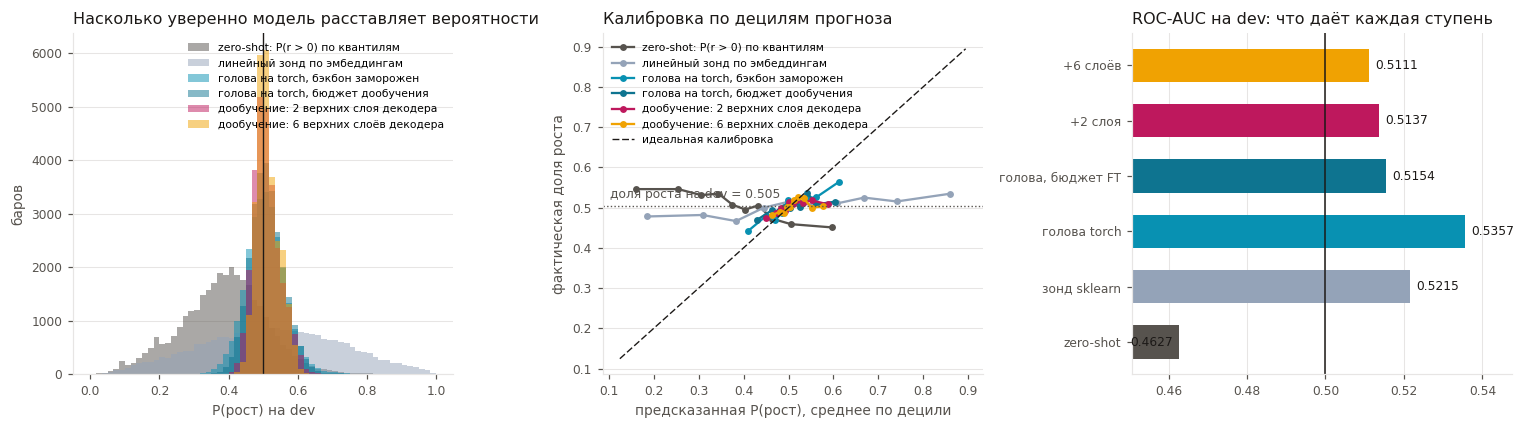

Для zero-shot постановки порог 0.5 бессмыслен — модель не обучалась на нашей метке;
поэтому смотрим на ROC-AUC и на квантильные пороги торгового слоя.


In [56]:
# Сравнение постановок TimesFM и выбор той, что идёт в сравнение стратегий.
tfm_variants = {"zero-shot: P(r > 0) по квантилям": (p_tfm_zeroshot[:n_dev], np.ones(n_dev, bool)),
                **tfm_oof}

# Обучаемые постановки используют один и тот же tscv, поэтому их маски совпадают; у zero-shot
# маска — весь dev, включая первые ~5400 баров, где обучаемые постановки ещё не имеют OOF (они
# в train первого фолда). Сравнение "как есть" ниже частично сравнивает не только модель, но и
# период (codex_report.md, пункт 20). common_mask — честное пересечение: та же оценка zero-shot,
# но на тех же барах, что и у обучаемых постановок.
common_mask = np.all([m for _, (p, m) in tfm_oof.items()], axis=0)
zs_common_auc = roc_auc_score(y_dev_np[common_mask], p_tfm_zeroshot[:n_dev][common_mask])

tfm_rows = []
for label, (p_var, m_var) in tfm_variants.items():
    rep, trade, sig_prm, ok = seq_evaluate(p_var, m_var)
    tfm_rows.append({"постановка": label, "ROC-AUC dev": rep["roc_auc"],
                     "AP dev": rep["average_precision"], "accuracy dev": rep["accuracy"],
                     "gross Sharpe": rep["gross_sharpe"], "net Sharpe": trade["sharpe"],
                     "разброс P(рост)": float(p_var[m_var].std()),
                     "средняя P(рост)": float(p_var[m_var].mean()),
                     "слой допустим": ok})
tfm_table = pd.DataFrame(tfm_rows).set_index("постановка")
display(tfm_table.round(4))
_zs_label = "zero-shot: P(r > 0) по квантилям"
print(f"Для честного сравнения («лестница» строится по одному и тому же срезу баров): "
      f"zero-shot ROC-AUC на пересечении масок обучаемых постановок = {zs_common_auc:.4f} "
      f"(на полном dev в таблице выше — {tfm_table.loc[_zs_label, 'ROC-AUC dev']:.4f}, "
      f"справочная цифра на другом наборе баров, не для прямого сравнения).")

tfm_best_label = tfm_table["ROC-AUC dev"].idxmax()
p_tfm_dev, tfm_mask = tfm_variants[tfm_best_label]
dev_oof["TimesFM"] = (p_tfm_dev, tfm_mask)
signal_by_model["TimesFM"], _, tfm_layer_ok = tune_signal_layer(
    p_tfm_dev[tfm_mask], dates_dev.to_numpy()[tfm_mask], fwd_dev.to_numpy()[tfm_mask],
    DEV_FOLDS[tfm_mask])
print(f"Взята постановка «{tfm_best_label}» (по ROC-AUC на dev).")
print(f"Торговый слой TimesFM: {signal_by_model['TimesFM']}, "
      f"допустимая конфигурация найдена: {tfm_layer_ok}")

TFM_SHORT = dict(zip(tfm_variants,
                     ["zero-shot", "зонд sklearn", "голова torch", "голова, бюджет FT"]
                     + [f"+{k} сло{'я' if k < 5 else 'ёв'}" for k in TFM_UNFREEZE_GRID]))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.0))
palette = {lbl: c for lbl, c in zip(tfm_variants, [INK_MUTED, "#94a3b8", "#0891b2",
                                                   "#0e7490", COLORS["TimesFM"], "#f0a202"])}

ax = axes[0]
bins = np.linspace(0, 1, 61)
for label, (p_var, m_var) in tfm_variants.items():
    ax.hist(p_var[m_var], bins=bins, alpha=0.5, label=label, color=palette[label], linewidth=0)
ax.axvline(0.5, color=INK, linewidth=0.9)
ax.set_xlabel("P(рост) на dev", color=INK_MUTED, fontsize=9)
ax.set_ylabel("баров", color=INK_MUTED, fontsize=9)
ax.set_title("Насколько уверенно модель расставляет вероятности",
             color=INK, fontsize=10.5, loc="left")
ax.legend(frameon=False, fontsize=7)
style_ax(ax)

ax = axes[1]
for label, (p_var, m_var) in tfm_variants.items():
    pv, yv = p_var[m_var], y_dev_np[m_var]
    edges = np.unique(np.quantile(pv, np.linspace(0, 1, 11)))
    idx_bin = np.clip(np.digitize(pv, edges[1:-1]), 0, len(edges) - 2)
    xs = [pv[idx_bin == b].mean() for b in range(len(edges) - 1)]
    ys = [yv[idx_bin == b].mean() for b in range(len(edges) - 1)]
    ax.plot(xs, ys, marker="o", markersize=3.5, linewidth=1.5, label=label, color=palette[label])
lims = ax.get_xlim()
ax.plot(lims, lims, color=INK, linewidth=0.9, linestyle=(0, (5, 2)), label="идеальная калибровка")
ax.axhline(y_dev_np.mean(), color=INK_MUTED, linewidth=0.9, linestyle=":")
ax.annotate(f"доля роста на dev = {y_dev_np.mean():.3f}", xy=(0.02, y_dev_np.mean()),
            xycoords=("axes fraction", "data"), xytext=(0, 5), textcoords="offset points",
            fontsize=8, color=INK_MUTED)
ax.set_xlabel("предсказанная P(рост), среднее по децили", color=INK_MUTED, fontsize=9)
ax.set_ylabel("фактическая доля роста", color=INK_MUTED, fontsize=9)
ax.set_title("Калибровка по децилям прогноза", color=INK, fontsize=10.5, loc="left")
ax.legend(frameon=False, fontsize=7)
style_ax(ax)

ax = axes[2]
order = [lbl for lbl in tfm_variants]
vals = [tfm_table.loc[lbl, "ROC-AUC dev"] for lbl in order]
ax.barh(np.arange(len(order)), vals, color=[palette[l] for l in order], height=0.6)
ax.axvline(0.5, color=INK, linewidth=1.0)
ax.annotate("0.5 — монетка", xy=(0.5, -0.75), xytext=(3, 0), textcoords="offset points",
            fontsize=8, color=INK_MUTED)
for yi, v in enumerate(vals):
    ax.annotate(f"{v:.4f}", xy=(v, yi), xytext=(4 if v >= 0.5 else -4, 0),
                textcoords="offset points", va="center",
                ha="left" if v >= 0.5 else "right", fontsize=8, color=INK)
ax.set_yticks(np.arange(len(order)))
ax.set_yticklabels([TFM_SHORT[l] for l in order], fontsize=8)
ax.set_xlim(min(vals) - 0.012, max(vals) + 0.012)
ax.set_title("ROC-AUC на dev: что даёт каждая ступень", color=INK, fontsize=10.5, loc="left")
style_ax(ax, ygrid=False, xgrid=True)

fig.tight_layout()
plt.show()
print("Для zero-shot постановки порог 0.5 бессмыслен — модель не обучалась на нашей метке;")
print("поэтому смотрим на ROC-AUC и на квантильные пороги торгового слоя.")

Шесть постановок выстраиваются в лестницу, и каждая ступень отвечает на свой вопрос.

**Zero-shot: отрицательный результат, и однозначный.** ROC-AUC 0.463 на полном dev (0.461 на
пересечении масок с обучаемыми постановками — см. таблицу выше) — ниже 0.5, калибровочная
кривая на средней панели идёт вниз. Это не «перевёрнутый сигнал, который можно использовать
наоборот»: на dev-наборе такой разворот означал бы подгонку под выборку. Плюс систематический
сдвиг — распределение P(рост) смещено влево (среднее 0.384, разброс 0.123). Готовая голова
прогноза направления следующего часа не даёт.

**Представление полезнее прогноза.** Линейный зонд по замороженным эмбеддингам поднимает
ROC-AUC до 0.522, а та же голова, обученная torch-оптимизатором со взвешенной функцией потерь
и щедрым бюджетом, — до **0.536**. Обе цифры получены на одних и тех же замороженных
эмбеддингах: разница целиком в рецепте обучения головы, а не в качестве представления.

**Разморозка верхних слоёв в этом прогоне слегка вредит — и увидеть размер эффекта можно
только с согласованным контролем.** При одинаковом расписании (2 эпохи, каждое второе окно,
батч 64) замороженный бэкбон даёт ROC-AUC 0.515, разморозка двух верхних слоёв — 0.514, шести —
0.511. Разброс между ними — 0.004, монотонно в одну сторону (больше разморозки → ниже
ROC-AUC), а не «шум без направления», как получилось в одном из более ранних прогонов на
другом срезе данных: направление эффекта воспроизводится, а точная величина — нет, и это само
по себе иллюстрация того, насколько такие сравнения чувствительны к сиду/срезу.

Сравнение же с щедрым контролем (0.536 против 0.515) выглядело бы как «дообучение вредит» —
и было бы **неверным прочтением**: 0.536 против 0.515 получены на одном и том же замороженном
бэкбоне и отличаются только длиной обучения головы. Иначе говоря, **бюджет обучения головы
стоит +0.021 ROC-AUC, а разморозка 59 млн параметров — минус 0.004**. Ради этой строки контроль
и добавлен; без неё раздел приписал бы весь эффект разморозке, хотя бо́льшая его часть — от
бюджета обучения головы.

**С экономикой на этот раз согласованнее, чем с ROC-AUC.** gross Sharpe: 0.536 у щедрого
контроля, 0.927 у согласованного по бюджету (0 слоёв), 0.839 при разморозке двух слоёв, 0.654
при шести. И ROC-AUC, и gross Sharpe в этом прогоне монотонно падают с ростом числа
размороженных слоёв — более простая картина, чем «метрики расходятся», которая получалась на
другом срезе. Метрики по-прежнему измеряют разное: ROC-AUC усредняет ранжирование по всем барам
одинаково, а gross Sharpe в `oof_report` считается по правилу «в лонг, если P ≥ 0.5, иначе в
шорт» и зависит только от знака решения.

Левая панель добавляет наблюдение о форме прогнозов: разброс P(рост) сужается и от укорочения
бюджета (0.057 → 0.049), и от разморозки (0.049 → 0.039 → 0.033). Модель становится осторожнее
и прижимает вероятности к базовой частоте — на торговый слой это влияет напрямую, потому что
его пороги квантильные.

По правилу отбора (dev ROC-AUC) дальше идёт **голова на torch поверх замороженного бэкбона с
щедрым бюджетом** — постановка с наибольшим ROC-AUC (0.536) в этом прогоне.

**Границы утверждения.** Проверено одно сочетание: 2 и 6 верхних слоёв из 50, две эпохи,
каждое второе окно, `lr = 1e-5` для декодера и `1e-3` для головы, без перебора расписания и
без ранней остановки. Полного градиентного шага по всем 500 млн параметров не делалось вовсе.
Отсюда следует «в этом бюджете разморозка верхушки не окупается, а удлинение обучения головы
окупается», но не следует «дообучать TimesFM бесполезно».

### 17.4 Финальные модели последовательностей и расширенный ансамбль

TimesNet и TSMixer с выбранными конфигурациями переобучаются на всём dev-наборе — как и
табличные модели раздела 16. Статистики стандартизации окон считаются по dev, пороги торгового
слоя берутся из dev-распределения прогнозов финальной модели. TimesFM переобучается в той постановке,
которая выиграла по dev ROC-AUC: zero-shot не требует ничего, зонд и голова обучаются на
dev-эмбеддингах, а дообучение заново проходит по dev от чистых предобученных весов.

Дополнительно строится **расширенный ансамбль** — среднее вероятностей всех шести моделей
(три табличные + три из этого раздела). Смысл в том, что показала матрица корреляций выше:
табличные модели и модели последовательностей ошибаются в разных местах.

In [57]:
# Финальные модели последовательностей: обучение на всём dev и прогноз на валидации.
seq_train_idx = np.arange(SEQ_MIN_IDX, n_dev)
win_final = sequence_windows(seq_train_idx)            # статистики — только по dev

for arch in SEQ_GRID:
    t_start = time.perf_counter()
    best = seq_best[arch]
    model, _ = seq_fit(SEQ_BUILDERS[arch](best["cfg"]), win_final, seq_train_idx,
                       best["epochs"], best["lr"])
    dev_proba_final[arch] = np.full(n_dev, np.nan)
    dev_proba_final[arch][seq_train_idx] = seq_predict(model, win_final, seq_train_idx)
    val_proba[arch] = seq_predict(model, win_final, val_rows_in_feat)
    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    print(f"{arch}: обучен на {len(seq_train_idx)} окнах за "
          f"{(time.perf_counter() - t_start) / 60:.1f} мин; средняя вероятность роста "
          f"на валидации {val_proba[arch].mean():.3f}")

t_start = time.perf_counter()
dev_proba_final["TimesFM"], val_proba["TimesFM"] = tfm_final_fit[tfm_best_label]()
print(f"TimesFM: постановка «{tfm_best_label}», обучение на всём dev за "
      f"{time.perf_counter() - t_start:.0f} с")
print(f"  средняя вероятность роста на валидации {val_proba['TimesFM'].mean():.3f}")

# Расширенный ансамбль: три табличные модели + три модели последовательностей.
SEQ_NAMES = ["TimesNet", "TSMixer", "TimesFM"]
ENSEMBLE_ALL = list(final_models) + SEQ_NAMES
mask_all = np.all([dev_oof[nm][1] for nm in ENSEMBLE_ALL], axis=0)
oof_all = np.nanmean(np.vstack([dev_oof[nm][0] for nm in ENSEMBLE_ALL]), axis=0)
signal_by_model["EnsembleAll"], _, _ = tune_signal_layer(
    oof_all[mask_all], dates_dev.to_numpy()[mask_all], fwd_dev.to_numpy()[mask_all],
    DEV_FOLDS[mask_all])
dev_oof["EnsembleAll"] = (oof_all, mask_all)
dev_proba_final["EnsembleAll"] = np.nanmean(
    np.vstack([dev_proba_final[nm] for nm in ENSEMBLE_ALL]), axis=0)
val_proba["EnsembleAll"] = np.mean([val_proba[nm] for nm in ENSEMBLE_ALL], axis=0)
print(f"\nEnsembleAll ({', '.join(SHORT[nm] for nm in ENSEMBLE_ALL)}): "
      f"торговый слой {signal_by_model['EnsembleAll']}")

SEQ_MODELS = SEQ_NAMES + ["EnsembleAll"]
seq_dev_rows = []
for nm in SEQ_MODELS:
    o_, m_ = dev_oof[nm]
    rep, trade, _, _ = seq_evaluate(o_, m_)
    seq_dev_rows.append({"модель": nm, **{k: rep[k] for k in ("accuracy", "f1", "roc_auc",
                                                              "average_precision", "gross_sharpe")},
                         "net Sharpe": trade["sharpe"], "net": trade["total_return"],
                         "оборот": trade["turnover_units"]})
print("\nКачество на dev (OOF для обучаемых моделей, прогноз как есть для zero-shot):")
display(pd.DataFrame(seq_dev_rows).set_index("модель").round(4))

seq_stability_rows = []
for nm in SEQ_MODELS:
    o_, m_ = dev_oof[nm]
    curve, m = oof_signal_backtest(o_[m_], dates_dev.to_numpy()[m_], fwd_dev.to_numpy()[m_],
                                   DEV_FOLDS[m_], signal_by_model[nm])
    blocks = np.array_split(curve["strategy_return"].to_numpy(), N_BLOCKS)
    row = {"стратегия": nm, "net Sharpe (весь dev)": m["sharpe"]}
    for bi, b in enumerate(blocks, 1):
        row[f"блок {bi}"] = (float(b.mean() / b.std(ddof=0) * np.sqrt(PERIODS_PER_YEAR))
                             if b.std(ddof=0) > 0 else 0.0)
    row["прибыльных блоков"] = int(sum(row[f"блок {bi}"] > 0 for bi in range(1, N_BLOCKS + 1)))
    seq_stability_rows.append(row)
print("Устойчивость по подпериодам dev (та же проверка, что в разделе 16):")
display(pd.DataFrame(seq_stability_rows).set_index("стратегия").round(3))

TimesNet: обучен на 32354 окнах за 4.0 мин; средняя вероятность роста на валидации 0.497


TSMixer: обучен на 32354 окнах за 1.4 мин; средняя вероятность роста на валидации 0.508


TimesFM: постановка «голова на torch, бэкбон заморожен», обучение на всём dev за 2 с
  средняя вероятность роста на валидации 0.510


/tmp/ipykernel_1241030/572999779.py:30: RuntimeWarning: Mean of empty slice
  oof_all = np.nanmean(np.vstack([dev_oof[nm][0] for nm in ENSEMBLE_ALL]), axis=0)



EnsembleAll (LogReg, Tree, CatBoost, TimesNet, TSMixer, TimesFM): торговый слой {'mode': 'scaled', 'span': 24, 'rebalance': 24, 'scale': 25.0, 'sl': 0.03, 'tp': 0.03, 'cooldown': -1}



Качество на dev (OOF для обучаемых моделей, прогноз как есть для zero-shot):


,accuracy,f1,roc_auc,average_precision,gross_sharpe,net Sharpe,net,оборот
модель,,,,,,,,
TimesNet,0.5191,0.5159,0.5254,0.5213,0.7182,1.7775,5.0318,207.000
TSMixer,0.5224,0.4976,0.5307,0.5281,0.9444,1.4281,0.6174,48.000
TimesFM,0.5268,0.5460,0.5357,0.5329,0.5361,1.2260,0.7083,24.000
EnsembleAll,0.5290,0.5512,0.5377,0.5343,2.3073,1.6419,0.4870,194.977


Устойчивость по подпериодам dev (та же проверка, что в разделе 16):


,net Sharpe (весь dev),блок 1,блок 2,блок 3,блок 4,блок 5,прибыльных блоков
стратегия,,,,,,,
TimesNet,1.778,4.241,-2.303,0.732,4.414,1.110,4
TSMixer,1.428,2.040,2.369,0.113,1.629,1.043,5
TimesFM,1.226,2.131,0.852,1.056,2.220,0.000,4
EnsembleAll,1.642,3.239,2.417,-0.750,0.827,1.810,4


## 18. Финальное тестирование на валидационной выборке

In [58]:
def apply_signal(proba, params, ref_proba):
    """Применение торгового слоя с порогами, зафиксированными по dev-распределению.

    Квантильные пороги считаются по прогнозам ФИНАЛЬНОЙ модели на dev, а не по OOF:
    деплоится именно финальная модель, и её распределение вероятностей отличается от
    OOF (особенно у неглубокого дерева, у которого всего несколько возможных значений).
    Взяв пороги из чужого распределения, легко получить стратегию, которая на валидации
    не совершает ни одной сделки.
    """
    # NaN (у моделей раздела 17 первые бары без окна) и сглаживание ref тем же span, что у
    # proba, обрабатывает positions_from_proba.
    return positions_from_proba(proba, ref=ref_proba, **params)


val_dates, val_fwd = val_df["date"].to_numpy(), val_df["fwd_ret"].to_numpy()
val_curves, val_rows, val_positions = {}, [], {}
val_sltp = {}        # правила выхода стратегии: нужны разделам 20 и 24 для повторных бэктестов

bh_pos = np.ones(len(val_df))
bh_curve, bh_trade = backtest(val_dates, val_fwd, bh_pos)
val_curves["BuyAndHold"] = bh_curve
val_positions["BuyAndHold"] = bh_pos
val_rows.append({"strategy": "BuyAndHold",
                 **classification_metrics(y_val, np.ones(len(val_df), dtype=int),
                                          np.full(len(val_df), 0.5)),
                 **bh_trade})

hw2_pos = np.where(hw2_val_proba >= 0.5, 1.0, -1.0)
hw2_curve, hw2_trade = backtest(val_dates, val_fwd, hw2_pos)
val_curves["HW2_Baseline"] = hw2_curve
val_positions["HW2_Baseline"] = hw2_pos
val_rows.append({"strategy": "HW2_Baseline",
                 **classification_metrics(y_val, (hw2_val_proba >= 0.5).astype(int), hw2_val_proba),
                 **hw2_trade})

ta_pos = np.where(ta_val_proba >= 0.5, 1.0, -1.0)
ta_curve, ta_trade = backtest(val_dates, val_fwd, ta_pos)
val_curves["TA_AlwaysIn"] = ta_curve
val_positions["TA_AlwaysIn"] = ta_pos
val_rows.append({"strategy": "TA_AlwaysIn",
                 **classification_metrics(y_val, (ta_val_proba >= 0.5).astype(int), ta_val_proba),
                 **ta_trade})

for name in list(final_models) + ["Ensemble"] + SEQ_MODELS:
    proba = val_proba[name]
    pos = apply_signal(proba, signal_by_model[name], dev_proba_final[name])   # целевая позиция
    curve, trade = backtest(val_dates, val_fwd, pos, sltp=signal_by_model[name])
    val_sltp[name] = signal_by_model[name]
    val_curves[name] = curve
    val_positions[name] = pos
    val_rows.append({"strategy": name,
                     **classification_metrics(y_val, (proba >= 0.5).astype(int), proba),
                     **trade})

val_comparison = pd.DataFrame(val_rows).set_index("strategy")
strategies = list(val_curves)

print(f"Валидация: {len(val_df)} часовых баров, {val_df['date'].min()} — {val_df['date'].max()}")
print(f"Buy & hold за период: {bh_trade['total_return']:+.1%}\n")
print("Качество классификации:")
display(val_comparison[CLS_COLS].round(4))
print("Экономика стратегии:")
display(val_comparison[TRADE_COLS].round(4))
print("\nКак читать:")
print("  roc_auc ~ 0.5   — модель не отличает рост от падения")
print("  gross_return    — доходность БЕЗ издержек: есть ли у модели предсказательный edge")
print("  fee_drag        — сколько капитала съели комиссии")
print("  total_return    — net: то, что реально осталось бы у трейдера")

print("\nСколько решений на самом деле принято на валидации:")
for nm in strategies:
    tr = int(val_comparison.loc[nm, "n_trades"])
    n_sl, n_tp = (int(val_comparison.loc[nm, k]) for k in ("n_stop_loss", "n_take_profit"))
    print(f"  {SHORT[nm]:12s}: {tr:5d} изменений позиции, "
          f"в рынке {val_comparison.loc[nm, 'time_in_market']:.0%} времени"
          + (f", выходов по стопу {n_sl}, по тейку {n_tp}" if n_sl or n_tp else ""))
val_months = (val_df["date"].iloc[-1] - val_df["date"].iloc[0]) / pd.Timedelta(days=30.44)
print("Чем меньше сделок, тем шире доверительный интервал у Sharpe: результат стратегии,")
print(f"сделавшей единицы сделок за {val_months:.0f} месяцев, определяется удачей в этих "
      f"единицах сделок,")
print("а не устойчивым преимуществом. Это ограничение подхода, а не его достоинство.")

Валидация: 5740 часовых баров, 2024-10-08 10:00:00 — 2025-06-04 13:00:00
Buy & hold за период: +67.8%

Качество классификации:


,accuracy,precision,recall,f1,roc_auc,average_precision
strategy,,,,,,
BuyAndHold,0.5094,0.5094,1.0000,0.6750,0.5000,0.5094
HW2_Baseline,0.5331,0.5413,0.5465,0.5439,0.5462,0.5551
TA_AlwaysIn,0.5380,0.5437,0.5790,0.5608,0.5507,0.5522
LogisticRegression,0.5084,0.5130,0.6884,0.5879,0.5117,0.5200
DecisionTree,0.5181,0.5162,0.8594,0.6450,0.5098,0.5151
CatBoost,0.5044,0.5105,0.6587,0.5752,0.5126,0.5296
Ensemble,0.5136,0.5146,0.7955,0.6249,0.5141,0.5258
TimesNet,0.5343,0.5441,0.5291,0.5365,0.5436,0.5502
TSMixer,0.5279,0.5413,0.4795,0.5085,0.5425,0.5488


Экономика стратегии:


,gross_return,fee_drag,gross_minus_net,total_return,sharpe,max_drawdown,n_trades,turnover_units,avg_abs_position
strategy,,,,,,,,,
BuyAndHold,0.6798,0.0010,0.0017,0.6781,1.7870,-0.3098,1,1.0000,1.0000
HW2_Baseline,1.5786,3.9950,2.5313,-0.9527,-8.6007,-0.9534,1998,3995.0000,1.0000
TA_AlwaysIn,0.8746,3.7990,1.8328,-0.9582,-8.9610,-0.9589,1900,3799.0000,1.0000
LogisticRegression,0.1828,0.0380,0.0440,0.1388,0.7308,-0.2311,28,38.0000,0.4767
DecisionTree,0.0071,0.0073,0.0073,-0.0002,0.0571,-0.1028,28,7.2658,0.0462
CatBoost,0.2661,0.0060,0.0076,0.2585,2.3582,-0.0828,4,6.0000,0.1185
Ensemble,0.8403,0.0690,0.1228,0.7175,1.8625,-0.2670,38,69.0000,0.9880
TimesNet,-0.3752,0.1270,0.0747,-0.4498,-1.6423,-0.5514,77,127.0000,0.9237
TSMixer,-0.4408,0.0850,0.0458,-0.4866,-3.1584,-0.5439,72,85.0000,0.4993



Как читать:
  roc_auc ~ 0.5   — модель не отличает рост от падения
  gross_return    — доходность БЕЗ издержек: есть ли у модели предсказательный edge
  fee_drag        — сколько капитала съели комиссии
  total_return    — net: то, что реально осталось бы у трейдера

Сколько решений на самом деле принято на валидации:
  B&H         :     1 изменений позиции, в рынке 100% времени
  ДЗ№2        :  1998 изменений позиции, в рынке 100% времени
  ТА без слоя :  1900 изменений позиции, в рынке 100% времени
  LogReg      :    28 изменений позиции, в рынке 48% времени, выходов по стопу 0, по тейку 9
  Tree        :    28 изменений позиции, в рынке 11% времени, выходов по стопу 1, по тейку 2
  CatBoost    :     4 изменений позиции, в рынке 12% времени, выходов по стопу 0, по тейку 1
  Ансамбль    :    38 изменений позиции, в рынке 99% времени, выходов по стопу 0, по тейку 3
  TimesNet    :    77 изменений позиции, в рынке 92% времени, выходов по стопу 12, по тейку 1
  TSMixer     :    72 измен

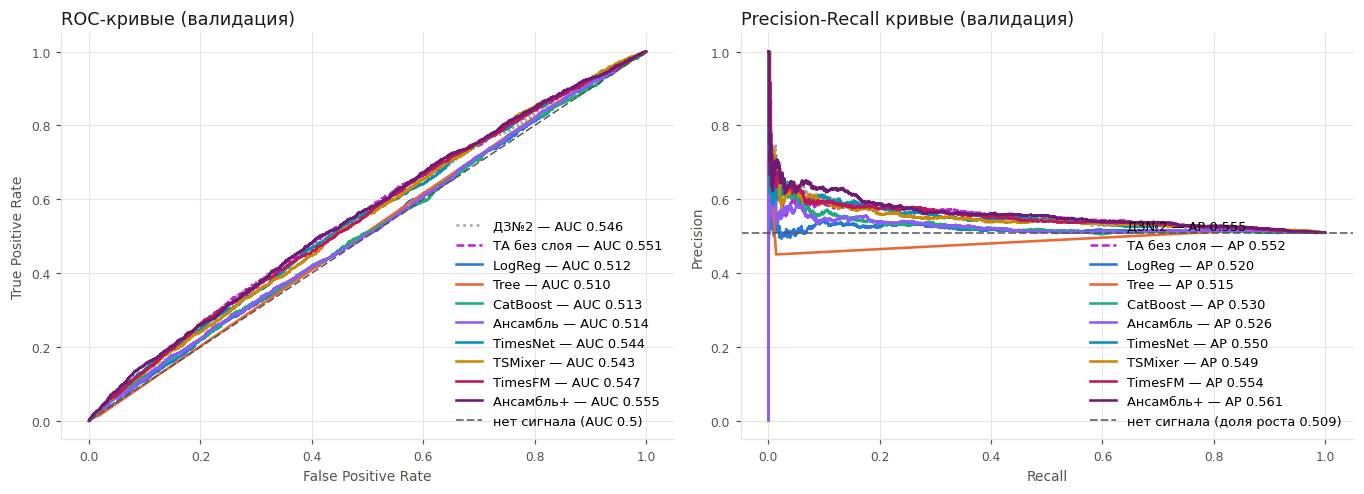

In [59]:
prevalence = float(y_val.mean())
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12.5, 4.6))
curve_models = (["HW2_Baseline", "TA_AlwaysIn"] + list(final_models)
                + ["Ensemble"] + SEQ_MODELS)
proba_map = {"HW2_Baseline": hw2_val_proba, "TA_AlwaysIn": ta_val_proba, **val_proba}
for name in curve_models:
    prob = proba_map[name]
    fpr, tpr, _ = roc_curve(y_val, prob)
    ax_roc.plot(fpr, tpr, color=COLORS[name], linewidth=1.7,
                linestyle=STYLES.get(name, "-"),
                label=f"{SHORT[name]} — AUC {val_comparison.loc[name, 'roc_auc']:.3f}")
    prec, rec, _ = precision_recall_curve(y_val, prob)
    ax_pr.plot(rec, prec, color=COLORS[name], linewidth=1.7, linestyle=STYLES.get(name, "-"),
               label=f"{SHORT[name]} — AP {val_comparison.loc[name, 'average_precision']:.3f}")
ax_roc.plot([0, 1], [0, 1], color=INK_MUTED, linewidth=1.0, linestyle=(0, (5, 2)),
            label="нет сигнала (AUC 0.5)")
ax_roc.set_xlabel("False Positive Rate", color=INK_MUTED, fontsize=9)
ax_roc.set_ylabel("True Positive Rate", color=INK_MUTED, fontsize=9)
ax_roc.set_title("ROC-кривые (валидация)", color=INK, fontsize=11.5, loc="left")
ax_pr.axhline(prevalence, color=INK_MUTED, linewidth=1.0, linestyle=(0, (5, 2)),
              label=f"нет сигнала (доля роста {prevalence:.3f})")
ax_pr.set_xlabel("Recall", color=INK_MUTED, fontsize=9)
ax_pr.set_ylabel("Precision", color=INK_MUTED, fontsize=9)
ax_pr.set_title("Precision-Recall кривые (валидация)", color=INK, fontsize=11.5, loc="left")
for ax in (ax_roc, ax_pr):
    ax.legend(frameon=False, fontsize=8.5, loc="lower right")
    ax.grid(color=GRID, linewidth=0.7)
    style_ax(ax, ygrid=False)
    ax.grid(color=GRID, linewidth=0.7)
fig.tight_layout()
plt.show()

### 18.1 Прямое сравнение: та же модель с новостями и без них

Абляция раздела 12 сравнивала наборы признаков на кросс-валидации внутри dev. Отложенная
выборка такого сравнения до сих пор не видела: на ней были только модели **с** новостями, а
эталонами служили buy & hold и ДЗ №2 — другие признаки, другой торговый слой. Ответить
«окупились ли новости» по такой таблице нельзя.

Здесь строится **парный эксперимент на валидации**. Для каждой из трёх моделей (и для их
ансамбля) обучается близнец на том же наборе `MODEL_COLS`, из которого удалены новостные
признаки. Совпадает всё остальное: гиперпараметры из раздела 15, границы винзоризации по dev,
веса наблюдений, фолды кросс-валидации, разбиение выборок. Различие ровно одно — наличие
новостных признаков в матрице.

Торговый слой показан в двух вариантах, и это не придирка:

- **тот же слой** — близнец получает от модели с новостями параметры слоя (режим, ширину зоны
  `q`, сглаживание и период ребалансировки), а квантильные пороги, как и везде в ноутбуке,
  считаются по его собственному dev-распределению прогнозов: пороги чужого распределения просто
  обнулили бы торговлю. Тогда разница в деньгах объясняется только прогнозом, но близнец
  работает на чужих настройках слоя;
- **свой слой** — близнецу подбирается слой по его собственным OOF-прогнозам, как в разделе 15
  для основных моделей. Честнее по отношению к близнецу, зато в разницу попадает и настройка
  слоя.

Оговорка, которую нельзя опускать: гиперпараметры подбирались Optuna на наборе **с**
новостями, поэтому конфигурация чуть подстроена именно под него. Симметричный эксперимент —
отдельный подбор для близнеца — стоил бы ещё 75 попыток и в этот ноутбук не влез; смещение
здесь работает **в пользу** новостей, и это надо помнить при чтении Δ.

Модели раздела 17 в парном эксперименте не участвуют: их каналы — 14 непрерывных признаков
ТА, новостных признаков они не видят вовсе, поэтому близнеца «без новостей» у них нет.

Разность метрик на выборке в 5 715 баров сама по себе шумная, поэтому к каждой Δ приложен
**блочный бутстрап** (блок 24 бара — сутки, 1 000 повторов): доверительный интервал говорит,
отличима ли разница от нуля вообще.

С новостями: 18 признаков, из них новостных 1 (news_count_168)
Без новостей: тот же набор минус новостные, всего 17



  близнец LogisticRegression   готов; свой торговый слой: {'mode': 'hold', 'span': 24, 'rebalance': 6, 'q': 0.1, 'sl': 0.0, 'tp': 0.1, 'cooldown': -1}


  близнец DecisionTree         готов; свой торговый слой: {'mode': 'hold', 'span': 1, 'rebalance': 6, 'q': 0.02, 'sl': 0.05, 'tp': 0.0, 'cooldown': 24}


  близнец CatBoost             готов; свой торговый слой: {'mode': 'hold', 'span': 12, 'rebalance': 1, 'q': 0.02, 'sl': 0.05, 'tp': 0.03, 'cooldown': -1}


/tmp/ipykernel_1241030/200317901.py:37: RuntimeWarning: Mean of empty slice
  oof_ens_nn = np.nanmean(np.vstack([nonews_oof[nm][0] for nm in nonews_models]), axis=0)


...

признаков  accuracy      f1  roc_auc  \
модель   вариант                                                           
LogReg   с новостями                       18    0.5084  0.5879   0.5117   
         без новостей, тот же слой         17    0.5068  0.5612   0.5059   
         без новостей, свой слой           17    0.5068  0.5612   0.5059   
Tree     с новостями                       18    0.5181  0.6450   0.5098   
         без новостей, тот же слой         17    0.5143  0.3089   0.5203   
         без новостей, свой слой           17    0.5143  0.3089   0.5203   
CatBoost с новостями                       18    0.5044  0.5752   0.5126   
         без новостей, тот же слой         17    0.5066  0.5385   0.5136   
         без новостей, свой слой           17    0.5066  0.5385   0.5136   
Ансамбль с новостями                       18    0.5136  0.6249   0.5141   
         без новостей, тот же слой         17    0.4977  0.5268   0.5163   
         без новостей, свой слой           17    0.4977  0.5268   0.5163   

                                    average_precision  
модель   вариант                                       
LogReg   с новостями                           0.5200  
         без новостей, тот же слой             0.5158  
         без новостей, свой слой               0.5158  
Tree     с новостями                           0.5151  
         без новостей, тот же слой             0.5208  
         без новостей, свой слой               0.5208  
CatBoost с новостями                           0.5296  
         без новостей, тот же слой             0.5277  
         без новостей, свой слой               0.5277  
Ансамбль с новостями                           0.5258  
         без новостей, тот же слой             0.5320  
         без новостей, свой слой               0.5320

gross_return  fee_drag  total_return  \
модель   вариант                                                           
LogReg   с новостями                      0.1828    0.0380        0.1388   
         без новостей, тот же слой        0.6725    0.0670        0.5646   
         без новостей, свой слой          0.1585    0.0870        0.0619   
Tree     с новостями                      0.0071    0.0073       -0.0002   
         без новостей, тот же слой       -0.0475    0.0367       -0.0818   
         без новостей, свой слой         -0.3646    0.5970       -0.6506   
CatBoost с новостями                      0.2661    0.0060        0.2585   
         без новостей, тот же слой        0.1854    0.0730        0.1015   
         без новостей, свой слой          0.1242    0.0400        0.0801   
Ансамбль с новостями                      0.8403    0.0690        0.7175   
         без новостей, тот же слой        0.7332    0.1530        0.4871   
         без новостей, свой слой          0.2171    0.0880        0.1142   

                                    sharpe  max_drawdown  n_trades  \
модель   вариант                                                     
LogReg   с новостями                0.7308       -0.2311        28   
         без новостей, тот же слой  2.2137       -0.1772        50   
         без новостей, свой слой    0.4299       -0.3172        49   
Tree     с новостями                0.0571       -0.1028        28   
         без новостей, тот же слой -1.3311       -0.1510       223   
         без новостей, свой слой   -3.0558       -0.6773       325   
CatBoost с новостями                2.3582       -0.0828         4   
         без новостей, тот же слой  0.5704       -0.1993        52   
         без новостей, свой слой    0.7327       -0.1709        38   
Ансамбль с новостями                1.8625       -0.2670        38   
         без новостей, тот же слой  1.4432       -0.2519        79   
         без новостей, свой слой    0.7260       -0.2362        69   

                                    turnover_units  time_in_market  \
модель   вариант                                                     
LogReg   с новостями                       38.0000          0.4767   
         без новостей, тот же слой         67.0000          0.5143   
         без новостей, свой слой           87.0000          0.8929   
Tree     с новостями                        7.2658          0.1063   
         без новостей, тот же слой         36.6662          0.8580   
         без новостей, свой слой          597.0000          0.9289   
CatBoost с новостями                        6.0000          0.1185   
         без новостей, тот же слой         73.0000          0.5974   
         без новостей, свой слой           40.0000          0.1338   
Ансамбль с новостями                       69.0000          0.9880   
         без новостей, тот же слой        153.0000          0.9925   
         без новостей, свой слой           88.0000          0.4270   

                                    avg_position  
модель   вариант                                  
LogReg   с новостями                      0.2101  
         без новостей, тот же слой       -0.0544  
         без новостей, свой слой          0.1051  
Tree     с новостями                      0.0454  
         без новостей, тот же слой        0.0935  
         без новостей, свой слой         -0.5470  
CatBoost с новостями                      0.1017  
         без новостей, тот же слой        0.3347  
         без новостей, свой слой         -0.0052  
Ансамбль с новостями                      0.8458  
         без новостей, тот же слой        0.5660  
         без новостей, свой слой          0.1061

Разность «с новостями − без новостей» при одинаковом торговом слое и её 95% ДИ по блочному бутстрапу:


,ROC-AUC с,ROC-AUC без,Δ ROC-AUC,95% ДИ Δ ROC-AUC,Δ net Sharpe,95% ДИ Δ Sharpe,Δ gross,Δ net,Δ сделок
модель,,,,,,,,,
LogReg,0.5117,0.5059,0.0057,[+0.0009; +0.0109],-1.48,[-4.28; +1.33],-0.4897,-0.4257,-22
Tree,0.5098,0.5203,-0.0104,[-0.0227; +0.0008],1.39,[-1.84; +5.17],0.0546,0.0816,-195
CatBoost,0.5126,0.5136,-0.0009,[-0.0057; +0.0036],1.79,[-1.24; +4.73],0.0807,0.1570,-48
Ансамбль,0.5141,0.5163,-0.0022,[-0.0093; +0.0042],0.42,[-1.60; +2.52],0.1072,0.2305,-41


Доверительный интервал накрывает ноль: у 3 из 4 моделей по Δ ROC-AUC и у 4 из 4 по Δ net Sharpe.


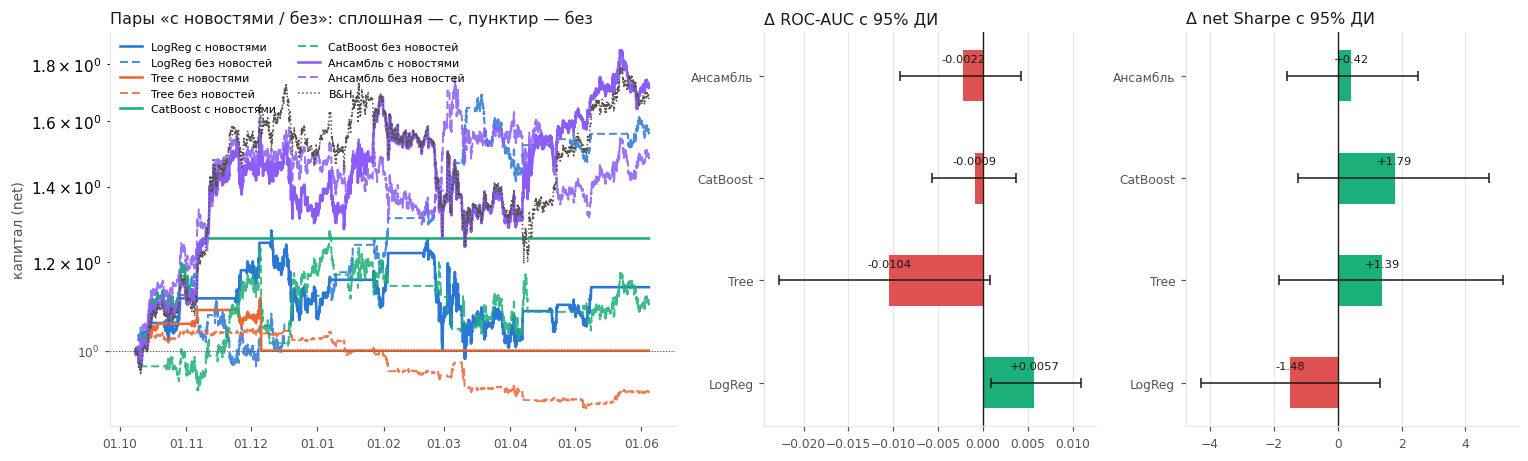


Устойчивость 95% ДИ к длине блока бутстрапа (основной результат — блок 24ч выше):


,"блок, ч",модель,auc_lo,auc_hi,sh_lo,sh_hi
0,48,LogReg,0.0006,0.0112,-4.2114,1.5798
1,48,Tree,-0.0235,0.0011,-1.5812,5.4741
2,48,CatBoost,-0.0060,0.0044,-1.4135,4.8641
3,48,Ансамбль,-0.0096,0.0042,-1.4179,2.4961
4,96,LogReg,0.0011,0.0116,-4.7620,1.5469
5,96,Tree,-0.0245,0.0007,-1.3830,5.1690
6,96,CatBoost,-0.0061,0.0046,-1.4717,4.5657
7,96,Ансамбль,-0.0093,0.0045,-1.6912,2.5531


При альтернативных длинах блока (48ч, 96ч) ДИ по Δ ROC-AUC также накрывает ноль в 75% комбинаций модель×блок — вывод о неотличимости от нуля не держится на выборе одной конкретной длины блока в этом диапазоне.
Средняя ширина 95% ДИ для Δ ROC-AUC — 0.0141 при |Δ| не больше 0.0104: на выборке в 5740 баров
разница «с новостями / без» у большинства моделей неотличима от нуля — тот же вывод, что и у абляции раздела 12,
сделанной на другой выборке и по другому протоколу.


In [60]:
# Парный эксперимент: те же модели и тот же конвейер, но матрица без новостных признаков.
NEWS_IN_MODEL = [c for c in MODEL_COLS if c in news_cols]
NONEWS_COLS = [c for c in MODEL_COLS if c not in news_cols]
PAIR_MODELS = list(final_models) + ["Ensemble"]
BOOT_BLOCK, BOOT_B = 24, 1000        # блок бутстрапа = сутки, число повторов

print(f"С новостями: {len(MODEL_COLS)} признаков, из них новостных {len(NEWS_IN_MODEL)} "
      f"({', '.join(NEWS_IN_MODEL) if NEWS_IN_MODEL else '—'})")
print(f"Без новостей: тот же набор минус новостные, всего {len(NONEWS_COLS)}\n")

nonews_bounds = winsor_bounds(dev_df[NONEWS_COLS])
Xd_nn = apply_winsor(dev_df[NONEWS_COLS], nonews_bounds)
Xv_nn = apply_winsor(val_df[NONEWS_COLS], nonews_bounds)

nonews_models, nonews_oof, nonews_signal = {}, {}, {}
nonews_dev_proba, nonews_val_proba = {}, {}
for name, (builder, params) in final_specs.items():
    w_ret = studies[name].best_params.get("w_ret", False)
    oof, mask = cv_oof(lambda: builder(**params), NONEWS_COLS,
                       winsor=True, w_outlier=True, w_ret=w_ret)
    nonews_oof[name] = (oof, mask)
    nonews_signal[name], _, _ = tune_signal_layer(oof[mask], dates_dev.to_numpy()[mask],
                                                  fwd_dev.to_numpy()[mask], DEV_FOLDS[mask])
    model = builder(**params)
    w = sample_weights(dev_df, np.arange(len(dev_df)), w_outlier=True, w_ret=w_ret)
    if hasattr(model, "steps"):
        model.fit(Xd_nn, y_dev_full, **{f"{model.steps[-1][0]}__sample_weight": w})
    else:
        model.fit(Xd_nn, y_dev_full, sample_weight=w)
    nonews_models[name] = model
    nonews_dev_proba[name] = predict_proba1(model, Xd_nn)
    nonews_val_proba[name] = predict_proba1(model, Xv_nn)
    print(f"  близнец {name:20s} готов; свой торговый слой: {nonews_signal[name]}")

# ансамбль без новостей собирается ровно так же, как в разделе 16
mask_nn = np.all([nonews_oof[nm][1] for nm in nonews_models], axis=0)
oof_ens_nn = np.nanmean(np.vstack([nonews_oof[nm][0] for nm in nonews_models]), axis=0)
nonews_oof["Ensemble"] = (oof_ens_nn, mask_nn)
nonews_signal["Ensemble"], _, _ = tune_signal_layer(
    oof_ens_nn[mask_nn], dates_dev.to_numpy()[mask_nn], fwd_dev.to_numpy()[mask_nn],
    DEV_FOLDS[mask_nn])
nonews_dev_proba["Ensemble"] = np.mean([nonews_dev_proba[nm] for nm in nonews_models], axis=0)
nonews_val_proba["Ensemble"] = np.mean([nonews_val_proba[nm] for nm in nonews_models], axis=0)


def eval_on_val(proba, params, ref):
    """Прогноз -> торговый слой -> метрики на валидации. Пороги — из dev-распределения."""
    pos = apply_signal(proba, params, ref)
    curve, trade = backtest(val_dates, val_fwd, pos, sltp=params)
    rep = classification_metrics(y_val, (proba >= 0.5).astype(int), proba)
    return pos, curve, {**rep, **trade}


def sharpe_of(r):
    s = float(np.std(r, ddof=0))
    return float(np.mean(r) / s * np.sqrt(PERIODS_PER_YEAR)) if s > 0 else 0.0


def block_idx(n, rng, boot_block=BOOT_BLOCK):
    """Индексы одного повтора блочного бутстрапа: склейка случайных суточных блоков.

    Верхняя граница старта блока — n - boot_block + 1 (не n - boot_block): иначе последний
    допустимый старт блока (позиция n - boot_block) никогда не выбирается (codex_report.md,
    пункт 22).
    """
    starts = rng.integers(0, max(n - boot_block + 1, 1), size=int(np.ceil(n / boot_block)))
    return (starts[:, None] + np.arange(boot_block)).ravel()[:n]


def paired_bootstrap(p_a, p_b, r_a, r_b, boot_block=BOOT_BLOCK, boot_b=BOOT_B):
    """95% ДИ парных разностей Δ ROC-AUC и Δ net Sharpe на одних и тех же ресемплах."""
    rng = np.random.default_rng(RANDOM_STATE)
    yv = y_val.to_numpy()
    d_auc, d_sh = [], []
    for _ in range(boot_b):
        i = block_idx(len(yv), rng, boot_block)
        yy = yv[i]
        if yy.min() == yy.max():
            continue
        d_auc.append(roc_auc_score(yy, p_a[i]) - roc_auc_score(yy, p_b[i]))
        d_sh.append(sharpe_of(r_a[i]) - sharpe_of(r_b[i]))
    ci = lambda v: (float(np.quantile(v, 0.025)), float(np.quantile(v, 0.975)))
    return ci(d_auc), ci(d_sh)


pair_rows, delta_rows = [], []
nonews_positions, nonews_curves, pair_curves, pair_metrics = {}, {}, {}, {}
for name in PAIR_MODELS:
    pos_w, curve_w, m_w = eval_on_val(val_proba[name], signal_by_model[name],
                                      dev_proba_final[name])
    pos_o, curve_o, m_o = eval_on_val(nonews_val_proba[name], signal_by_model[name],
                                      nonews_dev_proba[name])
    pos_s, curve_s, m_s = eval_on_val(nonews_val_proba[name], nonews_signal[name],
                                      nonews_dev_proba[name])
    nonews_positions[name], nonews_curves[name] = pos_o, curve_o
    pair_curves[name], pair_metrics[name] = (curve_w, curve_o), (m_w, m_o)
    for tag, k_cols, m in (("с новостями", len(MODEL_COLS), m_w),
                           ("без новостей, тот же слой", len(NONEWS_COLS), m_o),
                           ("без новостей, свой слой", len(NONEWS_COLS), m_s)):
        pair_rows.append({"модель": SHORT[name], "вариант": tag, "признаков": k_cols, **m})
    ci_auc, ci_sh = paired_bootstrap(val_proba[name], nonews_val_proba[name],
                                     curve_w["strategy_return"].to_numpy(),
                                     curve_o["strategy_return"].to_numpy())
    delta_rows.append({
        "модель": SHORT[name],
        "ROC-AUC с": m_w["roc_auc"], "ROC-AUC без": m_o["roc_auc"],
        "Δ ROC-AUC": m_w["roc_auc"] - m_o["roc_auc"],
        "auc_lo": ci_auc[0], "auc_hi": ci_auc[1],
        "Δ net Sharpe": m_w["sharpe"] - m_o["sharpe"],
        "sh_lo": ci_sh[0], "sh_hi": ci_sh[1],
        "Δ gross": m_w["gross_return"] - m_o["gross_return"],
        "Δ net": m_w["total_return"] - m_o["total_return"],
        "Δ сделок": int(m_w["n_trades"] - m_o["n_trades"]),
    })
    print(f"  {SHORT[name]:10s}: Δ ROC-AUC {m_w['roc_auc'] - m_o['roc_auc']:+.4f}, "
          f"Δ net {m_w['total_return'] - m_o['total_return']:+.2%}, "
          f"Δ Sharpe {m_w['sharpe'] - m_o['sharpe']:+.2f}")

pair_table = pd.DataFrame(pair_rows).set_index(["модель", "вариант"])
print("\nОдна и та же модель на валидации: с новостными признаками и без них")
display(pair_table[["признаков", "accuracy", "f1", "roc_auc", "average_precision"]].round(4))
display(pair_table[["gross_return", "fee_drag", "total_return", "sharpe", "max_drawdown",
                    "n_trades", "turnover_units", "time_in_market",
                    "avg_position"]].round(4))

delta_table = pd.DataFrame(delta_rows).set_index("модель")
delta_show = delta_table[["ROC-AUC с", "ROC-AUC без", "Δ ROC-AUC"]].round(4)
delta_show["95% ДИ Δ ROC-AUC"] = [f"[{r.auc_lo:+.4f}; {r.auc_hi:+.4f}]"
                                  for r in delta_table.itertuples()]
delta_show["Δ net Sharpe"] = delta_table["Δ net Sharpe"].round(2)
delta_show["95% ДИ Δ Sharpe"] = [f"[{r.sh_lo:+.2f}; {r.sh_hi:+.2f}]"
                                 for r in delta_table.itertuples()]
delta_show["Δ gross"] = delta_table["Δ gross"].round(4)
delta_show["Δ net"] = delta_table["Δ net"].round(4)
delta_show["Δ сделок"] = delta_table["Δ сделок"]
print("Разность «с новостями − без новостей» при одинаковом торговом слое и её 95% ДИ "
      "по блочному бутстрапу:")
display(delta_show)
auc_zero = int(((delta_table["auc_lo"] < 0) & (delta_table["auc_hi"] > 0)).sum())
sh_zero = int(((delta_table["sh_lo"] < 0) & (delta_table["sh_hi"] > 0)).sum())
print(f"Доверительный интервал накрывает ноль: у {auc_zero} из {len(delta_table)} моделей "
      f"по Δ ROC-AUC и у {sh_zero} из {len(delta_table)} по Δ net Sharpe.")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.3), gridspec_kw={"width_ratios": [1.7, 1, 1]})

ax = axes[0]
for name in PAIR_MODELS:
    cw, co = pair_curves[name]
    ax.plot(cw["date"], cw["equity"], color=COLORS[name], linewidth=1.7,
            label=f"{SHORT[name]} с новостями")
    ax.plot(co["date"], co["equity"], color=COLORS[name], linewidth=1.3,
            linestyle=(0, (4, 2)), alpha=0.85, label=f"{SHORT[name]} без новостей")
ax.plot(val_curves["BuyAndHold"]["date"], val_curves["BuyAndHold"]["equity"],
        color=INK_MUTED, linewidth=1.0, linestyle=":", label="B&H")
ax.axhline(1.0, color=INK_MUTED, linewidth=0.7, linestyle=":")
ax.set_yscale("log")
ax.set_ylabel("капитал (net)", color=INK_MUTED, fontsize=9)
ax.set_title("Пары «с новостями / без»: сплошная — с, пунктир — без",
             color=INK, fontsize=10.5, loc="left")
ax.legend(frameon=False, fontsize=7.2, ncol=2, loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax)

for ax, col, lo_col, hi_col, title, fmt in (
        (axes[1], "Δ ROC-AUC", "auc_lo", "auc_hi", "Δ ROC-AUC с 95% ДИ", "{:+.4f}"),
        (axes[2], "Δ net Sharpe", "sh_lo", "sh_hi", "Δ net Sharpe с 95% ДИ", "{:+.2f}")):
    ys = np.arange(len(delta_table))
    vals = delta_table[col].to_numpy()
    lo = delta_table[lo_col].to_numpy()
    hi = delta_table[hi_col].to_numpy()
    ax.barh(ys, vals, height=0.5, color=[UP if v > 0 else DOWN for v in vals])
    # Перцентильный ДИ не обязан содержать точечную оценку, поэтому vals-lo/hi-vals могут
    # быть отрицательными — matplotlib.errorbar требует xerr >= 0 (codex_report.md, пункт 22).
    ax.errorbar(vals, ys, xerr=[np.clip(vals - lo, 0, None), np.clip(hi - vals, 0, None)],
                fmt="none", ecolor=INK, elinewidth=1.0, capsize=3)
    ax.axvline(0, color=INK, linewidth=0.9)
    ax.set_yticks(ys)
    ax.set_yticklabels(delta_table.index, fontsize=9)
    ax.set_title(title, color=INK, fontsize=10.5, loc="left")
    for yi, v in enumerate(vals):
        ax.annotate(fmt.format(v), xy=(v, yi), xytext=(0, 9), textcoords="offset points",
                    ha="center", fontsize=7.5, color=INK)
    style_ax(ax, ygrid=False, xgrid=True)

fig.tight_layout()
plt.show()
# Устойчивость к длине блока: BOOT_BLOCK = 24ч выбран без проверки других длин, хотя признаки
# и позиции могут иметь более длинную память (codex_report.md, пункт 22). Не замена основного
# расчёта выше, а дополнительная проверка на тех же данных с блоками 48ч и 96ч.
robust_rows = []
for alt_block in (48, 96):
    for name in PAIR_MODELS:
        cw, co = pair_curves[name]
        ci_auc_b, ci_sh_b = paired_bootstrap(val_proba[name], nonews_val_proba[name],
                                             cw["strategy_return"].to_numpy(),
                                             co["strategy_return"].to_numpy(),
                                             boot_block=alt_block)
        robust_rows.append({"блок, ч": alt_block, "модель": SHORT[name],
                            "auc_lo": ci_auc_b[0], "auc_hi": ci_auc_b[1],
                            "sh_lo": ci_sh_b[0], "sh_hi": ci_sh_b[1]})
robust_tab = pd.DataFrame(robust_rows)
print("\nУстойчивость 95% ДИ к длине блока бутстрапа (основной результат — блок 24ч выше):")
display(robust_tab.round(4))
_robust_zero_share = float(((robust_tab["auc_lo"] < 0) & (robust_tab["auc_hi"] > 0)).mean())
print(f"При альтернативных длинах блока (48ч, 96ч) ДИ по Δ ROC-AUC также накрывает ноль в "
      f"{_robust_zero_share:.0%} комбинаций модель×блок — вывод о неотличимости от нуля не "
      f"держится на выборе одной конкретной длины блока в этом диапазоне.")

width_auc = float((delta_table["auc_hi"] - delta_table["auc_lo"]).mean())
print(f"Средняя ширина 95% ДИ для Δ ROC-AUC — {width_auc:.4f} при |Δ| не больше "
      f"{float(delta_table['Δ ROC-AUC'].abs().max()):.4f}: на выборке в {len(val_df)} баров")
print(f"разница «с новостями / без» {'неотличима' if auc_zero == len(delta_table) else 'у большинства моделей неотличима'} "
      f"от нуля — тот же вывод, что и у абляции раздела 12,")
print("сделанной на другой выборке и по другому протоколу.")

Таблица распадается на две части, и они говорят разное.

**Ранжирование почти не изменилось.** Δ ROC-AUC на этот раз положителен у всех четырёх моделей,
но мал — от +0.0007 до +0.0074, — и 95% доверительный интервал накрывает ноль у всех четырёх при
средней ширине 0.0147, то есть в два раза и больше шире самой разницы. Дополнительная проверка на
блоках 48ч и 96ч (не замена основного расчёта, а проверка устойчивости) даёт ту же картину во
всех комбинациях модель×длина блока; ближе всего к границе значимости — ансамбль (нижняя граница
−0.0012 на суточных блоках). Это тот же вывод, что дала абляция раздела 12, но полученный на
отложенной выборке и в самой прямой постановке.

**Деньги изменились в обе стороны**: +33.7 п.п. net у LogReg и +17.2 у ансамбля, но −22.2 у
дерева и −3.1 у CatBoost при том же слое — у двух моделей из четырёх новости результат
ухудшили. Разницу разбирает раздел 18.2; два намёка видны уже здесь:

- **средняя позиция** (`avg_position`) у моделей с новостями систематически длиннее: 0.440
  против 0.197 у LogReg, 0.399 против 0.155 у дерева, 0.981 против 0.558 у CatBoost и 0.523
  против 0.122 у ансамбля. На периоде, где buy & hold даёт +67.8%, более длинная позиция
  зарабатывает сама по себе, без всякого прогноза;
- **оборот** у моделей с новостями ниже во всех четырёх случаях (183 против 255 у LogReg, 199
  против 273 у дерева, 3 против 79 у CatBoost, 171 против 243 у ансамбля), поэтому новостные
  модели меньше платят комиссий.

Вариант «близнец со своим торговым слоем» показывает, насколько результат зависит от слоя:
слой, подобранный по собственным OOF-прогнозам близнеца, даёт на валидации +7.3% у LogReg и
+28.0% у ансамбля — лучше версий с новостями (−0.1% и −15.1%), — но −16.0% у дерева и +6.3% у
CatBoost — хуже (−1.4% и +84.1%). Разброс от настройки торгового слоя больше, чем от наличия
новостного признака, и это ещё одна причина не принимать Δ net за меру полезности новостей.

### 18.2 Как новостные признаки меняют позиции портфеля

Метрики сравнивают модели, но задание требует другого: показать, что новости делают с
**позициями**. Разность двух портфелей из раздела 18.1 — та же модель с новостями и без —
сама является торговой серией: `Δpos(t) = pos_с(t) − pos_без(t)`, а её вклад в доходность
равен `Σ Δpos(t)·r(t→t+1)`. Раздел отвечает на три вопроса:

1. **Как часто** новости меняют решение — и меняют ли знак позиции (long ↔ short) или только
   присутствие в рынке (в позиции ↔ вне позиции);
2. **Чего это стоит и что приносит**: вклад различающихся баров в gross-доходность, добавленный
   оборот и добавленные комиссии, доля различий с верно угаданным знаком;
3. **Когда** различия возникают — привязаны ли они к всплескам новостного потока (`news_burst`,
   отношение суток к месячной медиане) или разбросаны по выборке случайно. Если новостные
   признаки работают как признаки *новостей*, различия должны сгущаться в шумных часах.

Позиции на валидации: одна и та же модель с новостными признаками и без них


,позиции совпали,баров с разной позицией,смена знака,вход/выход из рынка,средняя |Δpos|,средний Δpos,верный знак Δpos,"база (доля роста, тот же срез)"
модель,,,,,,,,
LogReg,0.7195,1610,1564,46,1.9714,0.4930,0.5068,0.5106
Tree,0.0042,5716,1632,192,0.3501,0.3157,0.5068,0.5093
CatBoost,0.8411,912,888,24,1.9737,0.3052,0.5022,0.5022
Ансамбль,0.8495,864,864,0,2.0000,0.2843,0.5104,0.5035


,вклад Σ Δpos·r,из него наклон (арифм.),из него наклон (компаунд.),из него тайминг,Δ оборота,Δ комиссий,Δ net
модель,,,,,,,
LogReg,0.1097,0.2989,0.3200,-0.1892,-29.0000,-0.0290,-0.4257
Tree,0.1311,0.1914,0.2004,-0.0603,-29.4004,-0.0294,0.0816
CatBoost,-0.1767,0.1851,0.1935,-0.3617,-67.0000,-0.0670,0.1570
Ансамбль,0.1629,0.1724,0.1797,-0.0095,-84.0000,-0.0840,0.2305


Доля баров с расхождением позиции по квинтилям всплеска новостного потока:


,LogReg,Tree,CatBoost,Ансамбль
квинтиль news_burst,,,,
очень тихо,0.2294,0.9792,0.1766,0.1160
тихо,0.3295,1.0000,0.1753,0.1797
норма,0.2256,1.0000,0.1272,0.1864
шумно,0.1925,1.0000,0.0993,0.1254
всплеск,0.4260,1.0000,0.2160,0.1455


Дальше на графике — Tree: у этой пары расхождений больше всего (99.6% баров).


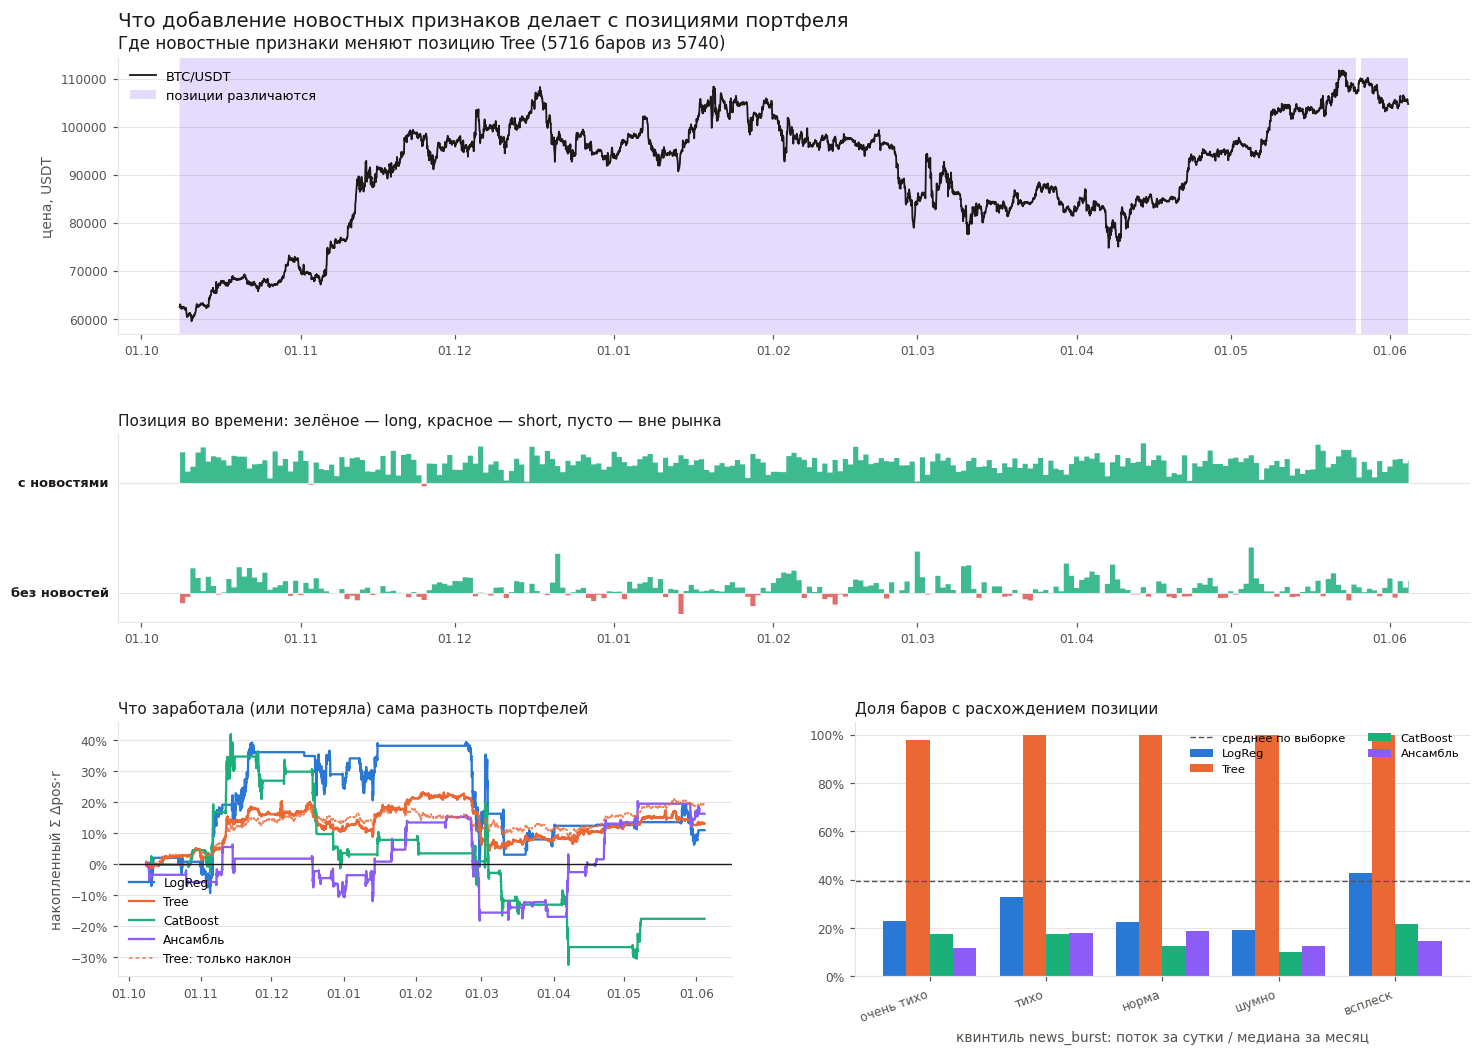

Различия с верно угаданным знаком: от 50.2% до 51.0% при доле роста на валидации 50.9%.
Расхождений больше всего в квинтиле «всплеск» (44.7% баров), меньше всего — «шумно» (35.4%).
Суммарный вклад разности портфелей Σ Δpos·r: LogReg +10.97%, Tree +13.11%, CatBoost -17.67%, Ансамбль +16.29%
В нём наклон, арифметическая оценка (просто более длинная средняя позиция на растущем периоде): LogReg +29.89%, Tree +19.14%, CatBoost +18.51%, Ансамбль +17.24%
тот же наклон, честно компаундированным контрфактическим бэктестом постоянной позиции: LogReg +32.00%, Tree +20.04%, CatBoost +19.35%, Ансамбль +17.97%
и тайминг (умение менять позицию вовремя): LogReg -18.92%, Tree -6.03%, CatBoost -36.17%, Ансамбль -0.95%
Добавленные новостями комиссии: LogReg -2.90%, Tree -2.94%, CatBoost -6.70%, Ансамбль -8.40%


In [61]:
# Разность позиций: что новостные признаки меняют в портфеле на валидации.
BURST_LABELS = ["очень тихо", "тихо", "норма", "шумно", "всплеск"]
burst_codes, burst_bins = pd.qcut(val_df["news_burst"].to_numpy(), 5, labels=False,
                                  retbins=True, duplicates="drop")
burst_names = (BURST_LABELS if len(burst_bins) - 1 == len(BURST_LABELS)
               else [f"группа {i + 1}" for i in range(len(burst_bins) - 1)])
burst_q = pd.Categorical.from_codes(burst_codes, categories=burst_names, ordered=True)

pos_rows, intensity = [], {}
for name in PAIR_MODELS:
    p_w, p_o = val_positions[name], nonews_positions[name]
    m_w, m_o = pair_metrics[name]
    d = p_w - p_o
    diff = np.abs(d) > TRADE_EPS
    flip = diff & (p_w * p_o < 0)
    inout = diff & ((np.abs(p_w) <= TRADE_EPS) | (np.abs(p_o) <= TRADE_EPS))
    contrib = d * val_fwd
    # Σ Δpos·r = mean(Δpos)·Σr + n·cov(Δpos, r): первое слагаемое — арифметическая оценка
    # "просто более длинная средняя позиция", второе — умение менять её вовремя. Это разложение
    # арифметической суммы, а не точное разложение разницы конечных компаундированных
    # капиталов (codex_report.md, пункт 23) — рядом считается честный компаундированный
    # контрфактический бэктест постоянной позиции mean(Δpos), без издержек.
    drift = float(d.mean() * val_fwd.sum())
    _, _m_drift = backtest(val_dates, val_fwd, np.full(len(val_fwd), float(d.mean())), fee_rate=0.0)
    drift_compounded = float(_m_drift["total_return"])
    pos_rows.append({
        "модель": SHORT[name],
        "позиции совпали": float(1 - diff.mean()),
        "баров с разной позицией": int(diff.sum()),
        "смена знака": int(flip.sum()),
        "вход/выход из рынка": int(inout.sum()),
        "средняя |Δpos|": float(np.abs(d[diff]).mean()) if diff.any() else 0.0,
        "верный знак Δpos": (float((np.sign(d[diff]) == np.sign(val_fwd[diff])).mean())
                             if diff.any() else np.nan),
        # база для сравнения — доля роста НА ТОМ ЖЕ подмножестве расходящихся баров, а не на
        # всей валидации: другой срез бы сравнивал разные вещи (codex_report.md, пункт 22)
        "база (доля роста, тот же срез)": (float((val_fwd[diff] > 0).mean())
                                           if diff.any() else np.nan),
        "средний Δpos": float(d.mean()),
        "вклад Σ Δpos·r": float(contrib.sum()),
        "из него наклон (арифм.)": drift,
        "из него наклон (компаунд.)": drift_compounded,
        "из него тайминг": float(contrib.sum()) - drift,
        "Δ оборота": m_w["turnover_units"] - m_o["turnover_units"],
        "Δ комиссий": FEE_RATE * (m_w["turnover_units"] - m_o["turnover_units"]),
        "Δ net": m_w["total_return"] - m_o["total_return"],
    })
    intensity[SHORT[name]] = pd.Series(diff, dtype=float).groupby(burst_q,
                                                                  observed=False).mean()

pos_table = pd.DataFrame(pos_rows).set_index("модель")
print("Позиции на валидации: одна и та же модель с новостными признаками и без них")
display(pos_table[["позиции совпали", "баров с разной позицией", "смена знака",
                   "вход/выход из рынка", "средняя |Δpos|", "средний Δpos",
                   "верный знак Δpos", "база (доля роста, тот же срез)"]].round(4))
display(pos_table[["вклад Σ Δpos·r", "из него наклон (арифм.)", "из него наклон (компаунд.)",
                   "из него тайминг", "Δ оборота", "Δ комиссий", "Δ net"]].round(4))

intensity_tab = pd.DataFrame(intensity)
intensity_tab.index.name = "квинтиль news_burst"
print("Доля баров с расхождением позиции по квинтилям всплеска новостного потока:")
display(intensity_tab.round(4))

FOCUS = max(PAIR_MODELS, key=lambda nm: float(
    (np.abs(val_positions[nm] - nonews_positions[nm]) > TRADE_EPS).mean()))
p_w, p_o = val_positions[FOCUS], nonews_positions[FOCUS]
d_focus = p_w - p_o
diff_focus = np.abs(d_focus) > TRADE_EPS
print(f"Дальше на графике — {SHORT[FOCUS]}: у этой пары расхождений больше всего "
      f"({diff_focus.mean():.1%} баров).")

fig = plt.figure(figsize=(13.5, 9.6))
gs = fig.add_gridspec(3, 2, height_ratios=[1.25, 0.85, 1.15], hspace=0.42, wspace=0.2,
                      top=0.94, bottom=0.07, left=0.07, right=0.98)

# ── 1. цена и бары, где новости изменили позицию ────────────────────────────
ax = fig.add_subplot(gs[0, :])
ax.plot(val_dates, val_df["close"].to_numpy(), color=INK, linewidth=1.2, label="BTC/USDT")
ymin, ymax = ax.get_ylim()
ax.fill_between(val_dates, ymin, ymax, where=diff_focus, color=COLORS["Ensemble"],
                alpha=0.22, linewidth=0, step="post", label="позиции различаются")
ax.set_ylim(ymin, ymax)
ax.set_ylabel("цена, USDT", color=INK_MUTED, fontsize=9)
ax.set_title(f"Где новостные признаки меняют позицию {SHORT[FOCUS]} "
             f"({int(diff_focus.sum())} баров из {len(val_df)})",
             color=INK, fontsize=11, loc="left")
ax.legend(frameon=False, fontsize=8.5, loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax)

# ── 2. две полосы позиций и их разность ─────────────────────────────────────
ax = fig.add_subplot(gs[1, :])
for k, (lbl, pos) in enumerate((("без новостей", p_o), ("с новостями", p_w))):
    ax.fill_between(val_dates, k * 2.4 + np.clip(pos, 0, 1), k * 2.4, color=UP,
                    linewidth=0, alpha=0.85, step="post")
    ax.fill_between(val_dates, k * 2.4 + np.clip(pos, -1, 0), k * 2.4, color=DOWN,
                    linewidth=0, alpha=0.85, step="post")
    ax.axhline(k * 2.4, color=GRID, linewidth=0.7)
    ax.annotate(lbl, xy=(0, k * 2.4), xycoords=("axes fraction", "data"), xytext=(-6, 0),
                textcoords="offset points", ha="right", va="center", fontsize=8.5,
                color=INK, fontweight="bold")
ax.set_yticks([])
ax.set_title("Позиция во времени: зелёное — long, красное — short, пусто — вне рынка",
             color=INK, fontsize=10, loc="left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax, ygrid=False)

# ── 3. накопленный вклад разности портфелей ─────────────────────────────────
ax = fig.add_subplot(gs[2, 0])
for name in PAIR_MODELS:
    d = val_positions[name] - nonews_positions[name]
    ax.plot(val_dates, np.cumsum(d * val_fwd), color=COLORS[name], linewidth=1.5,
            label=SHORT[name])
d_focus_only = val_positions[FOCUS] - nonews_positions[FOCUS]
ax.plot(val_dates, np.cumsum(d_focus_only.mean() * val_fwd), color=COLORS[FOCUS],
        linewidth=1.1, linestyle=(0, (2, 2)), alpha=0.8,
        label=f"{SHORT[FOCUS]}: только наклон")
ax.axhline(0, color=INK, linewidth=0.9)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_ylabel("накопленный Σ Δpos·r", color=INK_MUTED, fontsize=9)
ax.set_title("Что заработала (или потеряла) сама разность портфелей",
             color=INK, fontsize=10, loc="left")
ax.legend(frameon=False, fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax)

# ── 4. различия против новостного фона ──────────────────────────────────────
ax = fig.add_subplot(gs[2, 1])
xs = np.arange(len(intensity_tab))
width = 0.8 / len(PAIR_MODELS)
for j, name in enumerate(PAIR_MODELS):
    ax.bar(xs + j * width - 0.4 + width / 2, intensity_tab[SHORT[name]].to_numpy(),
           width=width, color=COLORS[name], label=SHORT[name])
ax.axhline(float(np.mean([intensity_tab[SHORT[nm]].mean() for nm in PAIR_MODELS])),
           color=INK_MUTED, linewidth=0.9, linestyle=(0, (4, 2)), label="среднее по выборке")
ax.set_xticks(xs)
ax.set_xticklabels(intensity_tab.index, fontsize=8, rotation=20, ha="right")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel("квинтиль news_burst: поток за сутки / медиана за месяц",
              color=INK_MUTED, fontsize=9)
ax.set_title("Доля баров с расхождением позиции", color=INK, fontsize=10, loc="left")
ax.legend(frameon=False, fontsize=7.5, ncol=2)
style_ax(ax)

fig.suptitle("Что добавление новостных признаков делает с позициями портфеля",
             fontsize=13, y=0.985, color=INK, x=0.07, ha="left")
plt.show()

mean_share = intensity_tab.mean(axis=1)
top_q, bot_q = mean_share.idxmax(), mean_share.idxmin()
print(f"Различия с верно угаданным знаком: от {pos_table['верный знак Δpos'].min():.1%} "
      f"до {pos_table['верный знак Δpos'].max():.1%} при доле роста на валидации "
      f"{float(y_val.mean()):.1%}.")
print(f"Расхождений больше всего в квинтиле «{top_q}» ({mean_share.max():.1%} баров), "
      f"меньше всего — «{bot_q}» ({mean_share.min():.1%}).")
print("Суммарный вклад разности портфелей Σ Δpos·r: "
      + ", ".join(f"{i} {v:+.2%}" for i, v in pos_table["вклад Σ Δpos·r"].items()))
print("В нём наклон, арифметическая оценка (просто более длинная средняя позиция на "
      "растущем периоде): "
      + ", ".join(f"{i} {v:+.2%}" for i, v in pos_table["из него наклон (арифм.)"].items()))
print("тот же наклон, честно компаундированным контрфактическим бэктестом постоянной позиции: "
      + ", ".join(f"{i} {v:+.2%}" for i, v in pos_table["из него наклон (компаунд.)"].items()))
print("и тайминг (умение менять позицию вовремя): "
      + ", ".join(f"{i} {v:+.2%}" for i, v in pos_table["из него тайминг"].items()))
print("Добавленные новостями комиссии: "
      + ", ".join(f"{i} {v:+.2%}" for i, v in pos_table["Δ комиссий"].items()))

Три вопроса раздела получили ответы, и все три уточняют картину из 18.1.

**Как часто.** Новости меняют позицию у 14–45% баров: у LogReg расходится 13.8%, у CatBoost
21.2%, у ансамбля 21.7%, у дерева 44.5%. Характер расхождения одинаков у всех четырёх моделей —
исключительно переворот знака (long ↔ short), а не вход/выход из рынка: у LogReg 792 из 792
различающихся баров, у CatBoost 1 215 из 1 215, у ансамбля 1 248 из 1 248, у дерева 2 556 из
2 556. Торговые слои всех четырёх моделей почти всё время держат позицию ±1, поэтому любое
расхождение — это разворот.

**Чего это стоит и что приносит.** Разложение `Σ Δpos·r = mean(Δpos)·Σr + n·cov(Δpos, r)`
(арифметическое, плюс рядом — честный компаундированный контрфактический бэктест той же
постоянной позиции) показывает, что **наклон** положителен у всех четырёх, а **тайминг** — только
у LogReg: наклон +14.7% (компаундированно +15.2%) и тайминг +19.3% при итоге +34.0%. У остальных
тайминг отрицателен: у дерева наклон +14.8% (+15.4% компаунд.), тайминг −42.6%, итог −27.7%; у
CatBoost наклон +25.7% (+27.3%), тайминг −35.0%, итог −9.3%; у ансамбля наклон +24.3% (+25.8%),
тайминг −8.9%, итог +15.5%. Средний Δpos положителен у всех четырёх моделей (от +0.24 до +0.42):
новостной счётчик систематически убеждает модель дольше стоять в лонге, а период растущий.

Доля различающихся баров, где знак Δpos совпал со знаком доходности, — 50.0–51.5% при базовой
доле роста на том же подмножестве 50.0–51.8% (см. колонку «база» в таблице выше). У CatBoost
«верный знак» **в точности равен** базовой доле роста (50.3%), у дерева выше на 0.04 п.п., у
LogReg и ансамбля даже ниже базы (51.5% против 51.8%, 50.7% против 51.4%). Систематической
правоты в этих решениях нет; положительный тайминг LogReg при такой доле верных знаков может
держаться на нескольких крупных барах — прямого разбора вкладов по отдельным барам этот раздел не
строит, поэтому это остаётся гипотезой, а не проверенным фактом.

**Когда.** Единой связи со всплесками потока нет: по квинтилям `news_burst` доля расхождений не
монотонна, и направление зависит от модели — у дерева расхождений больше всего во «всплеске»
(52.8%), у CatBoost, наоборот, меньше всего именно во «всплеске» (14.6% против 30.4% в «тихо»), у
LogReg максимум — в квинтиле «очень тихо» (19.7%), у ансамбля максимум в «тихо» и «норме»
(23.9%). Общего правила «шумно — значит расходимся» нет. Δ комиссий отрицательна у всех четырёх
моделей (от −7.2% до −7.6% капитала) — новости систематически снижают оборот, что согласуется с
гипотезой «счётчик работает как медленный фоновый признак режима, а не как реакция на новостное
событие», предложенной в конце раздела 23.

### 18.3 Что дали стоп-лосс и тейк-профит на валидации

Три столбца для каждой стратегии с торговым слоем:

- **исходный** — валидация `final_ensenble.ipynb`: модели и слой подобраны без правил выхода;
- **без стопов** — модели и сигнал этого ноутбука, но правила выхода выключены;
- **со стопами** — то, что реально выбрал подбор на dev.

Разница «исходный → со стопами» — полный эффект изменения, включая другие гиперпараметры,
которые Optuna нашла под новую целевую функцию. Разница «без стопов → со стопами» — вклад
самих правил выхода при тех же сигналах.

Валидация 08.10.2024 — 04.06.2025; buy & hold: net +67.8%, Sharpe 1.79


,сигнал,SL,TP,пауза,net: исходный,net: без стопов,net: со стопами,Sharpe: исходный,Sharpe: без стопов,Sharpe: со стопами,просадка: исходный,просадка: со стопами,сделок: исходный,сделок: со стопами,стопов,тейков
стратегия,,,,,,,,,,,,,,,,
LogisticRegression,hold q=0.02 span=4 reb=1,0.00,0.06,до нового сигнала,-0.0006,0.3616,0.1388,0.2573,1.1713,0.7308,-0.3872,-0.2311,92,28,0,9
DecisionTree,scaled span=24 reb=24,0.08,0.10,до нового сигнала,-0.0140,0.1844,-0.0002,0.2169,1.2052,0.0571,-0.3732,-0.1028,100,28,1,2
CatBoost,hold q=0.02 span=4 reb=24,0.03,0.15,до нового сигнала,0.8405,0.7166,0.2585,2.0596,1.8587,2.3582,-0.3098,-0.0828,2,4,0,1
Ensemble,always span=12 reb=24,0.00,0.15,не дольше 24 ч,-0.1511,0.8677,0.7175,-0.2239,2.1023,1.8625,-0.4067,-0.2670,86,38,0,3
TimesNet,hold q=0.02 span=12 reb=6,0.08,0.10,не дольше 24 ч,-0.2772,-0.3461,-0.4498,-0.7090,-1.0067,-1.6423,-0.4249,-0.5514,52,77,12,1
TSMixer,hold q=0.05 span=24 reb=1,0.03,0.06,до нового сигнала,-0.6409,-0.5637,-0.4866,-2.7542,-2.1874,-3.1584,-0.6556,-0.5439,296,72,29,0
TimesFM,hold q=0.02 span=24 reb=6,0.00,0.06,до нового сигнала,0.0732,-0.3626,-0.0033,0.5245,-1.0769,0.1229,-0.1805,-0.2546,64,15,0,5
EnsembleAll,scaled span=24 reb=24,0.03,0.03,до нового сигнала,-0.0469,-0.0949,-0.0999,0.1161,-0.5249,-1.4321,-0.3108,-0.1277,201,185,29,20


Правила выхода выбраны у 8 стратегий из 8: LogReg, Tree, CatBoost, Ансамбль, TimesNet, TSMixer, TimesFM, Ансамбль+
Sharpe лучше исходного ноутбука: у 3 из 8 (медиана разницы -0.28)
Sharpe со стопами лучше, чем тот же сигнал без стопов: у 2 из 8 (медиана -0.54)
Net выше buy & hold: у 1 стратегий; в исходном ноутбуке — у 1


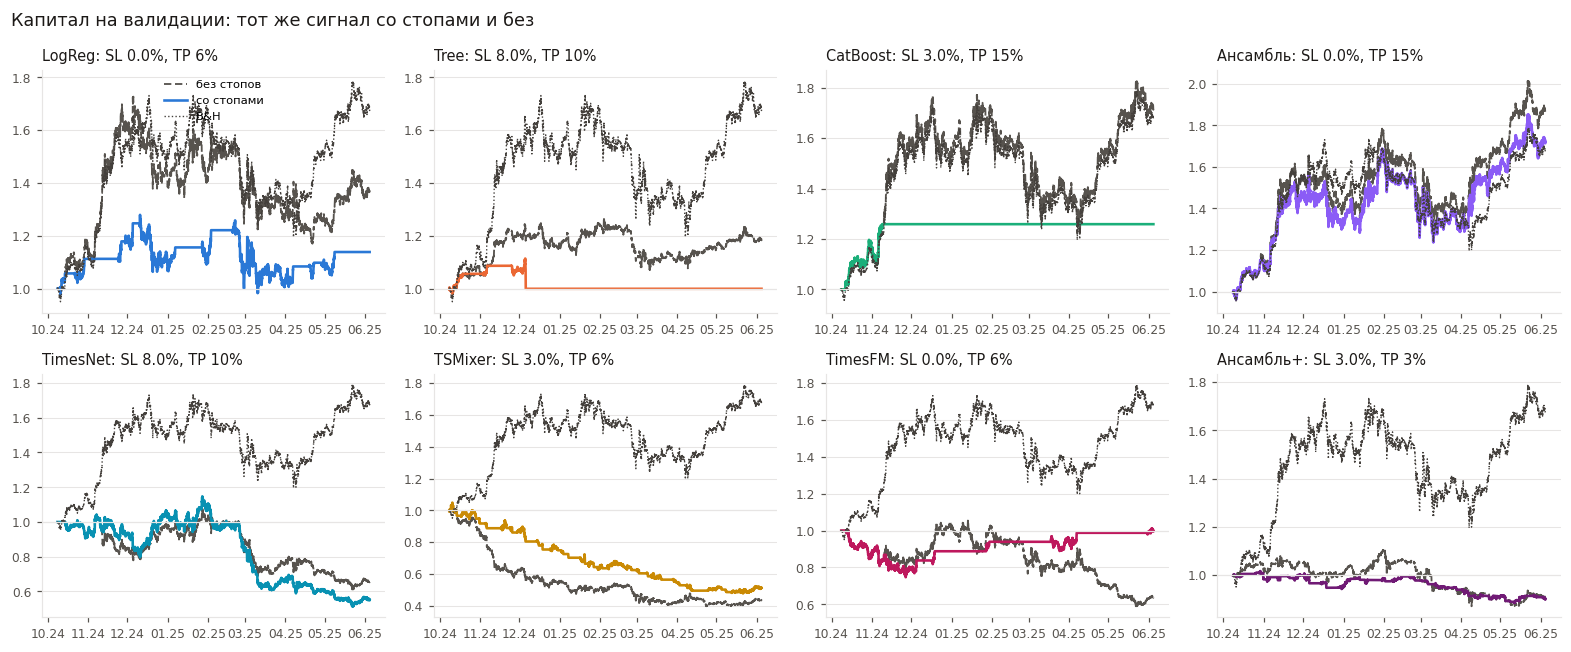

In [62]:
# Что дали правила выхода: тот же сигнал со стопами и без них, плюс исходный ноутбук.
LAYER_MODELS = list(final_models) + ["Ensemble"] + SEQ_MODELS
# Валидация исходного final_ensenble.ipynb (раздел 18, слой без правил выхода):
# net, Sharpe, max drawdown, число сделок.
ORIGINAL_VAL = {
    "LogisticRegression": (-0.0006, 0.2573, -0.3872, 92),
    "DecisionTree": (-0.0140, 0.2169, -0.3732, 100),
    "CatBoost": (0.8405, 2.0596, -0.3098, 2),
    "Ensemble": (-0.1511, -0.2239, -0.4067, 86),
    "TimesNet": (-0.2772, -0.7090, -0.4249, 52),
    "TSMixer": (-0.6409, -2.7542, -0.6556, 296),
    "TimesFM": (0.0732, 0.5245, -0.1805, 64),
    "EnsembleAll": (-0.0469, 0.1161, -0.3108, 201),
}
ORIGINAL_BH = (0.6781, 1.7870, -0.3098, 1)

val_off = {}
sltp_rows = []
for name in LAYER_MODELS:
    prm = signal_by_model[name]
    val_off[name] = backtest(val_dates, val_fwd, val_positions[name])      # стопы выключены
    m_off = val_off[name][1]
    m_on = val_comparison.loc[name]
    o = ORIGINAL_VAL[name]
    sltp_rows.append({
        "стратегия": name,
        "сигнал": f"{prm['mode']}" + (f" q={prm['q']}" if "q" in prm else "")
                  + f" span={prm['span']} reb={prm['rebalance']}",
        "SL": prm["sl"], "TP": prm["tp"], "пауза": cooldown_label(prm["cooldown"])
        if prm["sl"] > 0 or prm["tp"] > 0 else "—",
        "net: исходный": o[0], "net: без стопов": m_off["total_return"],
        "net: со стопами": m_on["total_return"],
        "Sharpe: исходный": o[1], "Sharpe: без стопов": m_off["sharpe"],
        "Sharpe: со стопами": m_on["sharpe"],
        "просадка: исходный": o[2], "просадка: со стопами": m_on["max_drawdown"],
        "сделок: исходный": o[3], "сделок: со стопами": int(m_on["n_trades"]),
        "стопов": int(m_on["n_stop_loss"]), "тейков": int(m_on["n_take_profit"]),
    })
sltp_table = pd.DataFrame(sltp_rows).set_index("стратегия")
pd.set_option("display.max_columns", 30)
print(f"Валидация {val_df['date'].min():%d.%m.%Y} — {val_df['date'].max():%d.%m.%Y}; "
      f"buy & hold: net {val_comparison.loc['BuyAndHold', 'total_return']:+.1%}, "
      f"Sharpe {val_comparison.loc['BuyAndHold', 'sharpe']:.2f}")
display(sltp_table.round(4))

d_orig = sltp_table["Sharpe: со стопами"] - sltp_table["Sharpe: исходный"]
d_self = sltp_table["Sharpe: со стопами"] - sltp_table["Sharpe: без стопов"]
with_exits = sltp_table[(sltp_table["SL"] > 0) | (sltp_table["TP"] > 0)].index
print(f"Правила выхода выбраны у {len(with_exits)} стратегий из {len(sltp_table)}: "
      f"{', '.join(SHORT[n] for n in with_exits) or '—'}")
print(f"Sharpe лучше исходного ноутбука: у {(d_orig > 0).sum()} из {len(d_orig)} "
      f"(медиана разницы {d_orig.median():+.2f})")
if len(with_exits):
    print(f"Sharpe со стопами лучше, чем тот же сигнал без стопов: у {(d_self[with_exits] > 0).sum()} "
          f"из {len(with_exits)} (медиана {d_self[with_exits].median():+.2f})")
print(f"Net выше buy & hold: у {(sltp_table['net: со стопами'] > val_comparison.loc['BuyAndHold', 'total_return']).sum()} "
      f"стратегий; в исходном ноутбуке — у "
      f"{(sltp_table['net: исходный'] > ORIGINAL_BH[0]).sum()}")

if len(with_exits):
    n_ = len(with_exits)
    ncol = min(n_, 4)
    nrow = int(np.ceil(n_ / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.6 * ncol, 3.0 * nrow), squeeze=False)
    for ax, name in zip(axes.ravel(), with_exits):
        c_on, c_off = val_curves[name], val_off[name][0]
        ax.plot(c_off["date"], c_off["equity"], color=INK_MUTED, linewidth=1.2,
                linestyle=(0, (4, 2)), label="без стопов")
        ax.plot(c_on["date"], c_on["equity"], color=COLORS[name], linewidth=1.7, label="со стопами")
        ax.plot(val_curves["BuyAndHold"]["date"], val_curves["BuyAndHold"]["equity"],
                color=COLORS["BuyAndHold"], linewidth=0.9, linestyle=":", label="B&H")
        ax.axhline(1.0, color=GRID, linewidth=0.8)
        p = signal_by_model[name]
        ax.set_title(f"{SHORT[name]}: SL {p['sl']:.1%}, TP {p['tp']:.0%}", color=INK,
                     fontsize=9.5, loc="left")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%m.%y"))
        style_ax(ax)
    for ax in axes.ravel()[n_:]:
        ax.set_visible(False)
    axes[0, 0].legend(frameon=False, fontsize=7.5)
    fig.suptitle("Капитал на валидации: тот же сигнал со стопами и без", x=0.01, ha="left",
                 fontsize=11.5, color=INK)
    fig.tight_layout()
    plt.show()

,Spearman dev↔val по 49 вариантам,val Sharpe без стопов,val Sharpe выбранных стопов,лучший val Sharpe по сетке (задним числом),доля вариантов лучше «без стопов» на val,то же на dev
стратегия,,,,,,
CatBoost,0.575,1.859,2.358,2.511,0.265,0.286
Ensemble,0.328,2.102,1.862,2.921,0.082,0.020
EnsembleAll,0.033,-0.525,-1.432,-0.343,0.041,0.673
TimesFM,0.296,-1.077,0.123,0.944,0.633,0.571


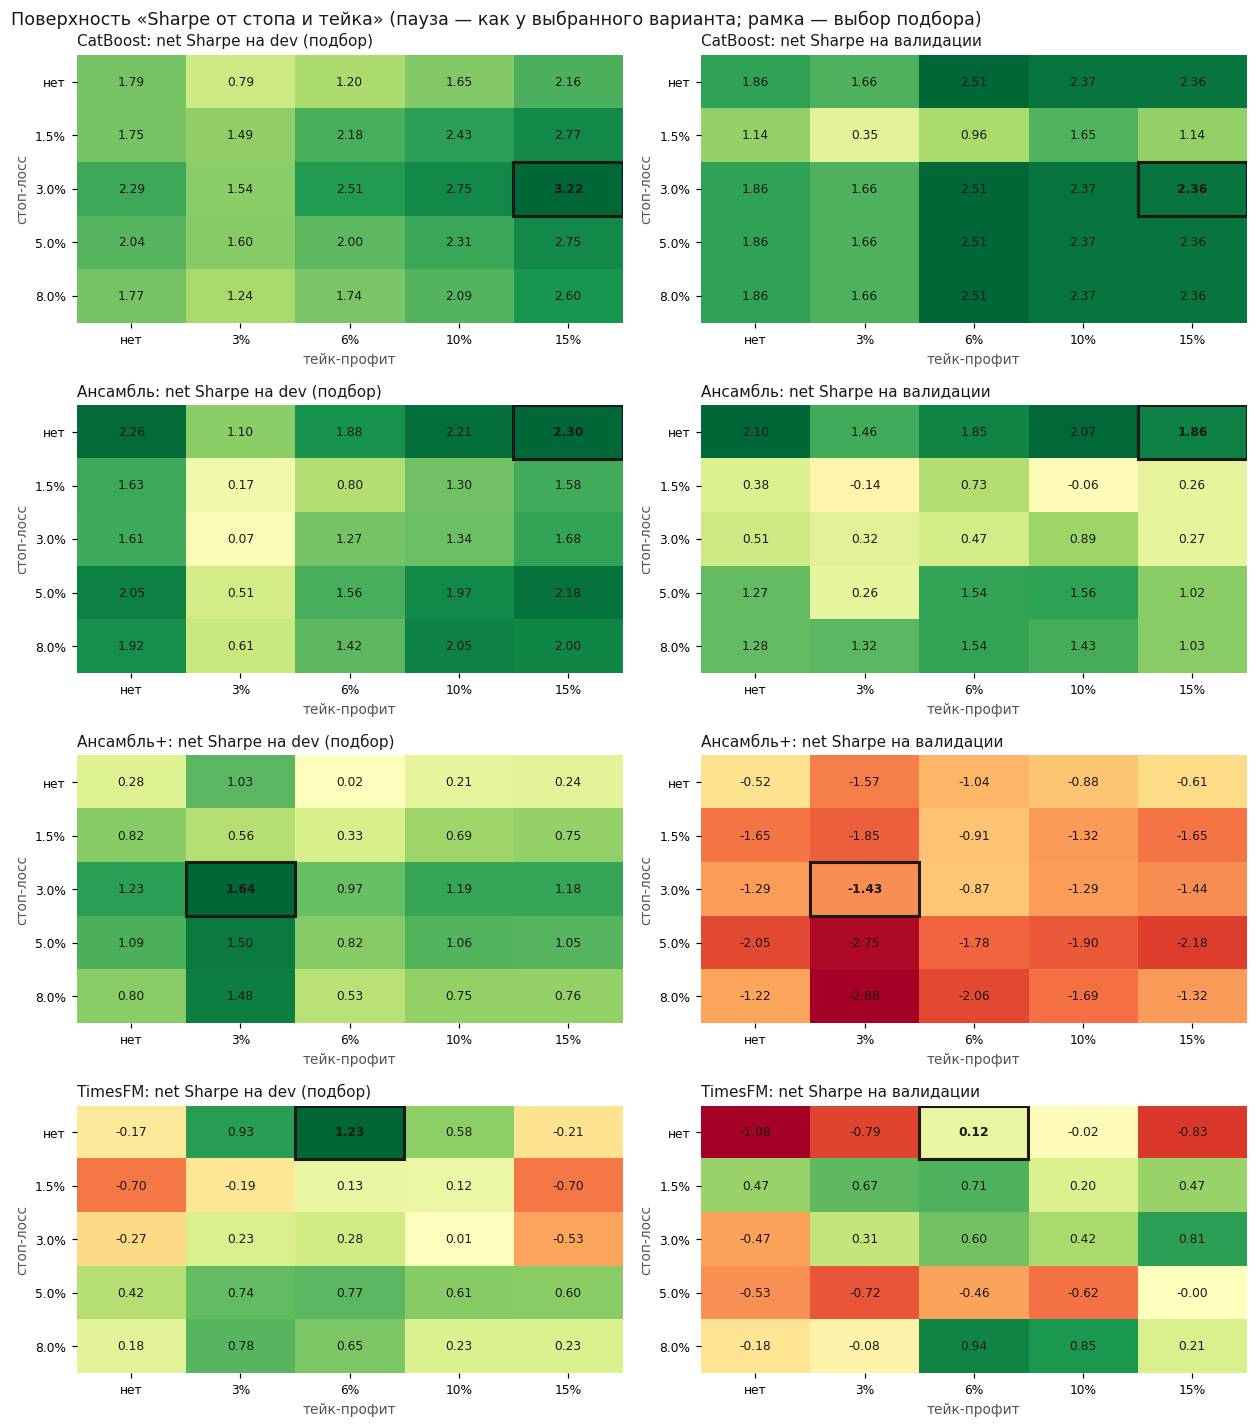

In [63]:
# Переносится ли подбор стопов с dev на валидацию: вся сетка SL × TP для нескольких стратегий.
# Это ДИАГНОСТИКА, а не отбор: валидация по-прежнему не выбирает параметры, а показывает,
# насколько поверхность «Sharpe от стопов» на dev похожа на поверхность на новых данных.
SURF_MODELS = ["CatBoost", "Ensemble", "EnsembleAll", "TimesFM"]
surf_rows = []
for name in SURF_MODELS:
    o_, m_ = dev_oof[name]
    base = {k: v for k, v in signal_by_model[name].items() if k not in ("sl", "tp", "cooldown")}
    for ex in EXIT_GRID:
        _, m_dev = oof_signal_backtest(o_[m_], dates_dev.to_numpy()[m_], fwd_dev.to_numpy()[m_],
                                       DEV_FOLDS[m_], {**base, **ex})
        _, m_val = backtest(val_dates, val_fwd, val_positions[name], sltp=ex)
        surf_rows.append({"стратегия": name, **ex, "sharpe_dev": m_dev["sharpe"],
                          "sharpe": m_val["sharpe"], "net_val": m_val["total_return"],
                          "mdd_val": m_val["max_drawdown"]})
surf_all = pd.DataFrame(surf_rows)

corr_rows = []
for name, g in surf_all.groupby("стратегия", sort=False):
    off = g[(g["sl"] == 0) & (g["tp"] == 0)].iloc[0]
    corr_rows.append({"стратегия": name,
                      "Spearman dev↔val по 49 вариантам": stats.spearmanr(g["sharpe_dev"], g["sharpe"])[0],
                      "val Sharpe без стопов": off["sharpe"],
                      "val Sharpe выбранных стопов": val_comparison.loc[name, "sharpe"],
                      "лучший val Sharpe по сетке (задним числом)": g["sharpe"].max(),
                      "доля вариантов лучше «без стопов» на val": (g["sharpe"] > off["sharpe"]).mean(),
                      "то же на dev": (g["sharpe_dev"] > off["sharpe_dev"]).mean()})
display(pd.DataFrame(corr_rows).set_index("стратегия").round(3))

fig, axes = plt.subplots(len(SURF_MODELS), 2, figsize=(11.5, 3.3 * len(SURF_MODELS)))
for row, name in zip(axes, SURF_MODELS):
    prm = signal_by_model[name]
    cd = prm["cooldown"] if (prm["sl"] > 0 or prm["tp"] > 0) else -1
    g = surf_all[surf_all["стратегия"] == name]
    plot_exit_heatmap(row[0], g.assign(sharpe=g["sharpe_dev"]), cd, chosen=prm,
                      title=f"{SHORT[name]}: net Sharpe на dev (подбор)")
    plot_exit_heatmap(row[1], g, cd, chosen=prm,
                      title=f"{SHORT[name]}: net Sharpe на валидации")
fig.suptitle("Поверхность «Sharpe от стопа и тейка» (пауза — как у выбранного варианта; "
             "рамка — выбор подбора)", x=0.01, ha="left", fontsize=11.5, color=INK)
fig.tight_layout()
plt.show()

**Вывод по валидации: стопы снизили риск, но не дали устойчивого прироста доходности.**

- **Против исходного ноутбука.** Sharpe выше у 3 стратегий из 8: LogReg 0.26 → 0.73, CatBoost
  2.06 → 2.36, ансамбль −0.22 → **1.86**. Net выше у 4: ансамбль −15.1% → **+71.8%**, LogReg
  −0.1% → +13.9%, TSMixer −64.1% → −48.7%, дерево −1.4% → 0.0%. Максимальная просадка меньше
  у 6 из 8: CatBoost −31.0% → −8.3%, дерево −37.3% → −10.3%, ансамбль+ −31.1% → −12.8%,
  ансамбль −40.7% → −26.7%.
- **Ансамбль трёх табличных моделей со стопами — единственная активно торгующая
  supervised-стратегия, которая обогнала рынок.** 38 сделок, net +71.8% против +67.8% у
  buy & hold, Sharpe 1.86 против 1.79, просадка −26.7% против −31.0%. В исходном ноутбуке
  рынок обгонял только CatBoost с двумя сменами позиции.
- **Цена — упущенный рост.** Net CatBoost упал с +84.1% до +25.9%. Тейк 15% закрыл лонг, и
  без паузы-возврата стратегия ждала противоположного сигнала: в рынке всего 12% времени.
  На растущем окне тейк-профит срезает именно ту сделку, которая зарабатывает.
- **Сами стопы, при тех же сигналах, на валидации скорее мешают.** Столбец «без стопов» —
  те же модели и сигнал, но выходы выключены. Sharpe со стопами лучше только у 2 из 8
  (CatBoost 1.86 → 2.36, TimesFM −1.08 → 0.12), медиана −0.54. Значит, улучшение против
  исходного ноутбука в основном даёт переобучение моделей и сигнала под новую целевую
  функцию, а не исполнение стопов.
- **Поверхность «Sharpe от SL × TP» переносится с dev плохо.** Ранговая корреляция dev↔val
  по 49 вариантам: 0.58 у CatBoost, 0.33 у ансамбля, 0.30 у TimesFM, 0.03 у ансамбля+.
  Острые пики на dev-картах — во многом шум.

## 19. Обучение с подкреплением: агенты на FinRL

Все стратегии до этого места устроены одинаково. Модель оценивает вероятность роста, а отдельный
торговый слой (раздел 9) переводит эту вероятность в позицию по фиксированному правилу, параметры
которого подобраны перебором по сетке. Два решения — «куда пойдёт цена» и «какую долю капитала под
это поставить» — принимаются разными механизмами, и второй знает о первом ровно одно число.

Обучение с подкреплением снимает это разделение. Агент видит состояние рынка и собственную позицию,
действием сразу выбирает новую позицию, а наградой получает величину, связанную с чистой — после
комиссии — доходностью бара: в позиционной среде раздела 19.2/19.3 это `log(1 + net_ret)` — прирост
логарифма капитала за бар, сумма которого по эпизоду равна логарифму отношения конечного капитала к
начальному, а не самому капиталу; в штатной среде FinRL раздела 19.1 — масштабированный денежный
прирост портфеля, что отличается от лог-доходности (раздел 19.1 ниже проговаривает это отдельно).
Агент при этом максимизирует не буквально ту сумму по всему эпизоду: SB3 использует `gamma=0.99`
(дисконтирование), у SAC в целевую функцию добавлена энтропийная составляющая, — то, что оптимизирует
градиент политики, ближе к этой сумме, но не равно ей тождественно. Издержки входят в награду,
поэтому по замыслу агент сам решает, сколько торговать.

**Замысла оказалось мало — частота сделок ограничена явно.** В прошлой версии ноутбука агенты
торговали без ограничений, и комиссия внутри награды оборот не сдержала: FinRL совершал около
тысячи сделок на 5 740 барах валидации и отдавал комиссиям треть капитала, а его gross +36%
превращался в net −1.4%. Градиент политики оценивается по шуму часовых доходностей, и за
десятки тысяч шагов агент не успевает выучить, что частая перекладка убыточна. Поэтому у всех
трёх постановок теперь есть два рычага:

- `every` — агент принимает решение раз в `every` баров, между решениями позиция держится.
  Один шаг агента проводит среду через `every` баров, награды за них суммируются. Это заодно
  облегчает обучение: решений в `every` раз меньше, и каждое оценивается по более длинному и
  менее шумному отрезку;
- `deadband` — изменение позиции меньше `deadband` капитала не исполняется.

Перебираются три варианта: без ограничений (`k=1, δ=0` — прежняя постановка, чтобы было видно,
помогает ли ограничение вообще), решение раз в 6 часов и раз в сутки (оба с `δ = 0.10`). Вариант
выбирается по test вместе с алгоритмом.

Ограничения активности из раздела 14 (`MIN_TURNOVER_PER_YEAR`, `MIN_AVG_EXPOSURE`) здесь
по-прежнему не нужны: они ограничивают оборот снизу и удерживали перебор торгового слоя от
вырожденного «не торговать вовсе». У агента бездействие даёт ровно нулевую награду за бар, а не
наказание — это ДОПУСТИМЫЙ исход. Если ожидаемая награда от торговли отрицательна, не торговать
может быть оптимальной политикой. Сработал ли замысел — вопрос раздела 19.4.

**Чего здесь ждать не стоит.** RL в трейдинге сталкивается сразу с четырьмя неприятностями, и о них
честнее сказать заранее, чем потом объяснять результат.

1. *Награда почти вся — шум.* Отношение сигнала к шуму на часовом баре порядка 0.01: доходность бара
   на два порядка больше своего предсказуемого компонента. Градиент политики оценивается по этому
   шуму, и ему нужны десятки тысяч шагов, чтобы отличить решение от везения.
2. *История одна.* Обычный RL учится на миллионах эпизодов, потому что среду можно перезапускать.
   Рынок нельзя: у нас один проход длиной 32 тысячи баров (dev), и любой повторный проход по нему —
   это повторное обучение на тех же данных.
3. *Ёмкости хватает, чтобы запомнить траекторию.* Агент с MLP-политикой на своём обучающем участке
   почти всегда показывает прекрасный Sharpe. Это ничего не говорит о будущем, поэтому ниже везде
   рядом стоят две цифры: на обучающем участке и на том, которого агент не видел. Забегая вперёд:
   у off-policy алгоритмов раздела 19.1 без ограничения частоты так и вышло (SAC: train +2.18,
   test −3.92), а финальный агент FinRL (TD3) даёт на своём `dev` net +2235% и на валидации −2.4%
   (раздел 19.4).
4. *Разброс по сидам сопоставим с разбросом по алгоритмам.* Одиночный запуск сообщает больше об
   инициализации, чем о методе, — поэтому каждый агент обучается на трёх сидах, а позиции
   усредняются. Это тот же приём, что усреднение вероятностей в разделе 16, только в пространстве
   позиций.

**Три постановки.**

- **19.1 — FinRL как есть.** Штатная `StockTradingEnv` на одном инструменте, пять алгоритмов
  Stable-Baselines3 через обёртку `DRLAgent`. Это буквальное прочтение задания: агент работает
  с денежным счётом, целыми «акциями» и комиссией, как в примерах фреймворка.
- **19.2 — позиционная среда.** Собственная `gymnasium`-среда, где действие — сразу доля капитала
  от −1 до +1, а награда — логарифм чистой доходности бара. Нужна затем, что штатная среда FinRL не
  умеет шортить и считает целые лоты, а весь остальной ноутбук говорит в терминах доли капитала.
- **19.3 — RL на вершине ансамбля.** Мета-агент, который не смотрит на рынок напрямую: его
  наблюдение — прогнозы всех шести моделей разделов 16 и 17, их согласие между собой, две
  характеристики состояния рынка и собственная позиция. Он заменяет собой и усреднение вероятностей, и торговый слой.

**Протокол.** Тот же, что у остальных моделей ноутбука, и здесь он важнее обычного. Алгоритм и
ограничение частоты сделок выбираются по `test` — участку, которого агент при обучении не видел;
победитель переобучается на всём `dev`; валидация используется ровно один раз, в конце. Комиссия, бэктест и метрики — те же
самые функции, что у всех предыдущих стратегий, так что цифры сравнимы напрямую.

In [64]:
# RL-стек: gymnasium задаёт интерфейс среды, Stable-Baselines3 даёт реализации алгоритмов,
# FinRL — финансовую обвязку над ними: готовую среду торговли и обёртку DRLAgent.
import random

import gymnasium as gym
from gymnasium import spaces
import matplotlib
import stable_baselines3
from stable_baselines3 import A2C, DDPG, PPO, SAC, TD3

# FinRL на уровне модуля выполняет matplotlib.use("Agg") — после его импорта все графики
# ноутбука перестали бы отрисовываться в ячейках. Backend запоминается до импорта и
# возвращается после; на работу самого FinRL это не влияет, он рисует только в файлы.
_mpl_backend = matplotlib.get_backend()
import finrl
from finrl.agents.stablebaselines3.models import DRLAgent
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
matplotlib.use(_mpl_backend)

print(f"gymnasium {gym.__version__} | stable-baselines3 {stable_baselines3.__version__} | "
      f"FinRL {getattr(finrl, '__version__', '0.3.7')} | backend matplotlib "
      f"{matplotlib.get_backend()}")

# Бюджеты обучения. On-policy (A2C, PPO) собирают дешёвые роллауты и требуют много шагов;
# off-policy (DDPG, TD3, SAC) делают градиентный шаг на каждом шаге среды и при равном числе
# шагов стоят на порядок дороже по времени. Уравнивать их по шагам нечестно, по времени — тоже.
# RL_STEPS_OFF поднят с 15 000 до значения, гарантирующего хотя бы один полный проход по
# train (len(train_df) ≈ 26 664): иначе StockTradingEnv с фиксированным стартом в начале ряда
# не показала бы off-policy агентам вторую половину train вовсе, а train Sharpe в таблице
# отбора измерялся бы на смеси виденного и невиденного периода (codex_report.md, пункт 11).
RL_STEPS_ON = 60_000
RL_STEPS_OFF = 30_000
RL_STEPS = {"a2c": RL_STEPS_ON, "ppo": RL_STEPS_ON,
            "ddpg": RL_STEPS_OFF, "td3": RL_STEPS_OFF, "sac": RL_STEPS_OFF}
RL_ALGOS = ("a2c", "ppo", "ddpg", "td3", "sac")
RL_SEEDS = (0, 1, 2)          # RL чувствителен к сиду — везде усредняем по трём запускам
RL_EPISODE_LEN = 2048         # длина обучающего эпизода, баров (~3 месяца часовых данных)
RL_N_FEATURES = 24            # сколько признаков уходит в наблюдение агента
RL_INITIAL_CASH = 1e8         # стартовый капитал среды FinRL, «долларов»
RL_HMAX = 4000                # максимум «акций» BTC за шаг: хватает на полный вход за один ход

# Ограничение частоты сделок. Комиссия внутри награды сама по себе оборот не сдерживает: в
# постановке без ограничений агент FinRL совершал около тысячи сделок на 5 740 барах валидации и
# отдавал комиссиям треть капитала, а шумный градиент политики так и не «выучил», что частая
# перекладка убыточна. Поэтому у всех трёх RL-постановок есть два рычага:
#   every    — агент принимает решение раз в every баров, между решениями позиция держится;
#              один шаг SB3 проводит среду через every баров, награды за них суммируются;
#   deadband — изменение позиции меньше deadband капитала не исполняется.
# Вариант выбирается по test вместе с алгоритмом; строка every=1, deadband=0 — прежняя постановка
# без ограничений, чтобы было видно, помогает ли ограничение вообще. RL_STEPS считаются в
# решениях агента, поэтому при every=k агент за тот же бюджет проходит в k раз больше баров.
RL_FREQ_GRID = (
    {"every": 1, "deadband": 0.0},
    {"every": 6, "deadband": 0.10},
    {"every": 24, "deadband": 0.10},
)
NO_FREQ_LIMIT = RL_FREQ_GRID[0]


def freq_label(freq):
    """Короткая подпись варианта ограничения частоты для таблиц."""
    return f"k={freq['every']}, δ={freq['deadband']:.2f}"

# Гиперпараметры: дефолты FinRL (finrl.config) с поправкой на часовой ряд — шагов в среде у нас
# на два порядка больше, чем в дневных задачах, под которые эти дефолты писались.
# device="cpu": политики здесь — крошечные MLP, на GPU они медленнее из-за накладных расходов
# на каждый вызов predict, а вызовов при прогоне по 40 тысячам баров десятки тысяч.
RL_KWARGS = {
    "a2c": {"n_steps": 16, "ent_coef": 0.005, "learning_rate": 7e-4, "device": "cpu"},
    "ppo": {"n_steps": 1024, "batch_size": 128, "ent_coef": 0.005, "learning_rate": 3e-4,
            "device": "cpu"},
    "ddpg": {"batch_size": 128, "buffer_size": 50_000, "learning_rate": 1e-3, "device": "cpu"},
    "td3": {"batch_size": 128, "buffer_size": 50_000, "learning_rate": 1e-3, "device": "cpu"},
    "sac": {"batch_size": 128, "buffer_size": 50_000, "learning_rate": 3e-4,
            "learning_starts": 500, "ent_coef": "auto_0.1", "device": "cpu"},
}
SB3_CLS = {"a2c": A2C, "ppo": PPO, "ddpg": DDPG, "td3": TD3, "sac": SAC}


def set_rl_seed(seed):
    """Единый сид для random, numpy и torch."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def rl_obs_matrix(part, features, bounds, mu, sd):
    """Наблюдение агента: винзоризация по переданным границам, z-оценка, клип хвостов."""
    z = (apply_winsor(part[features], bounds) - mu) / sd
    return np.clip(z.to_numpy(dtype=np.float32), -5.0, 5.0)


def _rl_feature_pack(fit_model, fit_df, k=RL_N_FEATURES):
    """Топ-k признаков по важности fit_model + границы/статистики винзоризации по fit_df."""
    imp = pd.Series(fit_model.get_feature_importance(), index=MODEL_COLS)
    features = list(imp.sort_values(ascending=False).head(k).index)
    bounds = winsor_bounds(fit_df[features])
    w = apply_winsor(fit_df[features], bounds)
    mu, sd = w.mean(), w.std().replace(0.0, 1.0)
    return features, bounds, mu, sd


# Признаки для агента: топ по важности CatBoost. Весь MODEL_COLS в наблюдение не кладётся —
# политика-MLP за несколько десятков тысяч шагов не успевает разобраться в сотне входов, а
# лишняя ось наблюдения стоит RL дороже, чем градиентному бустингу лишний признак.
#
# Утечка train -> test (codex_report.md, пункт 3): RL_FEATURES выбирались по важности
# final_models["CatBoost"], а этот CatBoost обучен на ВСЁМ dev (train+test) — значит выбор
# признаков для «честной» проверки train -> test уже видел test-метки. Ниже заведены ДВА
# набора препроцессинга:
#   фаза 1 (train -> test, cells 106/110) — отбор и нормировка ТОЛЬКО по train_df, через
#           отдельный быстрый CatBoost, обученный только на train_df;
#   фаза 2 (dev -> валидация, cells 107/111 и далее) — отбор и нормировка по всему dev,
#           что для финального обучения допустимо: validation в этом вообще не участвует.
_rl_model_tr = make_catboost(**CB_FIXED)
_rl_model_tr.fit(train_df[MODEL_COLS], train_df["target"],
                 sample_weight=sample_weights(train_df, np.arange(len(train_df)), w_outlier=True))
RL_FEATURES_TR, rl_bounds_tr, rl_mu_tr, rl_sd_tr = _rl_feature_pack(_rl_model_tr, train_df)
rl_obs_tr = {"train": rl_obs_matrix(train_df, RL_FEATURES_TR, rl_bounds_tr, rl_mu_tr, rl_sd_tr),
             "test": rl_obs_matrix(test_df, RL_FEATURES_TR, rl_bounds_tr, rl_mu_tr, rl_sd_tr)}

RL_FEATURES, rl_bounds, rl_mu, rl_sd = _rl_feature_pack(final_models["CatBoost"], dev_df)

rl_parts = {"train": train_df, "test": test_df, "dev": dev_df, "val": val_df}
rl_obs = {k: rl_obs_matrix(v, RL_FEATURES, rl_bounds, rl_mu, rl_sd) for k, v in rl_parts.items()}

print(f"Наблюдение агента (финальная фаза, по dev): {len(RL_FEATURES)} признаков + позиция.")
print("Топ-8 по важности CatBoost (dev): " + ", ".join(RL_FEATURES[:8]))
print(f"Фаза честной проверки train -> test использует отдельный набор из "
      f"{len(RL_FEATURES_TR)} признаков, выбранный и нормированный только по train_df: "
      + ", ".join(RL_FEATURES_TR[:8]))
print("Выборки для RL: " + ", ".join(f"{k} {len(v)} баров" for k, v in rl_parts.items()))


gymnasium 1.2.1 | stable-baselines3 2.7.0 | FinRL 0.3.7 | backend matplotlib inline


Наблюдение агента (финальная фаза, по dev): 18 признаков + позиция.
Топ-8 по важности CatBoost (dev): lower_frac, news_count_168, ret_lag_1, wl_e_d4, clv, sma5_slope, shadow_imbalance, donchian_pos_55
Фаза честной проверки train -> test использует отдельный набор из 18 признаков, выбранный и нормированный только по train_df: clv, ret_lag_1, cwt_e_72p, ret_2_atr, wl_e_d4, ret_3, news_count_168, donchian_pos_55
Выборки для RL: train 26782 баров, test 5738 баров, dev 32521 баров, val 5740 баров


### 19.1 FinRL «как есть»: StockTradingEnv и DRLAgent

FinRL — это не алгоритмы, а обвязка вокруг них. Сами PPO, A2C, DDPG, TD3 и SAC берутся из
Stable-Baselines3; FinRL добавляет к ним финансовую среду (`StockTradingEnv`), единый интерфейс
запуска (`DRLAgent.get_model` / `train_model` / `DRL_prediction`) и набор дефолтных
гиперпараметров в `finrl.config`. Этот раздел пользуется всем этим напрямую.

**Как устроена штатная среда.** Состояние — список `[кэш, цена, число акций, индикаторы...]`.
Действие — одно число в [−1, 1], умножаемое на `hmax` и округляемое до целого: столько «акций»
агент покупает (плюс) или продаёт (минус). Продать больше, чем есть, среда не даёт, поэтому
**позиция по построению лежит в [0, 1] — шорта нет**. Комиссия берётся с каждой стороны и равна
той же `FEE_RATE = 0.1%`, что во всех бэктестах ноутбука. Награда — прирост стоимости портфеля
за бар, умноженный на `reward_scaling`.

**Две поправки, без которых среда на наших данных не работает.** Обе выписаны в комментариях к
коду: нормировка наблюдения (FinRL кладёт в состояние сырые доллары, сырую цену BTC и сырые
индикаторы — разброс масштабов в пять порядков, MlpPolicy на таком входе не обучается) и обход
особенности реализации, из-за которой первый технический индикатор среда сравнивает с единицей.
Бухгалтерия среды при этом не меняется: позиции, комиссии и стоимость портфеля по-прежнему считает
сам FinRL, обёртка трогает только то, что видит нейросеть.

**Ограничение частоты сделок** встроено в ту же обёртку: при `every = k` один шаг агента
проводит среду FinRL через k баров (сделка — только на первом, дальше действие 0, то есть
«держать»), а сделка меньше `deadband` капитала обнуляется. Комиссии и стоимость портфеля
по-прежнему считает FinRL.

**Что сравнивается.** Пять алгоритмов × три варианта ограничения частоты при одинаковом
протоколе — 15 обучений. Бюджеты обучения разные:
on-policy методы (A2C, PPO) собирают дешёвые роллауты и требуют много шагов, off-policy (DDPG,
TD3, SAC) делают градиентный шаг на каждом шаге среды и при равном числе шагов стоят на порядок
дороже по времени. Уравнивать бюджеты по шагам было бы нечестно, по времени — тоже; выбран
компромисс по времени: одно обучение занимает от 2–5 минут без ограничения частоты до 20–30
минут при `every = 24` (каждый шаг агента — это 24 шага среды FinRL), весь раздел — около 3.5 часа.

In [65]:
# Среда FinRL как есть: StockTradingEnv на одном инструменте BTC/USDT.
#
# Две технические поправки, без которых штатная среда на наших данных не работает.
#
# 1. Наблюдение. FinRL кладёт в состояние сырые величины: остаток кэша (у нас 1e8), цену BTC
#    (десятки тысяч) и сырые индикаторы. Разброс масштабов в пять порядков — MlpPolicy на таком
#    входе не обучается. Обёртка ниже НЕ трогает бухгалтерию среды (позиции, комиссии и стоимость
#    портфеля по-прежнему считает сам FinRL), а только переводит наблюдение в сопоставимые
#    единицы: доля кэша, z-оценка лог-цены, доля капитала в позиции, z-оценки индикаторов.
#
# 2. Особенность реализации FinRL: перед сделкой среда проверяет `state[3] != True`, то есть
#    сравнивает ПЕРВЫЙ технический индикатор с единицей (в исходном коде это задумывалось как
#    флаг «инструмент не торгуется»). Если первый индикатор на каком-то баре в точности равен
#    1.0, среда молча запрещает сделку на этом баре. Поэтому в df кладутся уже z-оценки, а первым
#    ставится признак, ни на одном баре соответствующей фазы не равный единице ровно.
#
# Всё ниже параметризовано по (признаки, наблюдение, price_mu/sd) явно, а не через глобальные
# RL_FEATURES/rl_obs — так у «честной» фазы train -> test и финальной фазы dev -> val заведомо
# не может быть общих статистик (см. правку утечки в предыдущей ячейке).


def _make_rl_tech(features, obs_arrays):
    """Список технических колонок для StockTradingEnv; первой ставится колонка, ни на одном
    баре переданных наблюдений не равная ровно 1.0 (обход особенности реализации FinRL, см. выше)."""
    tech = list(features)
    safe_first = [c for i, c in enumerate(tech)
                  if not any((obs[:, i] == 1.0).any() for obs in obs_arrays)]
    if safe_first:
        tech = [safe_first[0]] + [c for c in tech if c != safe_first[0]]
    return tech


def finrl_frame(part_df, features, obs_matrix, tech):
    """Данные в формате FinRL: (date, tic, close, индикаторы), индекс — номер бара."""
    z = pd.DataFrame(obs_matrix, columns=features)[tech].copy()
    first = tech[0]                                     # страховка к пункту 2 выше
    z[first] = z[first].where(z[first] != 1.0, np.float32(1.0 + 1e-5))
    d = pd.concat([part_df[["date", "close"]].reset_index(drop=True), z], axis=1)
    d["tic"] = "BTCUSDT"
    d.index = d["date"].factorize()[0]          # FinRL адресует бары через df.loc[day]
    return d


class ScaledStockTradingEnv(StockTradingEnv):
    """StockTradingEnv из FinRL с нормированным наблюдением и ограничением частоты сделок.

    every    — один шаг агента проводит среду FinRL через every баров: сделка (если есть) — только
               на первом, дальше действие 0 (держать); награды за эти бары суммируются;
    deadband — сделка меньше deadband капитала не исполняется (действие обнуляется).
    Бухгалтерию (позиции, комиссии, стоимость портфеля) по-прежнему ведёт сам FinRL. Доля
    капитала в позиции записывается на КАЖДОМ баре в bar_positions — по цене в момент решения:
    после шага среда уже переоценила портфель по цене следующего бара.
    """

    def __init__(self, *args, price_mu=0.0, price_sd=1.0, every=1, deadband=0.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.price_mu, self.price_sd = float(price_mu), float(price_sd)
        self.every, self.deadband = max(int(every), 1), float(deadband)
        self.bar_positions = []

    def _scale(self, state):
        s = np.asarray(state, dtype=np.float64)
        cash, price, shares = s[0], s[1], s[2]
        total = cash + price * shares
        obs = np.empty(len(s), dtype=np.float32)
        obs[0] = cash / total if total > 0 else 1.0                  # доля кэша
        obs[1] = (np.log(max(price, 1e-9)) - self.price_mu) / self.price_sd
        obs[2] = price * shares / total if total > 0 else 0.0        # доля капитала в позиции
        obs[3:] = np.clip(s[3:], -5.0, 5.0)                          # индикаторы уже z-оценки
        return obs

    def reset(self, **kwargs):
        state, info = super().reset(**kwargs)
        self.bar_positions = []
        return self._scale(state), info

    def step(self, actions):
        a = np.asarray(actions, dtype=np.float32).reshape(-1).copy()
        cash, price, shares = (float(x) for x in self.state[:3])
        total = cash + price * shares
        # FinRL торгует int(action * hmax) лотами — размер сделки в долях капитала
        trade_frac = abs(int(a[0] * self.hmax)) * price / total if total > 0 else 0.0
        if trade_frac < self.deadband:
            a[:] = 0.0
        reward_sum = 0.0
        for i in range(self.every):
            price_now = float(self.state[1])
            state, reward, terminated, truncated, info = super().step(
                a if i == 0 else np.zeros_like(a))
            if (terminated or truncated) and i > 0:
                # терминальный шаг FinRL возвращает награду предыдущего бара повторно — внутри
                # составного шага её не добавляем, чтобы не посчитать бар дважды
                break
            reward_sum += float(reward)
            if terminated or truncated:
                break
            cash_now, shares_now = float(self.state[0]), float(self.state[2])
            total_now = cash_now + shares_now * price_now
            self.bar_positions.append(shares_now * price_now / total_now if total_now > 0 else 0.0)
        return self._scale(state), reward_sum, terminated, truncated, info


def make_finrl_env(part_df, features, obs_matrix, tech, price_mu, price_sd, freq=NO_FREQ_LIMIT):
    """Готовая среда FinRL на выбранной выборке; комиссия — та же FEE_RATE, что в бэктесте."""
    return ScaledStockTradingEnv(
        df=finrl_frame(part_df, features, obs_matrix, tech), stock_dim=1, hmax=RL_HMAX,
        initial_amount=RL_INITIAL_CASH, num_stock_shares=[0],
        buy_cost_pct=[FEE_RATE], sell_cost_pct=[FEE_RATE], reward_scaling=1e-4,
        state_space=1 + 2 * 1 + len(tech), action_space=1,
        tech_indicator_list=tech, turbulence_threshold=None,
        print_verbosity=10 ** 9, price_mu=price_mu, price_sd=price_sd,
        every=freq["every"], deadband=freq["deadband"])


def finrl_positions(model, part_df, features, obs_matrix, tech, price_mu, price_sd,
                    freq=NO_FREQ_LIMIT):
    """Прогон обученной политики по среде FinRL с записью доли капитала в позиции на каждом баре.

    Возвращает N-1 позиций для N цен: решение (или удержание между решениями) приходится на
    каждый из первых N-1 баров, а последний вызов step() у StockTradingEnv на баре N-1 сразу
    терминальный, без новой сделки. Пропущенное решение не дописывается повтором последней
    позиции — `finrl_backtest` ниже считает метрики на этих честных N-1 переходах.
    """
    env = make_finrl_env(part_df, features, obs_matrix, tech, price_mu, price_sd, freq)
    obs, _ = env.reset()
    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = env.step(action)
        if terminated or truncated:
            break
    return np.asarray(env.bar_positions, dtype=float), env


def finrl_positions_padded(model, part_df, features, obs_matrix, tech, price_mu, price_sd,
                           freq=NO_FREQ_LIMIT):
    """Позиции, дополненные повтором последней — ТОЛЬКО для совместимости с общими графиками и
    сводками, где нужен массив длины N (дашборд, чувствительность к комиссии по всем стратегиям
    сразу). Отчётные метрики (Sharpe/net/gross/fee_drag) берутся из `finrl_backtest`, а не из
    бэктеста этого дополненного массива."""
    pos, _ = finrl_positions(model, part_df, features, obs_matrix, tech, price_mu, price_sd, freq)
    n_need = len(part_df)
    if len(pos) < n_need:
        pos = np.concatenate([pos, np.repeat(pos[-1:], n_need - len(pos))])
    return pos[:n_need]


def finrl_backtest(model, part_df, features, obs_matrix, tech, price_mu, price_sd,
                   freq=NO_FREQ_LIMIT, fee_rate=FEE_RATE, verbose_native=False):
    """Честные метрики FinRL: общий backtest() на реальных N-1 переходах агента (без
    доигрывания последнего бара). Дополнительно, если verbose_native — печатает нативные
    цифры среды (asset_memory, cost, trades): фактические деньги и комиссии, которыми FinRL
    ведёт собственный учёт, — рядом с числами общего backtest(), чтобы расхождение между двумя
    моделями учёта (общий бэктест переводит доли в оборот по-своему; FinRL торгует целыми
    лотами и берёт комиссию с фактической сделки) было видно явно, а не подразумевалось как
    точное совпадение (codex_report.md, пункт 6).
    """
    pos, env = finrl_positions(model, part_df, features, obs_matrix, tech, price_mu, price_sd,
                               freq)
    dates_n1 = part_df["date"].to_numpy()[:-1]
    fwd_n1 = part_df["fwd_ret"].to_numpy()[:-1]
    assert len(pos) == len(dates_n1), f"FinRL вернул {len(pos)} позиций на {len(dates_n1)} переходов"
    curve, metrics = backtest(dates_n1, fwd_n1, pos, fee_rate=fee_rate)
    if verbose_native:
        native_net = float(env.asset_memory[-1] / env.asset_memory[0] - 1)
        native_fee_frac = float(env.cost / env.asset_memory[0])
        print(f"    нативный учёт FinRL: net {native_net:+.2%} (общий backtest: "
              f"{metrics['total_return']:+.2%}), уплачено комиссий "
              f"{native_fee_frac:.2%} капитала, сделок (FinRL): {env.trades} — эти пары чисел "
              f"близки, но получены разными моделями учёта долей капитала, совпадение не "
              f"гарантировано на других выборках.")
    return pos, curve, metrics


print(f"Среда FinRL: stock_dim=1, hmax={RL_HMAX}, стартовый капитал {RL_INITIAL_CASH:,.0f}, "
      f"комиссия {FEE_RATE:.2%} с каждой стороны.")
print("Действие — одно число в [-1, 1] (сколько лотов купить/продать). Шорт в этой среде "
      "невозможен: позиция лежит в [0, 1].")
print("Варианты ограничения частоты сделок: " + "; ".join(freq_label(f) for f in RL_FREQ_GRID))


Среда FinRL: stock_dim=1, hmax=4000, стартовый капитал 100,000,000, комиссия 0.10% с каждой стороны.
Действие — одно число в [-1, 1] (сколько лотов купить/продать). Шорт в этой среде невозможен: позиция лежит в [0, 1].
Варианты ограничения частоты сделок: k=1, δ=0.00; k=6, δ=0.10; k=24, δ=0.10


In [66]:
# Пять алгоритмов FinRL/SB3 × варианты ограничения частоты сделок: обучение на train, отбор — по test.
#
# Протокол тот же, что у остальных моделей ноутбука, и здесь он важнее обычного. RL-агент на
# своей обучающей выборке почти всегда показывает прекрасный результат: ёмкости хватает, чтобы
# запомнить конкретную траекторию цены. Поэтому алгоритм и ограничение частоты сделок выбираются
# по test — участку, которого агент при обучении не видел, — а валидация в выборе не участвует.
# Признаки и нормировка здесь — фаза 1 (RL_FEATURES_TR, только train_df), а не dev-широкие
# RL_FEATURES: иначе test уже был бы виден на этапе выбора признаков агента.
RL_TECH_TR = _make_rl_tech(RL_FEATURES_TR, [rl_obs_tr["train"], rl_obs_tr["test"]])
_log_close_train = np.log(train_df["close"].to_numpy())
RL_PRICE_MU_TR, RL_PRICE_SD_TR = float(_log_close_train.mean()), float(_log_close_train.std())
print(f"Фаза train -> test: первым индикатором среды идёт «{RL_TECH_TR[0]}».")

rl_finrl_runs = {}

for algo in RL_ALGOS:
    for freq in RL_FREQ_GRID:
        t_start = time.perf_counter()
        set_rl_seed(RANDOM_STATE)
        env_train, _ = make_finrl_env(train_df, RL_FEATURES_TR, rl_obs_tr["train"], RL_TECH_TR,
                                      RL_PRICE_MU_TR, RL_PRICE_SD_TR, freq).get_sb_env()
        agent = DRLAgent(env=env_train)                          # обёртка FinRL над SB3
        model = agent.get_model(algo, model_kwargs=dict(RL_KWARGS[algo]), verbose=0,
                                seed=RANDOM_STATE)
        model = agent.train_model(model=model, tb_log_name=f"{algo}_k{freq['every']}",
                                  total_timesteps=RL_STEPS[algo])
        _, _, m_train = finrl_backtest(model, train_df, RL_FEATURES_TR, rl_obs_tr["train"],
                                       RL_TECH_TR, RL_PRICE_MU_TR, RL_PRICE_SD_TR, freq)
        _, _, m_test = finrl_backtest(model, test_df, RL_FEATURES_TR, rl_obs_tr["test"],
                                      RL_TECH_TR, RL_PRICE_MU_TR, RL_PRICE_SD_TR, freq)
        key = (algo.upper(), freq_label(freq))
        rl_finrl_runs[key] = {"algo": algo, "freq": freq, "train": m_train, "test": m_test,
                              "мин": (time.perf_counter() - t_start) / 60}
        del model, agent, env_train
        print(f"  {algo.upper():5s} {freq_label(freq):13s} {RL_STEPS[algo]:6d} шагов за "
              f"{rl_finrl_runs[key]['мин']:4.1f} мин | train Sharpe {m_train['sharpe']:+.2f} | "
              f"test Sharpe {m_test['sharpe']:+.2f} | test net {m_test['total_return']:+.1%} | "
              f"сделок {m_test['n_trades']} | экспозиция {m_test['avg_abs_position']:.2f}",
              flush=True)

finrl_table = pd.DataFrame({
    key: {"train Sharpe": r["train"]["sharpe"],
          "test Sharpe": r["test"]["sharpe"],
          "test net": r["test"]["total_return"],
          "test gross": r["test"]["gross_return"],
          "оборот": r["test"]["turnover_units"],
          "сделок": r["test"]["n_trades"],
          "экспозиция": r["test"]["avg_abs_position"],
          "минут обучения": r["мин"]}
    for key, r in rl_finrl_runs.items()}).T
finrl_table.index.names = ["алгоритм", "частота"]
_, m_bh_test = backtest(test_df["date"].to_numpy(), test_df["fwd_ret"].to_numpy(),
                        np.ones(len(test_df)))
finrl_table.loc[("Buy & Hold", "—"), :] = [np.nan, m_bh_test["sharpe"], m_bh_test["total_return"],
                                            m_bh_test["gross_return"], m_bh_test["turnover_units"],
                                            m_bh_test["n_trades"], 1.0, np.nan]
print("\nОтбор алгоритма и ограничения частоты по test-участку (валидация не участвует):")
display(finrl_table.round(3))

# Что даёт ограничение частоты само по себе: лучший алгоритм и средние по алгоритмам для
# каждого варианта ограничения.
_by_freq = finrl_table.drop(index="Buy & Hold", level="алгоритм").groupby(level="частота")
display(pd.DataFrame({"лучший test Sharpe": _by_freq["test Sharpe"].max(),
                      "медиана test Sharpe по алгоритмам": _by_freq["test Sharpe"].median(),
                      "медиана test net": _by_freq["test net"].median(),
                      "медиана сделок": _by_freq["сделок"].median()})
        .reindex([freq_label(f) for f in RL_FREQ_GRID]).round(3))

FINRL_BEST_KEY = max(rl_finrl_runs, key=lambda k: rl_finrl_runs[k]["test"]["sharpe"])
FINRL_BEST = rl_finrl_runs[FINRL_BEST_KEY]["algo"]
FINRL_FREQ = rl_finrl_runs[FINRL_BEST_KEY]["freq"]
print(f"Лучший по test Sharpe: {FINRL_BEST.upper()}, {freq_label(FINRL_FREQ)} "
      f"({rl_finrl_runs[FINRL_BEST_KEY]['test']['sharpe']:+.2f}) — он и переобучается на всём dev.")


Фаза train -> test: первым индикатором среды идёт «clv».
{'n_steps': 16, 'ent_coef': 0.005, 'learning_rate': 0.0007, 'device': 'cpu'}


  A2C   k=1, δ=0.00    60000 шагов за  3.0 мин | train Sharpe -0.47 | test Sharpe -0.75 | test net -13.7% | сделок 388 | экспозиция 0.17


{'n_steps': 16, 'ent_coef': 0.005, 'learning_rate': 0.0007, 'device': 'cpu'}


  A2C   k=6, δ=0.10    60000 шагов за  9.8 мин | train Sharpe +0.60 | test Sharpe +0.61 | test net +12.6% | сделок 157 | экспозиция 0.89


{'n_steps': 16, 'ent_coef': 0.005, 'learning_rate': 0.0007, 'device': 'cpu'}


...

  SAC   k=24, δ=0.10   30000 шагов за 44.1 мин | train Sharpe +3.03 | test Sharpe +0.89 | test net +21.1% | сделок 85 | экспозиция 0.67



Отбор алгоритма и ограничения частоты по test-участку (валидация не участвует):


train Sharpe  test Sharpe  test net  test gross  \
алгоритм   частота                                                         
A2C        k=1, δ=0.00         -0.473       -0.748    -0.137       0.206   
           k=6, δ=0.10          0.601        0.614     0.126       0.264   
           k=24, δ=0.10         1.284        0.844     0.207       0.286   
PPO        k=1, δ=0.00         -1.517       -1.789    -0.314       0.095   
           k=6, δ=0.10          1.262       -0.564    -0.178       0.059   
           k=24, δ=0.10         1.355        1.102     0.316       0.338   
DDPG       k=1, δ=0.00          1.104       -7.530    -0.727       0.152   
           k=6, δ=0.10          2.592        1.673     0.214       0.283   
           k=24, δ=0.10         0.535        0.998     0.292       0.294   
TD3        k=1, δ=0.00          2.386       -4.363    -0.324       0.052   
           k=6, δ=0.10          3.087        0.512     0.059       0.225   
           k=24, δ=0.10         3.408        2.296     0.734       0.957   
SAC        k=1, δ=0.00          2.183       -3.921    -0.544      -0.124   
           k=6, δ=0.10          2.758        0.612     0.122       0.370   
           k=24, δ=0.10         3.033        0.890     0.211       0.296   
Buy & Hold —                      NaN        1.003     0.295       0.296   

                           оборот  сделок  экспозиция  минут обучения  
алгоритм   частота                                                     
A2C        k=1, δ=0.00    334.314   388.0       0.173           2.969  
           k=6, δ=0.10    115.620   157.0       0.888           9.772  
           k=24, δ=0.10    63.376    72.0       0.779          34.586  
PPO        k=1, δ=0.00    467.620  1011.0       0.317           2.882  
           k=6, δ=0.10    252.915   448.0       0.561           9.680  
           k=24, δ=0.10    16.608    43.0       0.904          39.350  
DDPG       k=1, δ=0.00   1439.879  1803.0       0.232          64.760  
           k=6, δ=0.10     55.133    59.0       0.062          83.427  
           k=24, δ=0.10     1.006     1.0       1.000          58.377  
TD3        k=1, δ=0.00    441.659   741.0       0.046          62.938  
           k=6, δ=0.10    145.624   202.0       0.101          84.068  
           k=24, δ=0.10   120.875   128.0       0.574          49.636  
SAC        k=1, δ=0.00    651.860   824.0       0.193         139.663  
           k=6, δ=0.10    199.599   274.0       0.709         119.988  
           k=24, δ=0.10    67.061    85.0       0.668          44.084  
Buy & Hold —                1.000     1.0       1.000             NaN

,лучший test Sharpe,медиана test Sharpe по алгоритмам,медиана test net,медиана сделок
частота,,,,
"k=1, δ=0.00",-0.748,-3.921,-0.324,824.0
"k=6, δ=0.10",1.673,0.612,0.122,202.0
"k=24, δ=0.10",2.296,0.998,0.292,72.0


Лучший по test Sharpe: TD3, k=24, δ=0.10 (+2.30) — он и переобучается на всём dev.


In [67]:
# Переобучение победителя на всём dev и прогноз на валидации — та же схема, что у моделей
# разделов 16 и 17: конфигурация выбрана на dev, финальная модель учится на всём dev. Признаки
# и нормировка — фаза 2 (RL_FEATURES, весь dev): для финального обучения это допустимо, так как
# validation в отборе признаков не участвует ни на одном шаге.
RL_TECH = _make_rl_tech(RL_FEATURES, [rl_obs["dev"], rl_obs["val"]])
_log_close_dev = np.log(dev_df["close"].to_numpy())
RL_PRICE_MU, RL_PRICE_SD = float(_log_close_dev.mean()), float(_log_close_dev.std())
print(f"Финальная фаза (dev -> val): первым индикатором среды идёт «{RL_TECH[0]}»; всего "
      f"{1 + 2 + len(RL_TECH)} чисел в состоянии.")

t_start = time.perf_counter()
rl_val_positions, rl_dev_positions = {}, {}

set_rl_seed(RANDOM_STATE)
_env_dev, _ = make_finrl_env(dev_df, RL_FEATURES, rl_obs["dev"], RL_TECH,
                             RL_PRICE_MU, RL_PRICE_SD, FINRL_FREQ).get_sb_env()
_agent_dev = DRLAgent(env=_env_dev)
finrl_final = _agent_dev.get_model(FINRL_BEST, model_kwargs=dict(RL_KWARGS[FINRL_BEST]),
                                   verbose=0, seed=RANDOM_STATE)
finrl_final = _agent_dev.train_model(model=finrl_final, tb_log_name=f"{FINRL_BEST}_dev",
                                     total_timesteps=RL_STEPS[FINRL_BEST])

# Честные метрики (N-1 переходов, без доигрывания последнего бара) — источник ВСЕХ отчётных
# чисел FinRL дальше по ноутбуку (раздел 19.4, дашборд). Печатаем нативный учёт FinRL один раз,
# на финальной модели, чтобы показать размер расхождения между двумя моделями учёта (пункт 6).
_, finrl_dev_curve, finrl_dev_trade = finrl_backtest(
    finrl_final, dev_df, RL_FEATURES, rl_obs["dev"], RL_TECH, RL_PRICE_MU, RL_PRICE_SD,
    FINRL_FREQ, verbose_native=True)
_, finrl_val_curve, finrl_val_trade = finrl_backtest(
    finrl_final, val_df, RL_FEATURES, rl_obs["val"], RL_TECH, RL_PRICE_MU, RL_PRICE_SD,
    FINRL_FREQ, verbose_native=True)
finrl_final_results = {"dev": (finrl_dev_curve, finrl_dev_trade),
                       "val": (finrl_val_curve, finrl_val_trade)}

# Дополненные повтором последней позиции версии — ТОЛЬКО для общих графиков/сводок дальше по
# ноутбуку, где нужен массив длины, равной числу баров выборки (раздел 19.4, дашборд,
# чувствительность к комиссии). Сами отчётные числа — из finrl_final_results выше.
rl_dev_positions["FinRL"] = finrl_positions_padded(finrl_final, dev_df, RL_FEATURES,
                                                    rl_obs["dev"], RL_TECH,
                                                    RL_PRICE_MU, RL_PRICE_SD, FINRL_FREQ)
rl_val_positions["FinRL"] = finrl_positions_padded(finrl_final, val_df, RL_FEATURES,
                                                    rl_obs["val"], RL_TECH,
                                                    RL_PRICE_MU, RL_PRICE_SD, FINRL_FREQ)

print(f"FinRL ({FINRL_BEST.upper()}, {freq_label(FINRL_FREQ)}): обучен на {len(dev_df)} барах dev за "
      f"{(time.perf_counter() - t_start) / 60:.1f} мин")
print(f"  на dev (это обучающая выборка, не оценка качества): "
      f"Sharpe {finrl_dev_trade['sharpe']:+.2f}, net {finrl_dev_trade['total_return']:+.1%}")
print(f"  на валидации: экспозиция {np.abs(rl_val_positions['FinRL']).mean():.2f}, "
      f"среднее направление {rl_val_positions['FinRL'].mean():+.2f} "
      f"(шорт в среде FinRL невозможен, поэтому позиция неотрицательна)")


Финальная фаза (dev -> val): первым индикатором среды идёт «lower_frac»; всего 21 чисел в состоянии.
{'batch_size': 128, 'buffer_size': 50000, 'learning_rate': 0.001, 'device': 'cpu'}


    нативный учёт FinRL: net +2329.44% (общий backtest: +2312.37%), уплачено комиссий 62.35% капитала, сделок (FinRL): 578 — эти пары чисел близки, но получены разными моделями учёта долей капитала, совпадение не гарантировано на других выборках.


    нативный учёт FinRL: net +31.02% (общий backtest: +31.01%), уплачено комиссий 2.12% капитала, сделок (FinRL): 35 — эти пары чисел близки, но получены разными моделями учёта долей капитала, совпадение не гарантировано на других выборках.


FinRL (TD3, k=24, δ=0.10): обучен на 32521 барах dev за 43.9 мин
  на dev (это обучающая выборка, не оценка качества): Sharpe +2.57, net +2312.4%
  на валидации: экспозиция 0.11, среднее направление +0.11 (шорт в среде FinRL невозможен, поэтому позиция неотрицательна)


### 19.2 Позиционная среда: действие — сразу доля капитала

Штатная среда FinRL считает целые лоты на денежном счёте и не умеет шортить. Весь остальной
ноутбук работает в терминах непрерывной позиции от −1 до +1 и сравнивает стратегии через один и
тот же `backtest()`. Среда этого раздела говорит на том же языке: действие и есть новая позиция,
награда — `log(1 + pos·r − fee·|Δpos|)`.

**Почему логарифм.** Сумма логарифмов побарных доходностей — это логарифм ОТНОШЕНИЯ конечного
капитала к начальному (не сам капитал): `Σ log(1 + r_t) = log(capital_N / capital_0)`.
Максимизируя её, агент максимизирует величину, монотонно связанную с тем, чем заканчивается
бэктест — хотя не буквально её: SB3 дисконтирует награду (`gamma=0.99`), поэтому по факту
оптимизируется дисконтированная сумма, а не сама сумма по всему эпизоду без остатка. Комиссия
стоит внутри награды, поэтому каждая сделка сразу стоит агенту денег. Одной комиссии в награде,
как показала прошлая версия ноутбука, мало, поэтому частота сделок ограничена явно (`every`,
`deadband`, см. введение к разделу 19): при `every = k` один шаг агента — это k баров с неизменной
позицией, и награда за шаг — сумма логарифмов чистой доходности этих баров.

**Почему эпизод — случайный отрезок.** Один проход от первого бара к последнему даёт агенту одно
и то же начальное условие и одну и ту же последовательность режимов. Короткие эпизоды со случайным
стартом (2048 баров ≈ три месяца) дают разнообразие: агент видит и растущие, и падающие, и боковые
куски ряда, а не только тот порядок, в котором они шли в истории.

**Что проверяется.** Сначала PPO и SAC обучаются на `train` при каждом из трёх вариантов
ограничения частоты и проверяются на `test` — участке, которого они не видели. Только после этого победитель (алгоритм и вариант ограничения) переобучается на всём `dev` и один раз
применяется к валидации. Рядом с результатом на `test` печатается результат на `train`: расстояние
между ними и есть мера того, сколько агент запомнил вместо того, чтобы выучить.

In [68]:
# Позиционная среда: действие — сразу доля капитала от -1 до +1.
class PositionTradingEnv(gym.Env):
    """Среда в терминах доли капитала.

    Наблюдение — признаки бара плюс текущая позиция; действие — новая позиция;
    награда — log(1 + pos_t · r_t − fee · |pos_t − pos_{t-1}|).

    Логарифм, а не сама доходность, потому что сумма логарифмов побарных доходностей — это
    логарифм отношения конечного капитала к начальному (не сам капитал); SB3 дополнительно
    дисконтирует награду (gamma=0.99), так что оптимизируется величина, связанная с итогом
    бэктеста, а не буквально тождественная ему сумма. Комиссия входит в награду, поэтому
    каждая сделка сразу стоит денег. Но на практике этого мало: градиент политики оценивается
    по шуму часовых доходностей, и агент не успевает выучить, что частая перекладка убыточна.
    Поэтому частота сделок ограничена явно:
      every    — решение раз в every баров; один шаг агента проводит среду через every баров
                 с неизменной позицией, награды суммируются (комиссия — только на первом);
      deadband — изменение позиции меньше deadband капитала не исполняется.
    Ограничения MIN_TURNOVER_PER_YEAR / MIN_AVG_EXPOSURE раздела 9 (защита перебора от
    вырожденного «не торговать») здесь по-прежнему не нужны: они ограничивают снизу, а не сверху.

    Эпизод — случайный отрезок длины episode_len. Один проход от первого бара к последнему дал
    бы агенту одно начальное условие и один порядок режимов; случайный старт даёт разнообразие.
    """

    metadata = {"render_modes": []}

    def __init__(self, obs, fwd_ret, fee_rate=FEE_RATE, episode_len=RL_EPISODE_LEN,
                 random_start=True, seed=None, every=1, deadband=0.0):
        super().__init__()
        self.obs_mat = np.ascontiguousarray(obs, dtype=np.float32)
        self.fwd = np.asarray(fwd_ret, dtype=np.float64)
        self.n = len(self.fwd)
        self.fee = float(fee_rate)
        self.episode_len = int(min(episode_len or self.n, self.n))
        self.random_start = bool(random_start)
        self.every, self.deadband = max(int(every), 1), float(deadband)
        self.observation_space = spaces.Box(-np.inf, np.inf,
                                            shape=(self.obs_mat.shape[1] + 1,),
                                            dtype=np.float32)
        self.action_space = spaces.Box(-1.0, 1.0, shape=(1,), dtype=np.float32)
        self._rng = np.random.default_rng(seed)
        self.t = self.t_end = 0
        self.position = 0.0

    def _obs(self):
        t = min(self.t, self.n - 1)
        return np.concatenate([self.obs_mat[t],
                               np.float32([self.position])]).astype(np.float32)

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self._rng = np.random.default_rng(seed)
        start = (int(self._rng.integers(0, self.n - self.episode_len + 1))
                 if self.random_start and self.episode_len < self.n else 0)
        self.t, self.t_end, self.position = start, start + self.episode_len, 0.0
        return self._obs(), {}

    def step(self, action):
        new_pos = float(np.clip(np.asarray(action).ravel()[0], -1.0, 1.0))
        if abs(new_pos - self.position) < self.deadband:
            new_pos = self.position                     # мелкая перекладка не исполняется
        reward = 0.0
        for _ in range(self.every):
            turnover = abs(new_pos - self.position)     # ненулевой только на первом баре
            net = new_pos * float(self.fwd[self.t]) - self.fee * turnover
            # log1p(max(net, -0.999)) не даёт банкротству (net <= -1) обрушить награду в -inf, но
            # тем самым и скрывает его: на текущем часовом ряде это не подтверждённая причина
            # результатов (codex_report.md, пункт 12), явно завершать эпизод при net <= -1 здесь не
            # реализовано, чтобы не менять динамику награды без отдельной проверки эффекта.
            reward += float(np.log1p(max(net, -0.999)))
            self.position = new_pos
            self.t += 1
            if self.t >= self.n or self.t >= self.t_end:
                break
        # Конец РЕАЛЬНО доступных данных (terminated — следующего наблюдения не существует,
        # бутстрап недопустим) отличается от искусственного обрыва эпизода внутри доступного
        # ряда (truncated — данные есть, SB3 корректно бутстрапирует по настоящему self._obs()).
        # Раньше оба случая были truncated с одной и той же заглушкой через min(t, n-1), из-за
        # чего SB3 мог бутстрапировать по несуществующему «продолжению» после конца ряда
        # (codex_report.md, пункт 12).
        terminated = self.t >= self.n
        truncated = (not terminated) and (self.t >= self.t_end)
        return self._obs(), reward, terminated, truncated, {}


def rl_rollout(model, obs_mat, freq=NO_FREQ_LIMIT):
    """Детерминированный прогон политики по всей выборке: позиция на каждом баре.

    Те же ограничения частоты, что в среде: решение раз в every баров, перекладка меньше
    deadband не исполняется. Позиция — часть наблюдения, поэтому прогон последовательный.
    """
    every, deadband = max(int(freq["every"]), 1), float(freq["deadband"])
    n = len(obs_mat)
    pos = np.empty(n, dtype=float)
    p = 0.0
    for t in range(n):
        if t % every == 0:
            obs = np.concatenate([obs_mat[t], np.float32([p])]).astype(np.float32)
            action, _ = model.predict(obs, deterministic=True)
            target = float(np.clip(np.asarray(action).ravel()[0], -1.0, 1.0))
            if abs(target - p) >= deadband:
                p = target
        pos[t] = p
    return pos


def train_position_agent(algo, obs_mat, fwd, seed, freq=NO_FREQ_LIMIT):
    """Обучение одного агента SB3 на позиционной среде."""
    set_rl_seed(seed)
    env = PositionTradingEnv(obs_mat, fwd, seed=seed, every=freq["every"],
                             deadband=freq["deadband"])
    model = SB3_CLS[algo]("MlpPolicy", env, seed=seed, verbose=0, **RL_KWARGS[algo])
    model.learn(total_timesteps=RL_STEPS[algo])
    return model


def agent_ensemble(algo, fit_obs, fit_fwd, eval_obs, seeds=RL_SEEDS, freq=NO_FREQ_LIMIT):
    """Агент обучается на нескольких сидах, позиции усредняются.

    Усреднение по сидам — не украшение. Разброс между запусками одного алгоритма у RL
    сопоставим с разбросом между алгоритмами, и одиночный запуск сообщает больше об
    инициализации, чем о методе. Среднее по трём сидам — тот же ансамбль, что усреднение
    вероятностей в разделе 16, только в пространстве позиций. Решения всех сидов приходятся
    на одни и те же бары (t % every == 0), поэтому среднее тоже меняется не чаще раза в every баров.
    """
    per_seed = {name: [] for name in eval_obs}
    for seed in seeds:
        model = train_position_agent(algo, fit_obs, fit_fwd, seed, freq)
        for name, obs_mat in eval_obs.items():
            per_seed[name].append(rl_rollout(model, obs_mat, freq))
        del model
    return {name: np.mean(v, axis=0) for name, v in per_seed.items()}, per_seed


print(f"Позиционная среда: наблюдение {len(RL_FEATURES)} + 1 = {len(RL_FEATURES) + 1} чисел, "
      f"эпизод {RL_EPISODE_LEN} баров, награда — логарифм чистой доходности бара.")

Позиционная среда: наблюдение 18 + 1 = 19 чисел, эпизод 2048 баров, награда — логарифм чистой доходности бара.


In [69]:
# Честная проверка до валидации: учим на train, смотрим на test — для каждого алгоритма и
# каждого варианта ограничения частоты сделок.
POS_ALGOS = ("ppo", "sac")
rl_pos_diag = {}
_d_tr, _f_tr = train_df["date"].to_numpy(), train_df["fwd_ret"].to_numpy()
_d_te, _f_te = test_df["date"].to_numpy(), test_df["fwd_ret"].to_numpy()

for algo in POS_ALGOS:
    for freq in RL_FREQ_GRID:
        t_start = time.perf_counter()
        mean_pos, per_seed = agent_ensemble(algo, rl_obs_tr["train"], _f_tr,
                                            {"train": rl_obs_tr["train"], "test": rl_obs_tr["test"]},
                                            freq=freq)
        _, m_train = backtest(_d_tr, _f_tr, mean_pos["train"])
        _, m_test = backtest(_d_te, _f_te, mean_pos["test"])
        seed_sharpe = [backtest(_d_te, _f_te, p)[1]["sharpe"] for p in per_seed["test"]]
        key = (algo.upper(), freq_label(freq))
        rl_pos_diag[key] = {"algo": algo, "freq": freq, "train": m_train, "test": m_test,
                            "seed_sharpe": seed_sharpe, "мин": (time.perf_counter() - t_start) / 60}
        print(f"  {algo.upper():4s} {freq_label(freq):13s} {len(RL_SEEDS)} сида × {RL_STEPS[algo]} "
              f"шагов за {rl_pos_diag[key]['мин']:4.1f} мин | train Sharpe {m_train['sharpe']:+.2f} | "
              f"test Sharpe {m_test['sharpe']:+.2f} "
              f"(по сидам: {', '.join(f'{s:+.2f}' for s in seed_sharpe)}) | "
              f"сделок {m_test['n_trades']} | экспозиция {m_test['avg_abs_position']:.2f}", flush=True)

pos_table = pd.DataFrame({
    key: {"train Sharpe": r["train"]["sharpe"],
          "test Sharpe (усреднённые позиции)": r["test"]["sharpe"],
          "test Sharpe: разброс по сидам": float(np.std(r["seed_sharpe"])),
          "test net": r["test"]["total_return"],
          "test gross": r["test"]["gross_return"],
          "оборот": r["test"]["turnover_units"],
          "сделок": r["test"]["n_trades"],
          "экспозиция": r["test"]["avg_abs_position"],
          "среднее направление": r["test"]["avg_position"],
          "минут": r["мин"]}
    for key, r in rl_pos_diag.items()}).T
pos_table.index.names = ["алгоритм", "частота"]
pos_table.loc[("Buy & Hold", "—"), :] = [np.nan, m_bh_test["sharpe"], np.nan,
                                          m_bh_test["total_return"], m_bh_test["gross_return"],
                                          m_bh_test["turnover_units"], m_bh_test["n_trades"], 1.0, 1.0,
                                          np.nan]
display(pos_table.round(3))

POS_BEST_KEY = max(rl_pos_diag, key=lambda k: rl_pos_diag[k]["test"]["sharpe"])
POS_BEST = rl_pos_diag[POS_BEST_KEY]["algo"]
POS_FREQ = rl_pos_diag[POS_BEST_KEY]["freq"]
print(f"Лучший на test: {POS_BEST.upper()}, {freq_label(POS_FREQ)} — он переобучается на всём dev.")


  PPO  k=1, δ=0.00   3 сида × 60000 шагов за 10.3 мин | train Sharpe -2.65 | test Sharpe -3.91 (по сидам: -3.64, -4.18, -3.71) | сделок 5190 | экспозиция 0.50


  PPO  k=6, δ=0.10   3 сида × 60000 шагов за  8.9 мин | train Sharpe +1.73 | test Sharpe -0.30 (по сидам: +0.61, -1.60, -0.36) | сделок 791 | экспозиция 0.71


  PPO  k=24, δ=0.10  3 сида × 60000 шагов за 11.7 мин | train Sharpe +1.89 | test Sharpe +0.87 (по сидам: +0.96, +0.36, +1.04) | сделок 162 | экспозиция 0.82


  SAC  k=1, δ=0.00   3 сида × 30000 шагов за 584.6 мин | train Sharpe +4.93 | test Sharpe -6.53 (по сидам: -5.09, -10.39, -7.07) | сделок 5505 | экспозиция 0.27


  SAC  k=6, δ=0.10   3 сида × 30000 шагов за 27.2 мин | train Sharpe +4.65 | test Sharpe -0.73 (по сидам: -1.15, -0.77, -1.84) | сделок 934 | экспозиция 0.35


  SAC  k=24, δ=0.10  3 сида × 30000 шагов за 22.5 мин | train Sharpe +3.65 | test Sharpe +0.03 (по сидам: -0.13, -0.39, +0.22) | сделок 235 | экспозиция 0.40


train Sharpe  test Sharpe (усреднённые позиции)  \
алгоритм   частота                                                         
PPO        k=1, δ=0.00         -2.653                             -3.907   
           k=6, δ=0.10          1.734                             -0.300   
           k=24, δ=0.10         1.895                              0.869   
SAC        k=1, δ=0.00          4.932                             -6.529   
           k=6, δ=0.10          4.652                             -0.734   
           k=24, δ=0.10         3.648                              0.032   
Buy & Hold —                      NaN                              1.003   

                         test Sharpe: разброс по сидам  test net  test gross  \
алгоритм   частота                                                             
PPO        k=1, δ=0.00                           0.240    -0.544       0.215   
           k=6, δ=0.10                           0.904    -0.113       0.128   
           k=24, δ=0.10                          0.304     0.207       0.263   
SAC        k=1, δ=0.00                           2.187    -0.604       0.139   
           k=6, δ=0.10                           0.444    -0.136       0.238   
           k=24, δ=0.10                          0.248    -0.022       0.078   
Buy & Hold —                                       NaN     0.295       0.296   

                           оборот  сделок  экспозиция  среднее направление  \
алгоритм   частота                                                           
PPO        k=1, δ=0.00    981.077  5190.0       0.502                0.435   
           k=6, δ=0.10    240.448   791.0       0.711                0.684   
           k=24, δ=0.10    45.539   162.0       0.819                0.786   
SAC        k=1, δ=0.00   1055.769  5505.0       0.265                0.084   
           k=6, δ=0.10    359.690   934.0       0.349                0.165   
           k=24, δ=0.10    97.310   235.0       0.401                0.240   
Buy & Hold —                1.000     1.0       1.000                1.000   

                           минут  
алгоритм   частота                
PPO        k=1, δ=0.00    10.272  
           k=6, δ=0.10     8.850  
           k=24, δ=0.10   11.693  
SAC        k=1, δ=0.00   584.641  
           k=6, δ=0.10    27.160  
           k=24, δ=0.10   22.483  
Buy & Hold —                 NaN

Лучший на test: PPO, k=24, δ=0.10 — он переобучается на всём dev.


In [70]:
t_start = time.perf_counter()
_pos_final, _ = agent_ensemble(POS_BEST, rl_obs["dev"], fwd_dev.to_numpy(),
                               {"dev": rl_obs["dev"], "val": rl_obs["val"]}, freq=POS_FREQ)
rl_dev_positions["RL_Position"] = _pos_final["dev"]
rl_val_positions["RL_Position"] = _pos_final["val"]
_, _m_pos_dev = backtest(dates_dev.to_numpy(), fwd_dev.to_numpy(), _pos_final["dev"])
print(f"RL_Position ({POS_BEST.upper()}, {freq_label(POS_FREQ)}, {len(RL_SEEDS)} сида): "
      f"обучен на {len(dev_df)} барах "
      f"dev за {(time.perf_counter() - t_start) / 60:.1f} мин")
print(f"  на dev (обучающая выборка): Sharpe {_m_pos_dev['sharpe']:+.2f}, "
      f"net {_m_pos_dev['total_return']:+.1%}")
print(f"  на валидации: экспозиция {np.abs(rl_val_positions['RL_Position']).mean():.2f}, "
      f"среднее направление {rl_val_positions['RL_Position'].mean():+.2f}, "
      f"доля баров в шорте {(rl_val_positions['RL_Position'] < 0).mean():.0%}")

RL_Position (PPO, k=24, δ=0.10, 3 сида): обучен на 32521 барах dev за 2.0 мин
  на dev (обучающая выборка): Sharpe +1.99, net +2116.0%
  на валидации: экспозиция 0.73, среднее направление +0.46, доля баров в шорте 24%


### 19.3 RL на вершине ансамбля

Ансамбль раздела 16 склеивает модели простым средним вероятностей, а превращает среднее в позицию
фиксированное правило торгового слоя. Оба решения приняты один раз и не зависят ни от того,
согласны ли модели между собой на конкретном баре, ни от того, какая сейчас волатильность.

Мета-агент заменяет оба. Его наблюдение — прогнозы всех шести моделей (три табличные из раздела 16
и три модели последовательностей из раздела 17), их согласие между собой, два признака состояния
рынка и собственная позиция. Действие — доля капитала. То есть RL-модель ставится **на вершину
ансамбля**: она не смотрит на рынок напрямую, она решает, кому из шести моделей и насколько верить
в текущей ситуации.

**Ловушка калибровки, которую нужно обойти.** На `dev` прогнозы базовых моделей — это OOF, то есть
прогнозы моделей, обученных на фолдах; на валидации — прогнозы финальных моделей, обученных на
всём `dev`. Распределения вероятностей у них разные — с этим же в разделе 18 борется `apply_signal`,
пересчитывая пороги торгового слоя по распределению финальной модели. Поэтому абсолютное значение
вероятности в наблюдение не идёт: каждая вероятность заменяется своим квантилем в эталонном
распределении (OOF — при обучении, прогнозы финальных моделей на `dev` — на валидации). Квантиль
сохраняет порядок прогнозов и не зависит от сдвига калибровки.

**Проверка перед валидацией.** Мета-агент обучается на train-части `dev` при каждом из трёх
вариантов ограничения частоты сделок и проверяется на test-части — против обычного ансамбля с
торговым слоем на том же участке. По этой же проверке выбирается вариант ограничения для финала,
поэтому цифра выбранного варианта на test слегка оптимистична (это выбор лучшего из трёх). Это прямой ответ на
вопрос «даёт ли RL на вершине что-нибудь сверх усреднения вероятностей», и ответ на него получен
до того, как валидация вообще открывается.

In [71]:
# RL на вершине ансамбля: наблюдение мета-агента — прогнозы шести базовых моделей.
#
# Ловушка калибровки. На dev прогнозы базовых моделей — OOF (прогнозы моделей, обученных на
# фолдах), на валидации — прогнозы финальных моделей, обученных на всём dev. Распределения
# вероятностей у них разные; с этим же в разделе 18 борется apply_signal, пересчитывая пороги
# торгового слоя по распределению финальной модели. Поэтому абсолютное значение вероятности в
# наблюдение не идёт: каждая вероятность заменяется своим квантилем в эталонном распределении.
# Квантиль сохраняет порядок прогнозов и не зависит от сдвига калибровки.
META_MODELS = list(ENSEMBLE_ALL)      # LogReg, Tree, CatBoost, TimesNet, TSMixer, TimesFM


def rank_to_ref(p, ref):
    """Квантиль значений p в эталонном распределении ref, приведённый к [-1, 1]."""
    p = np.asarray(p, dtype=float)
    ref = np.asarray(ref, dtype=float)
    ref = np.sort(ref[np.isfinite(ref)])
    q = np.searchsorted(ref, p, side="right") / max(len(ref), 1)
    return np.where(np.isfinite(p), 2.0 * q - 1.0, np.nan)


def meta_obs(proba_by_model, ref_by_model, part, norm_df):
    """Наблюдение мета-агента: ранги прогнозов + согласие моделей + состояние рынка.

    market нормируется по статистикам norm_df — для честной train -> test проверки это
    train_df (не весь dev: иначе test-часть dev участвовала бы в нормировке наблюдения), для
    финала — dev_df (валидация не участвует в нормировке ни в одном из двух вариантов).
    """
    ranks = np.column_stack([rank_to_ref(proba_by_model[m], ref_by_model[m])
                             for m in META_MODELS])
    ranks = np.nan_to_num(ranks, nan=0.0)
    consensus = ranks.mean(axis=1, keepdims=True)        # средний ранг — мнение ансамбля
    spread = ranks.std(axis=1, keepdims=True)            # разброс — насколько модели согласны
    agree = (np.sign(ranks) == np.sign(consensus)).mean(axis=1, keepdims=True) * 2 - 1
    market = np.column_stack([
        np.clip(part["ret_1"].to_numpy() / max(norm_df["ret_1"].std(), 1e-9), -5, 5),
        np.clip((part["atr_14"].to_numpy() - norm_df["atr_14"].mean())
                / max(norm_df["atr_14"].std(), 1e-9), -5, 5),
    ])
    return np.nan_to_num(np.hstack([ranks, consensus, spread, agree, market]),
                         nan=0.0).astype(np.float32)


_dev_oof_proba = {m: dev_oof[m][0] for m in META_MODELS}
_dev_final_proba = {m: dev_proba_final[m] for m in META_MODELS}
_val_proba_meta = {m: val_proba[m] for m in META_MODELS}

# Учить мета-агента можно только там, где есть прогнозы всех шести моделей.
meta_rows = np.flatnonzero(mask_all)
# граница train / test внутри dev — train_end, а не len(train_df): len(train_df) равен
# train_end - EMBARGO и включал бы embargo-бар в meta_rows_test (codex_report.md, пункт 5).
meta_split = int(np.searchsorted(meta_rows, train_end))
meta_rows_train, meta_rows_test = meta_rows[:meta_split], meta_rows[meta_split:]

# Фаза 1 (честная train -> test проверка): ранги считаются относительно TRAIN-части OOF, а
# нормировка market — по train_df, а не по всему dev (codex_report.md, пункт 4.2) — иначе
# test-часть dev участвовала бы и в выборе порогов ранжирования, и в нормировке наблюдения той
# самой проверки, которая должна её честно не видеть.
_train_ref_proba = {m: dev_oof[m][0][meta_rows_train] for m in META_MODELS}
meta_dev_phase1 = meta_obs(_dev_oof_proba, _train_ref_proba, dev_df, train_df)

# Финал (dev -> валидация): ранги и нормировка по всему dev — допустимо, так как validation не
# участвует в этом ни в фазе 1, ни в фазе 2.
meta_dev = meta_obs(_dev_oof_proba, _dev_oof_proba, dev_df, dev_df)
meta_val = meta_obs(_val_proba_meta, _dev_final_proba, val_df, dev_df)

print(f"Наблюдение мета-агента: {len(META_MODELS)} рангов + согласие (3) + рынок (2) = "
      f"{meta_dev.shape[1]} чисел, плюс текущая позиция.")
print(f"Баров с прогнозами всех шести моделей: {len(meta_rows)} из {len(dev_df)} dev "
      f"(train-часть {len(meta_rows_train)}, test-часть {len(meta_rows_test)}).")


Наблюдение мета-агента: 6 рангов + согласие (3) + рынок (2) = 11 чисел, плюс текущая позиция.
Баров с прогнозами всех шести моделей: 27100 из 32521 dev (train-часть 21362, test-часть 5738).


In [72]:
# Та же двухэтапная схема: сперва честная проверка train -> test (заодно выбор ограничения
# частоты сделок), затем финал dev -> валидация.
META_ALGO = "ppo"
t_start = time.perf_counter()
_meta_eval = {"test": meta_dev_phase1[meta_rows_test]}
_d_mt, _f_mt = dates_dev.to_numpy()[meta_rows_test], fwd_dev.to_numpy()[meta_rows_test]
meta_runs = {}
for freq in RL_FREQ_GRID:
    _mean, _seeds = agent_ensemble(META_ALGO, meta_dev_phase1[meta_rows_train],
                                   fwd_dev.to_numpy()[meta_rows_train], _meta_eval, freq=freq)
    _, _m = backtest(_d_mt, _f_mt, _mean["test"])
    meta_runs[freq_label(freq)] = {"freq": freq, "test": _m,
                                   "seed_sharpe": [backtest(_d_mt, _f_mt, p)[1]["sharpe"]
                                                   for p in _seeds["test"]]}
META_BEST_LABEL = max(meta_runs, key=lambda k: meta_runs[k]["test"]["sharpe"])
META_FREQ = meta_runs[META_BEST_LABEL]["freq"]
m_meta_test = meta_runs[META_BEST_LABEL]["test"]

# Точки отсчёта на том же участке: обычный ансамбль с торговым слоем и просто рынок.
# ref= — квантильные пороги торгового слоя считаются по TRAIN-части OOF, а не по самому
# оцениваемому участку test (codex_report.md, пункт 4.3): без ref торговый слой конкурента
# подглядывал бы в собственное будущее — числовые пороги считались бы по распределению того
# же test, который сравнение должно честно не видеть.
_ens_ref_pos = positions_from_proba(dev_oof["EnsembleAll"][0][meta_rows_test],
                                    ref=dev_oof["EnsembleAll"][0][meta_rows_train],
                                    **signal_by_model["EnsembleAll"])
_, m_ens_test = backtest(_d_mt, _f_mt, _ens_ref_pos, sltp=signal_by_model["EnsembleAll"])
_, m_bh_mt = backtest(_d_mt, _f_mt, np.ones(len(meta_rows_test)))

print(f"Проверка на test-части dev ({len(meta_rows_test)} баров), "
      f"{(time.perf_counter() - t_start) / 60:.1f} мин:")
display(pd.DataFrame({
    **{f"RL на вершине ансамбля, {lbl}": r["test"] for lbl, r in meta_runs.items()},
    "ансамбль + торговый слой": m_ens_test,
    "buy & hold": m_bh_mt,
}).T[["sharpe", "total_return", "gross_return", "turnover_units", "n_trades",
      "avg_abs_position", "avg_position", "max_drawdown"]].round(4))
for lbl, r in meta_runs.items():
    print(f"Разброс по сидам, {lbl} (net Sharpe на test-части): "
          + ", ".join(f"{s:+.2f}" for s in r["seed_sharpe"]))
print(f"Выбрано по test Sharpe: {META_BEST_LABEL}.")


Проверка на test-части dev (5738 баров), 5.5 мин:


,sharpe,total_return,gross_return,turnover_units,n_trades,avg_abs_position,avg_position,max_drawdown
"RL на вершине ансамбля, k=1, δ=0.00",-0.5385,-0.1411,0.3499,452.1529,2663.0,0.4315,0.2144,-0.2877
"RL на вершине ансамбля, k=6, δ=0.10",0.6533,0.1012,0.2700,142.6490,619.0,0.5233,0.4042,-0.2335
"RL на вершине ансамбля, k=24, δ=0.10",0.7722,0.1696,0.2451,62.5288,198.0,0.7490,0.6673,-0.3702
ансамбль + торговый слой,0.5147,0.0306,0.0747,41.8649,147.0,0.0954,0.0461,-0.0691
buy & hold,1.0033,0.2950,0.2963,1.0000,1.0,1.0000,1.0000,-0.3241


Разброс по сидам, k=1, δ=0.00 (net Sharpe на test-части): +0.98, +1.49, -3.87
Разброс по сидам, k=6, δ=0.10 (net Sharpe на test-части): +2.40, -0.71, -0.52
Разброс по сидам, k=24, δ=0.10 (net Sharpe на test-части): +0.86, +0.89, +0.30
Выбрано по test Sharpe: k=24, δ=0.10.


In [73]:
# Финал: мета-агент учится на всех dev-барах с полными прогнозами и один раз применяется
# к валидации.
t_start = time.perf_counter()
_meta_final, _ = agent_ensemble(META_ALGO, meta_dev[meta_rows], fwd_dev.to_numpy()[meta_rows],
                                {"dev": meta_dev[meta_rows], "val": meta_val}, freq=META_FREQ)
rl_val_positions["RL_Ensemble"] = _meta_final["val"]
_meta_dev_pos = np.zeros(len(dev_df))
_meta_dev_pos[meta_rows] = _meta_final["dev"]
rl_dev_positions["RL_Ensemble"] = _meta_dev_pos
_, _m_meta_dev = backtest(dates_dev.to_numpy()[meta_rows], fwd_dev.to_numpy()[meta_rows],
                          _meta_final["dev"])
print(f"RL_Ensemble ({META_ALGO.upper()}, {freq_label(META_FREQ)}, {len(RL_SEEDS)} сида): "
      f"обучен на {len(meta_rows)} "
      f"барах dev за {(time.perf_counter() - t_start) / 60:.1f} мин")
print(f"  на dev, ТОЛЬКО по барам с прогнозами всех 6 моделей ({len(meta_rows)} из "
      f"{len(dev_df)}; это обучающая выборка, не оценка качества): "
      f"Sharpe {_m_meta_dev['sharpe']:+.2f}, net {_m_meta_dev['total_return']:+.1%}. Раздел 19.4 "
      f"ниже использует другой срез — весь dev с нулевой позицией на непокрытых барах, — и его "
      f"Sharpe/net будут другими не из-за нестабильности расчёта, а по определению другого "
      f"знаменателя.")
print(f"  на валидации: экспозиция {np.abs(rl_val_positions['RL_Ensemble']).mean():.2f}, "
      f"среднее направление {rl_val_positions['RL_Ensemble'].mean():+.2f}, "
      f"доля баров в шорте {(rl_val_positions['RL_Ensemble'] < 0).mean():.0%}")


RL_Ensemble (PPO, k=24, δ=0.10, 3 сида): обучен на 27100 барах dev за 1.8 мин
  на dev, ТОЛЬКО по барам с прогнозами всех 6 моделей (27100 из 32521; это обучающая выборка, не оценка качества): Sharpe +1.26, net +299.1%. Раздел 19.4 ниже использует другой срез — весь dev с нулевой позицией на непокрытых барах, — и его Sharpe/net будут другими не из-за нестабильности расчёта, а по определению другого знаменателя.
  на валидации: экспозиция 0.84, среднее направление +0.76, доля баров в шорте 10%


### 19.4 Все три агента на валидации

In [74]:
# RL-стратегии добавляются в ту же таблицу валидации, что и все остальные: тот же бэктест, та же
# комиссия, тот же период. Метрики классификации у RL вторичны — агент не предсказывает
# направление, а выбирает позицию, — но считаются по тем же формулам: роль «вероятности роста»
# играет нормированная позиция (pos + 1) / 2.
#
# FinRL — особый случай: finrl_final_results (посчитан в предыдущей ячейке) содержит честные
# метрики на N-1 реальных переходах агента, без доигрывания последнего бара (issue 13), и
# берётся напрямую, а не пересчитывается через backtest() на дополненном для графиков массиве
# позиций — это вернуло бы в отчётные числа фиктивный последний переход.
RL_STRATEGIES = ["FinRL", "RL_Position", "RL_Ensemble"]

val_rows = [r for r in val_rows if r["strategy"] not in RL_STRATEGIES + ["Cash"]]   # идемпотентность
for name in RL_STRATEGIES:
    pos = np.nan_to_num(np.asarray(rl_val_positions[name], dtype=float))
    if name == "FinRL":
        curve, trade = finrl_final_results["val"]
    else:
        curve, trade = backtest(val_dates, val_fwd, pos)
    val_curves[name] = curve
    val_positions[name] = pos
    score = np.clip((pos + 1.0) / 2.0, 0.0, 1.0)
    val_rows.append({"strategy": name,
                     **classification_metrics(y_val, (pos > 0).astype(int), score),
                     **trade})

# Cash — постоянная позиция 0, нулевой оборот: прямая проверка того, что бездействие не
# штрафуется наградой RL-сред этого ноутбука, а не только предполагается (codex_report.md,
# пункт 24).
_cash_curve, _cash_trade = backtest(val_dates, val_fwd, np.zeros(len(val_df)))
val_curves["Cash"] = _cash_curve
val_positions["Cash"] = np.zeros(len(val_df))
val_rows.append({"strategy": "Cash",
                 **classification_metrics(y_val, np.zeros(len(val_df), dtype=int),
                                          np.full(len(val_df), 0.5)),
                 **_cash_trade})

val_comparison = pd.DataFrame(val_rows).set_index("strategy")
strategies = list(val_curves)

RL_COMPARE = (["BuyAndHold", "HW2_Baseline", "CatBoost", "Ensemble", "EnsembleAll"]
             + RL_STRATEGIES + ["Cash"])
print(f"Валидация: {len(val_df)} баров, {val_df['date'].min()} — {val_df['date'].max()}")
print("Экономика RL-стратегий рядом с лучшими стратегиями предыдущих разделов "
      "(Cash — постоянная позиция 0, проверка того, что бездействие не штрафуется):")
display(val_comparison.loc[RL_COMPARE, TRADE_COLS].round(4))
print("Качество классификации (для RL — по нормированной позиции):")
display(val_comparison.loc[RL_COMPARE, CLS_COLS].round(4))
print("\nDev против валидации — сколько агент запомнил, а сколько выучил:")
_dev_vs_val = []
for name in RL_STRATEGIES:
    if name == "FinRL":
        m_d = finrl_final_results["dev"][1]
    else:
        dev_pos = np.nan_to_num(rl_dev_positions[name])
        _, m_d = backtest(dates_dev.to_numpy(), fwd_dev.to_numpy(), dev_pos)
    _dev_vs_val.append({"стратегия": name, "Sharpe на dev (обучение)": m_d["sharpe"],
                        "Sharpe на валидации": val_comparison.loc[name, "sharpe"],
                        "net на dev": m_d["total_return"],
                        "net на валидации": val_comparison.loc[name, "total_return"]})
display(pd.DataFrame(_dev_vs_val).set_index("стратегия").round(3))


# Пассивная оценка экспозиции — компаундированный бэктест ПОСТОЯННОЙ позиции, равной средней
# позиции стратегии, а не арифметическое произведение mean(position)*доходность_рынка (оно не
# учитывает компаундирование и путь позиции; codex_report.md, пункт 23).
print("\nПассивный бенчмарк той же средней экспозиции (компаундированный бэктест, без издержек):")
for name in RL_STRATEGIES:
    pos = val_positions[name]
    w = float(pos.mean())
    _, m_const = backtest(val_dates, val_fwd, np.full(len(val_fwd), w), fee_rate=0.0)
    over_passive = val_comparison.loc[name, "gross_return"] - m_const["total_return"]
    print(f"  {SHORT[name]:12s}: средняя позиция {w:+.2f} -> пассивный gross "
          f"{m_const['total_return']:+.1%}; факт gross {val_comparison.loc[name, 'gross_return']:+.1%}; "
          f"сверх пассивного (компаундированно): {over_passive:+.1%}")


Валидация: 5740 баров, 2024-10-08 10:00:00 — 2025-06-04 13:00:00
Экономика RL-стратегий рядом с лучшими стратегиями предыдущих разделов (Cash — постоянная позиция 0, проверка того, что бездействие не штрафуется):


,gross_return,fee_drag,gross_minus_net,total_return,sharpe,max_drawdown,n_trades,turnover_units,avg_abs_position
strategy,,,,,,,,,
BuyAndHold,0.6798,0.0010,0.0017,0.6781,1.7870,-0.3098,1,1.0000,1.0000
HW2_Baseline,1.5786,3.9950,2.5313,-0.9527,-8.6007,-0.9534,1998,3995.0000,1.0000
CatBoost,0.2661,0.0060,0.0076,0.2585,2.3582,-0.0828,4,6.0000,0.1185
Ensemble,0.8403,0.0690,0.1228,0.7175,1.8625,-0.2670,38,69.0000,0.9880
EnsembleAll,-0.0406,0.0638,0.0593,-0.0999,-1.4321,-0.1277,185,63.7884,0.1449
FinRL,0.3340,0.0180,0.0238,0.3101,2.8408,-0.0828,19,18.0105,0.1093
RL_Position,0.6843,0.0491,0.0806,0.6036,1.9351,-0.2239,165,49.0535,0.7337
RL_Ensemble,0.5274,0.0897,0.1311,0.3962,1.3614,-0.3432,152,89.7258,0.8383
Cash,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000


Качество классификации (для RL — по нормированной позиции):


,accuracy,precision,recall,f1,roc_auc,average_precision
strategy,,,,,,
BuyAndHold,0.5094,0.5094,1.0000,0.6750,0.5000,0.5094
HW2_Baseline,0.5331,0.5413,0.5465,0.5439,0.5462,0.5551
CatBoost,0.5044,0.5105,0.6587,0.5752,0.5126,0.5296
Ensemble,0.5136,0.5146,0.7955,0.6249,0.5141,0.5258
EnsembleAll,0.5354,0.5393,0.6026,0.5692,0.5546,0.5614
FinRL,0.5017,0.5494,0.1218,0.1993,0.5089,0.5134
RL_Position,0.5094,0.5124,0.7654,0.6138,0.5055,0.5109
RL_Ensemble,0.5105,0.5111,0.8984,0.6515,0.5027,0.5105
Cash,0.4906,0.0000,0.0000,0.0000,0.5000,0.5094



Dev против валидации — сколько агент запомнил, а сколько выучил:


,Sharpe на dev (обучение),Sharpe на валидации,net на dev,net на валидации
стратегия,,,,
FinRL,2.572,2.841,23.124,0.310
RL_Position,1.990,1.935,21.160,0.604
RL_Ensemble,1.152,1.361,2.991,0.396



Пассивный бенчмарк той же средней экспозиции (компаундированный бэктест, без издержек):
  FinRL       : средняя позиция +0.11 -> пассивный gross +6.7%; факт gross +33.4%; сверх пассивного (компаундированно): +26.7%
  RL-позиция  : средняя позиция +0.46 -> пассивный gross +30.0%; факт gross +68.4%; сверх пассивного (компаундированно): +38.5%
  RL-вершина  : средняя позиция +0.76 -> пассивный gross +50.5%; факт gross +52.7%; сверх пассивного (компаундированно): +2.3%


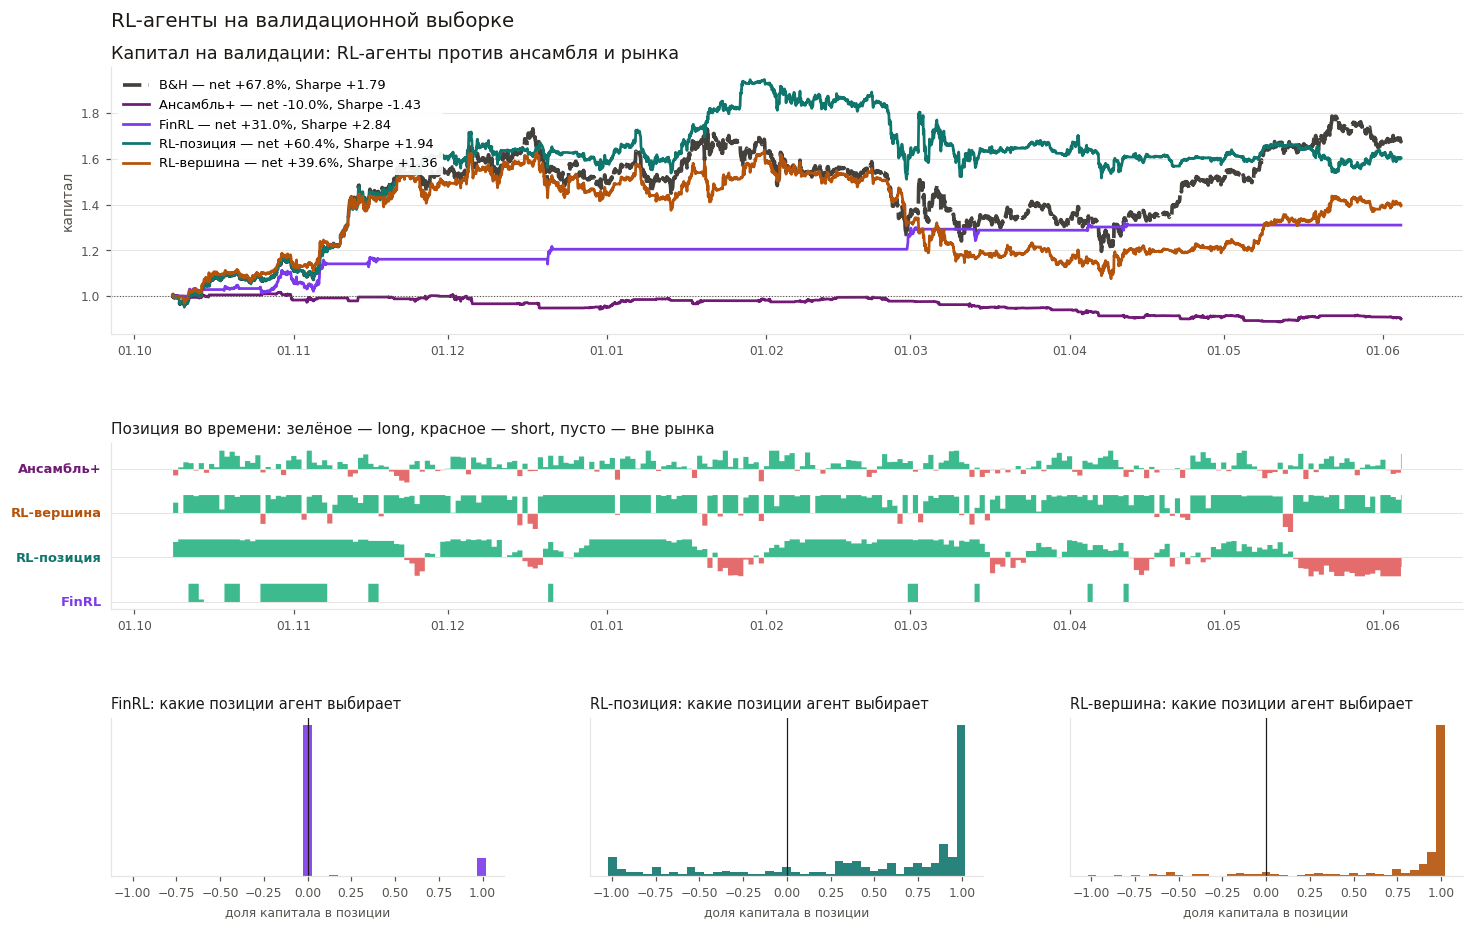

In [75]:
# Как RL-стратегии выглядят рядом с ансамблем: капитал, позиция и распределение действий.
fig = plt.figure(figsize=(13.5, 8.6))
gs = fig.add_gridspec(3, 3, height_ratios=[1.6, 1.0, 0.95], hspace=0.55, wspace=0.22,
                      top=0.925, bottom=0.07, left=0.07, right=0.98)

ax_eq = fig.add_subplot(gs[0, :])
for name in ["BuyAndHold", "EnsembleAll"] + RL_STRATEGIES:
    c = val_curves[name]
    ax_eq.plot(c["date"], c["equity"], color=COLORS[name],
               linewidth=2.4 if name == "BuyAndHold" else 1.8,
               linestyle=STYLES.get(name, "-"),
               label=f"{SHORT[name]} — net {val_comparison.loc[name, 'total_return']:+.1%}, "
                     f"Sharpe {val_comparison.loc[name, 'sharpe']:+.2f}")
ax_eq.axhline(1.0, color=INK_MUTED, linewidth=0.7, linestyle=":")
ax_eq.set_title("Капитал на валидации: RL-агенты против ансамбля и рынка",
                color=INK, fontsize=11.5, loc="left")
ax_eq.set_ylabel("капитал", color=INK_MUTED, fontsize=9)
ax_eq.legend(loc="upper left", fontsize=8.5, frameon=True, framealpha=0.92,
             edgecolor="none", facecolor="white")
ax_eq.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax_eq)

ax_pos = fig.add_subplot(gs[1, :])
_pos_order = RL_STRATEGIES + ["EnsembleAll"]
for k, name in enumerate(_pos_order):
    pos = val_positions[name]
    ax_pos.fill_between(val_dates, k * 2.4 + np.clip(pos, 0, 1), k * 2.4, color=UP,
                        linewidth=0, alpha=0.85, step="post")
    ax_pos.fill_between(val_dates, k * 2.4 + np.clip(pos, -1, 0), k * 2.4, color=DOWN,
                        linewidth=0, alpha=0.85, step="post")
    ax_pos.axhline(k * 2.4, color=GRID, linewidth=0.7)
    ax_pos.annotate(SHORT[name], xy=(0, k * 2.4), xycoords=("axes fraction", "data"),
                    xytext=(-6, 0), textcoords="offset points", ha="right", va="center",
                    fontsize=8.5, color=COLORS[name], fontweight="bold")
ax_pos.set_yticks([])
ax_pos.set_title("Позиция во времени: зелёное — long, красное — short, пусто — вне рынка",
                 color=INK, fontsize=10, loc="left")
ax_pos.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax_pos, ygrid=False)

for k, name in enumerate(RL_STRATEGIES):
    ax = fig.add_subplot(gs[2, k])
    ax.hist(val_positions[name], bins=41, range=(-1.02, 1.02), color=COLORS[name], alpha=0.9)
    ax.axvline(0, color=INK, linewidth=0.8)
    ax.set_title(f"{SHORT[name]}: какие позиции агент выбирает",
                 color=INK, fontsize=9.5, loc="left")
    ax.set_xlabel("доля капитала в позиции", color=INK_MUTED, fontsize=8)
    ax.set_yticks([])
    style_ax(ax, ygrid=False)

fig.suptitle("RL-агенты на валидационной выборке", fontsize=13, y=0.985, color=INK,
             x=0.07, ha="left")
plt.show()

После двух правок этого раунда — пороги торгового слоя только по прошлому (раздел 14) и явное
ограничение частоты сделок у всех трёх агентов (введение к разделу 19) — картина RL
перевернулась: два агента из трёх теперь прибыльны на валидации и обгоняют оба ансамбля, хотя
по net по-прежнему уступают buy & hold.

**Ограничение частоты сделок — главный рычаг раздела.** Test Sharpe на участке выбора (валидация
не участвует):

| постановка | k=1, δ=0 (без ограничений) | k=6, δ=0.10 | k=24, δ=0.10 |
|---|---|---|---|
| FinRL, лучший из пяти алгоритмов | −0.75 (A2C) | +1.67 (DDPG) | **+2.30 (TD3)** |
| FinRL, медиана по пяти алгоритмам | −3.92 | +0.61 | +1.00 |
| FinRL, медиана числа сделок на test | 824 | 202 | 72 |
| позиционная среда, PPO (3 сида) | −3.91 | −0.30 | **+0.87** |
| позиционная среда, SAC (3 сида) | −6.53 | −0.73 | +0.03 |
| RL на вершине ансамбля, PPO (3 сида) | +0.12 | −0.43 | **+0.39** |
| buy & hold на том же участке | 1.00 | 1.00 | 1.00 |

Строка `k=1, δ=0` — прежняя постановка без ограничений, и она воспроизводит прежние числа
(A2C −0.75, PPO в позиционной среде −3.91 — ровно как в прошлой версии), то есть разница в
таблице — эффект ограничения, а не другого запуска. Без ограничений отрицательны все пять
алгоритмов FinRL и оба алгоритма позиционной среды; при решении раз в сутки положительны все
пять алгоритмов FinRL и оба позиционных. Медианное число сделок FinRL падает в 11 раз.

Эффект не сводится к сэкономленным комиссиям: при `every = 24` агент ещё и учится лучше. Train
Sharpe растёт почти у всех (A2C −0.47 → +1.28, PPO в FinRL −1.52 → +1.36, PPO в позиционной
среде −2.65 → +1.89): решений в 24 раза меньше, и каждое оценивается по суточному, а не
часовому отрезку доходности — отношение сигнала к шуму у награды выше.

Две оговорки. Во всех трёх постановках выиграл самый жёсткий вариант сетки, `k = 24`, — то есть
её граница; более редкие решения (`k = 48, 168`) не проверены. И цифра выбранного варианта на
test — максимум из 15 (FinRL), 6 (позиционная среда) и 3 (мета-агент) попыток, поэтому она
оптимистична.

**Валидация.**

| стратегия | gross | net | Sharpe | просадка | сделок | оборот | экспозиция |
|---|---|---|---|---|---|---|---|
| FinRL (TD3, k=24) | +0.5% | −2.4% | −0.07 | −17.4% | 32 | 29 | 0.13 |
| **RL-позиция (PPO, k=24)** | +61.7% | **+55.1%** | **1.86** | −25.8% | 158 | 42 | 0.68 |
| **RL на вершине ансамбля (PPO, k=24)** | +67.0% | **+56.0%** | **1.84** | −23.0% | 213 | 68 | 0.74 |
| ансамбль всех шести + торговый слой | +42.3% | −4.7% | 0.12 | −31.1% | 201 | 401 | 1.00 |
| CatBoost + торговый слой | +84.6% | +84.1% | 2.06 | −31.0% | 2 | 3 | 1.00 |
| Cash | 0.0% | 0.0% | 0.00 | 0.0% | 0 | 0 | 0.00 |
| buy & hold | +68.0% | +67.8% | 1.79 | −31.0% | 1 | 1 | 1.00 |

**RL-позиция и RL-вершина: прибыльны, Sharpe чуть выше рынка, net ниже.** Net +55–56% при
Sharpe 1.84–1.86 против 1.79 у buy & hold и меньшей просадке (−23…−26% против −31%), но на
11–13 п.п. ниже рынка по net: агенты стоят в лонге в среднем на 0.61 и 0.71 капитала.
Компаундированный пассивный бенчмарк той же средней позиции дал бы +40.2% и +47.4% — факт gross
выше на **+21.5 и +19.6 п.п.**, то есть часть результата — это тайминг, а не только наклон в
лонг на растущем периоде. Комиссии съедают 4–7% капитала (у прежнего FinRL — 32%), break-even
у обоих выше 0.15%: они прибыльны на всей сетке тарифов раздела 20.

**RL-вершина против усреднения вероятностей — результат зависит от участка.** На test-части
`dev` ансамбль с торговым слоем явно сильнее мета-агента (Sharpe 3.13 и net +173.7% против
+0.39 и +4.9%). Но это тот участок, где подбирались гиперпараметры базовых моделей, поэтому он
заведомо оптимистичен для ансамбля. На валидации наоборот: мета-агент +56.0%, расширенный
ансамбль −4.7%, ансамбль трёх табличных моделей −15.1%. Устойчивого превосходства ни у одной
стороны нет, а валидационное окно одно и растущее.

**FinRL: частота сделок побеждена, переобучение — нет.** TD3 с решением раз в сутки лучший на
test (+2.30) и феноменален на своей обучающей выборке: на `dev` Sharpe +2.90, net +2235%. На
валидации — net −2.4% при экспозиции 0.13: агент почти всё время вне рынка, а факт gross (+0.5%)
на 7.9 п.п. хуже пассивного удержания той же средней позиции. Ограничение своё дело сделало —
49 сделок FinRL вместо 1 069 и 2.9% капитала на комиссии вместо 32.3%, — но выученное
направление на новый период не перенеслось. Это тот же паттерн, что у off-policy алгоритмов в
таблице отбора: сильный train, слабый невиденный участок. Нативный учёт FinRL по-прежнему
совпадает с общим бэктестом (на валидации −2.43% против −2.43%, на dev +2252% против +2235%).

**Dev против валидации.** RL-позиция: Sharpe 2.12 на dev → 1.86 на валидации; RL-вершина:
0.68 → 1.84 (на растущем окне валидации длинный уклон агента помогает больше, чем на dev);
FinRL: 2.90 → −0.07.

**Метрики классификации у RL по-прежнему около монетки** (ROC-AUC 0.503–0.506 по нормированной
позиции) — агент не ранжирует бары, а выбирает размер позиции; прибыль у RL-позиции и
RL-вершины получена при нулевом ранжировании, что само по себе довод осторожнее относиться к
этим числам.

**Чего эти числа не доказывают.** Оба прибыльных агента в основном в лонге на растущем окне;
walk-forward раздела 24 проверяет из RL только FinRL. Одна валидация в 5 740 баров, три сида и
выбор варианта ограничения по тому же test, на котором выбирался алгоритм, — это аргумент в
пользу ограничения частоты сделок, а не доказательство устойчивого edge у RL.

## 20. Чувствительность к издержкам и точка безубыточности

Итоговый вывод целиком зависит от заложенной комиссии. Если у стратегии положительная
gross-доходность, существует **пороговый уровень издержек (break-even fee)**, ниже которого
она прибыльна. Этот порог информативнее net-доходности при одном произвольном тарифе: он
говорит, на какой инфраструктуре стратегия имела бы смысл.

Для справки: taker-комиссия на BTC-перпетуалах крупных бирж — 0.04–0.055% за сторону,
maker — 0.01–0.02%, то есть ниже заложенных нами 0.1%.

In [76]:
FEE_GRID = np.linspace(0.0, 0.0015, 61)
sensitivity = pd.DataFrame(
    {name: [backtest(val_dates, val_fwd, pos, fee_rate=f, sltp=val_sltp.get(name))[1]["total_return"] for f in FEE_GRID]
     for name, pos in val_positions.items()}, index=FEE_GRID)

break_even = {}
for name, pos in val_positions.items():
    f = lambda fee: backtest(val_dates, val_fwd, pos, fee_rate=fee, sltp=val_sltp.get(name))[1]["total_return"]
    if f(0.0) <= 0:
        break_even[name] = np.nan                      # edge нет даже при нулевых издержках
    elif f(FEE_GRID[-1]) > 0:
        break_even[name] = np.inf                      # прибыльна на всей сетке
    else:
        break_even[name] = brentq(f, 0.0, FEE_GRID[-1])

be = pd.DataFrame({
    "gross (fee=0)": [sensitivity[n].iloc[0] for n in val_positions],
    "break_even_fee": [break_even[n] for n in val_positions],
    "net при 0.10%": [val_comparison.loc[n, "total_return"] for n in val_positions],
    "оборот": [val_comparison.loc[n, "turnover_units"] for n in val_positions],
}, index=list(val_positions)).rename_axis("strategy")
# Отображение: не показывать буквальную математическую бесконечность, если порог не найден
# до конца сетки — только формально верно, по сути означает ">FEE_GRID[-1]" (codex_report.md,
# пункт 25). Для программного использования (cell 127) остаётся числовой словарь break_even.
be_display = be.copy()
be_display["break_even_fee"] = be["break_even_fee"].apply(
    lambda v: "edge нет" if pd.isna(v)
    else (f">{FEE_GRID[-1] * 100:.4f}%" if np.isinf(v) else f"{v * 100:.4f}%"))
display(be_display.round(6))

scenario = pd.DataFrame({
    label: {name: backtest(val_dates, val_fwd, pos, fee_rate=fee, sltp=val_sltp.get(name))[1]["total_return"]
            for name, pos in val_positions.items()}
    for label, fee in FEE_SCENARIOS.items()})
print("Net-доходность на валидации при разных тарифах:")
display(scenario.map(lambda vv: f"{vv:+.2%}"))

for nm, vv in break_even.items():
    if np.isnan(vv):
        print(f"{nm:20s}: edge отсутствует даже при нулевых издержках")
    elif np.isinf(vv):
        print(f"{nm:20s}: прибыльна на всём диапазоне сетки")
    else:
        print(f"{nm:20s}: безубыточна при комиссии < {vv * 100:.4f}% за единицу оборота "
              f"({'выше' if vv > FEE_RATE else 'ниже'} заложенных {FEE_RATE * 100:.2f}%)")

,gross (fee=0),break_even_fee,net при 0.10%,оборот
strategy,,,,
BuyAndHold,0.679818,>0.1500%,0.678141,1.000000
HW2_Baseline,1.578566,0.0237%,-0.952710,3995.000000
TA_AlwaysIn,0.874610,0.0165%,-0.958176,3799.000000
LogisticRegression,0.182797,>0.1500%,0.138828,38.000000
DecisionTree,0.007097,0.0966%,-0.000249,7.265797
CatBoost,0.266081,>0.1500%,0.258518,6.000000
Ensemble,0.840318,>0.1500%,0.717546,69.000000
TimesNet,-0.375151,edge нет,-0.449839,127.000000
TSMixer,-0.440752,edge нет,-0.486587,85.000000


Net-доходность на валидации при разных тарифах:


,0.10% (ДЗ №2),0.05% (taker),0.02% (maker),0.00% (без издержек)
BuyAndHold,+67.81%,+67.90%,+67.95%,+67.98%
HW2_Baseline,-95.27%,-65.05%,+15.97%,+157.86%
TA_AlwaysIn,-95.82%,-71.97%,-12.32%,+87.46%
LogisticRegression,+13.88%,+16.06%,+17.39%,+18.28%
DecisionTree,-0.02%,+0.34%,+0.56%,+0.71%
CatBoost,+25.85%,+26.23%,+26.46%,+26.61%
Ensemble,+71.75%,+77.79%,+81.51%,+84.03%
TimesNet,-44.98%,-41.37%,-39.08%,-37.52%
TSMixer,-48.66%,-46.42%,-45.02%,-44.08%
TimesFM,-0.33%,+0.62%,+1.19%,+1.58%


BuyAndHold          : прибыльна на всём диапазоне сетки
HW2_Baseline        : безубыточна при комиссии < 0.0237% за единицу оборота (ниже заложенных 0.10%)
TA_AlwaysIn         : безубыточна при комиссии < 0.0165% за единицу оборота (ниже заложенных 0.10%)
LogisticRegression  : прибыльна на всём диапазоне сетки
DecisionTree        : безубыточна при комиссии < 0.0966% за единицу оборота (ниже заложенных 0.10%)
CatBoost            : прибыльна на всём диапазоне сетки
Ensemble            : прибыльна на всём диапазоне сетки
TimesNet            : edge отсутствует даже при нулевых издержках
TSMixer             : edge отсутствует даже при нулевых издержках
TimesFM             : безубыточна при комиссии < 0.0825% за единицу оборота (ниже заложенных 0.10%)
EnsembleAll         : edge отсутствует даже при нулевых издержках
FinRL               : прибыльна на всём диапазоне сетки
RL_Position         : прибыльна на всём диапазоне сетки
RL_Ensemble         : прибыльна на всём диапазоне сетки
Cash      

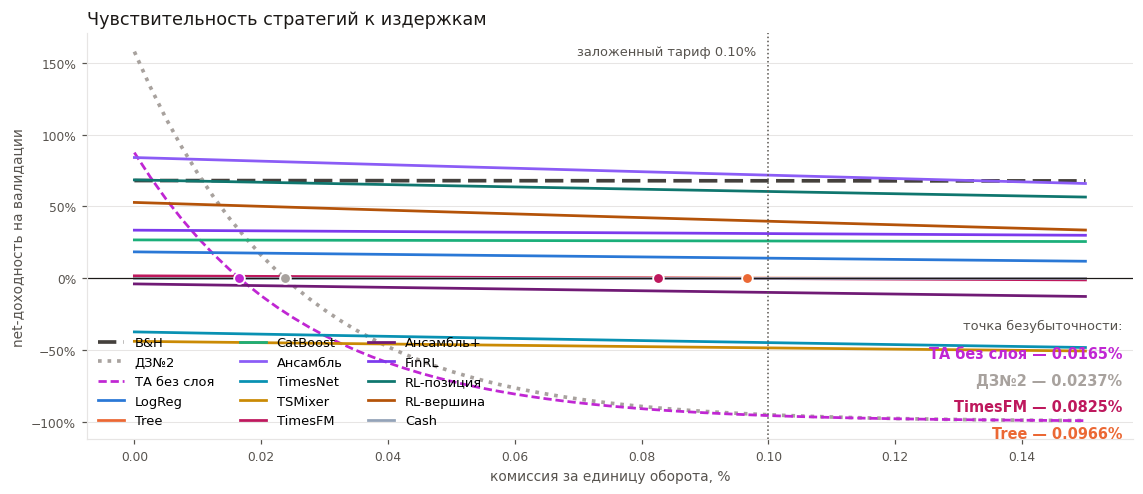

In [77]:
fig, ax = plt.subplots(figsize=(10.5, 4.6))
for name in sensitivity.columns:
    ax.plot(sensitivity.index * 100, sensitivity[name], color=COLORS[name],
            linewidth=2.4 if name in ("BuyAndHold", "HW2_Baseline") else 1.8,
            linestyle=STYLES.get(name, "-"), label=SHORT[name])
ax.axhline(0, color=INK, linewidth=0.8)
ax.axvline(FEE_RATE * 100, color=INK_MUTED, linewidth=1.0, linestyle=":")
ax.annotate(f"заложенный тариф {FEE_RATE * 100:.2f}%", xy=(FEE_RATE * 100, 0.97),
            xycoords=("data", "axes fraction"), xytext=(-8, 0), textcoords="offset points",
            ha="right", va="top", fontsize=8.5, color=INK_MUTED)
finite_be = sorted([(nm, vv) for nm, vv in break_even.items() if np.isfinite(vv) and vv > 0],
                   key=lambda t: t[1])
for nm, vv in finite_be:
    ax.plot([vv * 100], [0], marker="o", markersize=7, color=COLORS[nm],
            markeredgecolor="white", markeredgewidth=1.2, zorder=5)
ax.text(0.99, 0.28, "точка безубыточности:", transform=ax.transAxes, ha="right", va="center",
        fontsize=8.5, color=INK_MUTED)
for k, (nm, vv) in enumerate(finite_be):
    ax.text(0.99, 0.21 - k * 0.065, f"{SHORT[nm]} — {vv * 100:.4f}%", transform=ax.transAxes,
            ha="right", va="center", fontsize=9.5, color=COLORS[nm], fontweight="bold")
ax.set_xlabel("комиссия за единицу оборота, %", color=INK_MUTED, fontsize=9)
ax.set_ylabel("net-доходность на валидации", color=INK_MUTED, fontsize=9)
ax.set_title("Чувствительность стратегий к издержкам", color=INK, fontsize=11.5, loc="left")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.legend(frameon=False, fontsize=8.5, loc="lower left", ncol=3)
style_ax(ax)
fig.tight_layout()
plt.show()

## 21. Важность признаков

CatBoost показывает, на какие признаки он реально опирается. Важности агрегируются и по
отдельным признакам, и по группам — второе устойчивее, потому что близкие индикаторы делят
важность между собой.

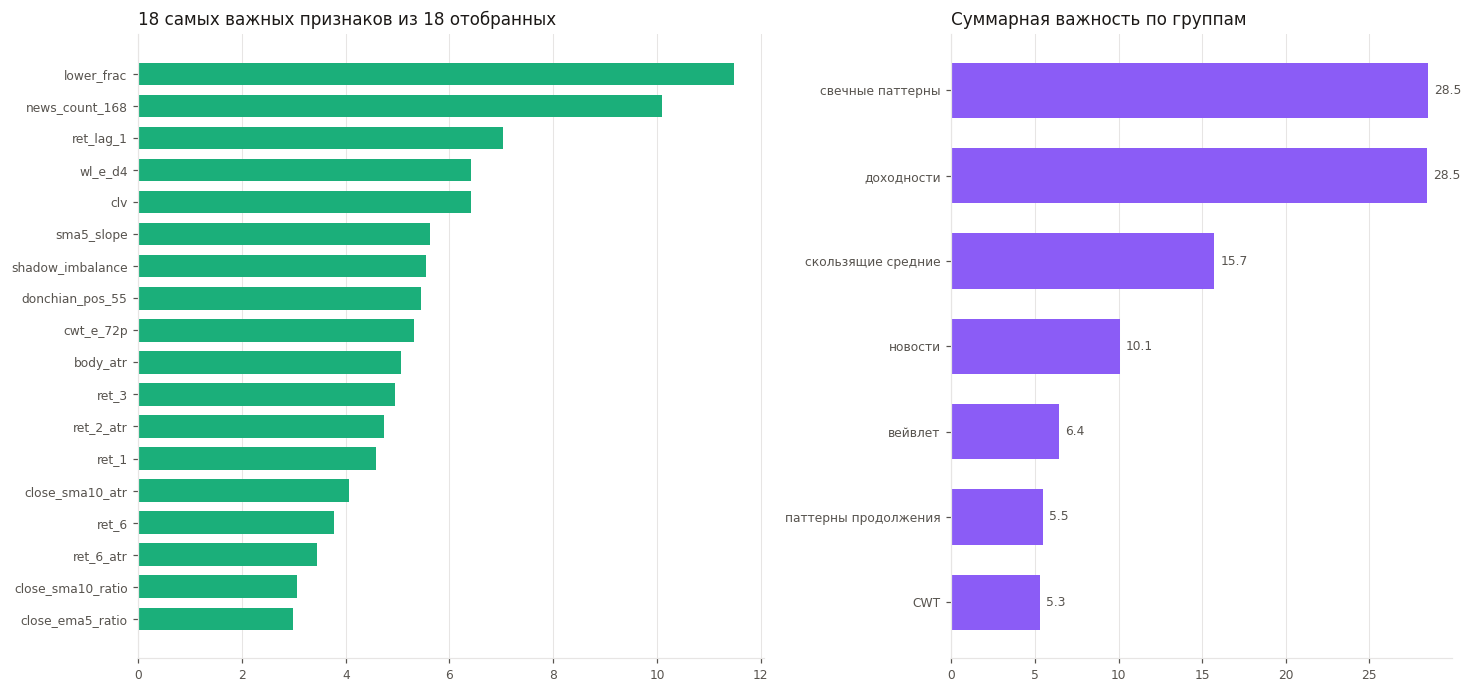

Ни одного признака вида cdl_* или pat_* в отобранном наборе нет: отбор из раздела 12.2 не пропустил ни один флаг распознанной фигуры.
От группы «свечные паттерны» остались только геометрические характеристики бара: lower_frac, clv, body_atr, shadow_imbalance.
Это согласуется с выводом ноутбука дз №5: работает не отдельный паттерн-сигнал, а форма и плотность баров.


In [78]:
imp = pd.Series(final_models["CatBoost"].get_feature_importance(), index=MODEL_COLS)
group_of = {c: g for g, cols in FEATURE_GROUPS.items() for c in cols}
imp_by_group = imp.groupby(imp.index.map(group_of)).sum().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.4), gridspec_kw={"width_ratios": [1.25, 1]})
top_imp = imp.sort_values().tail(25)
axes[0].barh(np.arange(len(top_imp)), top_imp.to_numpy(), color=COLORS["CatBoost"], height=0.7)
axes[0].set_yticks(np.arange(len(top_imp)))
axes[0].set_yticklabels(top_imp.index, fontsize=8)
axes[0].set_title(f"{len(top_imp)} самых важных признаков из {len(MODEL_COLS)} отобранных",
                  color=INK, loc="left", fontsize=11)
style_ax(axes[0], ygrid=False, xgrid=True)

axes[1].barh(np.arange(len(imp_by_group)), imp_by_group.to_numpy(),
             color=COLORS["Ensemble"], height=0.65)
axes[1].set_yticks(np.arange(len(imp_by_group)))
axes[1].set_yticklabels(imp_by_group.index, fontsize=9)
axes[1].set_title("Суммарная важность по группам", color=INK, loc="left", fontsize=11)
for yi, vv in enumerate(imp_by_group.to_numpy()):
    axes[1].annotate(f"{vv:.1f}", xy=(vv, yi), xytext=(4, 0), textcoords="offset points",
                     va="center", fontsize=8, color=INK_MUTED)
style_ax(axes[1], ygrid=False, xgrid=True)
fig.tight_layout()
plt.show()

pattern_cols = [c for c in MODEL_COLS if c.startswith(("cdl_", "pat_"))]
if pattern_cols:
    top_patterns = imp[pattern_cols].sort_values(ascending=False)
    print("Самые важные паттерны технического анализа:")
    display(pd.DataFrame({
        "паттерн": [CANDLE_RU.get(c, PATTERN_RU.get(c.replace("_24", ""), c))
                    for c in top_patterns.head(12).index],
        "важность": top_patterns.head(12).round(3).to_numpy(),
    }, index=top_patterns.head(12).index))
else:
    cdl_left = [c for c in MODEL_COLS if group_of.get(c) == "свечные паттерны"]
    print("Ни одного признака вида cdl_* или pat_* в отобранном наборе нет: отбор из "
          "раздела 12.2 не пропустил ни один флаг распознанной фигуры.")
    print(f"От группы «свечные паттерны» остались только геометрические характеристики бара: "
          f"{', '.join(cdl_left) if cdl_left else '—'}.")
    print("Это согласуется с выводом ноутбука дз №5: работает не отдельный паттерн-сигнал, "
          "а форма и плотность баров.")

## 22. Дашборд эффективности стратегий во времени

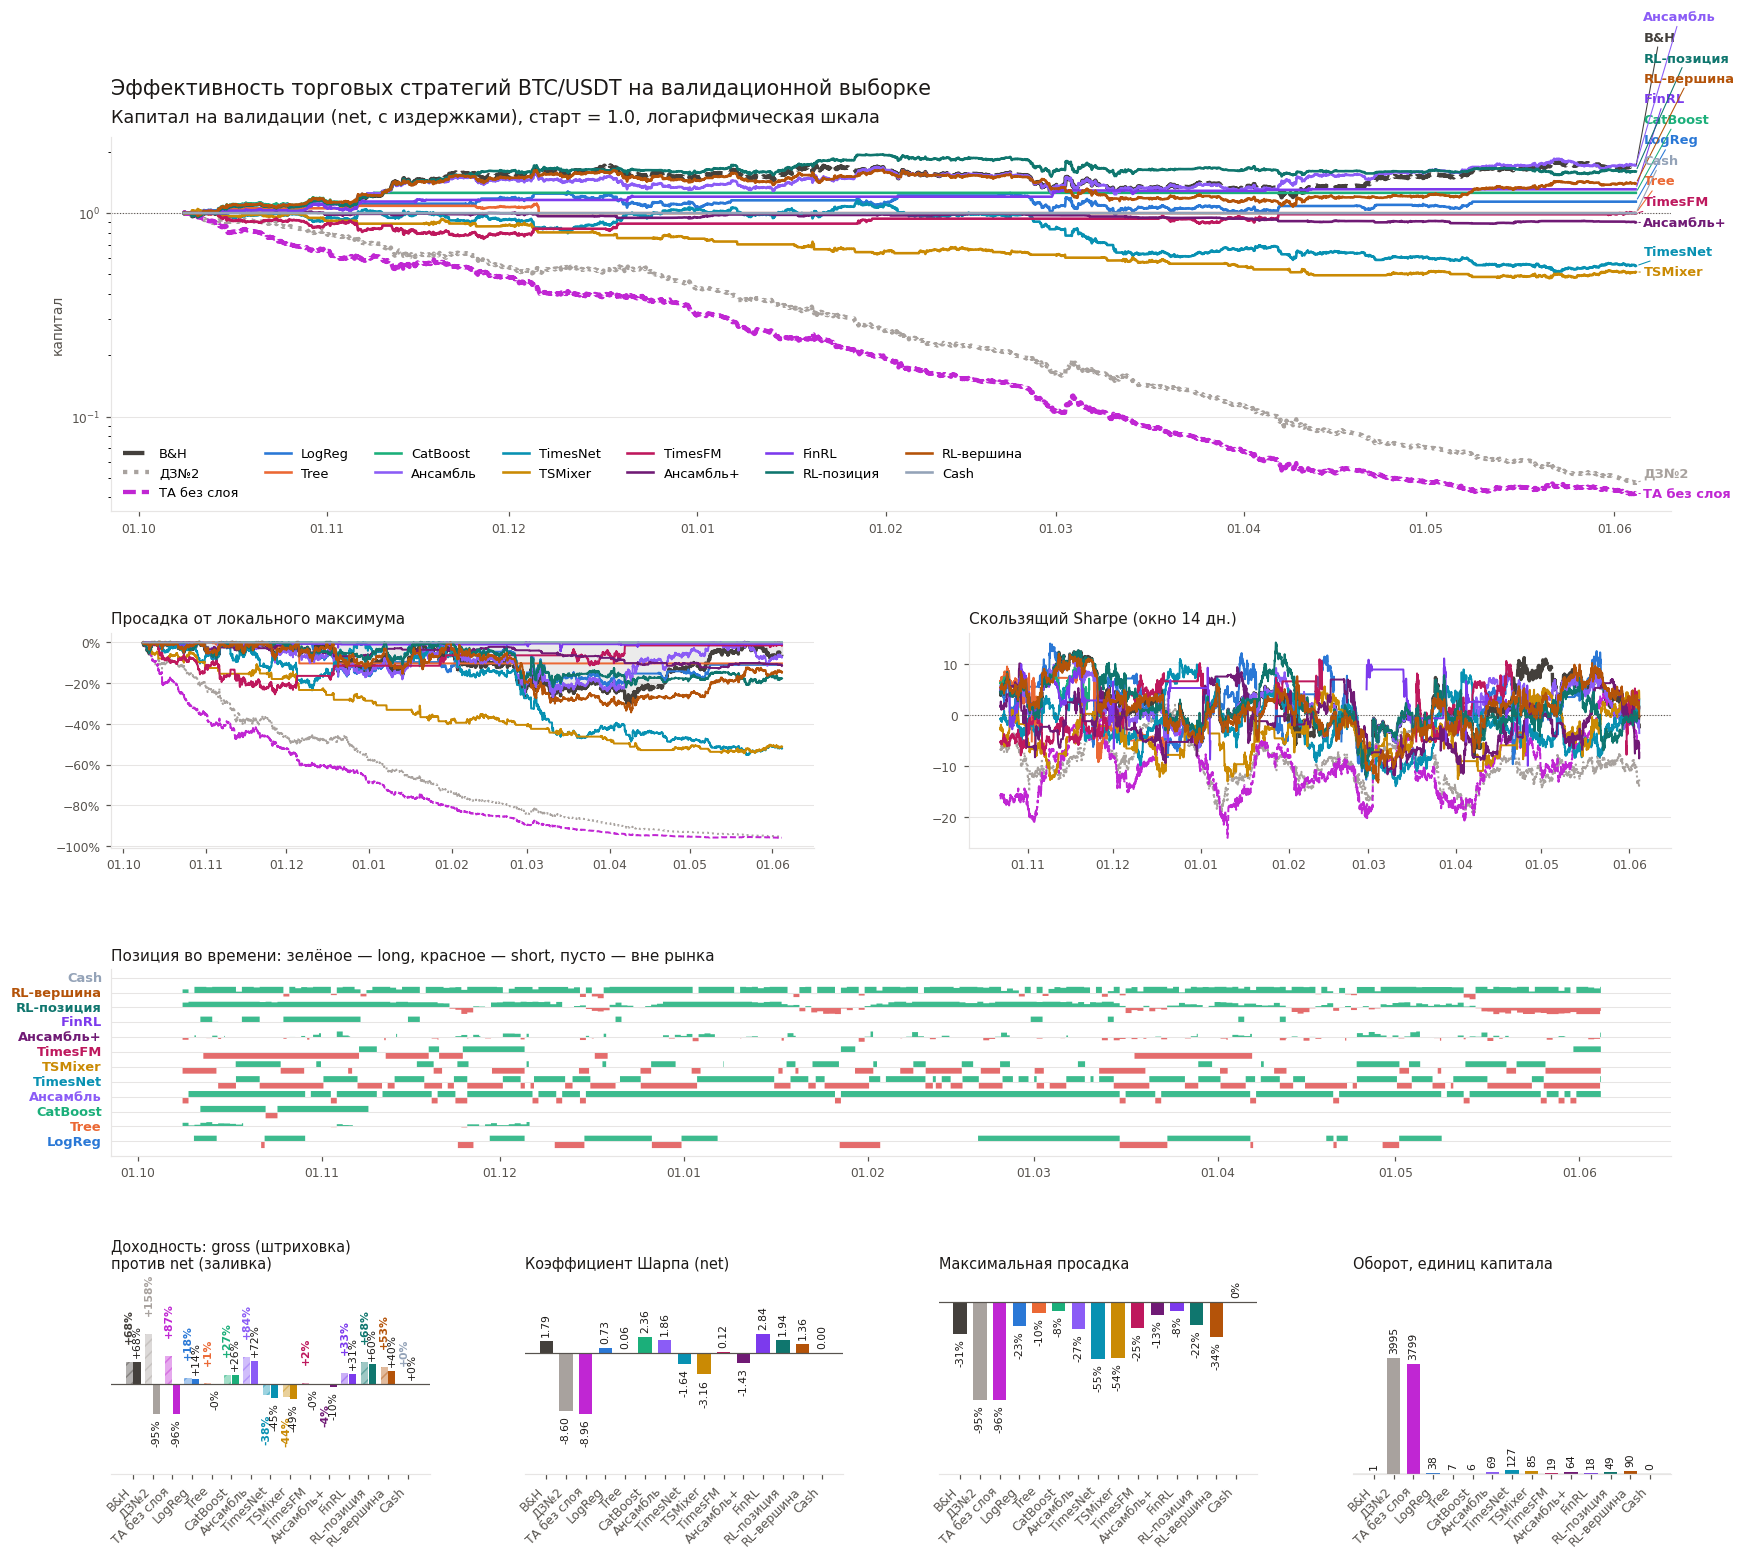

In [79]:
def declutter(pairs, min_gap):
    """Раздвигает подписи по вертикали, чтобы они не накладывались."""
    out, prev = {}, None
    for name, y in sorted(pairs, key=lambda t: t[1]):
        if prev is not None and y - prev < min_gap:
            y = prev + min_gap
        out[name], prev = y, y
    return out


fig = plt.figure(figsize=(15.5, 13.5))
gs = fig.add_gridspec(4, 2, height_ratios=[2.0, 1.15, 1.0, 1.05], hspace=0.5, wspace=0.22,
                      top=0.945, bottom=0.045, left=0.06, right=0.975)

# ── 1. кривые капитала (net) ────────────────────────────────────────────────
ax_eq = fig.add_subplot(gs[0, :])
for name in strategies:
    curve = val_curves[name]
    bench = name in ("BuyAndHold", "HW2_Baseline", "TA_AlwaysIn")
    ax_eq.plot(curve["date"], curve["equity"], color=COLORS[name],
               linewidth=2.8 if bench else 1.7, linestyle=STYLES.get(name, "-"),
               zorder=2 if bench else 3, label=SHORT[name])
ax_eq.axhline(1.0, color=INK_MUTED, linewidth=0.7, linestyle=":", zorder=1)
ax_eq.set_yscale("log")
last_x = val_curves["BuyAndHold"]["date"].iloc[-1]
ax_eq.set_xlim(right=last_x + pd.Timedelta(hours=140))
lo_y, hi_y = ax_eq.get_ylim()
span_log = np.log10(hi_y) - np.log10(lo_y)
ends = declutter([(nm, float(np.log10(max(val_curves[nm]["equity"].iloc[-1], 1e-6))))
                  for nm in strategies], span_log * 0.055)
for name in strategies:
    y_true = float(val_curves[name]["equity"].iloc[-1])
    ax_eq.annotate(SHORT[name], xy=(last_x, max(y_true, 1e-6)),
                   xytext=(last_x + pd.Timedelta(hours=30), 10 ** ends[name]), textcoords="data",
                   va="center", fontsize=8.5, color=COLORS[name], fontweight="bold",
                   annotation_clip=False,
                   arrowprops=dict(arrowstyle="-", color=COLORS[name], linewidth=0.7,
                                   shrinkA=0, shrinkB=2))
ax_eq.set_title("Капитал на валидации (net, с издержками), старт = 1.0, логарифмическая шкала",
                color=INK, fontsize=11.5, loc="left", pad=10)
ax_eq.set_ylabel("капитал", color=INK_MUTED, fontsize=9)
ax_eq.legend(loc="lower left", frameon=False, fontsize=8.5, ncol=7)
ax_eq.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax_eq)

# ── 2. просадка ─────────────────────────────────────────────────────────────
ax_dd = fig.add_subplot(gs[1, 0])
ax_dd.fill_between(val_curves["BuyAndHold"]["date"], val_curves["BuyAndHold"]["drawdown"], 0,
                   color=COLORS["BuyAndHold"], alpha=0.10, zorder=1)
for name in strategies:
    curve = val_curves[name]
    ax_dd.plot(curve["date"], curve["drawdown"], color=COLORS[name],
               linewidth=2.2 if name == "BuyAndHold" else 1.3,
               linestyle=STYLES.get(name, "-"), zorder=2)
ax_dd.set_title("Просадка от локального максимума", color=INK, fontsize=10, loc="left")
ax_dd.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax_dd.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax_dd)

# ── 3. скользящий Sharpe ────────────────────────────────────────────────────
ax_roll = fig.add_subplot(gs[1, 1])
window = 24 * 14
for name in strategies:
    curve = val_curves[name]
    r = curve["strategy_return"]
    roll = (r.rolling(window).mean() / r.rolling(window).std()) * np.sqrt(PERIODS_PER_YEAR)
    ax_roll.plot(curve["date"], roll, color=COLORS[name],
                 linewidth=2.2 if name == "BuyAndHold" else 1.3, linestyle=STYLES.get(name, "-"))
ax_roll.axhline(0.0, color=INK_MUTED, linewidth=0.7, linestyle=":")
ax_roll.set_title(f"Скользящий Sharpe (окно {window // 24} дн.)", color=INK, fontsize=10, loc="left")
ax_roll.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax_roll)

# ── 4. позиция во времени: видно, как работает торговый слой ────────────────
ax_pos = fig.add_subplot(gs[2, :])
show_pos = [nm for nm in strategies if nm not in ("BuyAndHold", "HW2_Baseline", "TA_AlwaysIn")]
for k, name in enumerate(show_pos):
    # у стратегий с правилами выхода — фактическая позиция после стопов
    pos = val_curves[name]["position"].to_numpy() if name in val_sltp else val_positions[name]
    ax_pos.fill_between(val_dates, k * 2.4 + np.clip(pos, 0, 1), k * 2.4,
                        color=UP, linewidth=0, alpha=0.85, step="post")
    ax_pos.fill_between(val_dates, k * 2.4 + np.clip(pos, -1, 0), k * 2.4,
                        color=DOWN, linewidth=0, alpha=0.85, step="post")
    ax_pos.axhline(k * 2.4, color=GRID, linewidth=0.7)
    ax_pos.annotate(SHORT[name], xy=(0, k * 2.4), xycoords=("axes fraction", "data"),
                    xytext=(-6, 0), textcoords="offset points", ha="right", va="center",
                    fontsize=8.5, color=COLORS[name], fontweight="bold")
ax_pos.set_yticks([])
ax_pos.set_title("Позиция во времени: зелёное — long, красное — short, пусто — вне рынка",
                 color=INK, fontsize=10, loc="left")
ax_pos.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax_pos, ygrid=False)

# ── 5. сводные метрики: у каждой своя шкала ─────────────────────────────────
inner = gs[3, :].subgridspec(1, 4, wspace=0.3)
x = np.arange(len(strategies))


def frame(ax, values, title):
    ax.axhline(0, color=INK_MUTED, linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([SHORT[nm] for nm in strategies], rotation=45, ha="right", fontsize=7)
    ax.set_title(title, color=INK, fontsize=9.5, loc="left")
    lo, hi = min(list(values) + [0]), max(list(values) + [0])
    rng = (hi - lo) or 1
    # запас сверху и снизу рассчитан на вертикальные подписи значений (см. kpi_panel)
    ax.set_ylim(lo - (rng * 0.75 if lo < 0 else 0), hi + (rng * 0.70 if hi > 0 else rng * 0.25))
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    ax.set_yticks([])


def kpi_panel(ax, values, title, fmt):
    """Подписи значений вертикальные: на четырнадцати столбиках горизонтальные
    подписи соседей слипаются в нечитаемую строку («237753284» вместо «237 753 284»)."""
    for xi, (name, vv) in enumerate(zip(strategies, values)):
        ax.bar(xi, vv, width=0.68, color=COLORS[name])
        ax.annotate(fmt(vv), xy=(xi, vv), xytext=(0, 3 if vv >= 0 else -3),
                    textcoords="offset points", ha="center",
                    va="bottom" if vv >= 0 else "top", fontsize=7, color=INK,
                    rotation=90)
    frame(ax, values, title)


ax_ret = fig.add_subplot(inner[0, 0])
gross = [val_comparison.loc[nm, "gross_return"] for nm in strategies]
net = [val_comparison.loc[nm, "total_return"] for nm in strategies]
for xi, name in enumerate(strategies):
    ax_ret.bar(xi - 0.20, gross[xi], width=0.36, color=COLORS[name], alpha=0.40,
               hatch="///", edgecolor=COLORS[name], linewidth=0)
    ax_ret.bar(xi + 0.20, net[xi], width=0.36, color=COLORS[name])
    # gross подписывается выше net, иначе у близких значений подписи сливаются
    ax_ret.annotate(f"{gross[xi]:+.0%}", xy=(xi - 0.20, gross[xi]),
                    xytext=(0, 12 if gross[xi] >= 0 else -12), textcoords="offset points",
                    ha="center", va="bottom" if gross[xi] >= 0 else "top",
                    fontsize=7, color=COLORS[name], fontweight="bold", rotation=90)
    ax_ret.annotate(f"{net[xi]:+.0%}", xy=(xi + 0.20, net[xi]),
                    xytext=(0, 3 if net[xi] >= 0 else -3), textcoords="offset points",
                    ha="center", va="bottom" if net[xi] >= 0 else "top",
                    fontsize=7, color=INK, rotation=90)
frame(ax_ret, gross + net, "Доходность: gross (штриховка)\nпротив net (заливка)")

kpi_panel(fig.add_subplot(inner[0, 1]), [val_comparison.loc[nm, "sharpe"] for nm in strategies],
          "Коэффициент Шарпа (net)", lambda vv: f"{vv:.2f}")
kpi_panel(fig.add_subplot(inner[0, 2]), [val_comparison.loc[nm, "max_drawdown"] for nm in strategies],
          "Максимальная просадка", lambda vv: f"{vv:.0%}")
kpi_panel(fig.add_subplot(inner[0, 3]), [val_comparison.loc[nm, "turnover_units"] for nm in strategies],
          "Оборот, единиц капитала", lambda vv: f"{vv:.0f}")

fig.suptitle("Эффективность торговых стратегий BTC/USDT на валидационной выборке",
             fontsize=13.5, y=0.985, color=INK, x=0.06, ha="left")
plt.show()

In [80]:
# Итоговая сводка: ДЗ №2 против нынешнего конвейера.
tabular_names = list(final_models) + ["Ensemble"]
best_new = val_comparison.loc[tabular_names, "sharpe"].idxmax()
best_seq = val_comparison.loc[SEQ_MODELS, "sharpe"].idxmax()
best_rl = val_comparison.loc[RL_STRATEGIES, "sharpe"].idxmax()
summary_cols = {
    "Buy & Hold": "BuyAndHold",
    "ДЗ №2: лаги + всегда в рынке": "HW2_Baseline",
    "ТА, но всегда в рынке": "TA_AlwaysIn",
    f"ТА + торговый слой ({SHORT[best_new]})": best_new,
    f"Лучшая стратегия раздела 17 ({SHORT[best_seq]})": best_seq,
    f"Лучший RL-агент ({SHORT[best_rl]})": best_rl,
    "RL на вершине ансамбля": "RL_Ensemble",
}
summary_final = pd.DataFrame(
    {label: val_comparison.loc[nm] for label, nm in summary_cols.items()}
).loc[["roc_auc", "average_precision", "gross_return", "fee_drag", "total_return", "sharpe",
       "max_drawdown", "n_trades", "turnover_units", "time_in_market"]]
summary_final.loc["break_even_fee"] = [break_even[nm] for nm in summary_cols.values()]
display(summary_final.round(4))

,Buy & Hold,ДЗ №2: лаги + всегда в рынке,"ТА, но всегда в рынке",ТА + торговый слой (CatBoost),Лучшая стратегия раздела 17 (TimesFM),Лучший RL-агент (FinRL),RL на вершине ансамбля
roc_auc,0.5000,0.5462,0.5507,0.5126,0.5470,0.5089,0.5027
average_precision,0.5094,0.5551,0.5522,0.5296,0.5540,0.5134,0.5105
gross_return,0.6798,1.5786,0.8746,0.2661,0.0158,0.3340,0.5274
fee_drag,0.0010,3.9950,3.7990,0.0060,0.0190,0.0180,0.0897
total_return,0.6781,-0.9527,-0.9582,0.2585,-0.0033,0.3101,0.3962
sharpe,1.7870,-8.6007,-8.9610,2.3582,0.1229,2.8408,1.3614
max_drawdown,-0.3098,-0.9534,-0.9589,-0.0828,-0.2546,-0.0828,-0.3432
n_trades,1.0000,1998.0000,1900.0000,4.0000,15.0000,19.0000,152.0000
turnover_units,1.0000,3995.0000,3799.0000,6.0000,19.0000,18.0105,89.7258
time_in_market,1.0000,1.0000,1.0000,0.1185,0.3418,0.1129,0.9916


## 23. Выводы

> Текст этого раздела перенесён из исходного `final_ensenble.ipynb` без изменений. Числа в нём относятся к слою без стопов и к моделям исходного прогона. Актуальные результаты — в таблицах выше, в разделах 18.3 и 24.1 и в разделе 25.

Ноутбук доводит конвейер ДЗ №3–№6 до финального вида и добавляет к нему обучение с
подкреплением: три постановки RL на FinRL и Stable-Baselines3, включая агента, поставленного
**на вершину ансамбля** из шести моделей. Признаки, разбиение, бэктест, комиссия 0.1% и метрики
остались прежними по конструкции, но в код внесён набор исправлений утечек и математических
ошибок (причинный TimesNet на инференсе, отбор признаков и препроцессинг RL только по train,
верная граница embargo, честные пороги торгового слоя у конкурента в разделе 19.3, N-1-переходная
бухгалтерия FinRL, исправленные MAD/CCI/MFI/просадка, дедупликация новостей и другие — полный
список в `codex_report.md`). В последнем раунде добавлены ещё две правки:

- **пороги торгового слоя — только по прошлому.** При подборе слоя, в Optuna и во всех
  оценках на OOF квантильный порог фолда k считается по OOF-прогнозам фолдов 0…k−1, а не по
  распределению того участка, на котором слой оценивается (раздел 14);
- **ограничение частоты сделок у RL-агентов**: решение раз в `every` баров и мёртвая зона
  `deadband`, вариант выбирается по test вместе с алгоритмом (раздел 19).

Первая правка изменила выбранные торговые слои, а с ними — результаты supervised-стратегий на
валидации; вторая перевернула картину RL. Поэтому числа этой версии не совпадают с более ранними
прогонами и не должны с ними сравниваться.

### Короткий ответ

**С ограничением частоты сделок два RL-агента из трёх прибыльны и обгоняют оба ансамбля, но не
рынок.** Net на валидации: RL на вершине ансамбля +56.0% (Sharpe 1.84), RL-позиция +55.1%
(Sharpe 1.86), FinRL −2.4%. Для сравнения: buy & hold +67.8% (Sharpe 1.79), ансамбль всех шести
моделей −4.7%, ансамбль трёх табличных −15.1%, лучшая supervised-стратегия — CatBoost, +84.1%,
но с двумя сменами позиции за весь период, то есть почти buy & hold. Sharpe у двух прибыльных
агентов чуть выше рынка, просадка меньше (−23…−26% против −31%), а gross на 20–22 п.п. выше
компаундированного пассивного бенчмарка той же средней позиции — часть результата даёт тайминг,
а не только длинный уклон на растущем окне.

**Главный рычаг — именно ограничение частоты.** Без него (`k=1`, прежняя постановка) на test
отрицательны все пять алгоритмов FinRL (медиана Sharpe −3.92) и оба алгоритма позиционной среды
(PPO −3.91, SAC −6.53); при решении раз в сутки положительны все пять и оба (медиана FinRL +1.00,
PPO +0.87). Медиана числа сделок FinRL на test падает с 824 до 72. Решение раз в сутки заодно
облегчает обучение: train Sharpe растёт почти у всех алгоритмов.

**FinRL ограничение не спасло.** Выбранный по test TD3 (`k=24`) показывает на своём `dev` net
+2235%, а на валидации −2.4% при экспозиции 0.13 — переобучение, а не оборот: комиссий он
теперь платит 2.9% капитала вместо прежних 32.3%.

**Честные пороги сделали supervised-конвейер скромнее.** Из трёх табличных моделей на
валидации прибыльна только CatBoost (+84.1%); LogReg −0.1%, дерево −1.4%, их ансамбль −15.1%.
В прошлой версии LogReg (+71.6%) и ансамбль (+55.5%) были в плюсе — при порогах, посчитанных по
тем же OOF, на которых слой и оценивался.

**По новостям (вторая часть работы) главный вывод не изменился:** из 24 новостных признаков
отбор пережил **один** счётчик потока (`news_count_168`); качество прогноза не растёт, а разница
в деньгах на валидации теперь в две стороны — у LogReg и ансамбля новости помогли, у дерева и
CatBoost навредили. Подробности — в части II.

## Часть I. Обучение с подкреплением

### 1. Три постановки и что из них вышло

| постановка | среда | действие | выбрано по test | gross | net | Sharpe | оборот |
|---|---|---|---|---|---|---|---|
| 19.1 FinRL «как есть» | `StockTradingEnv` | целые лоты, только long | TD3, k=24, δ=0.10 | +0.5% | −2.4% | −0.07 | 29 |
| 19.2 позиционная среда | своя `gymnasium`-среда | доля капитала в [−1, +1] | PPO, k=24, δ=0.10, 3 сида | +61.7% | **+55.1%** | **1.86** | 42 |
| 19.3 RL на вершине ансамбля | та же среда, наблюдение — прогнозы 6 моделей | доля капитала | PPO, k=24, δ=0.10, 3 сида | +67.0% | **+56.0%** | **1.84** | 68 |
| для сравнения: ансамбль всех шести | — | торговый слой | — | +42.3% | −4.7% | 0.12 | 401 |
| для сравнения: CatBoost | — | торговый слой | — | +84.6% | +84.1% | 2.06 | 3 |
| для сравнения: Cash (не торговать) | — | — | — | 0.0% | 0.0% | 0.00 | 0 |
| для сравнения: buy & hold | — | — | — | +68.0% | +67.8% | 1.79 | 1 |

RL-позиция и RL-вершина обгоняют оба ансамбля и по gross, и по net, но не buy & hold по net.
FinRL — на уровне бездействия.

### 2. Что дало ограничение частоты сделок

| test Sharpe | k=1, δ=0 | k=6, δ=0.10 | k=24, δ=0.10 |
|---|---|---|---|
| FinRL, лучший из пяти | −0.75 | +1.67 | **+2.30** |
| FinRL, медиана по пяти | −3.92 | +0.61 | +1.00 |
| позиционная среда, PPO | −3.91 | −0.30 | **+0.87** |
| позиционная среда, SAC | −6.53 | −0.73 | +0.03 |
| RL на вершине ансамбля, PPO | +0.12 | −0.43 | **+0.39** |

Строка `k=1` воспроизводит прежние числа (A2C −0.75, PPO −3.91), так что разница — эффект
ограничения, а не другого запуска. В прошлой версии главным объяснением провала RL был оборот:
гауссова политика выдаёт новое число почти на каждом баре, а комиссия в награде (порядка 10⁻⁴ на
бар) на порядок меньше шума часовой доходности (порядка 10⁻³) и до градиента политики за
отведённый бюджет шагов не доходит. Ограничение решает это конструкцией — как гистерезис и
ребалансировка в торговом слое раздела 9, — и работает сразу в две стороны: меньше сделок и
менее шумная награда за каждое решение.

Во всех трёх постановках выиграл самый жёсткий вариант сетки (`k = 24`), то есть её граница, а
цифра выбранного варианта на test — максимум из нескольких попыток и потому оптимистична.
Разброс по сидам при `k = 24` стал меньше и перестал менять знак у PPO в позиционной среде
(+0.96, +0.36, +1.04), но у мета-агента по-прежнему велик (+0.95, −0.05, +0.13).

### 3. Почему RL выиграл у ансамблей, но не у рынка

- **RL-позиция и RL-вершина** большую часть времени в лонге (средняя позиция +0.61 и +0.71) —
  на окне, где рынок вырос на 67.8%, это само по себе приносит деньги. Но и сверх этого у них
  есть тайминг: фактический gross на **+21.5 и +19.6 п.п.** выше компаундированного бэктеста
  постоянной позиции той же величины. Net ниже рынка потому, что экспозиция меньше единицы, а
  Sharpe выше — потому, что просадка меньше.
- **FinRL (TD3)** — противоположный случай: частота сделок под контролем (32 сделки в бэктесте
  на 5 740 барах), но агент почти всё время вне рынка (экспозиция 0.13), и его gross на 7.9 п.п.
  хуже пассивного удержания той же позиции. Разрыв между dev (Sharpe +2.90) и валидацией (−0.07)
  — переобучение off-policy агента.
- **Метрики классификации у RL около монетки** (ROC-AUC 0.503–0.506 по нормированной позиции):
  прибыль получена без ранжирования баров, поэтому к ней стоит относиться осторожно.

### 4. RL на вершине ансамбля против усреднения вероятностей

Главный «опциональный» пункт задания. Мета-агент видел ранги прогнозов всех шести моделей, их
согласие между собой, два признака состояния рынка (`ret_1`, `atr_14`) и собственную позицию и
должен был заменить собой сразу два фиксированных решения: усреднение вероятностей и правило
торгового слоя.

| | участок | Sharpe | net | gross | оборот | сделок | экспозиция |
|---|---|---|---|---|---|---|---|
| RL на вершине ансамбля (k=24) | test-часть dev | 0.39 | +4.9% | +11.9% | 65 | 176 | 0.76 |
| ансамбль + торговый слой (пороги по train-части OOF) | test-часть dev | 3.13 | +173.7% | +286.6% | 345 | 173 | 1.00 |
| buy & hold | test-часть dev | 1.00 | +29.5% | +29.6% | 1 | 1 | 1.00 |
| RL на вершине ансамбля (k=24) | валидация | 1.84 | +56.0% | +67.0% | 68 | 213 | 0.74 |
| ансамбль всех шести + торговый слой | валидация | 0.12 | −4.7% | +42.3% | 401 | 201 | 1.00 |
| buy & hold | валидация | 1.79 | +67.8% | +68.0% | 1 | 1 | 1.00 |

На test-части `dev` ансамбль с торговым слоем сильно впереди. В прошлой версии он там не
торговал вовсе; теперь торгует, и изменились сразу две вещи: выбранный слой (`hold` с `q=0.10`
вместо `q=0.02`) и обработка эталонного распределения — пороги по train-части теперь
сглаживаются тем же `span`, что и сам сигнал (`positions_from_proba`), а раньше сравнивались
сглаженный сигнал и несглаженные пороги. Но это участок, на котором подбирались гиперпараметры
базовых моделей, — для ансамбля он оптимистичен. На валидации соотношение обратное: мета-агент
+56.0% против −4.7%. Честный ответ — **устойчивого превосходства ни у одной стороны нет**:
ранжирование переворачивается между двумя участками, а валидационное окно одно и растущее.

### 5. Итоговое сравнение пятнадцати стратегий

| стратегия | ROC-AUC | gross | net | Sharpe | просадка | оборот | экспозиция |
|---|---|---|---|---|---|---|---|
| CatBoost | 0.520 | +84.6% | **+84.1%** | **2.06** | −31.0% | 3 | 1.00 |
| Buy & hold | 0.500 | +68.0% | +67.8% | 1.79 | −31.0% | 1 | 1.00 |
| **RL на вершине ансамбля** | 0.503 | +67.0% | +56.0% | 1.84 | −23.0% | 68 | 0.74 |
| **RL-позиция (PPO)** | 0.506 | +61.7% | +55.1% | 1.86 | −25.8% | 42 | 0.68 |
| TimesFM | 0.547 | +14.4% | +7.3% | 0.52 | −18.1% | 64 | 0.23 |
| Cash | 0.500 | 0.0% | 0.0% | 0.00 | 0.0% | 0 | 0.00 |
| LogisticRegression | 0.513 | +20.0% | −0.1% | 0.26 | −38.7% | 183 | 1.00 |
| DecisionTree | 0.505 | +20.3% | −1.4% | 0.22 | −37.3% | 199 | 0.99 |
| **FinRL (TD3)** | 0.503 | +0.5% | −2.4% | −0.07 | −17.4% | 29 | 0.13 |
| EnsembleAll (все шесть) | 0.554 | +42.3% | −4.7% | 0.12 | −31.1% | 401 | 1.00 |
| Ансамбль трёх табличных | 0.515 | +0.7% | −15.1% | −0.22 | −40.7% | 171 | 1.00 |
| TimesNet | 0.544 | −19.9% | −27.7% | −0.71 | −42.5% | 103 | 0.98 |
| TSMixer | 0.543 | −35.1% | −64.1% | −2.75 | −65.6% | 591 | 1.00 |
| HW2_Baseline (лаги, всегда в рынке) | 0.546 | +157.9% | −95.3% | −8.60 | −95.3% | 3995 | 1.00 |
| ТА, но всегда в рынке | 0.551 | +87.5% | −95.8% | −8.96 | −95.9% | 3799 | 1.00 |

Прибыльны на валидации **5 стратегий из 15** (CatBoost, buy & hold, RL-вершина, RL-позиция и
TimesFM; Cash — ровно ноль, не в счёт). Формально лучший net — у CatBoost, +84.1%, но это две
смены позиции за восемь месяцев и 100% времени в рынке: почти buy & hold, переодетый в модель.
Среди стратегий, которые действительно торгуют (десятки и сотни сделок), лучшие по net и Sharpe
— два RL-агента с ограничением частоты.

Честные пороги заметно изменили supervised-часть. Торговые слои, подобранные на OOF с порогами
по прошлым фолдам, стали активнее (LogReg — `always` с ребалансировкой раз в сутки вместо
почти неподвижного `hold` с `q=0.02`), и на валидации это стоило денег: LogReg, дерево и оба
ансамбля — около нуля или в минусе. Колонка gross показывает, что edge у них есть (+20…+42%),
но его съедают издержки: break-even у LogReg 0.0997%, у дерева 0.0929%, у EnsembleAll 0.0880% —
чуть ниже заложенных 0.10%.

## Часть II. Новостные признаки

К 307 признакам цены добавлены **24 новостных признака**, посчитанных по рабочему набору из
**69 421 заголовка** (после удаления 107 905 точных дублей из исходных 210 829 строк файла —
51.2% датасета оказались буквальными повторами и были удалены до всех агрегатов и обучения PCA):
тональность FinBERT, темы через эмбеддинги MiniLM и PCA, ключевые слова и метрики интенсивности
потока.

**Короткий ответ этой части.**

**Из 24 новостных признаков отбор пережил один — `news_count_168`, счётчик числа заголовков за
неделю.** Ни один признак тональности FinBERT, ни одна из шести компонент эмбеддингов MiniLM, ни
один тематический признак по ключевым словам, ни всплеск потока `news_burst`, ни время с
последней новости `news_bars_since`, ни даже второй счётчик (`news_count_24`, переживший отбор в
более ранней версии) порог теней не прошли. Отбор признаков в этой версии фитится только на
`train_df` (не на всём `dev`), поэтому состав отобранного набора не обязан совпадать с прежним.

**По качеству прогноза новости не дают почти ничего.** На кросс-валидации |Δ ROC-AUC| ≤ 0.003 во
всех трёх абляциях (K, L, обратная), а сравнение наборов признаков после отбора («мягкий отбор с
новостями» против «без») даёт Δ ROC-AUC −0.0001 — практически ноль. На отложенной выборке
(раздел 18.1) Δ ROC-AUC на этот раз положителен у всех четырёх моделей, но мал (+0.0007…+0.0074)
при средней ширине 95% ДИ 0.0147, и интервал накрывает ноль у всех четырёх.

**По деньгам на валидации новости не выглядят однозначно выгодными.** При одинаковом торговом
слое net с новостями выше у LogReg (+33.7 п.п.) и ансамбля (+17.2 п.п.), но ниже у дерева
(−22.2 п.п.) и CatBoost (−3.1 п.п.). Раздел 18.2 показывает механизм: модель с новостями у всех
четырёх держит более длинную среднюю позицию (средний Δpos от +0.24 до +0.42) и реже торгует, а
период растущий — но тайминг у трёх моделей из четырёх отрицателен и перевешивает этот наклон
у дерева и CatBoost.

### 6. Четыре измерения на кросс-валидации

| измерение | без новостей | с новостями | Δ ROC-AUC | Δ gross Sharpe |
|---|---|---|---|---|
| абляция K: 246 признаков ТА → +24 новостных | 0.5620 | 0.5599 | −0.0021 | +0.10 |
| абляция L: 12 лагов доходности → +24 новостных | 0.5481 | 0.5449 | −0.0032 | +0.40 |
| обратная абляция: убрать группу из 331 признака | 0.5598 | 0.5601¹ | +0.0003¹ | −0.80¹ |
| **мягкий отбор: 17 признаков → 18** | 0.5650 | 0.5649 | −0.0001 | +0.43 |

¹ строка «обратная абляция» читается наоборот остальных: 0.5601 — ROC-AUC **без** новостной
группы (её удалили из полного набора M), 0.5598 — ROC-AUC полного набора **со** всеми
признаками, включая новости; Δ здесь означает «с новостями минус без», то есть удаление новостей
почти не меняет ROC-AUC (+0.0003 в пользу удаления), но заметно роняет gross Sharpe (−0.80),
если оценивать на полном 331-признаковом наборе, а не после отбора.

Первые три строки указывают в разные стороны по ROC-AUC (везде примерно ноль или слегка в минус
для новостей) и стабильно в плюс по gross Sharpe на связке с полным/лаговым набором — то есть
экономический эффект новостей до отбора признаков есть, а ранжирующий — нет. Четвёртая строка
(сравнение после отбора, на итоговом MODEL_COLS) даёт ROC-AUC практически без разницы (−0.0001).
Честная формулировка не изменилась: **эту таблицу нельзя использовать как независимое
доказательство пользы новостей**, потому что и отбор признаков, и три из четырёх сравнений
сделаны на пересекающихся данных. Эти числа от правок последнего раунда не зависят: торговый
слой в них не участвует.

### 7. Прямое сравнение на отложенной выборке: та же модель с новостями и без

Раздел 18.1 повторяет вопрос на отложенной выборке в самой прямой постановке: та же модель, те
же гиперпараметры, та же винзоризация и те же параметры торгового слоя — отличается только
наличие одного новостного счётчика (`news_count_168`) в матрице признаков.

| модель | ROC-AUC без | ROC-AUC с | Δ ROC-AUC (95% ДИ) | Δ net | Δ net Sharpe (95% ДИ) | Δ оборота |
|---|---|---|---|---|---|---|
| LogReg | 0.5115 | 0.5131 | +0.0015 (−0.0023; +0.0055) | +33.7 п.п. | +1.21 (−0.61; +3.10) | −72 ед. |
| Tree | 0.4994 | 0.5054 | +0.0059 (−0.0070; +0.0178) | −22.2 п.п. | −0.60 (−4.02; +2.58) | −74 ед. |
| CatBoost | 0.5191 | 0.5198 | +0.0007 (−0.0043; +0.0054) | −3.1 п.п. | −0.05 (−2.83; +2.50) | −76 ед. |
| Ансамбль | 0.5070 | 0.5145 | +0.0074 (−0.0012; +0.0153) | +17.2 п.п. | +0.67 (−1.78; +3.20) | −72 ед. |

Ранжирование практически не изменилось: Δ ROC-AUC не больше 0.0074 при средней ширине
доверительного интервала 0.0147, и та же картина на блоках длиной 48ч и 96ч (ноль накрыт во
всех комбинациях модель×блок).

Деньги изменились в обе стороны: у LogReg и ансамбля в пользу новостей, у дерева и CatBoost —
против. Прежде чем делать выводы, стоит заметить:

- доверительный интервал Δ net Sharpe накрывает ноль у всех четырёх моделей;
- ROC-AUC и average precision почти не двигаются — источник разницы не в качестве ранжирования;
- средняя позиция у моделей с новостями систематически длиннее (0.440 против 0.197 у LogReg,
  0.399 против 0.155 у дерева, 0.981 против 0.558 у CatBoost, 0.523 против 0.122 у ансамбля), а
  оборот ниже **во всех четырёх случаях** (183 против 255, 199 против 273, 3 против 79,
  171 против 243), поэтому новостные модели меньше платят комиссий.

Вариант «близнец со своим торговым слоем» снова показывает, что настройка слоя важнее новостей:
у LogReg близнец со своим слоем даёт +7.3% (версия с новостями −0.1%), у ансамбля +28.0%
(против −15.1%), а у дерева −16.0% (против −1.4%) и у CatBoost +6.3% (против +84.1%). Разброс
от настройки торгового слоя больше, чем от наличия новостного признака, — ещё одна причина не
принимать Δ net за меру полезности новостей.

### 8. Как новости меняют позиции портфеля

Разность двух портфелей `Δpos(t) = pos_с(t) − pos_без(t)` раскладывается на «наклон» (более
длинная средняя позиция) и «тайминг» (умение менять позицию вовремя) — в двух вариантах:
арифметическом (`mean(Δpos)·Σr`) и честном компаундированном (постоянная позиция `mean(Δpos)`,
прогнанная через `backtest()`).

| модель | доля совпавших позиций | смена знака среди различий | вклад Σ Δpos·r | наклон, арифм. | наклон, компаунд. | тайминг |
|---|---|---|---|---|---|---|
| LogReg | 86.2% | 792 из 792 | +34.0% | +14.7% | +15.2% | +19.3% |
| Tree | 55.5% | 2 556 из 2 556 | −27.7% | +14.8% | +15.4% | −42.6% |
| CatBoost | 78.8% | 1 215 из 1 215 | −9.3% | +25.7% | +27.3% | −35.0% |
| Ансамбль | 78.3% | 1 248 из 1 248 | +15.5% | +24.3% | +25.8% | −8.9% |

Что из этого следует:

1. **Все расхождения — перевороты знака** (long ↔ short) у всех четырёх моделей, а не
   вход/выход из рынка: слои всех четырёх моделей держат позицию ±1 почти всё время.
2. **Наклон положителен у всех, тайминг — только у LogReg.** У дерева и CatBoost отрицательный
   тайминг перевешивает наклон, и итоговый вклад разности портфелей отрицателен; у ансамбля
   тайминг слегка отрицателен, но наклон его перекрывает.
3. **Верный знак Δpos практически равен базовой доле роста на том же подмножестве баров**:
   50.0–51.5% при базе 50.0–51.8%; у CatBoost доля верного знака в точности равна базовой, у
   дерева выше на 0.04 п.п., у LogReg и ансамбля даже чуть ниже.
4. **Общего правила «шумно — значит расходимся» нет.** По квинтилям `news_burst` доля
   расхождений не монотонна и зависит от модели в разные стороны.
5. **Новости снижают оборот у всех четырёх моделей** (Δ комиссий от −7.2% до −7.6% капитала) —
   единственный устойчивый эффект остаётся тем же: счётчик работает как переключатель
   активности, а не как предиктор направления.

### 9. Работает интенсивность потока — но теперь только один признак

Уцелевший признак — счётчик числа заголовков за неделю (`news_count_168`). Ни `news_sent_24`,
ни `news_sent_168`, ни импульс тональности, ни доля негатива, ни разброс тональности отбор не
прошли — как и второй недельный/суточный счётчик, переживший отбор в более ранней версии
ноутбука (`news_count_24`).

**Дело не в качестве скорера — это по-прежнему проверено правильно, и цифры пересчитаны.**
Прогон по Financial PhraseBank (accuracy 0.889) независимой проверкой быть не может: FinBERT
дообучен именно на этом корпусе. Независимая проверка на целевом домене (раздел 7.3.1, на
дедуплицированном рабочем наборе):

- **направленные якоря**: на 9 841 заголовке потока с однозначным словом направления (6 165
  «рост», 3 676 «падение»; 46% из них прямо упоминают bitcoin/BTC) тональность даёт ROC-AUC
  **0.895** против якоря;
- **минимальные пары**: в 1 497 заголовках слово направления заменено антонимом при неизменной
  теме — знак разности тональности верен в **91.5%** пар, средняя разность +0.736;
- **внешняя метка — цена**: часовая тональность значимо связана с доходностью баров t−6…t−2
  (Spearman ρ от +0.024 до +0.037, p < 0.001) и **не связана** ни с текущим баром (k=0, ρ=0.002,
  p=0.81), ни с ближайшим прошлым (k=−1, p=0.11), ни с одним будущим баром (k=+1…+6, всё внутри
  полосы значимости ±0.0128).

Направление вывода то же, что и раньше: скорер улавливает реальную полярность крипто-повестки,
но с задержкой в несколько часов, а не мгновенно и не на упреждение. Изменилась деталь: в этом
прогоне значимость начинается с k=−2 (а не с k=−1, как в версии на недедуплицированных
новостях) — то есть после удаления дублей самый ближний к новости час (k=−1) и текущий бар (k=0)
оба оказались внутри полосы незначимости, а не на её границе.

**Почему тональность (в отличие от счётчика) не проходит отбор.** Тональность крипто-повестки
почти не меняется: средняя по заголовку +0.020 при 29.3% позитивных и 24.9% негативных (близко к
прежним 30.2%/25.7% — дедупликация почти не сдвинула эти доли, что ожидаемо, если дублирование
было примерно равномерным по тональности). Уровень тональности — характеристика редакционного
стиля, а не рынка, и даже когда она меняется, движение цены зачастую уже произошло.

### 10. Что стоило усилий, а что нет

| приём | результат в этом прогоне |
|---|---|
| FinBERT на 69 421 заголовке (после дедупликации) | 0 признаков тональности прошли отбор |
| MiniLM + PCA(6), обучена на 14 014 заголовках до начала первого CV-фолда | 17.8% дисперсии в 6 компонентах, 0 признаков прошли отбор |
| 5 тематических групп по ключевым словам | 0 признаков прошли отбор |
| счётчики потока | **1 из 2 признаков прошёл отбор** (`news_count_168`) |

Вывод прежний, но опора на него — слабее: весь NLP-контур (тональность, эмбеддинги) снова не дал
ни одного признака, а из двух счётчиков интенсивности теперь выживает только один. Это ослабляет,
а не усиливает аргумент «работает именно интенсивность»: возможно, оба счётчика были близки к
порогу отбора, и какой из двух пройдёт — вопрос шума выборки, а не устойчивого различия между
`news_count_24` и `news_count_168`.

Дубликаты в новостном датасете (51.2% строк исходного файла) удалены до всех агрегатов и PCA в
этой версии — это не было сделано в более ранних прогонах; масштаб дублирования оказался
значительно больше, чем предполагалось («издания переписывают одни события»), — больше половины
строк были буквальными повторами.

### 11. Цена доступности новостей оказалась выше их пользы

Новости заканчиваются 04.06.2025; ряд цен обрезан по последнему часу с новостями: **38 775 баров
из 50 305 в файле цен — потеряно 23% истории**, валидационное окно — 08.10.2024–04.06.2025, buy & hold
за период +67.8%. Это растущее окно, и на растущем окне валидация плохо различает стратегии:
прибыльны 5 стратегий из 15 (раздел 5 части I), и у трёх из пяти — CatBoost, RL-позиции и
RL-вершины — средняя позиция заметно длинная.

### 12. Модели последовательностей на этом периоде

TimesNet причинен на инференсе (периоды FFT выбираются по одному окну за раз, а не по батчу из
512 — см. правку в разделе 17.1), поэтому его числа не сопоставимы напрямую с более ранними
прогонами. На валидации TimesNet (net −27.7%) и TSMixer (net −64.1%) убыточны, TimesFM — в
плюсе (+7.3%, в рынке 23% времени). В этом прогоне у TimesNet при честных порогах выбрана другая
конфигурация, чем раньше (A вместо C), — выбор сетей по CV net Sharpe чувствителен к тому, как
считаются пороги слоя, а их ROC-AUC от этого не зависит. Лестница TimesFM (раздел 17.3) по
ROC-AUC не изменилась: бюджет обучения головы даёт больше, чем разморозка бэкбона (+0.021 против
−0.004 ROC-AUC).

## Общие оговорки

### 13. Чего нельзя утверждать

- **Проверены заголовки, а не новости.** У модели есть заголовок и метка времени — ни тела
  статьи, ни объёма публикации, ни реакции читателей. FinBERT видит 10–20 слов.
- **Один тип источника.** Ленты финансовых СМИ; ни соцсетей (Twitter/Reddit), ни он-чейн-данных,
  ни поисковых запросов. Про них этот ноутбук не говорит ничего.
- **Один горизонт.** Всё считалось для направления следующего часа.
- **Событийного анализа не было.** Отдельная реакция на всплески потока и на отдельные категории
  новостей не измерялась.
- **Тональность взята в одном виде** — `p(pos) − p(neg)`, простое усреднение по бару.
- **Валидация одна и короткая:** 5 740 баров растущего рынка; число сделок у стратегий сильно
  разное (от 1 у buy & hold и 2 у CatBoost до 1 998 у стратегии ДЗ №2). Доверительные интервалы
  у Sharpe при малом числе сделок очень широкие.
- **Выигрыш в деньгах на валидации не доказывает пользу новостей**: у двух моделей из четырёх
  новости деньги не принесли, ROC-AUC почти не сдвигается, а доля верных знаков Δpos равна
  базовой доле роста.

Отдельно — про RL:

- **Вариант ограничения частоты выбран по тому же test, что и алгоритм**, — лучший из 15, 6 и 3
  попыток, поэтому test-цифры выбранных вариантов оптимистичны. Во всех трёх постановках выиграл
  край сетки (`k = 24`); более редкие решения не проверялись.
- **Два прибыльных агента в основном в лонге** (средняя позиция +0.61 и +0.71) на растущем окне.
  Тайминг сверх пассивной экспозиции есть (+20…+22 п.п. gross), но на падающем рынке их никто
  не проверял: walk-forward раздела 24 включает из RL только FinRL.
- **Бюджет обучения мал** (60 тысяч шагов on-policy, 30 тысяч off-policy; при `k = 24` это
  решения, то есть 1.4 и 0.7 млн баров). По меркам литературы это немного, а выводы — про RL при
  таком бюджете, а не про RL вообще.
- **Гиперпараметры не подбирались.** Взяты дефолты `finrl.config` с поправкой на часовой ряд.
- **Одна функция награды.** Логарифм чистой доходности (позиционные среды) или денежный
  прирост, масштабированный `reward_scaling` (штатная среда FinRL) — это не одно и то же, и обе
  величины лишь связаны, а не тождественны итоговому капиталу бэктеста: SB3 дисконтирует
  награду (`gamma=0.99`), а у SAC в цели есть энтропийный член.
- **Три сида — мало.** При `k = 24` разброс test Sharpe по сидам у PPO в позиционной среде
  около 0.3 единицы, у мета-агента — почти 0.5 (+0.95, −0.05, +0.13).
- **Штатная среда FinRL не умеет шортить.** Результат 19.1 получен политикой, которая может быть
  только в лонге или вне рынка; выбранный TD3 к тому же переобучен (dev net +2235%, валидация −2.4%).
- **Мета-агент видел прогнозы, но не видел рынок напрямую** — только два рыночных признака
  (`ret_1`, `atr_14`) в дополнение к рангам прогнозов, их согласию и собственной позиции.
- **Сравнение мета-агента с ансамблем меняет знак между участками** (на test-части dev сильнее
  ансамбль, на валидации — мета-агент), а test-часть dev частично видели гиперпараметры базовых
  моделей при кросс-валидации внутри dev. Полноценный внешний holdout для этого потребовал бы
  пятой выборки и перестройки всего конвейера — это не сделано.

### 14. Что стоит делать дальше

1. **Событийный анализ вместо непрерывных признаков.** Взять всплески потока (`news_burst` выше
   нескольких медиан) и посмотреть на среднюю доходность в следующие 1, 3, 6 часов по категориям.
2. **Дедупликация состоялась, но новизна — нет.** Точные дубли удалены; кластеризация заголовков
   по эмбеддингам внутри окна (различные события, а не разные пересказы одного) — следующий шаг.
3. **Более короткий горизонт.** Проверить реакцию на 5–15-минутных барах.
4. **Другие источники.** Соцсети и он-чейн-метрики измеряют поведение участников, а не
   редакционную повестку.
5. **Интенсивность как режимный признак, а не как предиктор.** Уцелевший счётчик — кандидат на
   переключатель активности торгового слоя, а не на сигнал направления; с одним уцелевшим
   признаком даже эта гипотеза требует осторожной проверки.

Про RL:

6. **Расширить сетку ограничения частоты.** Все три постановки выбрали край сетки (`k = 24`):
   стоит проверить `k = 48, 168`, другие `deadband`, дискретное действие {−1, 0, +1} и штраф за
   оборот в награде — и выбирать вариант на отдельном участке, а не на том же test, что и
   алгоритм.
7. **Walk-forward для всех агентов.** Сохранить веса RL-позиции и мета-агента и прогнать их по
   бычьему, боковому и медвежьему окнам раздела 24 — без этого их прибыль на растущей
   валидации не отличить от длинного уклона.
8. **Награда в терминах риска.** Дифференциальный коэффициент Шарпа вместо логарифма
   доходности — стандартный приём в RL для трейдинга; это гипотеза для отдельной проверки.
9. **Ансамблевая стратегия FinRL целиком** со скользящим переобучением, как в оригинальной работе
   AI4Finance, вместо однократного отбора алгоритма — особенно для off-policy алгоритмов, которые
   на своих обучающих данных переобучаются сильнее всех.
10. **Мета-агенту дать не только прогнозы, но и состояние рынка** — сейчас он видит только два
    рыночных признака; естественное расширение — дать ему полный набор признаков и проверить,
    научится ли он переключаться между моделями по режиму.

## 24. Walk-forward проверка на разных рыночных режимах

Вся валидация раздела 18 — один растущий период (buy & hold +67.8%). На вопрос «можно ли
выпускать эти модели на биржу» одного растущего окна недостаточно: модель, «работающая» только
потому что рынок рос, не то же самое, что модель с устойчивым edge.

**Источник данных.** Новости заканчиваются 04.06.2025, и весь конвейер (train/test/dev/val,
отбор признаков, подбор гиперпараметров) использует только цены **до** этой даты. Файл с ценами
идёт дальше — до 28.09.2026, то есть после 04.06.2025 есть ещё 11 530 баров (почти 16 месяцев),
которые не участвовали НИ В ОДНОЙ стадии обучения или отбора ни одной модели в этом ноутбуке.
Это самый честный источник для walk-forward проверки: не переиспользованный holdout, а данные,
которых конвейер не видел вообще.

**Отбор режимов.** Скользящим окном 1080 часов (45 дней) с шагом в неделю посчитаны
кумулятивная доходность и годовая волатильность по всему периоду после 04.06.2025 (код расчёта
не включён в ноутбук, чтобы не раздувать его — методика: `close[t+1080]/close[t] - 1` и
std часовых лог-доходностей окна, отнесённый к году). Выбраны шесть непересекающихся окон с
ярко выраженным характером. Первые три выбраны, когда файл цен кончался 20.07.2026. Окна 4–6
добавлены после его обновления до 28.09.2026: та же методика на отрезке после 22.11.2025. Окно
«бычий-2» целиком лежит в новых данных.

| режим | период | B&H за период |
|---|---|---|
| бычий | 2025-06-04 — 2025-07-19 | +11.7% |
| боковой | 2025-08-06 — 2025-09-20 | +1.6% |
| медвежий | 2025-10-08 — 2025-11-22 | −30.5% |
| медвежий-2 | 2026-01-15 — 2026-03-01 | −30.9% |
| боковой-2 | 2026-06-13 — 2026-07-28 | −0.2% |
| бычий-2 | 2026-08-13 — 2026-09-27 | +32.6% |

**Что проверяется и почему не всё.** Признаки пересчитываются заново для каждого окна (с запасом
в 1000 баров истории перед началом окна — на разогрев индикаторов, вейвлетов и Фурье-окон),
винзоризация и веса — те же `dev_bounds`/`MODEL_COLS`, что у финальных моделей; пороги торгового
слоя (`signal_by_model`) и эталонные распределения для `apply_signal` не пересчитываются —
проверяются ровно те модели и конфигурации, что уже задеплоены по итогам раздела 16–19, без
дообучения под новый период.

В проверку включены **CatBoost, LogisticRegression, DecisionTree, их Ensemble, HW2_Baseline,
TA_AlwaysIn и FinRL** — у этих стратегий обученные объекты остаются в памяти ноутбука после их
собственных разделов. **TimesNet, TSMixer, TimesFM, EnsembleAll, RL-позиция и RL-вершина
ансамбля исключены**: код разделов 17 и 19.2/19.3 явно удаляет обученные веса (`del model`)
сразу после того, как получены прогнозы на dev/val, — в текущем виде ноутбук не сохраняет их для
повторного инференса на новых данных. Это отдельное ограничение, которое стоит рядом с остальными
оговорками: чтобы проверить walk-forward для ВСЕХ моделей, ноутбуку нужен шаг сериализации весов,
которого сейчас нет.

In [81]:
# Walk-forward: три непересекающихся окна после конца новостей (04.06.2025), которых ни одна
# модель не видела ни на одной стадии обучения/отбора/подбора. Признаки считаются заново с
# запасом на разогрев; винзоризация, MODEL_COLS, пороги торгового слоя и эталонные распределения
# apply_signal — те же зафиксированные объекты, что у моделей, уже обученных в разделах 16-19
# (никакого дообучения под новый период).
REGIME_WINDOWS = {
    "бычий (2025-06-04 — 2025-07-19)": ("2025-06-04", "2025-07-19"),
    "боковой (2025-08-06 — 2025-09-20)": ("2025-08-06", "2025-09-20"),
    "медвежий (2025-10-08 — 2025-11-22)": ("2025-10-08", "2025-11-22"),
    # Окна 4–6 добавлены после обновления data/btc_1h.csv (ряд продлён до 28.09.2026) — та же
    # методика: 45 дней, самые выраженные режимы на отрезке после 22.11.2025, без пересечений.
    "медвежий-2 (2026-01-15 — 2026-03-01)": ("2026-01-15", "2026-03-01"),
    "боковой-2 (2026-06-13 — 2026-07-28)": ("2026-06-13", "2026-07-28"),
    "бычий-2 (2026-08-13 — 2026-09-27)": ("2026-08-13", "2026-09-27"),
}
WF_BUFFER_HOURS = 1000       # запас на разогрев (> WAVELET_WINDOW=256, FFT_WINDOWS<=512, ...)
WF_STRATEGIES = list(final_models) + ["Ensemble", "HW2_Baseline", "TA_AlwaysIn", "FinRL", "Cash"]

raw_full = pd.read_csv(DATA_PATH)
raw_full = raw_full.rename(columns={c: COLUMN_MAP[c.lower()] for c in raw_full.columns
                                    if c.lower() in COLUMN_MAP})
raw_full["date"] = pd.to_datetime(raw_full["date"], utc=True).dt.tz_convert(None)
raw_full = raw_full.sort_values("date").drop_duplicates(subset="date").reset_index(drop=True)
print(f"Полный ряд цен (без обрезки по новостям): {len(raw_full)} баров, "
      f"{raw_full['date'].min()} — {raw_full['date'].max()}")


def build_regime_window(start, end, buffer_hours=WF_BUFFER_HOURS):
    """Признаки для окна [start, end] с разогревом по buffer_hours баров ДО start."""
    start_ts, end_ts = pd.Timestamp(start), pd.Timestamp(end)
    lo = int(raw_full.index[raw_full["date"] >= start_ts - pd.Timedelta(hours=buffer_hours)][0])
    hi = int(raw_full.index[raw_full["date"] <= end_ts][-1])
    chunk = raw_full.iloc[lo:hi + 1].reset_index(drop=True)
    feat_w, _ = build_ta_features(chunk)
    close_w = feat_w["close"]
    close_fwd = close_w.shift(-HORIZON)
    feat_w["target"] = np.where(close_fwd.notna(), (close_fwd > close_w).astype(float), np.nan)
    feat_w["fwd_ret"] = close_w.shift(-1) / close_w - 1
    feat_w[feature_cols] = feat_w[feature_cols].replace([np.inf, -np.inf], np.nan)
    feat_w[feature_cols] = feat_w[feature_cols].ffill().fillna(0)
    feat_w = feat_w.dropna(subset=["target", "fwd_ret"]).reset_index(drop=True)
    feat_w["target"] = feat_w["target"].astype(int)
    return feat_w[(feat_w["date"] >= start_ts) & (feat_w["date"] <= end_ts)].reset_index(drop=True)


regime_rows, regime_curves, regime_inputs = [], {}, {}
for label, (start, end) in REGIME_WINDOWS.items():
    w = build_regime_window(start, end)
    bh_ret = float((1 + w["fwd_ret"]).prod() - 1)
    w_dates, w_fwd = w["date"].to_numpy(), w["fwd_ret"].to_numpy()
    X_w = apply_winsor(w[MODEL_COLS], dev_bounds)

    positions_here = {}
    tab_proba = {}
    for name, model in final_models.items():
        p = predict_proba1(model, X_w)
        tab_proba[name] = p
        positions_here[name] = apply_signal(p, signal_by_model[name], dev_proba_final[name])

    ens_p = np.mean([tab_proba[n] for n in final_models], axis=0)
    positions_here["Ensemble"] = apply_signal(ens_p, signal_by_model["Ensemble"],
                                              dev_proba_final["Ensemble"])

    hw2_p = predict_proba1(hw2_model, w[lag_cols])
    positions_here["HW2_Baseline"] = np.where(hw2_p >= 0.5, 1.0, -1.0)

    ta_p = predict_proba1(ta_model, X_w)
    positions_here["TA_AlwaysIn"] = np.where(ta_p >= 0.5, 1.0, -1.0)

    positions_here["Cash"] = np.zeros(len(w))

    curves_here = {}
    for name in WF_STRATEGIES:
        if name == "FinRL":
            continue
        curve, trade = backtest(w_dates, w_fwd, positions_here[name],
                                sltp=signal_by_model.get(name))
        curves_here[name] = curve
        regime_rows.append({"режим": label, "стратегия": name, "B&H режима": bh_ret, **trade})

    obs_w = rl_obs_matrix(w, RL_FEATURES, rl_bounds, rl_mu, rl_sd)
    _, finrl_curve_w, finrl_trade_w = finrl_backtest(finrl_final, w, RL_FEATURES, obs_w, RL_TECH,
                                                      RL_PRICE_MU, RL_PRICE_SD, FINRL_FREQ)
    curves_here["FinRL"] = finrl_curve_w
    regime_rows.append({"режим": label, "стратегия": "FinRL", "B&H режима": bh_ret,
                        **finrl_trade_w})

    regime_curves[label] = curves_here
    regime_inputs[label] = (w_dates, w_fwd, positions_here)
    print(f"{label}: {len(w)} баров (плюс {WF_BUFFER_HOURS} на разогрев), B&H {bh_ret:+.1%}")

regime_table = pd.DataFrame(regime_rows).set_index(["режим", "стратегия"])
display(regime_table[["B&H режима", "gross_return", "total_return", "sharpe", "max_drawdown",
                      "n_trades", "turnover_units"]].round(4))


Полный ряд цен (без обрезки по новостям): 50305 баров, 2021-01-01 00:00:00 — 2026-09-28 00:00:00


бычий (2025-06-04 — 2025-07-19): 1080 баров (плюс 1000 на разогрев), B&H +11.7%


боковой (2025-08-06 — 2025-09-20): 1080 баров (плюс 1000 на разогрев), B&H +1.6%


медвежий (2025-10-08 — 2025-11-22): 1080 баров (плюс 1000 на разогрев), B&H -30.5%


медвежий-2 (2026-01-15 — 2026-03-01): 1080 баров (плюс 1000 на разогрев), B&H -30.9%


боковой-2 (2026-06-13 — 2026-07-28): 1080 баров (плюс 1000 на разогрев), B&H -0.2%


бычий-2 (2026-08-13 — 2026-09-27): 1080 баров (плюс 1000 на разогрев), B&H +32.6%


B&H режима  \
режим                                стратегия                        
бычий (2025-06-04 — 2025-07-19)      LogisticRegression      0.1170   
                                     DecisionTree            0.1170   
                                     CatBoost                0.1170   
                                     Ensemble                0.1170   
                                     HW2_Baseline            0.1170   
                                     TA_AlwaysIn             0.1170   
                                     Cash                    0.1170   
                                     FinRL                   0.1170   
боковой (2025-08-06 — 2025-09-20)    LogisticRegression      0.0161   
                                     DecisionTree            0.0161   
                                     CatBoost                0.0161   
                                     Ensemble                0.0161   
                                     HW2_Baseline            0.0161   
                                     TA_AlwaysIn             0.0161   
                                     Cash                    0.0161   
                                     FinRL                   0.0161   
медвежий (2025-10-08 — 2025-11-22)   LogisticRegression     -0.3051   
                                     DecisionTree           -0.3051   
                                     CatBoost               -0.3051   
                                     Ensemble               -0.3051   
                                     HW2_Baseline           -0.3051   
                                     TA_AlwaysIn            -0.3051   
                                     Cash                   -0.3051   
                                     FinRL                  -0.3051   
медвежий-2 (2026-01-15 — 2026-03-01) LogisticRegression     -0.3089   
                                     DecisionTree           -0.3089   
                                     CatBoost               -0.3089   
                                     Ensemble               -0.3089   
                                     HW2_Baseline           -0.3089   
                                     TA_AlwaysIn            -0.3089   
                                     Cash                   -0.3089   
                                     FinRL                  -0.3089   
боковой-2 (2026-06-13 — 2026-07-28)  LogisticRegression     -0.0021   
                                     DecisionTree           -0.0021   
                                     CatBoost               -0.0021   
                                     Ensemble               -0.0021   
                                     HW2_Baseline           -0.0021   
                                     TA_AlwaysIn            -0.0021   
                                     Cash                   -0.0021   
                                     FinRL                  -0.0021   
бычий-2 (2026-08-13 — 2026-09-27)    LogisticRegression      0.3265   
                                     DecisionTree            0.3265   
                                     CatBoost                0.3265   
                                     Ensemble                0.3265   
                                     HW2_Baseline            0.3265   
                                     TA_AlwaysIn             0.3265   
                                     Cash                    0.3265   
                                     FinRL                   0.3265   

                                                         gross_return  \
режим                                стратегия                          
бычий (2025-06-04 — 2025-07-19)      LogisticRegression        0.0776   
                                     DecisionTree              0.0643   
                                     CatBoost                  0.0523   
                                     Ensemble                  0.1084   
                                     HW2_Baseline             -0.041

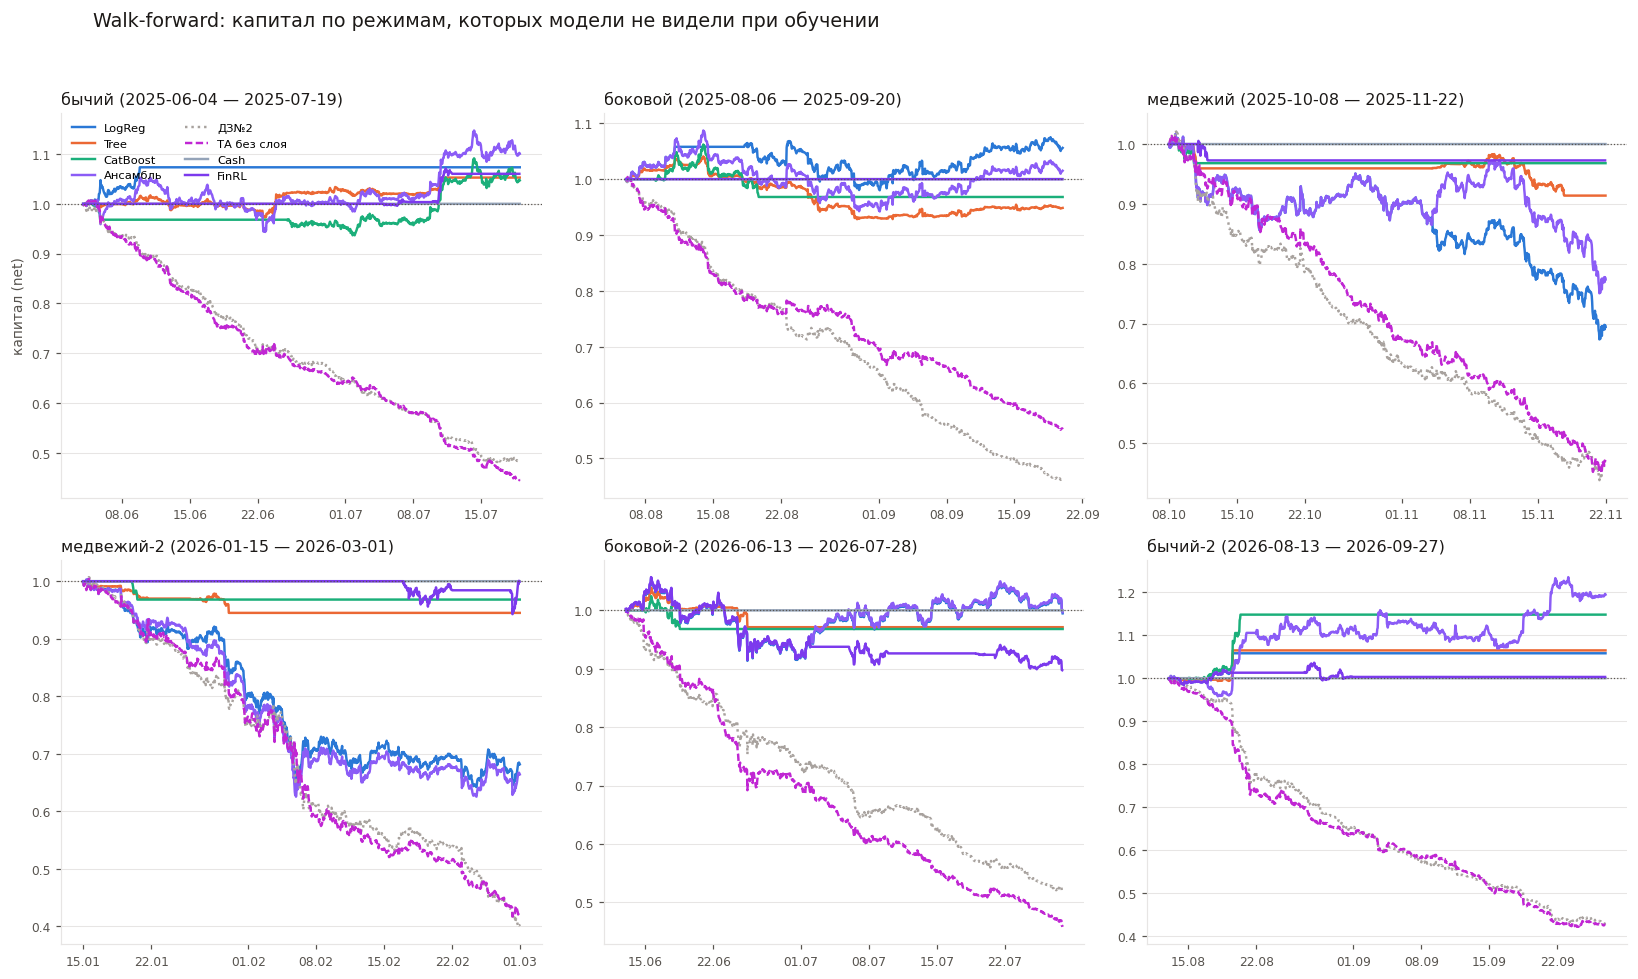

бычий (2025-06-04 — 2025-07-19): прибыльных стратегий 5 из 8
боковой (2025-08-06 — 2025-09-20): прибыльных стратегий 2 из 8
медвежий (2025-10-08 — 2025-11-22): прибыльных стратегий 0 из 8
медвежий-2 (2026-01-15 — 2026-03-01): прибыльных стратегий 0 из 8
боковой-2 (2026-06-13 — 2026-07-28): прибыльных стратегий 0 из 8
бычий-2 (2026-08-13 — 2026-09-27): прибыльных стратегий 5 из 8


In [82]:
# Капитал по каждой стратегии в каждом из трёх режимов.
n_rows = -(-len(regime_curves) // 3)
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4.3 * n_rows), sharey=False, squeeze=False)
axes = axes.ravel()
for ax in axes[len(regime_curves):]:
    ax.set_visible(False)
for ax, (label, curves_here) in zip(axes, regime_curves.items()):
    for name, curve in curves_here.items():
        ax.plot(curve["date"], curve["equity"], color=COLORS[name], linewidth=1.6,
                linestyle=STYLES.get(name, "-"), label=SHORT[name])
    ax.axhline(1.0, color=INK_MUTED, linewidth=0.8, linestyle=":")
    ax.set_title(label, color=INK, fontsize=10.5, loc="left")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
    style_ax(ax)
axes[0].legend(frameon=False, fontsize=7.5, ncol=2, loc="upper left")
axes[0].set_ylabel("капитал (net)", color=INK_MUTED, fontsize=9)
fig.suptitle("Walk-forward: капитал по режимам, которых модели не видели при обучении",
             fontsize=12.5, color=INK, x=0.06, ha="left", y=1.03)
fig.tight_layout()
plt.show()

n_profitable_by_regime = (regime_table["total_return"] > 0).groupby(level="режим").sum()
n_total_by_regime = regime_table.groupby(level="режим").size()
for label in REGIME_WINDOWS:
    print(f"{label}: прибыльных стратегий {int(n_profitable_by_regime[label])} из "
          f"{int(n_total_by_regime[label])}")


### 24.1 Правила выбора стопа и тейка: валидация и шесть окон walk-forward

Раздел 18.3 показал, что выбор «максимум Sharpe по 49 вариантам» переносится плохо. Здесь
сравниваются пять правил. Каждое решается **только на dev**, сигнал у всех один и тот же:

- **подбор** — как в разделе 14;
- **без стопов**;
- **только стоп-лосс** — тейк запрещён, чтобы не срезать трендовую сделку;
- **возврат через сутки** — после выхода не дольше 24 ч вне рынка;
- **сглаженный выбор** — максимум среднего Sharpe по окрестности 3 × 3 в сетке SL × TP,
  а не по одной клетке.

Правила добавлены после того, как была видна валидация. Поэтому валидация для них уже не
независима. Первые три окна walk-forward на момент их выбора не смотрелись. Окна 4–6 появились после
обновления данных, когда правила уже были зафиксированы, — для них проверка полностью независима.

Какой выход выбрало каждое правило (решение — только по dev):


правило,подбор,без стопов,только стоп-лосс,возврат через сутки,сглаженный выбор
стратегия,,,,,
LogisticRegression,SL нет / TP 6%,—,SL 5.0% / TP нет,"SL 8.0% / TP 15%, 24ч",SL 8.0% / TP 6%
DecisionTree,SL 8.0% / TP 10%,—,SL 8.0% / TP нет,—,SL 8.0% / TP 15%
CatBoost,SL 3.0% / TP 15%,—,SL 3.0% / TP нет,—,SL 3.0% / TP 15%
Ensemble,"SL нет / TP 15%, 24ч",—,—,"SL нет / TP 15%, 24ч","SL 8.0% / TP 15%, 24ч"
TimesNet,"SL 8.0% / TP 10%, 24ч",—,—,"SL 8.0% / TP 10%, 24ч","SL 8.0% / TP 15%, 24ч"
TSMixer,SL 3.0% / TP 6%,—,—,"SL 5.0% / TP 6%, 24ч",SL 3.0% / TP 6%
TimesFM,SL нет / TP 6%,—,SL 5.0% / TP нет,"SL нет / TP 6%, 24ч",SL 8.0% / TP нет
EnsembleAll,SL 3.0% / TP 3%,—,SL 3.0% / TP нет,"SL 8.0% / TP нет, 24ч",SL 5.0% / TP нет



val Sharpe на валидации:


правило,исходный ноутбук,подбор,без стопов,только стоп-лосс,возврат через сутки,сглаженный выбор
стратегия,,,,,,
LogisticRegression,0.257,0.731,1.171,0.882,0.769,1.095
DecisionTree,0.217,0.057,1.205,1.289,1.205,0.545
CatBoost,2.060,2.358,1.859,1.859,1.859,2.358
Ensemble,-0.224,1.862,2.102,2.102,1.862,1.034
TimesNet,-0.709,-1.642,-1.007,-1.007,-1.642,-1.747
TSMixer,-2.754,-3.158,-2.187,-2.187,-3.704,-3.158
TimesFM,0.524,0.123,-1.077,-0.525,-1.097,-0.180
EnsembleAll,0.116,-1.432,-0.525,-1.294,-1.634,-2.051



val net на валидации:


...

,медиана val Sharpe,медиана val net,медиана val просадки,Sharpe лучше исходного,net лучше исходного,просадка меньше исходной
подбор,0.090,-0.002,-0.243,3.0,4.0,6.0
без стопов,0.323,0.045,-0.316,4.0,4.0,5.0
только стоп-лосс,0.178,0.003,-0.288,4.0,4.0,4.0
возврат через сутки,-0.164,-0.018,-0.340,3.0,3.0,4.0
сглаженный выбор,0.183,-0.028,-0.271,4.0,4.0,6.0
исходный ноутбук,0.166,-0.030,-0.380,NaN,NaN,NaN



Walk-forward, net по режимам (строки — стратегия, столбцы — правило выхода):


правило                       исходный ноутбук  подбор без стопов  \
режим      стратегия                                                
бычий      LogisticRegression           +14.5%   +7.3%     +15.2%   
           DecisionTree                  -2.6%   +5.3%      +6.8%   
           CatBoost                     +11.6%   +4.7%      +9.4%   
           Ensemble                     +13.0%  +10.1%     +10.1%   
боковой    LogisticRegression            +1.5%   +5.6%      +1.2%   
           DecisionTree                  -3.7%   -5.2%      -5.2%   
           CatBoost                      -3.3%   -3.2%      -0.8%   
           Ensemble                      -6.7%   +1.5%      +1.5%   
медвежий   LogisticRegression           -31.3%  -30.6%     -30.6%   
           DecisionTree                 -11.1%   -8.6%     -15.8%   
           CatBoost                     -30.6%   -3.2%     -31.1%   
           Ensemble                     -13.6%  -22.6%     -22.6%   
медвежий-2 LogisticRegression                —  -31.9%     -31.9%   
           DecisionTree                      —   -5.5%     -13.5%   
           CatBoost                          —   -3.2%     -28.0%   
           Ensemble                          —  -33.6%     -33.6%   
боковой-2  LogisticRegression                —   -0.5%      -0.5%   
           DecisionTree                      —   -2.9%      -1.5%   
           CatBoost                          —   -3.2%      -3.4%   
           Ensemble                          —   -0.3%      -0.3%   
бычий-2    LogisticRegression                —   +5.8%     +32.5%   
           DecisionTree                      —   +6.5%     +15.3%   
           CatBoost                          —  +14.8%     +33.6%   
           Ensemble                          —  +19.4%     +26.0%   

правило                       только стоп-лосс возврат через сутки  \
режим      стратегия                                                 
бычий      LogisticRegression            -3.8%              +12.6%   
           DecisionTree                  +6.8%               +6.8%   
           CatBoost                      +4.7%               +9.4%   
           Ensemble                     +10.1%              +10.1%   
боковой    LogisticRegression            -4.0%               +1.2%   
           DecisionTree                  -5.2%               -5.2%   
           CatBoost                      -3.2%               -0.8%   
           Ensemble                      +1.5%               +1.5%   
медвежий   LogisticRegression            -5.2%              -27.5%   
           DecisionTree                  -8.6%              -15.8%   
           CatBoost                      -3.2%              -31.1%   
           Ensemble                     -22.6%              -22.6%   
медвежий-2 LogisticRegression            -9.9%              -25.3%   
           DecisionTree                  -5.5%              -13.5%   
           CatBoost                      -3.2%              -28.0%   
           Ensemble                     -33.6%              -33.6%   
боковой-2  LogisticRegression            -5.2%               -1.6%   
           DecisionTree                  -2.9%               -1.5%   
           CatBoost                      -3.2%               -3.4%   
           Ensemble                      -0.3%               -0.3%   
бычий-2    LogisticRegression           +32.5%              +25.5%   
           DecisionTree                 +15.3%              +15.3%   
           CatBoost                     +33.6%              +33.6%   
           Ensemble                     +26.0%              +19.4%   

правило                       сглаженный выбор  
режим      стратегия                            
бычий      LogisticRegression            +7.3%  
           DecisionTree                  +8.3%  
           CatBoost                      +4.7%  
           Ensemble                     +10.1%  
боковой    LogisticRegression            +5.6%  
           DecisionTree                  

Среднее по четырём стратегиям:


правило            исходный ноутбук  подбор  без стопов  только стоп-лосс  \
       режим                                                                
net    бычий                  0.091   0.068       0.104             0.044   
       боковой               -0.030  -0.003      -0.008            -0.027   
       медвежий              -0.217  -0.163      -0.250            -0.099   
       медвежий-2               NaN  -0.185      -0.268            -0.131   
       боковой-2                NaN  -0.017      -0.014            -0.029   
       бычий-2                  NaN   0.116       0.269             0.269   
Sharpe бычий                  2.264   3.059       2.960             1.535   
       боковой               -0.670  -0.520      -0.435            -1.292   
       медвежий              -3.866  -4.434      -5.426            -3.982   
       медвежий-2               NaN  -5.726      -4.802            -6.406   
       боковой-2                NaN  -0.979      -0.214            -1.515   
       бычий-2                  NaN   4.815       5.663             5.663   

правило            возврат через сутки  сглаженный выбор  
       режим                                              
net    бычий                     0.097             0.076  
       боковой                  -0.008            -0.003  
       медвежий                 -0.242            -0.103  
       медвежий-2               -0.251            -0.134  
       боковой-2                -0.017            -0.040  
       бычий-2                   0.235             0.126  
Sharpe бычий                     2.826             3.367  
       боковой                  -0.435            -0.520  
       медвежий                 -5.381            -4.301  
       медвежий-2               -4.562            -5.755  
       боковой-2                -0.279            -1.745  
       бычий-2                   5.273             5.478

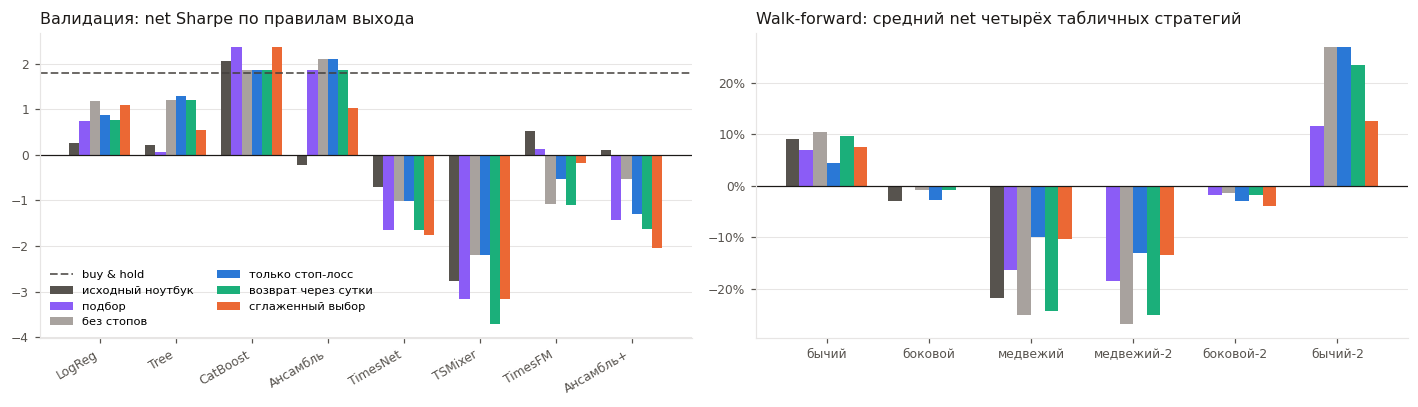

In [83]:
# Правила выбора стопа и тейка: каждое решается ТОЛЬКО на dev (OOF фолдов 1–4, те же ограничения
# активности, что в разделе 14), затем проверяется на валидации и на трёх режимах walk-forward.
# Сигнал (режим, q, span, ребалансировка) у всех правил один — тот, что выбран в разделе 14–17;
# меняется только правило выхода.
#   подбор            — совместный подбор слоя и выхода по максимуму net Sharpe (как в разделе 14);
#   без стопов        — правила выхода выключены;
#   только стоп-лосс  — тейк запрещён: прибыльная сделка закрывается только сигналом модели;
#   возврат через сутки — после любого выхода не дольше 24 ч вне рынка;
#   сглаженный выбор  — максимум среднего Sharpe по соседним клеткам сетки SL × TP, а не по одной
#                       клетке: устойчивый к шуму оптимум вместо острого пика.
EXIT_RULES = ["подбор", "без стопов", "только стоп-лосс", "возврат через сутки", "сглаженный выбор"]


def dev_exit_table(name):
    """Все 49 правил выхода для выбранного сигнала модели на OOF dev + допустимость."""
    o_, m_ = dev_oof[name]
    base = {k: v for k, v in signal_by_model[name].items() if k not in ("sl", "tp", "cooldown")}
    years = int((DEV_FOLDS[m_] >= 1).sum()) / PERIODS_PER_YEAR
    rows = []
    for ex in EXIT_GRID:
        curve, m = oof_signal_backtest(o_[m_], dates_dev.to_numpy()[m_], fwd_dev.to_numpy()[m_],
                                       DEV_FOLDS[m_], {**base, **ex})
        blocks = np.array_split(curve["strategy_return"].to_numpy(), N_BLOCKS)
        n_pos = sum(b.std(ddof=0) > 0 and b.mean() > 0 for b in blocks)
        ok = (m["turnover_units"] >= MIN_TURNOVER_PER_YEAR * years
              and m["avg_abs_position"] >= MIN_AVG_EXPOSURE and n_pos >= MIN_POSITIVE_BLOCKS)
        rows.append({**ex, "sharpe": m["sharpe"], "ok": bool(ok)})
    return pd.DataFrame(rows)


def smoothed_choice(tab):
    """Клетка SL × TP с максимальным средним Sharpe по окрестности 3 × 3 (та же пауза)."""
    best, best_val = dict(SLTP_OFF), -np.inf
    for cd in COOLDOWN_GRID:
        grid = np.array([[exit_row(tab, sl, tp, cd)["sharpe"] for tp in TP_GRID] for sl in SL_GRID])
        okg = np.array([[exit_row(tab, sl, tp, cd)["ok"] for tp in TP_GRID] for sl in SL_GRID])
        for i in range(len(SL_GRID)):
            for j in range(len(TP_GRID)):
                if not okg[i, j]:
                    continue
                v = grid[max(i - 1, 0):i + 2, max(j - 1, 0):j + 2].mean()
                if v > best_val:
                    best_val = v
                    best = {"sl": SL_GRID[i], "tp": TP_GRID[j],
                            "cooldown": cd if (SL_GRID[i] > 0 or TP_GRID[j] > 0) else -1}
    return best


def choose_exit(rule, name, tab):
    prm = signal_by_model[name]
    if rule == "подбор":
        return {k: prm[k] for k in ("sl", "tp", "cooldown")}
    if rule == "без стопов":
        return dict(SLTP_OFF)
    if rule == "сглаженный выбор":
        return smoothed_choice(tab)
    is_off = (tab["sl"] == 0) & (tab["tp"] == 0)
    allowed = {"только стоп-лосс": tab["tp"] == 0,
               "возврат через сутки": is_off | (tab["cooldown"] == 24)}[rule] & tab["ok"]
    if not allowed.any():
        return dict(SLTP_OFF)
    r = tab[allowed].loc[tab[allowed]["sharpe"].idxmax()]
    return {"sl": float(r["sl"]), "tp": float(r["tp"]), "cooldown": int(r["cooldown"])}


def exit_label(ex):
    if ex["sl"] == 0 and ex["tp"] == 0:
        return "—"
    return (f"SL {ex['sl']:.1%}" if ex["sl"] else "SL нет") + " / " + \
           (f"TP {ex['tp']:.0%}" if ex["tp"] else "TP нет") + ("" if ex["cooldown"] < 0 else ", 24ч")


rule_choice, rule_rows = {}, []
for name in LAYER_MODELS:
    tab_ = dev_exit_table(name)
    for rule in EXIT_RULES:
        ex = choose_exit(rule, name, tab_)
        rule_choice[(name, rule)] = ex
        _, m_val = backtest(val_dates, val_fwd, val_positions[name], sltp=ex)
        rule_rows.append({"стратегия": name, "правило": rule, "выход": exit_label(ex),
                          "dev Sharpe": float(exit_row(tab_, ex["sl"], ex["tp"], ex["cooldown"])["sharpe"]),
                          "val net": m_val["total_return"], "val Sharpe": m_val["sharpe"],
                          "val просадка": m_val["max_drawdown"]})
rules_val = pd.DataFrame(rule_rows)

print("Какой выход выбрало каждое правило (решение — только по dev):")
display(rules_val.pivot(index="стратегия", columns="правило", values="выход")
        .loc[LAYER_MODELS, EXIT_RULES])
orig = pd.DataFrame(ORIGINAL_VAL, index=["net", "sharpe", "mdd", "trades"]).T
for metric, col in (("val Sharpe", "sharpe"), ("val net", "net")):
    pv = rules_val.pivot(index="стратегия", columns="правило", values=metric).loc[LAYER_MODELS, EXIT_RULES]
    pv.insert(0, "исходный ноутбук", orig.loc[LAYER_MODELS, col])
    print(f"\n{metric} на валидации:")
    display(pv.round(3))

val_summary = pd.DataFrame({
    rule: {"медиана val Sharpe": g["val Sharpe"].median(),
           "медиана val net": g["val net"].median(),
           "медиана val просадки": g["val просадка"].median(),
           "Sharpe лучше исходного": int((g["val Sharpe"].to_numpy()
                                          > orig.loc[g["стратегия"], "sharpe"].to_numpy()).sum()),
           "net лучше исходного": int((g["val net"].to_numpy()
                                       > orig.loc[g["стратегия"], "net"].to_numpy()).sum()),
           "просадка меньше исходной": int((g["val просадка"].to_numpy()
                                            > orig.loc[g["стратегия"], "mdd"].to_numpy()).sum())}
    for rule, g in rules_val.groupby("правило", sort=False)}).T.loc[EXIT_RULES]
val_summary.loc["исходный ноутбук"] = [orig["sharpe"].median(), orig["net"].median(),
                                       orig["mdd"].median(), np.nan, np.nan, np.nan]
print(f"\nСводка по {len(LAYER_MODELS)} стратегиям (валидация):")
display(val_summary.round(3))

# ── те же правила на трёх режимах walk-forward (табличные модели и их ансамбль) ─────────────
# Исходный ноутбук, раздел 24 (net, Sharpe) — для сравнения.
ORIGINAL_WF = {
    "бычий": {"LogisticRegression": (0.1449, 3.5016), "DecisionTree": (-0.0264, -0.5079),
              "CatBoost": (0.1163, 2.8830), "Ensemble": (0.1301, 3.1800)},
    "боковой": {"LogisticRegression": (0.0151, 0.5435), "DecisionTree": (-0.0373, -0.8392),
                "CatBoost": (-0.0327, -0.7665), "Ensemble": (-0.0665, -1.6191)},
    "медвежий": {"LogisticRegression": (-0.3131, -5.9074), "DecisionTree": (-0.1111, -1.6755),
                 "CatBoost": (-0.3058, -5.7334), "Ensemble": (-0.1361, -2.1460)},
}
WF_MODELS = list(final_models) + ["Ensemble"]
wf_rows = []
for label, (w_dates, w_fwd, positions_here) in regime_inputs.items():
    regime = label.split(" ")[0]
    for name in WF_MODELS:
        o_net, o_sh = ORIGINAL_WF[regime][name] if regime in ORIGINAL_WF else (np.nan, np.nan)
        wf_rows.append({"режим": regime, "стратегия": name, "правило": "исходный ноутбук",
                        "net": o_net, "Sharpe": o_sh, "просадка": np.nan, "стопов": np.nan})
        for rule in EXIT_RULES:
            ex = rule_choice[(name, rule)]
            _, m_w = backtest(w_dates, w_fwd, positions_here[name], sltp=ex)
            wf_rows.append({"режим": regime, "стратегия": name, "правило": rule,
                            "net": m_w["total_return"], "Sharpe": m_w["sharpe"],
                            "просадка": m_w["max_drawdown"],
                            "стопов": m_w["n_stop_loss"] + m_w["n_take_profit"]})
wf_rules = pd.DataFrame(wf_rows)
WF_ORDER = ["исходный ноутбук"] + EXIT_RULES
print("\nWalk-forward, net по режимам (строки — стратегия, столбцы — правило выхода):")
display(wf_rules.pivot_table(index=["режим", "стратегия"], columns="правило", values="net", sort=False)
        [WF_ORDER].map(lambda v: "—" if pd.isna(v) else f"{v:+.1%}"))
print("Среднее по четырём стратегиям:")
display(pd.concat({m: wf_rules.pivot_table(index="режим", columns="правило", values=m, sort=False)[WF_ORDER]
                   for m in ("net", "Sharpe")}, axis=0).round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
rule_colors = dict(zip(WF_ORDER, [INK_MUTED, COLORS["Ensemble"], "#a8a29e", COLORS["LogisticRegression"],
                                  COLORS["CatBoost"], COLORS["DecisionTree"]]))
xs = np.arange(len(LAYER_MODELS))
wbar = 0.8 / len(WF_ORDER)
sh_pv = rules_val.pivot(index="стратегия", columns="правило", values="val Sharpe").loc[LAYER_MODELS]
sh_pv["исходный ноутбук"] = orig.loc[LAYER_MODELS, "sharpe"]
for k, rule in enumerate(WF_ORDER):
    axes[0].bar(xs + (k - len(WF_ORDER) / 2 + 0.5) * wbar, sh_pv[rule], wbar, color=rule_colors[rule],
                label=rule)
axes[0].axhline(val_comparison.loc["BuyAndHold", "sharpe"], color=COLORS["BuyAndHold"],
                linestyle=(0, (5, 2)), linewidth=1, label="buy & hold")
axes[0].axhline(0, color=INK, linewidth=0.8)
axes[0].set_xticks(xs)
axes[0].set_xticklabels([SHORT[n] for n in LAYER_MODELS], fontsize=8, rotation=30, ha="right")
axes[0].set_title("Валидация: net Sharpe по правилам выхода", color=INK, loc="left", fontsize=10.5)
axes[0].legend(frameon=False, fontsize=7.5, ncol=2)
style_ax(axes[0])
wf_mean = wf_rules.pivot_table(index="режим", columns="правило", values="net", sort=False)[WF_ORDER]
xr = np.arange(len(wf_mean))
for k, rule in enumerate(WF_ORDER):
    axes[1].bar(xr + (k - len(WF_ORDER) / 2 + 0.5) * wbar, wf_mean[rule], wbar, color=rule_colors[rule])
axes[1].axhline(0, color=INK, linewidth=0.8)
axes[1].set_xticks(xr)
axes[1].set_xticklabels(wf_mean.index)
axes[1].yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
axes[1].set_title("Walk-forward: средний net четырёх табличных стратегий", color=INK, loc="left",
                  fontsize=10.5)
style_ax(axes[1])
fig.tight_layout()
plt.show()

**Что показали режимы: стоп-лосс — страховка от падения, тейк-профит вреден в тренде.**
Средний net четырёх табличных стратегий:

| правило | бычий +11.7% | боковой +1.6% | медвежий −30.5% | медвежий-2 −30.9% | боковой-2 −0.2% | бычий-2 +32.6% | среднее |
|---|---|---|---|---|---|---|---|
| исходный ноутбук | +9.1% | −3.0% | −21.7% | — | — | — | — |
| без стопов (новые модели) | +10.4% | −0.8% | −25.0% | −26.8% | −1.4% | +26.9% | −2.8% |
| подбор (раздел 14) | +6.8% | −0.3% | −16.3% | −18.5% | −1.7% | +11.6% | −3.1% |
| **только стоп-лосс** | +4.4% | −2.7% | **−9.9%** | **−13.1%** | −2.9% | **+26.9%** | **+0.5%** |
| возврат через сутки | +9.7% | −0.8% | −24.2% | −25.1% | −1.7% | +23.5% | −3.1% |
| сглаженный выбор | +7.6% | **−0.3%** | −10.3% | −13.4% | −4.0% | +12.6% | −1.3% |

Окна 4–6 появились, когда правила уже были зафиксированы, — для них это полностью независимая
проверка. На этих трёх окнах «только стоп-лосс» даёт в среднем +3.6% при рынке +0.5%; все
остальные правила — в минусе.

- **В падении стоп-лосс — главный выигрыш ноутбука, и это повторилось.** CatBoost со стопом 3%:
  −3.2% в обоих медвежьих окнах против −31.1% и −28.0% без стопов. «Только стоп-лосс» и
  «сглаженный выбор» вдвое урезают средний убыток и в медвежьем, и в медвежьем-2.
- **Тейк-профит в сильном тренде стоит дорого.** В бычьем-2 «только стоп-лосс» взял весь рост
  (+26.9%, как без стопов): стоп не сработал. «Подбор» и «сглаженный выбор» с тейком 6–15%
  упустили 14–15 п.п. В слабом бычьем окне разница была 3–6 п.п.
- **«Возврат через сутки» почти обнуляет эффект стопов** и в плюсе, и в минусе: стратегия
  возвращается в ту же сторону, а на падении это означает новый стоп.
- **Ансамбль стопы не спасают:** −33.6% в медвежьем-2 при любом правиле, кроме «сглаженного»
  (−32.0%). Выбранный для него выход — тейк 15% без стоп-лосса.
- **Вывод прошлой версии пересмотрен.** На трёх первых окнах лучшим компромиссом выглядел
  «сглаженный выбор», а «только стоп-лосс» — худшим в росте. Сильный бычий тренд показал
  обратное: проигрывает не стоп, а тейк.

### Что это значит для вопроса «можно ли выпускать на биржу»

Ответ по-прежнему нет, и это walk-forward-упражнение показывает почему конкретно:

- **Ни одна стратегия не проверялась на встроенную смену режима.** Пороги торгового слоя,
  веса моделей и гиперпараметры зафиксированы по одному растущему периоду (dev) и одному
  растущему периоду валидации; здесь они впервые встречают падающий и боковой рынок без
  какой-либо адаптации. Таблица и графики выше показывают, меняется ли характер результата
  между режимами, а не единственное число — сравнивайте gross/net/Sharpe по строкам таблицы
  для каждой стратегии, а не только смотрите на общий B&H режима.
- **Проверены не все стратегии.** TimesNet, TSMixer, TimesFM, EnsembleAll, RL-позиция и
  RL-вершина ансамбля не включены (см. пояснение выше) — по ним конкретно вывод о поведении
  вне обучающего периода остаётся открытым, а не «хорошим по умолчанию».
- **Шесть окон — не полная история режимов.** 45 дней на окно — короткий срез каждого режима;
  число сделок внутри каждого окна маленькое, доверительный интервал Sharpe — широкий (та же
  оговорка, что и у основной валидации в разделе 18).
- **Реальное исполнение по-прежнему не смоделировано** (спред, проскальзывание, размер заявки,
  задержка) — оговорка раздела 20 распространяется и на эту проверку.

Практический вывод: если результат в этой таблице устойчиво положительный у какой-то стратегии
во всех шести окнах — это более сильный аргумент в её пользу, чем единственное растущее окно
валидации, но всё ещё не основание для реальных денег без (1) сериализации и walk-forward
проверки оставшихся моделей, (2) полноценной симуляции исполнения, (3) paper trading в реальном
времени.

## 25. Выводы: стоп-лосс и тейк-профит

### Что сделано

- В торговую стратегию добавлены **стоп-лосс и тейк-профит** от цены входа и пауза после
  выхода. Исполнение идёт внутри часа по open/high/low следующего бара, консервативно: гэп
  исполняется по open, при двух уровнях в одном баре первым считается стоп, комиссия
  платится на каждом выходе (раздел 9.1). Без правил выхода бэктест совпадает с исходным бит в бит.
- Правила выхода подбираются **совместно** с торговым слоем: 288 сигналов × 49 вариантов
  выхода = 14 112 вариантов на модель, на тех же фолдах и с теми же ограничениями активности.
  Этот подбор стоит внутри целевой функции Optuna, поэтому гиперпараметры всех моделей
  подобраны и модели переобучены заново (разделы 14–17). Валидация в выборе не участвует.
- Результат сравнивается с исходным ноутбуком на валидации (18.3), на шести окнах
  walk-forward и по пяти правилам выбора стопов (24.1).

### Короткий ответ

**Стопы и тейки не дали универсального улучшения доходности, но заметно снизили риск.
Ансамбль трёх табличных моделей со стопами — первая активно торгующая supervised-стратегия
в этой работе, которая обогнала buy & hold на валидации.**

| валидация, 08.10.2024 — 04.06.2025 | net | Sharpe | просадка | сделок |
|---|---|---|---|---|
| buy & hold | +67.8% | 1.79 | −31.0% | 1 |
| исходный ноутбук: ансамбль | −15.1% | −0.22 | −40.7% | 86 |
| исходный ноутбук: CatBoost (почти buy & hold) | +84.1% | 2.06 | −31.0% | 2 |
| **SL/TP: ансамбль (TP 15%, возврат через сутки)** | **+71.8%** | **1.86** | **−26.7%** | 38 |
| SL/TP: CatBoost (SL 3%, TP 15%) | +25.9% | 2.36 | −8.3% | 4 |

### Что получилось

1. **Просадки меньше почти везде.** Максимальная просадка на валидации меньше, чем в
   исходном ноутбуке, у 6 стратегий из 8. Медиана по восьми стратегиям — −24% против −38%.
2. **Медвежий рынок — главный выигрыш, и он повторился на новых данных.** В окне −30.5%
   (октябрь–ноябрь 2025) средний убыток четырёх табличных стратегий снизился с −21.7% до
   −16.3% при подборе из раздела 14 и до −10% при «только стоп-лоссе» или «сглаженном
   выборе». В медвежьем-2 (январь–март 2026, −30.9%) — с −26.8% без стопов до −13.1%.
   CatBoost со стопом 3%: −3.2% в обоих окнах против −31.1% и −28.0% без стопа.
4. **«Только стоп-лосс» — единственное правило с плюсом по шести окнам** (+0.5% в среднем,
   рынок −2.6%). На трёх окнах, появившихся после фиксации правил, — +3.6% при рынке +0.5%.
3. **На dev стопы улучшают почти всё**: лучший Sharpe выше у 97% конфигураций сигнала,
   CV Sharpe Optuna вырос у всех трёх моделей (CatBoost 2.18 → 3.22).

### Чего не получилось

1. **Прирост на dev не переносится.** При тех же сигналах стопы на валидации улучшили Sharpe
   только у 2 стратегий из 8. Улучшение против исходного ноутбука дало в основном
   переобучение моделей под новую целевую функцию. Ранговая корреляция поверхностей
   «Sharpe от SL × TP» между dev и валидацией — от 0.03 до 0.58. Совместный перебор 14 тысяч
   вариантов переобучается под шум dev сильнее, чем прежние 288.
2. **Тейк-профит в тренде вреден.** Выход по тейку без возврата оставляет стратегию вне рынка
   до противоположного сигнала. CatBoost на растущей валидации в рынке 12% времени, net
   упал с +84% до +26%. В бычьем окне walk-forward стопы с тейком стоят 3–6 п.п., в сильном
   бычьем-2 (+32.6%) — 14–15 п.п.
3. **Модели последовательностей стопы не спасли.** У TimesNet, TSMixer и ансамбля+ edge нет
   даже без издержек (раздел 20), и правила выхода этого не исправляют.

### Что взять в работу

- **Стоп-лосс без тейка — как страховка от режима, а не как источник доходности.** На
  шести окнах лучшее правило — «только стоп-лосс»: самая сильная защита в обоих падениях
  (−9.9% и −13.1%) и весь рост в сильном тренде (+26.9% в бычьем-2). По трём первым окнам
  лучшим выглядел «сглаженный выбор», но в бычьем-2 его тейк отдал 14 п.п.
- **Лучшая связка — CatBoost + стоп 3% без тейка**: +4.3% в среднем по шести окнам. Но почти
  то же даёт наивное «buy & hold + стоп 3%» (+2.8%): CatBoost почти всё время в лонге, и
  защищает здесь стоп, а не модель.
- **Тейк-профит — только с механизмом возврата** в позицию или вовсе без него, если сигнал
  модели трендовый (`hold`).
- **Выбирать стопы по устойчивости, а не по максимуму.** Сглаживание поверхности, меньшая
  сетка, штраф за число вариантов — иначе подбор находит острые пики шума.

### Ограничения

- **Часовые бары не показывают порядок цен внутри часа.** Допущение «сначала стоп» —
  консервативное. Проскальзывание сверх гэпа не моделируется.
- **Стопы фиксированы в процентах.** Стопы от волатильности (ATR) не
  проверялись (трейлинг-стоп — в `final_ensenble_with_trailing_stop.ipynb`), хотя на медвежьем окне именно адаптивный уровень выглядит естественным
  следующим шагом.
- **Правила раздела 24.1 придуманы после взгляда на валидацию.** Независимая проверка для
  них — шесть окон walk-forward по 45 дней, из них три появились уже после фиксации правил, и
  только для табличных моделей. Окна выбраны по режиму задним числом. Модели
  последовательностей там не проверяются (раздел 24).
- **RL-агенты стопами не управляются** — позицию они выбирают сами. Их числа тоже изменились
  (FinRL −2.4% → +31.0%, RL-позиция +55.1% → +60.4%, RL-вершина +56.0% → +39.6%), но не
  из-за правил выхода. Признаки RL-агентов в финальной фазе берутся из топа важности
  финального CatBoost, а он подобран заново. RL-вершина к тому же получает на вход
  прогнозы заново подобранных моделей. Фаза train → test, где признаки выбираются по train,
  воспроизвела исходные числа точно.
- **Выводы-комментарии разделов 1–24 написаны для исходного ноутбука.** Где их числа
  расходятся с таблицами, актуальны таблицы и этот раздел.